# Renown Combat Lab — Reorganized

End-to-end combat analytics for *Renown*. Structured to compute once, analyze many times.

**Section 1 (Compute)** runs the heavy simulations and writes CSVs to disk:
- Main tournament (Random vs Random) with first-skirmish tactic pair logging
- Playstyle-aware tournament (each loadout uses its default playstyle)
- Forced-tactics matrix sweep on a stratified sample
- Horde-mode survival on a stratified sample

All later sections read those CSVs — no re-running sims to look at a new angle.

**Section 2+** organizes the analysis by:
- Pursuit / Domain — does spending correlate with winning?
- Retinue performance
- Equipment (weapons, shields, armor, bastard, lance)
- Tactics (empirical matrix from main run + forced-matrix sweep)
- Playstyles (style-aware tournament results)
- Horde Mode
- Per-loadout rollups (durability, kill power, robustness, counters, casualty sources)

---
**Pool model (current):** uses `balanced_validation_pool` — the CSV-derived innate/mastery pursuit model. Tier/retinue unlocks require the spec MASTERED (MaA→Coliseum, Sgt→War College, KT→Preceptory, each carrying its mastery chain). Regen is a 4-level axis (none/Apothecary/+Infirmary/+Hospitaller). MPC = settlement space (reduced by satisfied *Efficient X*); `total_investment` = raw pursuit count (action economy). Every generated build is checked by `validate_pool` (expects 0 invalid). Set `PER_CELL` in Section 0 to cap each (retinue×MPC) cell; `None` = full ~27k-build pool.


## 0. Setup — imports and global config

Change `LOADOUT_SOURCE` to `"csv"` to load a pre-computed pool from `loadouts.csv` (faster startup, reproducible) or `"generator"` to regenerate from `archetype_pool()`.

Tournament sizes: `N_RUNS_MAIN` is the most expensive (n_loadouts² × N_RUNS battles). `N_RUNS_PLAYSTYLE` runs a second tournament with style-aware loadouts. `N_RUNS_FORCED_TACTICS` runs a smaller forced-tactics sweep for the head-to-head tactic matrix.

In [1]:
import sys, os
sys.path.insert(0, r"C:\Users\Matt\OneDrive\Desktop\Game\Combatv3")
import os, sys, time, json, random, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# Project modules
import renown_combat, vectorized_combat, loadouts, playstyles, tournament_vec, analysis, batch_engine
import tactics_analysis
for m in [renown_combat, vectorized_combat, loadouts, playstyles, tournament_vec, analysis, tactics_analysis, batch_engine]:
    importlib.reload(m)
vectorized_combat.invalidate_tactic_tables()

from renown_combat import TACTICS

# ── CONFIG ──────────────────────────────────────────────────────────────────
OUT_DIR        = r"C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Loadout source ───────────────────────────────────────────────────────────
# "csv": load a frozen pool you saved earlier (set LOADOUT_CSV to its path).
# "generator": build a fresh pool from the current rules, using the MPC bracket below,
#              and SAVE it to a parquet+csv you can re-pull later (see cell 4).
LOADOUT_SOURCE = "csv"     # "csv" or "generator"
LOADOUT_CSV    = r"C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\loadouts_bal_8_18.csv"   # used only when LOADOUT_SOURCE == "csv"

# ── Editable MPC bracket (generation only) ─────────────────────────────────────
# The pool spans builds whose Military Pursuit Count falls in [MPC_MIN, MPC_MAX].
# These feed loadouts.balanced_validation_pool(mpc_min=MPC_MIN, mpc_max=MPC_MAX, per_cell=PER_CELL).
MPC_MIN = 4
MPC_MAX = 13
# PER_CELL caps each (retinue x MPC) cell. None = full pool (large: ~27k builds, heavy round-robin).
# Set an integer (e.g. 50) to keep matchup counts tractable; the .bat uses 50.
PER_CELL = 50
# Where to save a freshly generated pool (so you can reload it later via LOADOUT_SOURCE="csv").
# The MPC range is baked into the name so saved pools are self-identifying.
SAVE_GENERATED_POOL = True
GEN_POOL_BASENAME   = os.path.join(OUT_DIR, f"loadouts_gen_{MPC_MIN}_{MPC_MAX}")  # .parquet + .csv

# ── Run counts ─────────────────────────────────────────────────────────────────
# N_RUNS_MAIN is the single source of truth; every other tournament's run count
# derives from it. Edit N_RUNS_MAIN to scale them all together.
N_RUNS_MAIN      = 100
N_RUNS_PLAYSTYLE = N_RUNS_MAIN
N_RUNS_FORCED    = N_RUNS_MAIN
N_RUNS_HORDE     = N_RUNS_MAIN

# ── Tournament / sampling knobs ─────────────────────────────────────────────────
LOAD_PS_MATCHUPS = False   # playstyle matchups DOUBLES RAM; load only if you need the KT-twin cell
dont = True # ignore playstyle tournament
USE_BATCH      = True     # batched engine (~7-8x faster)
POOL_SIZE      = None     # None = full pool; set e.g. 200 for a fast smoke run
# Stratified subsample: cap builds PER MPC bucket so the whole range is covered without the
# high-MPC combinatorial blowup. Rows scale ~quadratically with build count; 80->40 = ~1/4 the
# matchup rows + runtime + RAM. None disables.
STRATIFY_PER_MPC = None   # (legacy; balanced_validation_pool uses PER_CELL instead — leave None)
N_WORKERS_MAIN = max(1, (os.cpu_count() or 4) - 2)   # leave 2 cores free

FORCED_SAMPLE_SIZE = 200
HORDE_BATTLES      = 8
HORDE_SAMPLE_SIZE  = 10

# Reproducibility
random.seed(2026)
np.random.seed(2026)

def _have_matchups(path):
    """True if the matchups file exists as .csv OR its .parquet sibling (batch writes parquet)."""
    p=str(path)
    return os.path.exists(p) or os.path.exists(p[:-4]+".parquet" if p.endswith(".csv") else p+".parquet")

In [125]:
import loadouts as L
pool = L.archetype_pool(min_pursuit_cost=12, max_pursuit_cost=16, budget_metric="total")

gt = [l for l in pool if "Grand Tournament" in l.pursuits]
print("Grand Tournament builds:", len(gt))
print("  with Riposte tag:", sum("Riposte" in l.extra_tags for l in gt))
print("GT mastery_req:", L.PURSUITS_INFO["Grand Tournament"]["mastery_req"])
if gt:
    ex = gt[0]
    print("example GT pursuits:", sorted(ex.pursuits))
    print("mastered?", all(r in ex.pursuits for r in L.PURSUITS_INFO["Grand Tournament"]["mastery_req"]))
    _,_,should = L.compute_pursuit_cost(ex.pursuits)
    print("compute_pursuit_cost grants:", sorted(should))

Grand Tournament builds: 16107
  with Riposte tag: 0
GT mastery_req: ['Conditioning Field', 'Coliseum']
example GT pursuits: ['Caravanery', 'Carpentry', 'Cipher Chamber', 'Coliseum', 'Fletchery', 'Grand Tournament', 'Joinery', 'Levy Hall', 'Outrider Intercept Post', 'Outrider Mastery', 'Royal Pavilion', 'Tiltyard']
mastered? False
compute_pursuit_cost grants: ['Drilled', 'Immune Blocked', 'Immune Strain', 'Immune Unwieldy', 'Improved Parry', 'Outrider: every', 'Parry', 'confers:Blocked', 'confers:Strain']


valid JSON


## 0.1 Load loadout pool

In [2]:
# ── Build or load the loadout pool ─────────────────────────────────────────────
# Uses balanced_validation_pool: the analytical pool spanning all gear tiers x retinues,
# with the CSV-derived innate/mastery model, retinue-unlock enforcement (MaA->Coliseum,
# Sgt->War College, KT->Preceptory, each carrying its mastery chain), and the 4-level regen
# axis (none / Apothecary / Apo+Infirmary / Apo+Inf+Hospitaller). per_cell caps each
# (retinue x MPC) cell so the round-robin stays tractable; None = full pool.
if LOADOUT_SOURCE == "csv" and os.path.exists(LOADOUT_CSV):
    pool = loadouts.archetype_pool(csv_path=LOADOUT_CSV)
    print(f"Loaded {len(pool)} loadouts from {LOADOUT_CSV}")
else:
    pool = loadouts.balanced_validation_pool(
        mpc_min=MPC_MIN, mpc_max=MPC_MAX, per_cell=PER_CELL, verbose=True)
    print(f"Generated {len(pool)} loadouts from balanced_validation_pool "
          f"(MPC {MPC_MIN}-{MPC_MAX}, per_cell={PER_CELL})")
    if LOADOUT_SOURCE == "csv":
        print(f"  ({LOADOUT_CSV} not found — fell back to generator)")

    # Validate every generated build against the full rule set (structural + buildings +
    # prereqs + efficiency). Should print 0 invalid; any violations are a generation bug.
    _bad = loadouts.validate_pool(pool)

    # Save the freshly generated pool so it can be re-pulled later via LOADOUT_SOURCE="csv".
    if SAVE_GENERATED_POOL:
        _rows = [{
            "name": l.name, "retinue": l.retinue, "weapon": l.weapon,
            "shield": l.shield or "", "armor": l.armor, "ranged": l.ranged or "",
            "has_tiltyard": l.has_tiltyard, "size": l.size,
            "extra_tags": ",".join(l.extra_tags),
            "upkeep_per_retinue": l.upkeep_per_retinue,
            "playstyle": l.playstyle or "",
            "tiltyard_mastery": getattr(l, "tiltyard_mastery", False),
            "pursuits": "|".join(sorted(l.pursuits)),
            "military_pursuit_count": l.military_pursuit_count,
            "domain_count": l.domain_count,
        } for l in pool]
        _df = pd.DataFrame(_rows)
        _df.to_parquet(GEN_POOL_BASENAME + ".parquet", index=False)
        _df.to_csv(GEN_POOL_BASENAME + ".csv", index=False)
        print(f"  Saved pool -> {GEN_POOL_BASENAME}.parquet (+ .csv)")
        print(f"  To reuse later: set LOADOUT_SOURCE='csv' and LOADOUT_CSV=r'{GEN_POOL_BASENAME}.csv'")

# Quick summary
print("\nBy retinue:")
for r, n in Counter(ld.retinue for ld in pool).most_common():
    print(f"  {r:<15} {n}")
print(f"\nBy MPC (military pursuit count):")
mpc_counts = Counter(ld.military_pursuit_count for ld in pool)
for mpc in sorted(mpc_counts):
    print(f"  mpc={mpc:<3} {mpc_counts[mpc]}")

if POOL_SIZE is not None and POOL_SIZE < len(pool):
    random.seed(2026); pool = random.sample(pool, POOL_SIZE)
    print(f"Subsampled pool to {len(pool)} (POOL_SIZE={POOL_SIZE})")

# Stable handle to the pool that generated the main tournament data.
MAIN_POOL = list(pool)


Loaded 35712 loadouts from C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\loadouts_gen_3_16.csv

By retinue:
  Sergeant        21171
  Man-at-Arms     10043
  Levy            2907
  Knight Templar  1591

By MPC (military pursuit count):
  mpc=2   68
  mpc=3   400
  mpc=4   737
  mpc=5   1322
  mpc=6   2195
  mpc=7   3534
  mpc=8   5274
  mpc=9   6904
  mpc=10  7405
  mpc=11  5345
  mpc=12  2046
  mpc=13  427
  mpc=14  55


# 1. Compute — run all simulations once

Each subsection writes CSVs to `OUT_DIR`. Skip subsections you've already run if the CSVs are on disk.

## 1A. Main tournament (Random vs Random)

This is the canonical data source. Every loadout plays every other loadout `N_RUNS_MAIN` times with Random playstyles on both sides. Outputs:
- `summary.csv` — one row per loadout with aggregated metrics
- `matchups.csv` — one row per (a_loadout × b_loadout) pair
- `tactic_matrix.csv` — empirical 7×7 tactic-pair matrix (NEW)

The `tactic_matrix.csv` is produced for free from the main tournament — every first-skirmish tactic pair is logged and attributed to final outcomes. This means we don't need a separate forced-tactic sweep to see how tactics interact in real (random) play.

In [3]:
MAIN_SUMMARY = os.path.join(OUT_DIR, "summary.csv")
MAIN_MATCHUPS = os.path.join(OUT_DIR, "matchups.csv")
MAIN_TACTIC_MATRIX = os.path.join(OUT_DIR, "tactic_matrix.csv")

if os.path.exists(MAIN_SUMMARY) and _have_matchups(MAIN_MATCHUPS):
    print(MAIN_SUMMARY,MAIN_MATCHUPS)
    print(f"SKIP - main tournament CSVs already exist in {OUT_DIR}")
    print(f"  Delete those files and re-run this cell to recompute.")

else:
    t0 = time.time()
    if USE_BATCH:
        # Batched RANDOM-vs-RANDOM tournament. Writes matchups.csv, summary.csv, tactic_matrix.csv.
        batch_engine.run_mode_batched(pool, mode="random", n_runs=N_RUNS_MAIN,
                                      output_dir=OUT_DIR, suffix="", base_seed=2026, verbose=True, n_workers=N_WORKERS_MAIN)
    else:
        tournament_vec.run_tournament_vec(
            pool, n_runs=N_RUNS_MAIN, output_dir=OUT_DIR,
            filename_suffix="", n_workers=N_WORKERS_MAIN, modes=("random",),
            verbose=True, print_every=max(1, len(pool)//20))
    print(f"\nMain tournament complete in {time.time()-t0:.0f}s")

C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\summary.csv C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\matchups.csv
SKIP - main tournament CSVs already exist in C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out
  Delete those files and re-run this cell to recompute.


## 1B. Playstyle-aware tournament

Each loadout is assigned its theoretically-optimal playstyle by `assign_default_playstyle()`, then the tournament reruns with everyone using their assigned style instead of Random. This is the comparison set for evaluating playstyle quality.

In [4]:
PLAYSTYLE_SUMMARY = os.path.join(OUT_DIR, "summary_playstyle.csv")
PLAYSTYLE_MATCHUPS = os.path.join(OUT_DIR, "matchups_playstyle.csv")
PLAYSTYLE_TACTIC_MATRIX = os.path.join(OUT_DIR, "tactic_matrix_playstyle.csv")

if dont:
    pass
else:
    if os.path.exists(PLAYSTYLE_SUMMARY) and _have_matchups(PLAYSTYLE_MATCHUPS):
        print(f"SKIP - playstyle tournament CSVs already exist in {OUT_DIR}")
    else:
        # Assign defaults; build the playstyle pool (+ KT-twins for the within-KT playstyle isolation).
        style_pool = [ld._replace(playstyle=playstyles.assign_default_playstyle(ld)) for ld in pool]
        kt_twins = loadouts.kt_twins(pool)
        style_pool.extend(kt_twins)
        print(f"Added {len(kt_twins)} KT-twin loadouts (same KT, equipment-natural playstyle)")
        print(f"Playstyle distribution across {len(style_pool)} loadouts:")
        for ps, n in Counter(ld.playstyle for ld in style_pool).most_common():
            print(f"  {ps:<14} {n}")
        print()
    
        t0 = time.time()
        if USE_BATCH:
            batch_engine.run_mode_batched(style_pool, mode="playstyle", n_runs=N_RUNS_PLAYSTYLE,
                                          output_dir=OUT_DIR, suffix="_playstyle", base_seed=2026, verbose=True, n_workers=N_WORKERS_MAIN)
        else:
            tournament_vec.run_tournament_vec(
                style_pool, n_runs=N_RUNS_PLAYSTYLE, output_dir=OUT_DIR,
                filename_suffix="_playstyle", n_workers=N_WORKERS_MAIN, modes=("playstyle",),
                verbose=True, print_every=max(1, len(style_pool)//20))
        print(f"\nPlaystyle tournament complete in {time.time()-t0:.0f}s")


## 1C. Forced-tactics matrix (stratified sample)

For a smaller stratified sample (~60 loadouts), force every (a_tactic, b_tactic) pair and measure win rates. This complements the empirical tactic matrix from 1A — same numbers, different angle (conditional on tactic *forced* vs *organically chosen*).

In [5]:
FORCED_TACTICS_CSV = os.path.join(OUT_DIR, "forced_tactics.csv")

if os.path.exists(FORCED_TACTICS_CSV) or dont:
    print(f"SKIP — forced tactics CSV already exists.")
else:
    # Stratified sample: 1-3 per (retinue, MPC) bucket
    by_bucket = defaultdict(list)
    for ld in pool:
        by_bucket[(ld.retinue, ld.military_pursuit_count)].append(ld)
    sample = []
    rng = random.Random(2026)
    for key, lds in by_bucket.items():
        sample.extend(rng.sample(lds, min(len(lds), 2)))
    if len(sample) > FORCED_SAMPLE_SIZE:
        sample = rng.sample(sample, FORCED_SAMPLE_SIZE)
    print(f"Forced-tactics sample: {len(sample)} loadouts")

    t0 = time.time()
    result = tactics_analysis.empirical_tactic_matrix(
        sample, n_runs=N_RUNS_FORCED, verbose=False, n_workers=N_WORKERS_MAIN)
    print(f"Forced-tactics sweep complete in {time.time()-t0:.0f}s")

    # Flatten into a long-form CSV
    rows = []
    for i, a_t in enumerate(TACTICS):
        for j, b_t in enumerate(TACTICS):
            rows.append({
                "a_tactic": a_t, "b_tactic": b_t,
                "win_rate": result["win_rate"].iloc[i, j],
                "survival": result["survival"].iloc[i, j],
                "skirm": result["skirm"].iloc[i, j],
                "indecisive_rate": result["indecisive"].iloc[i, j],
            })
    pd.DataFrame(rows).to_csv(FORCED_TACTICS_CSV, index=False)
    print(f"Wrote {FORCED_TACTICS_CSV}")

SKIP — forced tactics CSV already exists.


## 1D. Horde mode (multi-battle survival)

Each loadout fights `HORDE_BATTLES` consecutive battles with carry-over fatigue, Strain accumulation, and Apothecary heal between battles. Measures sustained performance, not just one-battle wins.

In [6]:
HORDE_CSV = os.path.join(OUT_DIR, "horde_survival.csv")
if os.path.exists(HORDE_CSV):
    print(f"SKIP — horde survival CSV already exists.")
else:
    try:
        import horde_mode
        importlib.reload(horde_mode)
    except ImportError:
        print("horde_mode.py not found — skipping. (Section 7 will be empty.)")
    else:
        rng = random.Random(2026)
        by_bucket = defaultdict(list)
        for ld in pool:
            by_bucket[(ld.retinue, ld.military_pursuit_count)].append(ld)
        sample = []
        for key, lds in by_bucket.items():
            sample.extend(rng.sample(lds, min(len(lds), 2)))
        if len(sample) > HORDE_SAMPLE_SIZE:
            sample = rng.sample(sample, HORDE_SAMPLE_SIZE)
        print(f"Horde sample: {len(sample)} loadouts × {HORDE_BATTLES} waves × {N_RUNS_HORDE} runs")
        t0 = time.time()
        rows = []
        for i, ld in enumerate(sample):
            survival = horde_mode.run_horde(
                ld, sample,
                max_waves=HORDE_BATTLES,
                n_runs=N_RUNS_HORDE,
                seed=2026+i*1009,
            )
            # Derive summary stats from the returned arrays
            wave_of_wipe = survival["wave_of_wipe"]            # per-run wave index of wipe (or max_waves+1)
            final_sizes  = survival["per_run_final_size"]      # per-run final size
            rows.append({
                "name": ld.name, "retinue": ld.retinue,
                "mpc": ld.military_pursuit_count, "domain_count": ld.domain_count,
                "battles_survived_mean":   float(np.mean(wave_of_wipe)),
                "battles_survived_median": float(np.median(wave_of_wipe)),
                "size_remaining_mean":     float(np.mean(final_sizes)),
            })
        pd.DataFrame(rows).to_csv(HORDE_CSV, index=False)
        print(f"Horde mode complete in {time.time()-t0:.0f}s — wrote {HORDE_CSV}")

Horde sample: 10 loadouts × 8 waves × 100 runs
Horde mode complete in 1s — wrote C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\horde_survival.csv


In [7]:
# Sanity check: confirm the CURRENT loadouts.py is loaded and the pool validates.
import loadouts, inspect
importlib.reload(loadouts)
print("FILE BEING IMPORTED:", loadouts.__file__)
print("has validate_loadout:", hasattr(loadouts, "validate_loadout"))
print("has master_effect_closure:", hasattr(loadouts, "master_effect_closure"))
print("Master Workshop mastery_tags:", loadouts.PURSUITS_INFO["Master Workshop"]["mastery_tags"], "(expect ['Rend'])")
print("Conditioning Field mastery_tags:", loadouts.PURSUITS_INFO["Conditioning Field"]["mastery_tags"], "(expect ['Cond Field'])")
import vectorized_combat as vc
vc.invalidate_tactic_tables()
_p = loadouts.balanced_validation_pool(4, 13, per_cell=None)
print("builds:", len(_p))
loadouts.validate_pool(_p)   # expect 0 invalid


FILE BEING IMPORTED: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\loadouts.py
has validate_loadout: True
has master_effect_closure: True
Master Workshop mastery_tags: ['Serrated'] (expect ['Rend'])
Conditioning Field mastery_tags: ['Nimble'] (expect ['Cond Field'])
builds: 62691
validate_pool: 62691 builds, 0 invalid (0.0%)
  ALL VALID ✓


{}

## 1E. Load all CSVs into DataFrames for analysis

All sections below read from these dataframes — no further computation needed.

In [8]:
t0 = time.time()
# Main tournament summary (per-loadout aggregates) — small, load raw
df_main_summary = pd.read_csv(MAIN_SUMMARY)

# ── Memory control ──────────────────────────────────────────────────────────
# matchups.parquet is hundreds of MB → multiple GB in RAM. load_tournament_pruned reads ONLY the
# ~30 columns the analyses need, straight from parquet (the heavy a_pursuits/b_pursuits/_name/_tags
# columns never load), and does NO downcasting pass. Fast and low-memory.

df_main_matchups = (analysis.load_tournament_lean(MAIN_MATCHUPS)
                    if _have_matchups(MAIN_MATCHUPS) else None)
df_tactic_matrix = pd.read_csv(MAIN_TACTIC_MATRIX) if os.path.exists(MAIN_TACTIC_MATRIX) else None

# Playstyle tournament (summary always; matchups only if LOAD_PS_MATCHUPS)
df_ps_summary = pd.read_csv(PLAYSTYLE_SUMMARY) if os.path.exists(PLAYSTYLE_SUMMARY) else None
df_ps_matchups = (analysis.load_tournament_pruned(PLAYSTYLE_MATCHUPS)
                  if (LOAD_PS_MATCHUPS and _have_matchups(PLAYSTYLE_MATCHUPS)) else None)

# Forced tactics
df_forced_tactics = pd.read_csv(FORCED_TACTICS_CSV) if os.path.exists(FORCED_TACTICS_CSV) else None

# Horde
df_horde = pd.read_csv(HORDE_CSV) if os.path.exists(HORDE_CSV) else None

def _mem(df):
    return f"{df.shape} ({df.memory_usage(deep=True).sum()/1e6:.0f} MB)" if df is not None else "missing"
print(f"Main summary:    {df_main_summary.shape}")
print(f"Main matchups:   {_mem(df_main_matchups)}")
print(f"Tactic matrix:   {df_tactic_matrix.shape if df_tactic_matrix is not None else 'missing'}")
print(f"Playstyle summ:  {df_ps_summary.shape if df_ps_summary is not None else 'missing'}")
print(f"Playstyle match: {_mem(df_ps_matchups)}{'  (skipped: LOAD_PS_MATCHUPS=False)' if not LOAD_PS_MATCHUPS else ''}")
print(f"Forced tactics:  {df_forced_tactics.shape if df_forced_tactics is not None else 'missing'}")
print(f"Horde:           {df_horde.shape if df_horde is not None else 'missing'}")
print(f"Import complete in {time.time()-t0:.0f}s")

Main summary:    (3457, 28)
Main matchups:   (9313192, 67) (9459 MB)
Tactic matrix:   (49, 8)
Playstyle summ:  missing
Playstyle match: missing  (skipped: LOAD_PS_MATCHUPS=False)
Forced tactics:  missing
Horde:           (10, 7)
Import complete in 332s


# 2. Pursuit & Domain Analysis

**Design target:** win rate should be tightly correlated to Military Pursuit Count (MPC). A player spending 13pts on military should beat a player spending 5pts. This section evaluates how cleanly that correlation holds, and whether Domain Count (the breadth-of-investment metric) tells the same story or a different one.

## 2.1 Correlation: Win Rate ↔ MPC

The headline number. Pearson and Spearman correlations of per-loadout win rate vs MPC.

In [9]:
from scipy import stats as sp_stats

g = df_main_summary
pearson_r, pearson_p = sp_stats.pearsonr(g["military_pursuit_count"], g["win_rate"])
spearman_r, spearman_p = sp_stats.spearmanr(g["military_pursuit_count"], g["win_rate"])

print(f"=== Win Rate ↔ Military Pursuit Count ===")
print(f"  Pearson:  r = {pearson_r:+.3f}  (p = {pearson_p:.2e})")
print(f"  Spearman: r = {spearman_r:+.3f}  (p = {spearman_p:.2e})")
print()
print(f"Interpretation:")
print(f"  +1.0  perfect linear correlation: MPC fully predicts win rate.")
print(f"  +0.7+ strong: design target met.")
print(f"  +0.4-0.7 moderate: budget matters but other factors strong.")
print(f"  <+0.4 weak: budget barely matters — investigate why.")

=== Win Rate ↔ Military Pursuit Count ===
  Pearson:  r = +0.682  (p = 0.00e+00)
  Spearman: r = +0.681  (p = 0.00e+00)

Interpretation:
  +1.0  perfect linear correlation: MPC fully predicts win rate.
  +0.7+ strong: design target met.
  +0.4-0.7 moderate: budget matters but other factors strong.
  <+0.4 weak: budget barely matters — investigate why.


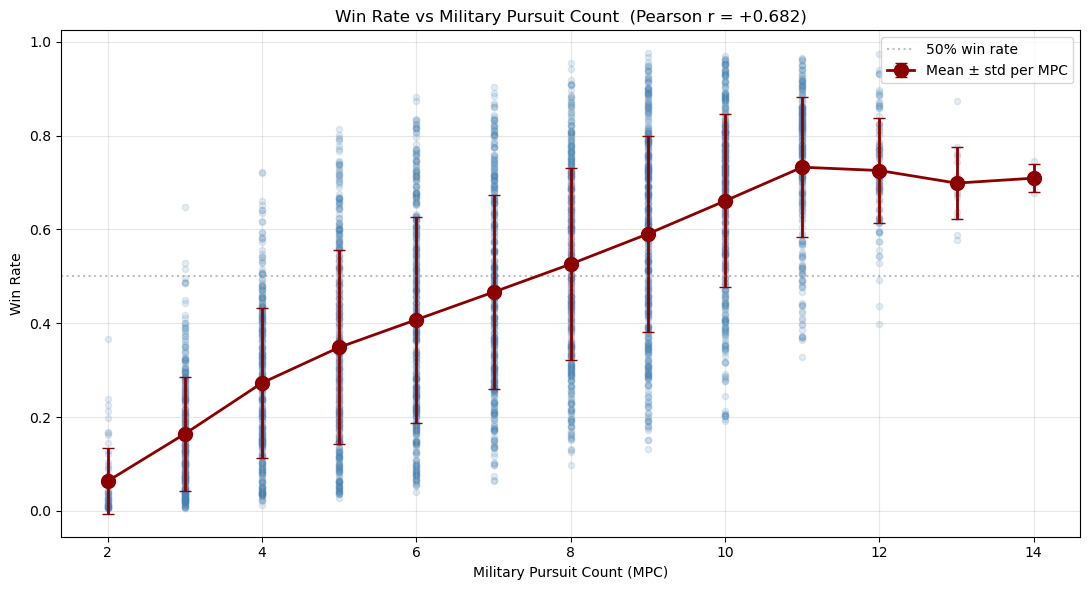

In [10]:
# Visualize: MPC vs Win Rate scatter + binned mean line
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(g["military_pursuit_count"], g["win_rate"], alpha=0.15, s=20, color="steelblue")
binned = g.groupby("military_pursuit_count")["win_rate"].agg(["mean", "std", "count"])
ax.errorbar(binned.index, binned["mean"], yerr=binned["std"], fmt="o-", color="darkred",
            markersize=10, linewidth=2, capsize=4, label="Mean ± std per MPC")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="50% win rate")
ax.set_xlabel("Military Pursuit Count (MPC)")
ax.set_ylabel("Win Rate")
ax.set_title(f"Win Rate vs Military Pursuit Count  (Pearson r = {pearson_r:+.3f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

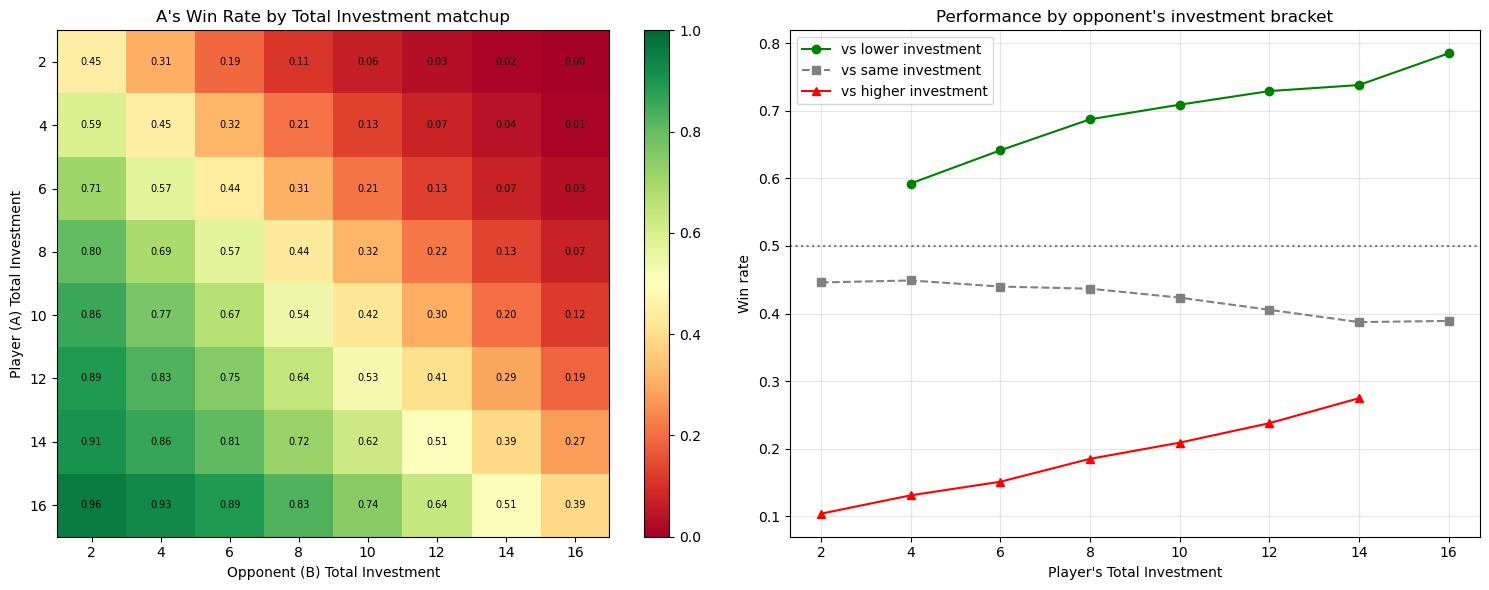


Key check: GREEN above 0.5 (you beat lighter builds)?  RED below 0.5?


<Figure size 640x480 with 0 Axes>

In [11]:
# ============ CELL 1 — heatmap + bracket curves by TOTAL INVESTMENT ============
TI_BIN = 2  # bin width; set to 1 for raw values

def _ti_bin(s):
    return (np.floor(s / TI_BIN) * TI_BIN).astype(int) if TI_BIN > 1 else s

# Derive total investment from the pursuits list, map onto the matchup pairs
gi = df_main_summary.copy()
gi["total_investment"] = gi["pursuits"].fillna("").map(
    lambda s: len([x for x in s.split("|") if x]) if s else 0)
ti_map = gi.set_index("name")["total_investment"]

dfp = df_main_matchups.copy()
dfp["a_ti"] = dfp["a_name"].map(ti_map)
dfp["b_ti"] = dfp["b_name"].map(ti_map)
dfp["a_ti_bin"] = _ti_bin(dfp["a_ti"])
dfp["b_ti_bin"] = _ti_bin(dfp["b_ti"])
pivot_wr_ti = dfp.pivot_table(index="a_ti_bin", columns="b_ti_bin",
                              values="a_win_rate", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
im = ax.imshow(pivot_wr_ti.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot_wr_ti.columns))); ax.set_xticklabels(pivot_wr_ti.columns)
ax.set_yticks(range(len(pivot_wr_ti.index))); ax.set_yticklabels(pivot_wr_ti.index)
ax.set_xlabel("Opponent (B) Total Investment"); ax.set_ylabel("Player (A) Total Investment")
ax.set_title("A's Win Rate by Total Investment matchup")
plt.colorbar(im, ax=ax)
for i in range(len(pivot_wr_ti.index)):
    for j in range(len(pivot_wr_ti.columns)):
        v = pivot_wr_ti.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="black", fontsize=7)

ax = axes[1]
rows = []
for a_ti in sorted(pivot_wr_ti.index):
    higher = pivot_wr_ti.loc[a_ti, pivot_wr_ti.columns > a_ti].dropna()
    lower  = pivot_wr_ti.loc[a_ti, pivot_wr_ti.columns < a_ti].dropna()
    same   = pivot_wr_ti.loc[a_ti, [a_ti] if a_ti in pivot_wr_ti.columns else []]
    rows.append({"ti": a_ti,
                 "vs_lower_mean":  lower.mean()  if len(lower)  else np.nan,
                 "vs_higher_mean": higher.mean() if len(higher) else np.nan,
                 "vs_same_mean":   same.mean()   if len(same)   else np.nan})
df_vs = pd.DataFrame(rows)
ax.plot(df_vs["ti"], df_vs["vs_lower_mean"], "o-", color="green", label="vs lower investment")
ax.plot(df_vs["ti"], df_vs["vs_same_mean"], "s--", color="gray", label="vs same investment")
ax.plot(df_vs["ti"], df_vs["vs_higher_mean"], "^-", color="red", label="vs higher investment")
ax.axhline(0.5, color="black", linestyle=":", alpha=0.5)
ax.set_xlabel("Player's Total Investment"); ax.set_ylabel("Win rate")
ax.set_title("Performance by opponent's investment bracket")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("\nKey check: GREEN above 0.5 (you beat lighter builds)?  RED below 0.5?")
plt.savefig(os.path.join(OUT_DIR, "Performance_by_opponent_investment"), dpi=110, bbox_inches="tight"); plt.show()

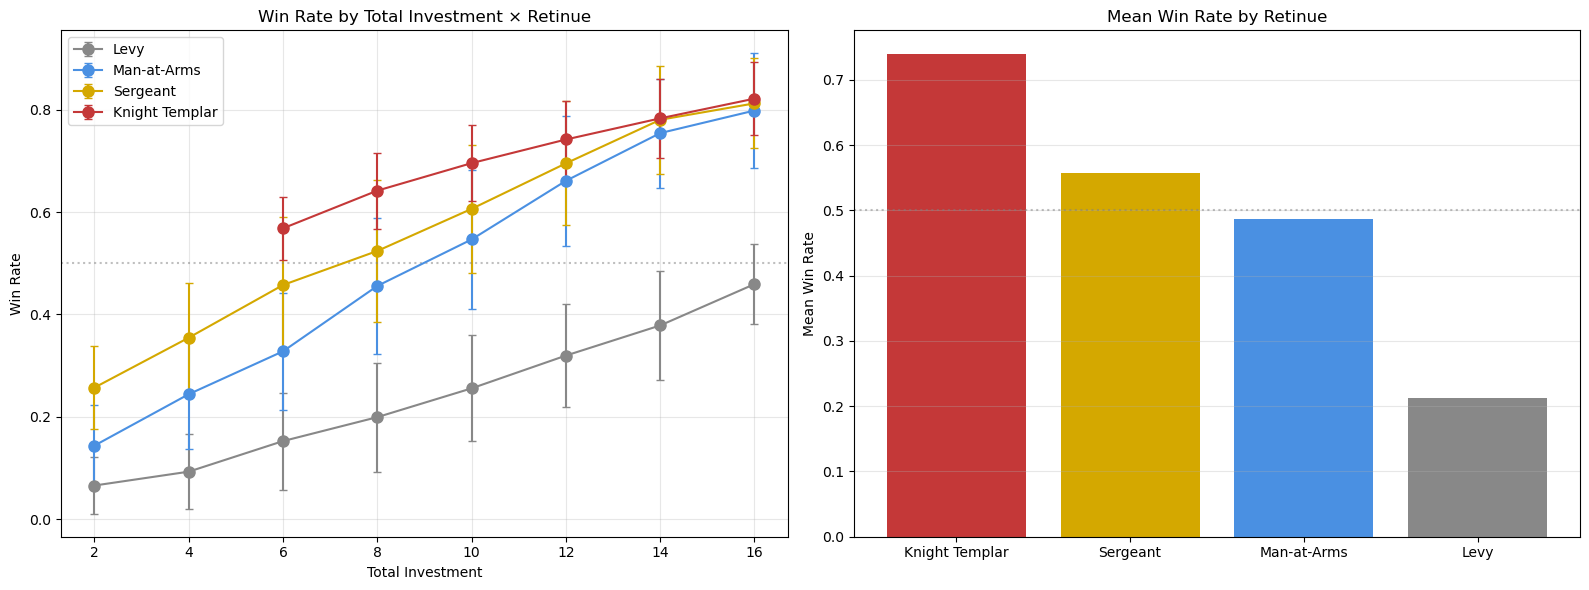

In [12]:
# ============ CELL 2 — win rate by retinue × TOTAL INVESTMENT ============
TI_BIN = 2  # match cell 1

df_ms = df_main_summary.copy()
df_ms["total_investment"] = df_ms["pursuits"].fillna("").map(
    lambda s: len([x for x in s.split("|") if x]) if s else 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
for ret, color in zip(["Levy","Man-at-Arms","Sergeant","Knight Templar"],
                       ["#888","#4a90e2","#d4a800","#c43838"]):
    sub = df_ms[df_ms["retinue"] == ret].copy()
    sub["ti_bin"] = (np.floor(sub["total_investment"] / TI_BIN) * TI_BIN).astype(int) \
                    if TI_BIN > 1 else sub["total_investment"]
    binned = sub.groupby("ti_bin")["win_rate"].agg(["mean","std","count"])
    binned = binned[binned["count"] >= 3]
    if len(binned) > 0:
        ax.errorbar(binned.index, binned["mean"], yerr=binned["std"],
                    fmt="o-", color=color, label=ret, capsize=3, markersize=8)
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Total Investment")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate by Total Investment × Retinue")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ret_means = df_ms.groupby("retinue")["win_rate"].mean().sort_values(ascending=False)
colors = {"Levy":"#888","Man-at-Arms":"#4a90e2","Sergeant":"#d4a800","Knight Templar":"#c43838"}
ax.bar(ret_means.index, ret_means.values, color=[colors[r] for r in ret_means.index])
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_ylabel("Mean Win Rate")
ax.set_title("Mean Win Rate by Retinue")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "winrate_by_total_investment"), dpi=110, bbox_inches="tight"); plt.show()

## 2.2 MPC bucket summary — does higher always win?

Test: for every loadout at MPC=N, what fraction of opponents at MPC<N do they beat? At MPC>N? Cross-budget head-to-head is the strict test of "spending more should win more."

In [13]:
# Build cross-MPC win rate matrix from matchups
df_m = df_main_matchups
df_m["a_mpc_bucket"] = df_m["a_military_pursuit_count"]
df_m["b_mpc_bucket"] = df_m["b_military_pursuit_count"]
# Aggregate wins/losses per (a_mpc, b_mpc) pair
grp = df_m.groupby(["a_mpc_bucket", "b_mpc_bucket"]).agg(
    a_wins=("a_wins", "sum"), b_wins=("b_wins", "sum"),
    mut=("mut_wipe", "sum"), indec=("indecisive", "sum"),
).reset_index()
grp["total"] = grp[["a_wins","b_wins","mut","indec"]].sum(axis=1)
grp["a_win_rate"] = grp["a_wins"] / grp["total"]
grp["decisive_rate"] = (grp["a_wins"] + grp["b_wins"]) / grp["total"]

# Pivot: rows = A's MPC, cols = B's MPC, value = A's win rate
pivot_wr = grp.pivot(index="a_mpc_bucket", columns="b_mpc_bucket", values="a_win_rate")
pivot_dec = grp.pivot(index="a_mpc_bucket", columns="b_mpc_bucket", values="decisive_rate")

print("=== A's Win Rate by (A_MPC, B_MPC) — values show how often A beats B ===")
print(pivot_wr.round(3).to_string())
print()
print("Diagonal = mirror MPC. Above diagonal: A has more budget than B (should win).")

=== A's Win Rate by (A_MPC, B_MPC) — values show how often A beats B ===
b_mpc_bucket     2      3      4      5      6      7      8      9      10     11     12     13     14
a_mpc_bucket                                                                                           
2             0.389  0.212  0.115  0.079  0.056  0.034  0.020  0.011  0.006  0.002  0.002  0.001  0.000
3             0.650  0.439  0.290  0.220  0.168  0.114  0.078  0.050  0.030  0.013  0.011  0.009  0.005
4             0.787  0.602  0.446  0.362  0.296  0.221  0.164  0.115  0.075  0.041  0.032  0.028  0.012
5             0.831  0.668  0.521  0.437  0.373  0.297  0.232  0.176  0.128  0.082  0.073  0.072  0.044
6             0.866  0.724  0.586  0.497  0.432  0.353  0.283  0.219  0.165  0.114  0.108  0.112  0.070
7             0.906  0.790  0.662  0.570  0.504  0.423  0.345  0.268  0.208  0.148  0.150  0.164  0.116
8             0.929  0.831  0.719  0.633  0.571  0.492  0.412  0.330  0.260  0.191  0.197  0.21

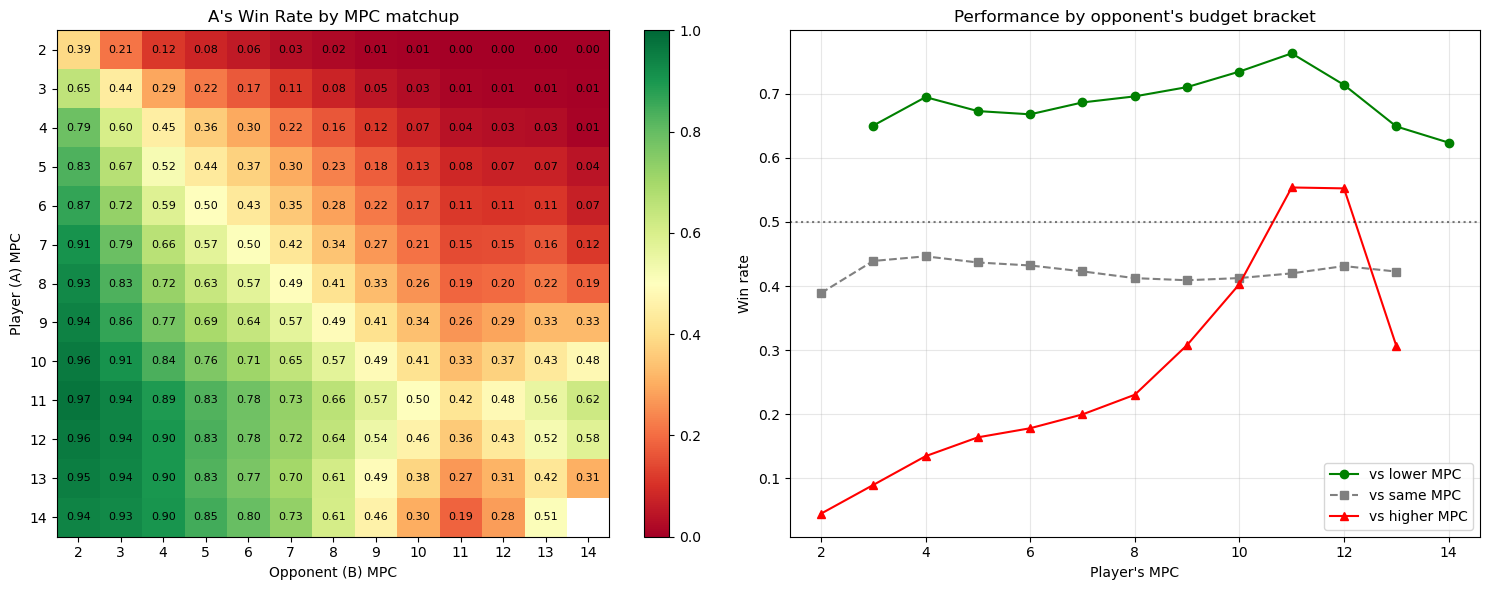


Key check: does the GREEN line stay above 0.5 (you beat lower-MPC opponents)?
Does the RED line stay below 0.5 (you lose to higher-MPC opponents)?


In [14]:
# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
im = ax.imshow(pivot_wr.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot_wr.columns))); ax.set_xticklabels(pivot_wr.columns)
ax.set_yticks(range(len(pivot_wr.index))); ax.set_yticklabels(pivot_wr.index)
ax.set_xlabel("Opponent (B) MPC"); ax.set_ylabel("Player (A) MPC")
ax.set_title("A's Win Rate by MPC matchup")
plt.colorbar(im, ax=ax)
# Annotate
for i in range(len(pivot_wr.index)):
    for j in range(len(pivot_wr.columns)):
        v = pivot_wr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="black", fontsize=8)

ax = axes[1]
# Average win rate over LOWER vs HIGHER MPC opponents per row
rows = []
for a_mpc in sorted(pivot_wr.index):
    higher = pivot_wr.loc[a_mpc, pivot_wr.columns > a_mpc].dropna()
    lower  = pivot_wr.loc[a_mpc, pivot_wr.columns < a_mpc].dropna()
    same   = pivot_wr.loc[a_mpc, [a_mpc] if a_mpc in pivot_wr.columns else []]
    rows.append({
        "mpc": a_mpc,
        "vs_lower_mean": lower.mean() if len(lower) else np.nan,
        "vs_higher_mean": higher.mean() if len(higher) else np.nan,
        "vs_same_mean": same.mean() if len(same) else np.nan,
    })
df_vs = pd.DataFrame(rows)
ax.plot(df_vs["mpc"], df_vs["vs_lower_mean"], "o-", color="green", label="vs lower MPC")
ax.plot(df_vs["mpc"], df_vs["vs_same_mean"], "s--", color="gray", label="vs same MPC")
ax.plot(df_vs["mpc"], df_vs["vs_higher_mean"], "^-", color="red", label="vs higher MPC")
ax.axhline(0.5, color="black", linestyle=":", alpha=0.5)
ax.set_xlabel("Player's MPC"); ax.set_ylabel("Win rate")
ax.set_title("Performance by opponent's budget bracket")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nKey check: does the GREEN line stay above 0.5 (you beat lower-MPC opponents)?")
print("Does the RED line stay below 0.5 (you lose to higher-MPC opponents)?")

## 2.1b Correlation: Win Rate ↔ Total Investment (action economy)

`total_investment` counts **every** pursuit a build owns (each = 1), with NO *Efficient X* discount —
it measures the action economy (how many pursuit-decisions were spent), whereas MPC measures
settlement space (and IS reduced by satisfied *Efficient X*). The hypothesis: total_investment is a
*more monotonic* predictor of win rate than MPC, because MPC's space-discount lets deep-teched gear
look artificially cheap. This cell compares the two head-to-head.

In [15]:
from scipy import stats as sp_stats
import numpy as np

# total_investment = raw count of pursuits (every pursuit = 1; Efficient-X does NOT reduce it).
# Derived from the "pursuits" column ("|"-joined). MPC is military_pursuit_count (space, discounted).
gi = df_main_summary.copy()
gi["total_investment"] = gi["pursuits"].fillna("").map(
    lambda s: len([x for x in s.split("|") if x]) if s else 0)

ti_r,  ti_p  = sp_stats.pearsonr(gi["total_investment"], gi["win_rate"])
ti_sr, ti_sp = sp_stats.spearmanr(gi["total_investment"], gi["win_rate"])
mpc_r,  _    = sp_stats.pearsonr(gi["military_pursuit_count"], gi["win_rate"])
mpc_sr, _    = sp_stats.spearmanr(gi["military_pursuit_count"], gi["win_rate"])

print("=== Win Rate ↔ Total Investment  vs  ↔ MPC ===")
print(f"  total_investment : Pearson {ti_r:+.3f} (p={ti_p:.2e}) | Spearman {ti_sr:+.3f}")
print(f"  MPC (space)      : Pearson {mpc_r:+.3f}              | Spearman {mpc_sr:+.3f}")
print()
print(f"  Spearman is the monotonicity measure (rank correlation). Higher = more monotonic.")
print(f"  total_investment Spearman {ti_sr:+.3f}  vs  MPC Spearman {mpc_sr:+.3f}"
      f"  -> {'total_investment MORE monotonic' if ti_sr>mpc_sr else 'MPC more monotonic'}")
print()

# How far apart MPC and total_investment run (the Efficient-X gap)
gap = (gi["total_investment"] - gi["military_pursuit_count"])
print(f"  total_investment − MPC gap: mean {gap.mean():.2f}, max {gap.max()} "
      f"(0 = no efficiency discount; larger = deeper Efficient-X stacking)")


=== Win Rate ↔ Total Investment  vs  ↔ MPC ===
  total_investment : Pearson +0.721 (p=0.00e+00) | Spearman +0.720
  MPC (space)      : Pearson +0.682              | Spearman +0.681

  Spearman is the monotonicity measure (rank correlation). Higher = more monotonic.
  total_investment Spearman +0.720  vs  MPC Spearman +0.681  -> total_investment MORE monotonic

  total_investment − MPC gap: mean 2.48, max 8 (0 = no efficiency discount; larger = deeper Efficient-X stacking)


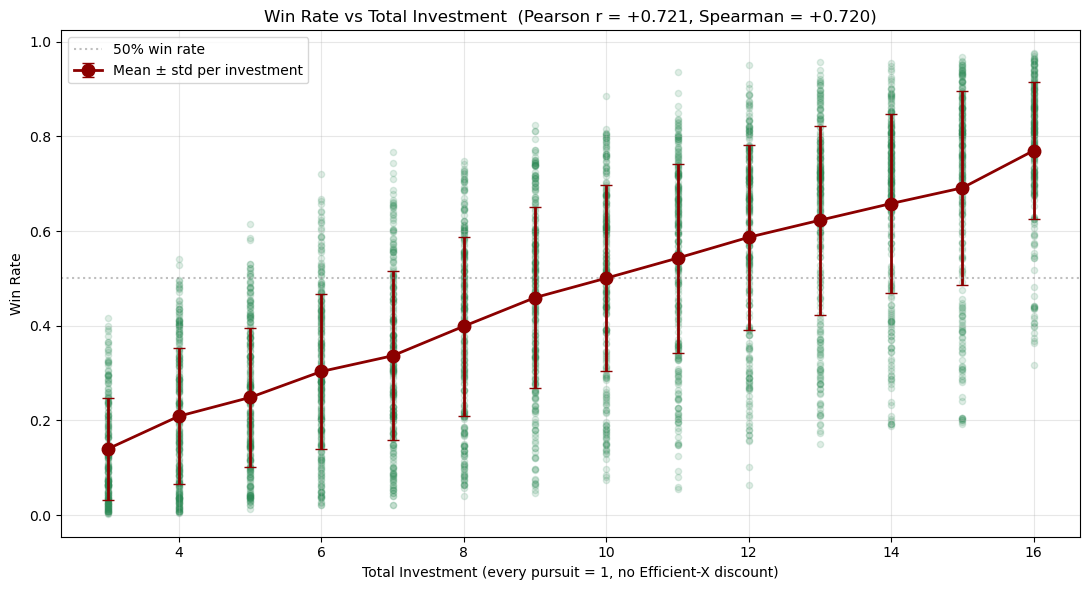

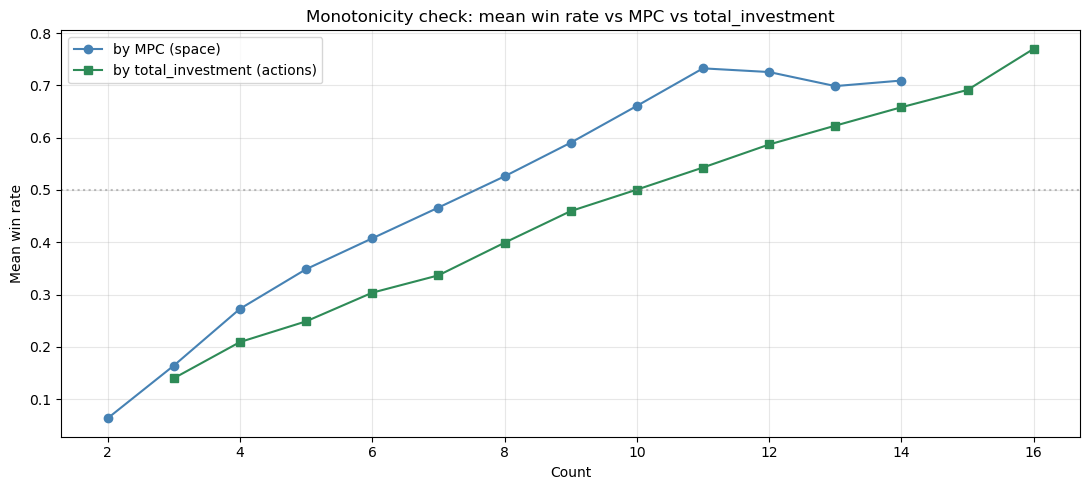

In [16]:
# Visualize: Total Investment vs Win Rate scatter + binned mean line (compare to the MPC plot)
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(gi["total_investment"], gi["win_rate"], alpha=0.15, s=20, color="seagreen")
binned = gi.groupby("total_investment")["win_rate"].agg(["mean", "std", "count"])
ax.errorbar(binned.index, binned["mean"], yerr=binned["std"], fmt="o-", color="darkred",
            markersize=9, linewidth=2, capsize=4, label="Mean ± std per investment")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="50% win rate")
ax.set_xlabel("Total Investment (every pursuit = 1, no Efficient-X discount)")
ax.set_ylabel("Win Rate")
ax.set_title(f"Win Rate vs Total Investment  (Pearson r = {ti_r:+.3f}, Spearman = {ti_sr:+.3f})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Side-by-side per-bucket means: does investment climb more smoothly than MPC?
inv_means = gi.groupby("total_investment")["win_rate"].mean()
mpc_means = gi.groupby("military_pursuit_count")["win_rate"].mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mpc_means.index, mpc_means.values, "o-", color="steelblue", label="by MPC (space)")
ax.plot(inv_means.index, inv_means.values, "s-", color="seagreen", label="by total_investment (actions)")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Count"); ax.set_ylabel("Mean win rate")
ax.set_title("Monotonicity check: mean win rate vs MPC vs total_investment")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


  THE STORY OF A BATTLE  —  465,659,600 battles

A typical engagement runs about 4.4 skirmishes. When the dust settles,
86% of battles have a clear winner; the attacker takes
44% and the defender 42% — close to
even, so the initiator slot is not a strong edge. 11% of battles end
in MUTUAL annihilation, and only 3.0% peter out indecisively.

The two sides leave roughly 6 and 6
survivors on average. Of every casualty inflicted, 65% fall in direct
combat, 23% break from exhaustion (shaken), 7% break
under heavy losses (waver), and 5% are cut down in the rout. Shields are destroyed in
1.9% of battles.

WHAT WINS BATTLES (correlation of each combat stat with win rate):
   shaking     -0.62  ##################             (lower is better)
   to_hit      -0.50  ###############                (lower is better)
   eff_save    -0.22  ######                         (lower is better)
   weapon_ap   -0.16  ####                           (lower is better)
   init        -0.04  #                    

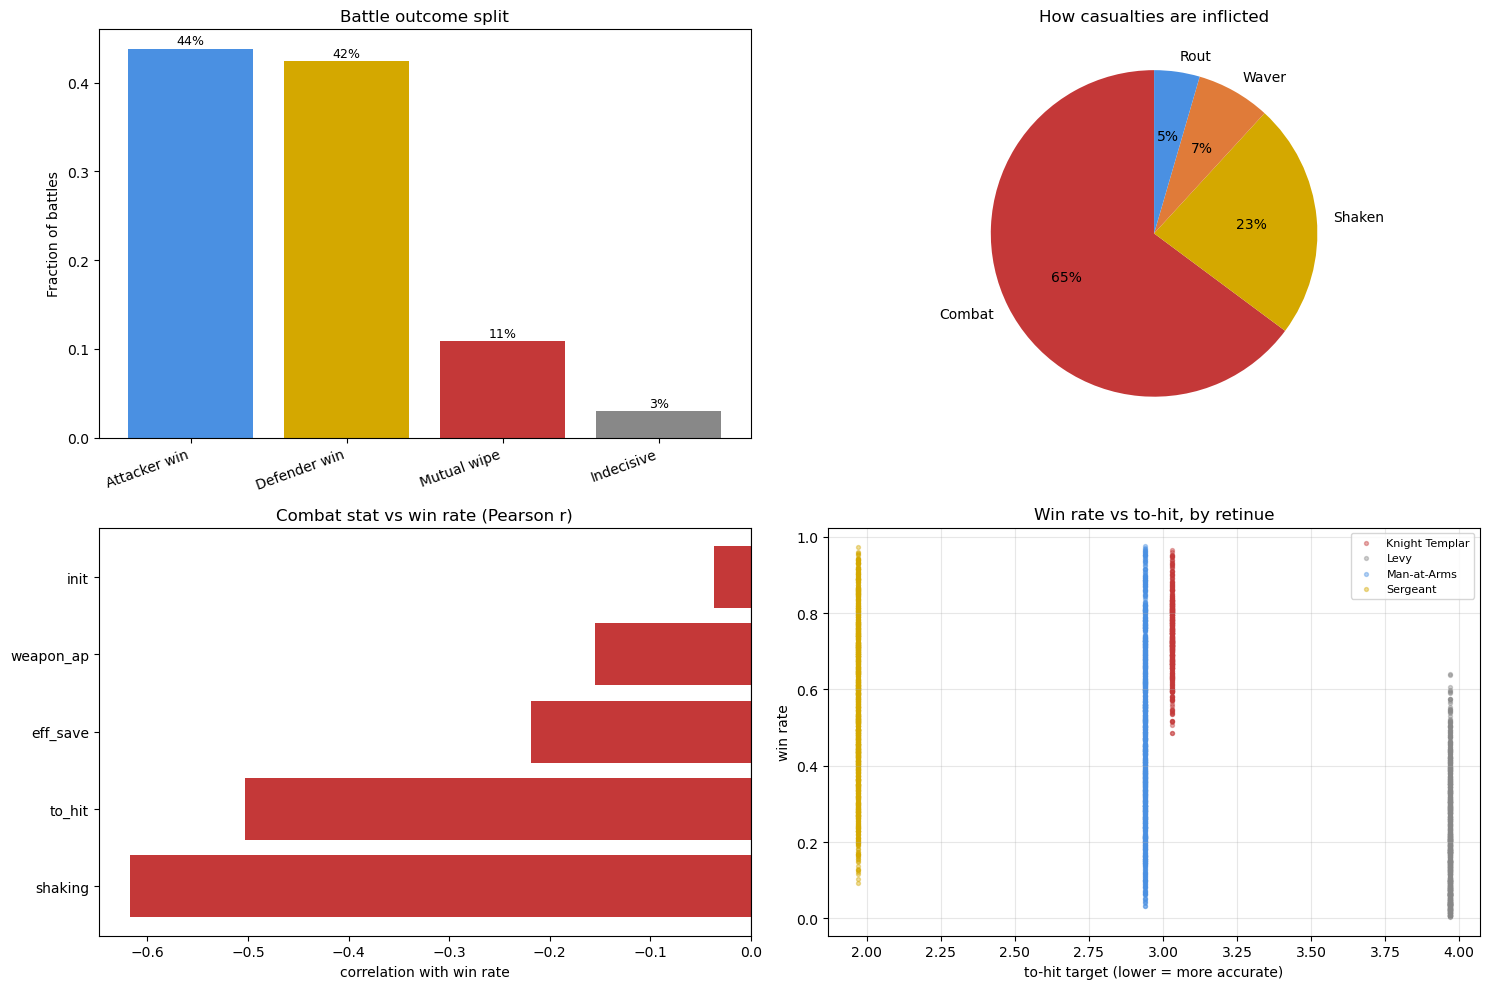

In [17]:
# ── Battle overview + combat-stat correlations + narrative ──
import matplotlib.pyplot as plt
import analysis
import loadouts as L, playstyles, analysis

# reload the EXACT pool the tournament ran on, from its saved CSV companion
MAIN_POOL = L.archetype_pool(csv_path=LOADOUT_CSV)  # match your run's tag
# if the tournament assigned playstyles, re-apply the same default so names/state match:
MAIN_POOL = [p._replace(playstyle=playstyles.assign_default_playstyle(p)) for p in MAIN_POOL]
ov   = analysis.battle_overview(df_main_matchups)
st   = analysis.build_stat_table(MAIN_POOL)
m, corr = analysis.stat_winrate_correlation(df_main_summary, st)

pop = {"avg_to_hit": st["to_hit"].mean(), "avg_init": st["init"].mean(),
       "avg_eff_save": st["eff_save"].mean(), "avg_endurance": st["endurance"].mean()}

print("=" * 68)
print("  THE STORY OF A BATTLE  —  {:,} battles".format(ov["total_battles"]))
print("=" * 68)
print(f"""
A typical engagement runs about {ov['avg_skirmishes']:.1f} skirmishes. When the dust settles,
{ov['decisive_rate']*100:.0f}% of battles have a clear winner; the attacker takes
{ov['attacker_win_rate']*100:.0f}% and the defender {ov['defender_win_rate']*100:.0f}% — close to
even, so the initiator slot is not a strong edge. {ov['mutual_wipe_rate']*100:.0f}% of battles end
in MUTUAL annihilation, and only {ov['indecisive_rate']*100:.1f}% peter out indecisively.

The two sides leave roughly {ov['avg_attacker_survivors']:.0f} and {ov['avg_defender_survivors']:.0f}
survivors on average. Of every casualty inflicted, {ov['kill_mix_combat_pct']*100:.0f}% fall in direct
combat, {ov['kill_mix_shake_pct']*100:.0f}% break from exhaustion (shaken), {ov['kill_mix_waver_pct']*100:.0f}% break
under heavy losses (waver), and {ov['kill_mix_rout_pct']*100:.0f}% are cut down in the rout. Shields are destroyed in
{ov['avg_shield_destroyed_rate']*100:.1f}% of battles.

WHAT WINS BATTLES (correlation of each combat stat with win rate):""")
for _, r in corr.iterrows():
    s = r["stat"]; c = r["corr_with_win_rate"]
    better = "lower is better" if s in ("to_hit","eff_save","shaking","weapon_ap") else "higher is better"
    print(f"   {s:11s} {c:+.2f}  {'#'*int(abs(c)*30):30s} ({better})")
print(f"""
Innate ACCURACY (to-hit) and MORALE (shaking) dominate — they outweigh weapon AP and initiative.
Endurance is the strongest positive driver. Population averages: to-hit {pop['avg_to_hit']:.1f},
initiative {pop['avg_init']:+.1f}, effective save {pop['avg_eff_save']:.1f}, endurance {pop['avg_endurance']:.1f}.
""")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax = axes[0,0]
labels = ["Attacker win","Defender win","Mutual wipe","Indecisive"]
vals = [ov["attacker_win_rate"], ov["defender_win_rate"], ov["mutual_wipe_rate"], ov["indecisive_rate"]]
ax.bar(labels, vals, color=["#4a90e2","#d4a800","#c43838","#888"])
ax.set_title("Battle outcome split"); ax.set_ylabel("Fraction of battles")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=20, ha="right")
for i,v in enumerate(vals): ax.text(i, v+0.005, f"{v*100:.0f}%", ha="center", fontsize=9)
ax = axes[0,1]
mix = [ov["kill_mix_combat_pct"], ov["kill_mix_shake_pct"], ov.get("kill_mix_waver_pct",0.0), ov["kill_mix_rout_pct"]]
ax.pie(mix, labels=["Combat","Shaken","Waver","Rout"], autopct="%1.0f%%",
       colors=["#c43838","#d4a800","#e07b39","#4a90e2"], startangle=90)
ax.set_title("How casualties are inflicted")
ax = axes[1,0]
cc = corr.sort_values("corr_with_win_rate")
ax.barh(cc["stat"], cc["corr_with_win_rate"], color=["#c43838" if v<0 else "#4a90e2" for v in cc["corr_with_win_rate"]])
ax.axvline(0, color="k", lw=0.8); ax.set_title("Combat stat vs win rate (Pearson r)")
ax.set_xlabel("correlation with win rate")
ax = axes[1,1]
ret_colors={"Levy":"#888","Man-at-Arms":"#4a90e2","Sergeant":"#d4a800","Knight Templar":"#c43838"}
for ret,grp in m.groupby("retinue"):
    ax.scatter(grp["to_hit"]+(hash(ret)%5-2)*0.03, grp["win_rate"], s=8, alpha=0.4, label=ret, color=ret_colors.get(ret,"#555"))
ax.set_xlabel("to-hit target (lower = more accurate)"); ax.set_ylabel("win rate")
ax.set_title("Win rate vs to-hit, by retinue"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "battle_overview"), dpi=110, bbox_inches="tight"); plt.show()

=== Equipment value by slot × tier (head-to-head, equal-TI) ===
    member_wr = win rate of the side that has this gear vs a side that doesn't, equal investment
  slot    tier                   gate  cost_pts  pairs  member_wr   lift  lift_per_pt
weapon    Cast                Furnace       1.0 354820      0.447 -0.053      -0.0534
weapon Wrought             Blacksmith       2.0 726436      0.568  0.068       0.0341
weapon  Forged                  Forge       3.0 713076      0.528  0.028       0.0093
weapon Crafted Advanced Blast Furnace       9.0  40230      0.500 -0.000      -0.0001
 armor    Cast                Tannery       1.0 426542      0.404 -0.096      -0.0961
 armor Wrought                 Armory       4.0 475486      0.406 -0.094      -0.0235
 armor  Forged         Gilded Foundry       5.0 418940      0.487 -0.013      -0.0026
 armor Crafted         Gilded Foundry       5.0 133078      0.444 -0.056      -0.0111
shield    Cast                Joinery       2.0 116026      0.359

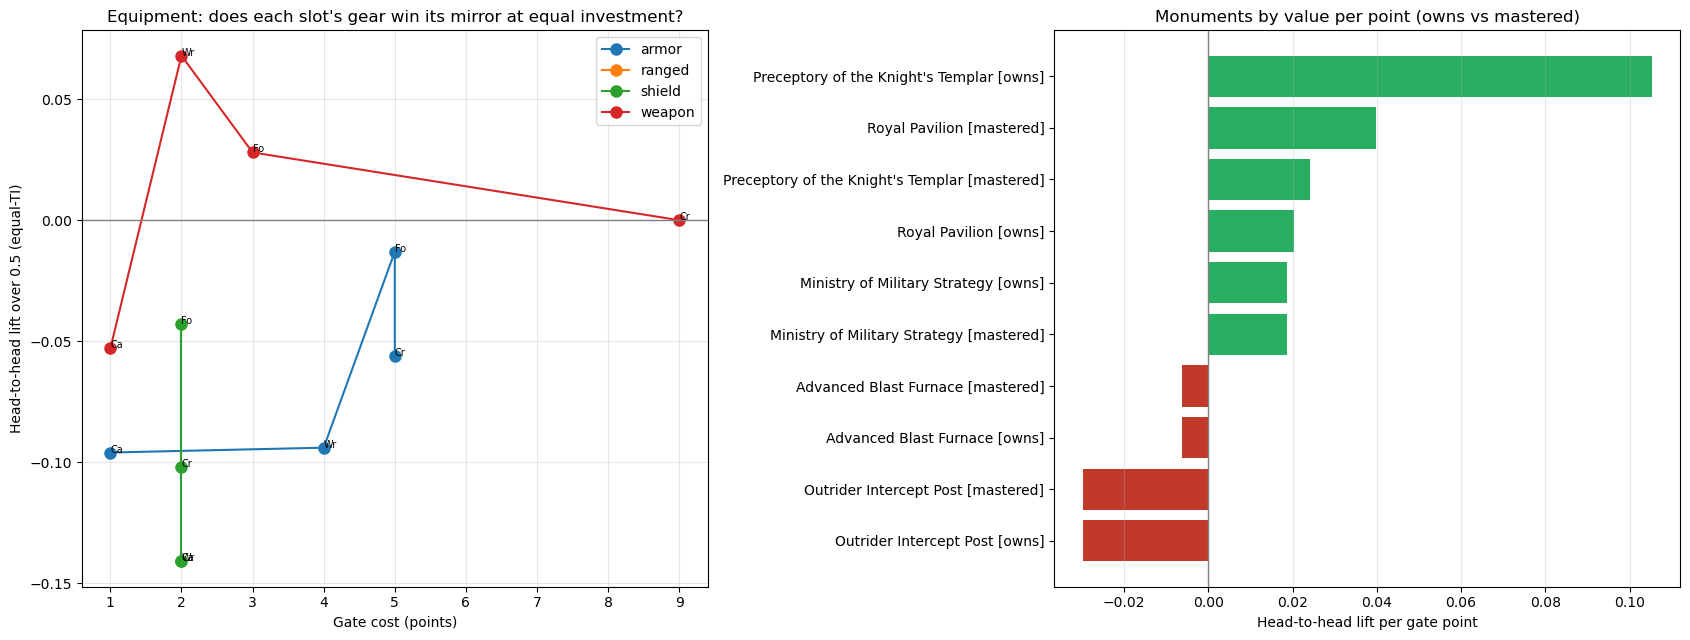


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\value_headtohead.png


In [18]:
# ============================================================================
# Equipment (slot × tier) + Monument value — MATCHUP-LEVEL, equal investment
# Requires: df_main_summary (build attrs) and df_main_matchups (a_name, b_name,
#           a_win_rate) and OUT_DIR.
# ============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
import renown_data as rd

MIN_PAIRS = 80      # min contested equal-TI pairs for a bucket to count
EQ_TOL    = 1
ENG = {n: v["engine"] for n, v in rd.NODES.items() if "engine" in v}

def closure(name, seen=None):
    seen = seen or set()
    if name in seen or name not in ENG: return seen
    seen.add(name)
    for p in ENG[name].get("prereqs", []): closure(p, seen)
    return seen
def cost_incl(node, mastery=False):
    c = set(closure(node))
    if mastery:
        for r in ENG.get(node, {}).get("mastery_req", []): c |= closure(r)
    return max(1, len(c))

# ── build-attribute table (indexed by build name) from the summary ──
bi = df_main_summary.copy()
for c in ["shield", "ranged"]:
    bi[c] = bi[c].replace("", "None").fillna("None")
bi["pset"] = bi["pursuits"].fillna("").map(lambda s: {x for x in s.split("|") if x})
bi["ti"]   = bi["pset"].map(len)
bi = bi.set_index("name")
TI = bi["ti"]

# ── matchup frame: resolve names -> ti, win rate of side A ──
mp = df_main_matchups.copy()
awr_col = "a_win_rate" if "a_win_rate" in mp.columns else ("win_rate" if "win_rate" in mp.columns else None)
assert awr_col, f"need a_win_rate in matchups; cols={list(mp.columns)}"
mp["a_ti"] = mp["a_name"].map(TI)
mp["b_ti"] = mp["b_name"].map(TI)
mp = mp.dropna(subset=["a_ti", "b_ti"])
eq_mask = (mp["a_ti"] - mp["b_ti"]).abs() <= EQ_TOL
mp_eq = mp[eq_mask].copy()
awr = mp_eq[awr_col].astype(float)

def headtohead(memb):
    """Win rate of the bucket-owning side among equal-TI pairs where exactly
    one side owns it. Returns (member_wr, n_pairs)."""
    a_mem = mp_eq["a_name"].map(memb).fillna(False).to_numpy()
    b_mem = mp_eq["b_name"].map(memb).fillna(False).to_numpy()
    xor = a_mem ^ b_mem
    if xor.sum() < MIN_PAIRS:
        return np.nan, int(xor.sum())
    a_is_member = a_mem[xor]
    a_rate = awr.to_numpy()[xor]
    member_rate = np.where(a_is_member, a_rate, 1.0 - a_rate)
    return float(member_rate.mean()), int(xor.sum())

# ============================================================================
# PART 1 — Equipment value by slot × tier
# ============================================================================
TIERMAP = {"weapon": {w: x["tier"] for w, x in rd.WEAPONS.items()},
           "armor":  {a: x["tier"] for a, x in rd.ARMORS.items()},
           "shield": {s: x["tier"] for s, x in rd.SHIELDS.items() if s},
           "ranged": {r: x["tier"] for r, x in rd.RANGED.items()}}

def gate_for(slot, tier):
    if slot == "weapon":
        node = rd.TIER_UNLOCK.get(tier)
        rank = "mastery" if node and any("tier:" in t for t in ENG.get(node, {}).get("mastery_tags", [])) else "innate"
        return node, rank
    want = {"armor":  {"Cast": "Leather", "Wrought": "Chainmail", "Forged": "FullPlate", "Crafted": "FullPlate"},
            "shield": {t: "Shields" for t in ["Cast", "Wrought", "Forged", "Crafted"]},
            "ranged": {}}.get(slot, {}).get(tier)
    if want:
        for node, e in ENG.items():
            for rank in ("innate", "mastery"):
                if any(t == f"tier:{want}" for t in e.get(f"{rank}_tags", [])):
                    return node, rank
    return None, None

eq_rows = []
for slot in ["weapon", "armor", "shield", "ranged"]:
    for tier in ["Cast", "Wrought", "Forged", "Crafted"]:
        items = set(k for k, t in TIERMAP[slot].items() if t == tier)
        memb = (bi[slot].isin(items)).to_dict()
        wr_m, n = headtohead(memb)
        if np.isnan(wr_m):
            continue
        node, rank = gate_for(slot, tier)
        cost = cost_incl(node, mastery=(rank == "mastery")) if node else np.nan
        lift = wr_m - 0.5
        eq_rows.append({"slot": slot, "tier": tier, "gate": node, "cost_pts": cost,
                        "pairs": n, "member_wr": round(wr_m, 3), "lift": round(lift, 3),
                        "lift_per_pt": round(lift / cost, 4) if node else np.nan})

eq = pd.DataFrame(eq_rows)
pd.set_option("display.width", 200, "display.max_rows", 120)
print("=== Equipment value by slot × tier (head-to-head, equal-TI) ===")
print("    member_wr = win rate of the side that has this gear vs a side that doesn't, equal investment")
print(eq.to_string(index=False))
print("\nmember_wr (rows=slot, cols=tier):")
print(eq.pivot(index="slot", columns="tier", values="member_wr")
        .reindex(index=["weapon","armor","shield","ranged"],
                 columns=["Cast","Wrought","Forged","Crafted"]).to_string())

# ============================================================================
# PART 2 — Monument impact (ownership), owns vs mastered
# ============================================================================
MONUMENTS = [n for n, v in rd.NODES.items() if v.get("type") == "Monument" or v.get("monument")]
mon_rows = []
for m in MONUMENTS:
    e = ENG.get(m, {})
    sim_name = e.get("alias", m)                     # <-- the fix
    for rank, need in [("owns", frozenset({sim_name})),
                       ("mastered", frozenset({sim_name} | set(e.get("mastery_req", []))))]:
        memb = bi["pset"].map(lambda s, need=need: need <= s).to_dict()
        wr_m, n = headtohead(memb)
        if np.isnan(wr_m):
            continue
        cost = cost_incl(m, mastery=(rank == "mastered"))
        lift = wr_m - 0.5
        mon_rows.append({"monument": m, "rank": rank, "cost_pts": cost, "pairs": n,
                         "member_wr": round(wr_m, 3), "lift": round(lift, 3),
                         "lift_per_pt": round(lift / cost, 4)})

mon = pd.DataFrame(mon_rows).sort_values("lift_per_pt", ascending=False)
print("\n=== Monument impact (head-to-head ownership, equal-TI) ===")
print(mon.to_string(index=False))

# ============================================================================
# Figures
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
ax = axes[0]
for slot, g in eq.groupby("slot"):
    g = g.sort_values("cost_pts")
    ax.plot(g["cost_pts"], g["lift"], "o-", label=slot, markersize=8)
    for _, r in g.iterrows():
        ax.annotate(r["tier"][:2], (r["cost_pts"], r["lift"]), fontsize=7)
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("Gate cost (points)"); ax.set_ylabel("Head-to-head lift over 0.5 (equal-TI)")
ax.set_title("Equipment: does each slot's gear win its mirror at equal investment?")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
v = mon.sort_values("lift_per_pt")
ax.barh([f"{r.monument} [{r['rank']}]" for _, r in v.iterrows()], v["lift_per_pt"],
        color=["#c0392b" if x < 0 else "#27ae60" for x in v["lift_per_pt"]])
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("Head-to-head lift per gate point")
ax.set_title("Monuments by value per point (owns vs mastered)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "value_headtohead.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'value_headtohead.png')}")

coverage check (must be >0 or panels are empty):
  Serrated         A-side builds:  2156259
  Planishing       A-side builds:  1880410
  Deadly           A-side builds:        0
  Shatter Armor    A-side builds:        0
  Negate Tempered  A-side builds:        0
  Recover 5        A-side builds:  3117558
  Recover 4        A-side builds:  2416898


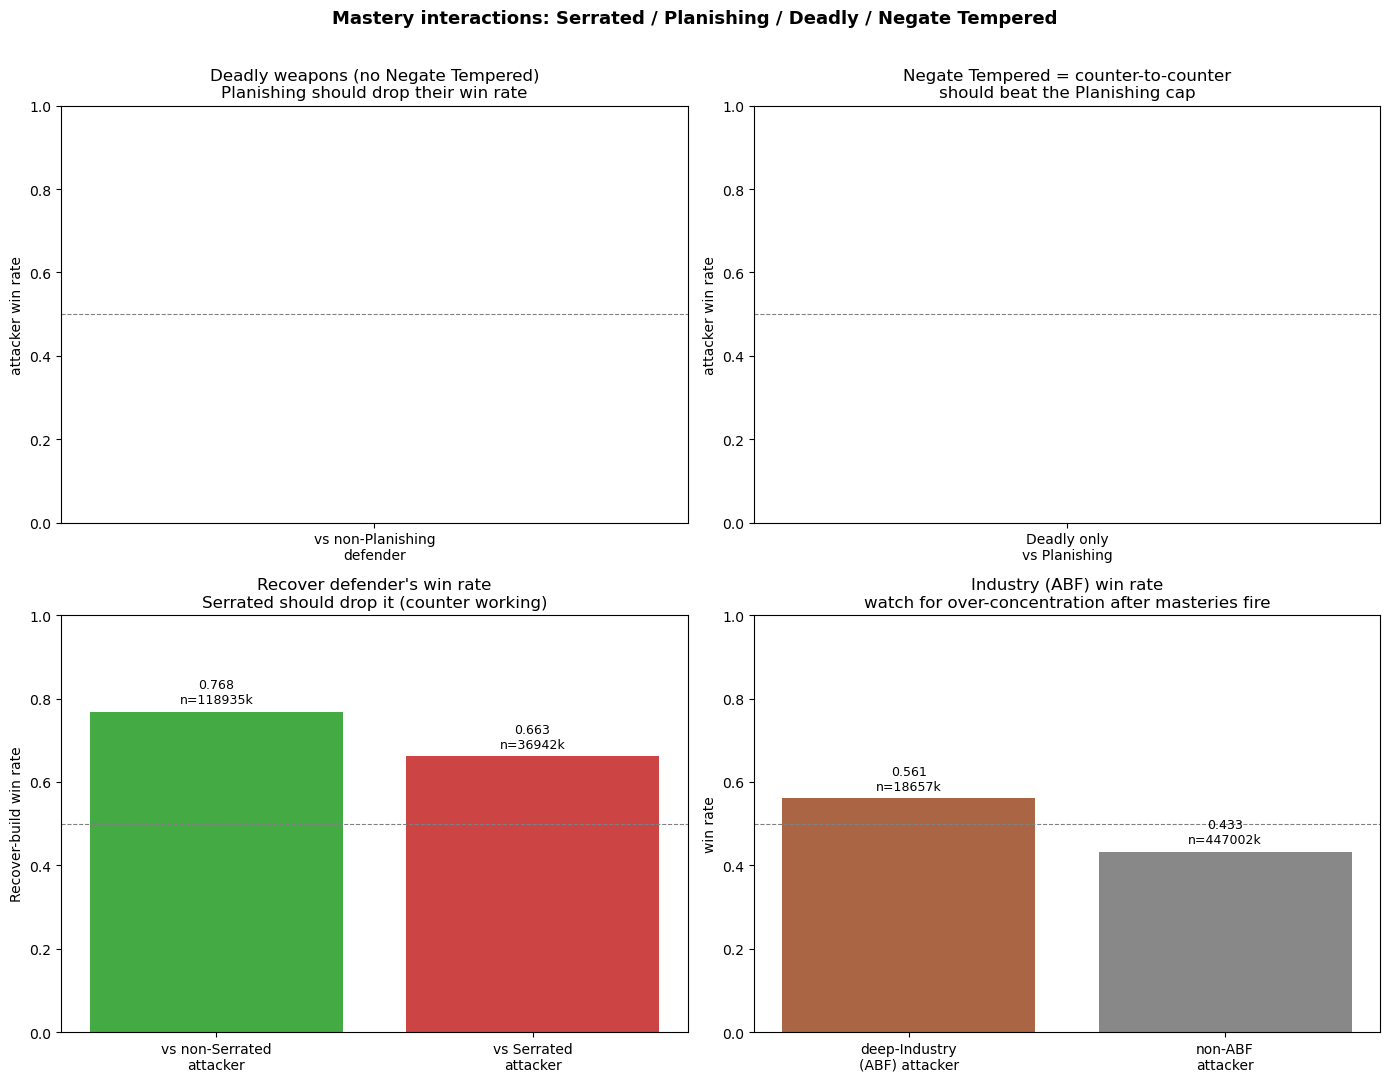

saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\mastery_interactions.png


In [19]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import os

m = df_main_matchups
OUT = r"C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out"

def has(col, tag):    # substring test on a tag column
    return m[col].str.contains(tag, na=False, regex=False)

def wr(sub):          # n_runs-weighted A win rate of a slice
    if len(sub)==0: return np.nan, 0
    w = sub["n_runs"].clip(lower=1)
    return np.average(sub["a_win_rate"], weights=w), int(w.sum())

# ---- guard: did the masteries actually come back? ----
print("coverage check (must be >0 or panels are empty):")
for t in ["Serrated","Planishing","Deadly","Shatter Armor","Negate Tempered","Recover 5","Recover 4"]:
    print(f"  {t:16s} A-side builds: {has('a_tags',t).sum():>8d}")

fig, ax = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Mastery interactions: Serrated / Planishing / Deadly / Negate Tempered", fontsize=13, fontweight="bold")
# ── Panel 1: Deadly attacker vs Planishing defender (Planishing should NERF Deadly) ──
deadly_atk = has("a_tags","Deadly") | has("a_tags","Shatter Armor")
no_negtemp = ~has("a_tags","Negate Tempered")
d = m[deadly_atk & no_negtemp]
d_plan = d["b_tags"].str.contains("Planishing", na=False, regex=False)
groups = {
    "vs non-Planishing\ndefender": d[~d_plan],
    "vs Planishing\ndefender":     d[d_plan],
}
vals, ns = [], []
for k,g in groups.items():
    v,n = wr(g); vals.append(v); ns.append(n)
b = ax[0,0].bar(list(groups.keys()), vals, color=["#c44","#48a"])
ax[0,0].set_title("Deadly weapons (no Negate Tempered)\nPlanishing should drop their win rate")
ax[0,0].set_ylabel("attacker win rate"); ax[0,0].axhline(0.5,ls="--",c="gray",lw=0.8)
ax[0,0].set_ylim(0,1)
for bar,v,n in zip(b,vals,ns):
    if not np.isnan(v): ax[0,0].text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.3f}\nn={n//1000}k", ha="center", fontsize=9)

# ── Panel 2: Negate Tempered vs Planishing (should RESTORE Deadly through the cap) ──
# Compare Deadly+NegTemp vs Planishing  TO  Deadly-only vs Planishing
def_plan = m["b_tags"].str.contains("Planishing", na=False, regex=False)
nt_vs_plan   = m[deadly_atk & has("a_tags","Negate Tempered") & def_plan]
no_nt_vs_plan= m[deadly_atk & ~has("a_tags","Negate Tempered") & def_plan]
vals2 = [wr(no_nt_vs_plan)[0], wr(nt_vs_plan)[0]]
ns2   = [wr(no_nt_vs_plan)[1], wr(nt_vs_plan)[1]]
b2 = ax[0,1].bar(["Deadly only\nvs Planishing","Deadly + Negate\nTempered vs Planishing"], vals2, color=["#48a","#4a4"])
ax[0,1].set_title("Negate Tempered = counter-to-counter\nshould beat the Planishing cap")
ax[0,1].set_ylabel("attacker win rate"); ax[0,1].axhline(0.5,ls="--",c="gray",lw=0.8); ax[0,1].set_ylim(0,1)
for bar,v,n in zip(b2,vals2,ns2):
    if not np.isnan(v): ax[0,1].text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.3f}\nn={n//1000}k", ha="center", fontsize=9)

# ── Panel 3: Recover defender vs Serrated attacker (Serrated should NERF Recover) ──
recov_def = has("b_tags","Recover 4") | has("b_tags","Recover 5") | has("b_tags","Recover 6")
r = m[recov_def]
vals3 = [
    wr(r[~r["a_tags"].str.contains("Serrated", na=False, regex=False)])[0],  # recover survives
    wr(r[ r["a_tags"].str.contains("Serrated", na=False, regex=False)])[0],  # recover suppressed
]
ns3 = [
    wr(r[~r["a_tags"].str.contains("Serrated", na=False, regex=False)])[1],
    wr(r[ r["a_tags"].str.contains("Serrated", na=False, regex=False)])[1],
]
# this is the DEFENDER's win rate, so invert: show Recover-defender's win rate (1 - a_win_rate)
vals3 = [1-v if not np.isnan(v) else v for v in vals3]
b3 = ax[1,0].bar(["vs non-Serrated\nattacker","vs Serrated\nattacker"], vals3, color=["#4a4","#c44"])
ax[1,0].set_title("Recover defender's win rate\nSerrated should drop it (counter working)")
ax[1,0].set_ylabel("Recover-build win rate"); ax[1,0].axhline(0.5,ls="--",c="gray",lw=0.8); ax[1,0].set_ylim(0,1)
for bar,v,n in zip(b3,vals3,ns3):
    if not np.isnan(v): ax[1,0].text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.3f}\nn={n//1000}k", ha="center", fontsize=9)

# ── Panel 4: Industry domain pairing shift (concentration risk) ──
# reuse the sov_pair logic: which two domains are Sovereign. Need domain cols on matchups.
# a_domain_count is a scalar; we need per-domain. Parse from a_pursuits via compute_pursuit_cost is heavy;
# instead approximate Industry presence by ABF/tier tags as a proxy for "deep Industry".
ind_proxy = has("a_tags","ABF")
vals4 = [wr(m[ind_proxy])[0], wr(m[~ind_proxy])[0]]
ns4   = [wr(m[ind_proxy])[1], wr(m[~ind_proxy])[1]]
b4 = ax[1,1].bar(["deep-Industry\n(ABF) attacker","non-ABF\nattacker"], vals4, color=["#a64","#888"])
ax[1,1].set_title("Industry (ABF) win rate\nwatch for over-concentration after masteries fire")
ax[1,1].set_ylabel("win rate"); ax[1,1].axhline(0.5,ls="--",c="gray",lw=0.8); ax[1,1].set_ylim(0,1)
for bar,v,n in zip(b4,vals4,ns4):
    if not np.isnan(v): ax[1,1].text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.3f}\nn={n//1000}k", ha="center", fontsize=9)

plt.tight_layout(rect=[0,0,1,0.97])
path = os.path.join(OUT, "mastery_interactions.png")
plt.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print("saved:", path)

In [20]:
import loadouts as L
# regenerate fresh and check a known ABF build's tags directly
pool = L.archetype_pool(min_pursuit_cost=3, max_pursuit_cost=16, budget_metric="total")
mw = [l for l in pool if "Master Workshop" in l.pursuits]
print("MW builds:", len(mw))
print("MW builds with Serrated in extra_tags:", sum("Serrated" in l.extra_tags for l in mw))
if mw:
    ex = mw[0]
    print("example MW build pursuits:", sorted(ex.pursuits))
    print("example MW build extra_tags:", sorted(ex.extra_tags))
    # what does compute_pursuit_cost SAY it should have?
    _,_,should = L.compute_pursuit_cost(ex.pursuits)
    print("compute_pursuit_cost says tags:", sorted(should))
    print("is MW mastered?", all(r in ex.pursuits for r in L.PURSUITS_INFO["Master Workshop"]["mastery_req"]))
    print("MW mastery_req:", L.PURSUITS_INFO["Master Workshop"]["mastery_req"])

MW builds: 10135
MW builds with Serrated in extra_tags: 10135
example MW build pursuits: ['Blacksmith', 'Forge', 'Master Workshop']
example MW build extra_tags: ['Serrated']
compute_pursuit_cost says tags: ['Serrated']
is MW mastered? True
MW mastery_req: ['Forge', 'Blacksmith']


In [21]:
print(df_main_summary["pursuits"].str.contains("Ministry of Military Strategy", regex=False).sum())

515


## 2.3 Can the 30-DomainCount player lose to the 16-DomainCount player?

Same question for Domain Count: does broader domain investment correlate with winning, and can a heavily-invested player be beaten by a lean one?

In [22]:
g = df_main_summary
pearson_d, _ = sp_stats.pearsonr(g["domain_count"], g["win_rate"])
spearman_d, _ = sp_stats.spearmanr(g["domain_count"], g["win_rate"])
print(f"=== Win Rate ↔ Domain Count ===")
print(f"  Pearson:  r = {pearson_d:+.3f}")
print(f"  Spearman: r = {spearman_d:+.3f}")

# MPC↔DC are highly correlated by construction. Partial: residual win rate AFTER removing MPC effect.
from sklearn.linear_model import LinearRegression
X_mpc = g[["military_pursuit_count"]].values
y = g["win_rate"].values
mpc_model = LinearRegression().fit(X_mpc, y)
y_residual = y - mpc_model.predict(X_mpc)
# Now correlate residual with DC
res_pearson, _ = sp_stats.pearsonr(g["domain_count"], y_residual)
print(f"\nWin Rate residual (after MPC removed) ↔ Domain Count:")
print(f"  Pearson:  r = {res_pearson:+.3f}")
print(f"  → If close to 0, DC doesn't add independent predictive value beyond MPC.")
print(f"  → If positive, broader domain investment HELPS independently of military spend.")
print(f"  → If negative, broader investment HURTS (suggests pursuit redundancy / wasted breadth).")

=== Win Rate ↔ Domain Count ===
  Pearson:  r = +0.651
  Spearman: r = +0.639

Win Rate residual (after MPC removed) ↔ Domain Count:
  Pearson:  r = +0.263
  → If close to 0, DC doesn't add independent predictive value beyond MPC.
  → If positive, broader domain investment HELPS independently of military spend.
  → If negative, broader investment HURTS (suggests pursuit redundancy / wasted breadth).


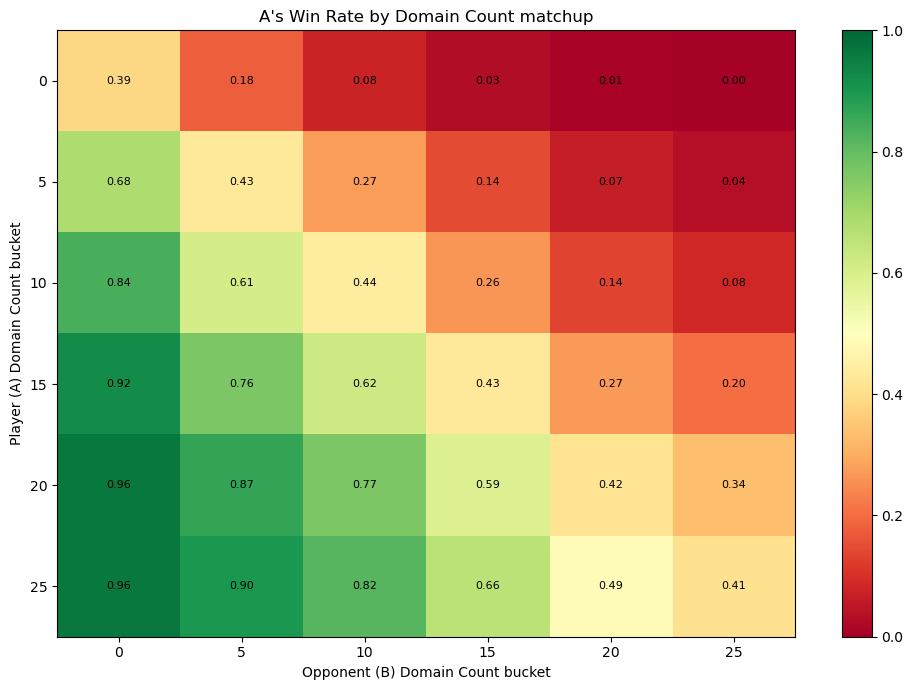

In [23]:
# Specific test: how often does a high-DC loader lose to a low-DC loader?
# Build cross-DC matchup table
df_m["a_dc_bucket"] = (df_m["a_domain_count"] // 5) * 5  # 5-pt buckets
df_m["b_dc_bucket"] = (df_m["b_domain_count"] // 5) * 5
grp_dc = df_m.groupby(["a_dc_bucket", "b_dc_bucket"]).agg(
    a_wins=("a_wins","sum"), b_wins=("b_wins","sum"),
    mut=("mut_wipe","sum"), indec=("indecisive","sum")).reset_index()
grp_dc["total"] = grp_dc[["a_wins","b_wins","mut","indec"]].sum(axis=1)
grp_dc["a_win_rate"] = grp_dc["a_wins"] / grp_dc["total"]
pivot_dc = grp_dc.pivot(index="a_dc_bucket", columns="b_dc_bucket", values="a_win_rate")

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(pivot_dc.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot_dc.columns))); ax.set_xticklabels(pivot_dc.columns)
ax.set_yticks(range(len(pivot_dc.index))); ax.set_yticklabels(pivot_dc.index)
ax.set_xlabel("Opponent (B) Domain Count bucket")
ax.set_ylabel("Player (A) Domain Count bucket")
ax.set_title("A's Win Rate by Domain Count matchup")
plt.colorbar(im, ax=ax)
for i in range(len(pivot_dc.index)):
    for j in range(len(pivot_dc.columns)):
        v = pivot_dc.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="black", fontsize=8)
plt.tight_layout(); plt.show()

In [24]:
import pandas as pd, numpy as np
import renown_data as rd

df = df_main_summary.copy()
wr = "win_rate"

# Recover each build's four domain standings from its pursuits.
# compute_pursuit_cost returns the domain dict; reuse the sim's own function.
import loadouts as L

def standings(r):
    # pursuits stored pipe-joined in the summary; rebuild the domain dict
    P = set(str(r.get("pursuits","")).split("|"))
    _, dom, _ = L.compute_pursuit_cost(P)
    return dom   # {"Industry":n,"Prowess":n,"Piety":n,"Cunning":n}

doms = df.apply(standings, axis=1)
for d in ("Industry","Prowess","Piety","Cunning"):
    df[d] = doms.apply(lambda x: x.get(d,0))

# standing tier per domain: 0=Untested,3=Rising,6=Established,10=Sovereign
def tier(v): return "S" if v>=10 else "E" if v>=6 else "R" if v>=3 else "N"
for d in ("Industry","Prowess","Piety","Cunning"):
    df[d+"_t"] = df[d].apply(tier)

# shape = sorted standing letters, e.g. "SSEE", "EEEE", "SRNN"
df["shape"] = df.apply(lambda r: "".join(sorted(
    [r["Industry_t"],r["Prowess_t"],r["Piety_t"],r["Cunning_t"]],
    key=lambda c:{"S":0,"E":1,"R":2,"N":3}[c])), axis=1)
df["dompoints"] = df[["Industry","Prowess","Piety","Cunning"]].sum(axis=1)

# how concentrated? max single domain vs total (1.0 = all in one, 0.25 = perfectly spread)
df["concentration"] = df[["Industry","Prowess","Piety","Cunning"]].max(axis=1) / df["dompoints"].clip(lower=1)

# ---- the comparison: at similar point totals, does spread or spike win? ----
df["pt_band"] = pd.cut(df["dompoints"], [-1,10,16,22,28,99],
                       labels=["~10","11-16","17-22","23-28","29+"])

print("Win rate by domain SHAPE (top shapes by count):")
g = df.groupby("shape").agg(n=("shape","size"), wr=(wr,"mean"),
                            pts=("dompoints","mean")).round(3)
print(g[g.n>=15].sort_values("wr",ascending=False).to_string(), "\n")

print("Spread vs spike WITHIN each point band (concentration split):")
df["style"] = np.where(df["concentration"]>=0.5,"spike(1-2 deep)","spread(3-4 wide)")
print(df.groupby(["pt_band","style"],observed=True)[wr]
        .agg(["mean","count"]).round(3).to_string())

import re
ss = df[df["shape"].str.startswith("SS")].copy()
# which two domains are Sovereign?
def sov_pair(r):
    s = sorted([d for d in ("Industry","Prowess","Piety","Cunning") if r[d] >= 10])
    return "+".join(s) if len(s)==2 else "other"
ss["sov_pair"] = ss.apply(sov_pair, axis=1)
print(ss.groupby("sov_pair")[wr].agg(["mean","count"]).round(3).sort_values("mean",ascending=False).to_string())

import pandas as pd
import loadouts as L

df = df_main_summary.copy()
wr = "win_rate"

# rebuild domain standings from pursuits (same as the shape cell)
def standings(r):
    P = set(str(r.get("pursuits","")).split("|"))
    _, dom, _ = L.compute_pursuit_cost(P)
    return dom
doms = df.apply(standings, axis=1)
for d in ("Industry","Prowess","Piety","Cunning"):
    df[d] = doms.apply(lambda x: x.get(d,0))

cun = df[df["Cunning"]>=10]
cols = [c for c in ("win_rate","decisive_win_rate","indecisive","avg_self_survivors",
                    "avg_opp_survivors","a_ended_by_fallback_rate") if c in df.columns]
print("Sovereign-Cunning combat survival profile:")
print(cun[cols].mean().round(3).to_string())
print(f"\n(n = {len(cun)} Sovereign-Cunning builds)")
print("\nField baseline (non-Cunning):")
print(df[df["Cunning"]<10][cols].mean().round(3).to_string())

print("Cunning standing distribution:")
print(df["Cunning"].value_counts().sort_index().to_string())
print("\nSovereign-Cunning (>=10) count:", (df["Cunning"]>=10).sum())

Win rate by domain SHAPE (top shapes by count):
         n     wr   pts
shape                  
SSRR    56  0.748  26.0
SSEN   346  0.679  26.0
SSRN   145  0.642  23.0
SEER   384  0.610  25.0
SEEN   455  0.576  22.0
EEER    66  0.548  21.0
SSNN    77  0.546  20.0
SERR   146  0.522  22.0
SERN   425  0.473  19.0
EEEN    65  0.467  18.0
SENN   276  0.423  16.0
EERR    60  0.353  18.0
SRRN    49  0.351  16.0
EERN   178  0.333  15.0
SRNN   107  0.311  13.0
EENN   128  0.270  12.0
SNNN    68  0.228  10.0
ERRN   103  0.181  12.0
ERNN   159  0.172   9.0
ENNN    70  0.129   6.0
RRNN    33  0.058   6.0
RNNN    31  0.042   3.0 

Spread vs spike WITHIN each point band (concentration split):
                           mean  count
pt_band style                         
~10     spike(1-2 deep)   0.153    361
        spread(3-4 wide)  0.055     17
11-16   spike(1-2 deep)   0.333    663
        spread(3-4 wide)  0.323    191
17-22   spike(1-2 deep)   0.485    502
        spread(3-4 wide)  0.538    792


## 2.4 Outliers — punch above weight on MPC

Loadouts whose win rate is most above what their MPC bucket would predict — "value loadouts." Conversely, loadouts that under-perform their budget.

In [25]:
over, under = analysis.mpc_outliers(df_main_matchups, top_n=15)
print("=== Top punch-above-weight loadouts (most over-perform their MPC peers) ===")
print(over[["retinue","military_pursuit_count","win_rate","bucket_mean_wr","z_score"]].round(3).to_string())
print("\n=== Top under-performers (waste budget) ===")
print(under[["retinue","military_pursuit_count","win_rate","bucket_mean_wr","z_score"]].round(3).to_string())

=== Top punch-above-weight loadouts (most over-perform their MPC peers) ===
                                                                                retinue  military_pursuit_count  win_rate  bucket_mean_wr  z_score
a_name                                                                                                                                            
Sgt/2HBastard/Cloth [(EInd, EProw, NPie, NCun)]                                Sergeant                       2     0.366           0.063    4.354
Sgt/2HBastard/FullPlate [(EInd, EProw, NPie, NCun), Temp]                      Sergeant                       3     0.648           0.164    3.999
Sgt/Pike/FullPlate [(EInd, EProw, NPie, NCun), Temp]                           Sergeant                       3     0.529           0.164    3.019
KT/FarmTools/Cloth [PrM, (NInd, EProw, SPie, NCun), Rec 5, Shake+1]      Knight Templar                       3     0.516           0.164    2.909
KT/2HBastard/Cloth [PrM, (EInd, EProw, SPi

# 3. Retinue Analysis

How does win rate, durability, kill efficiency, and stalemate rate vary across the four retinues? Are retinue cost-efficiency ratios appropriate?

In [26]:
print("=== Per-Retinue summary (all loadouts, Random playstyle) ===")
ret_summary = df_main_summary.groupby("retinue").agg(
    n_loadouts=("name", "count"),
    win_rate=("win_rate", "mean"),
    loss_rate=("loss_rate", "mean"),
    decisive_win_rate=("decisive_win_rate", "mean"),
    kill_eff=("kill_efficiency", "mean"),
    survivors=("avg_self_survivors", "mean"),
    opp_survivors=("avg_opp_survivors", "mean"),
    wins_per_1k_upkeep=("wins_per_1000_upkeep", "mean"),
    upkeep=("upkeep_per_retinue", "mean"),
)
print(ret_summary.round(3).to_string())

=== Per-Retinue summary (all loadouts, Random playstyle) ===
                n_loadouts  win_rate  loss_rate  decisive_win_rate  kill_eff  survivors  opp_survivors  wins_per_1k_upkeep    upkeep
retinue                                                                                                                             
Knight Templar         486     0.739      0.153              0.827     9.099     11.139          2.040           29381.096  2668.519
Levy                   969     0.212      0.597              0.278    -5.073      3.099          8.171           99812.878   500.619
Man-at-Arms            962     0.486      0.382              0.562     1.207      6.256          5.049           49877.304  1550.936
Sergeant              1040     0.557      0.333              0.623     3.108      7.242          4.134           36878.841  2120.192


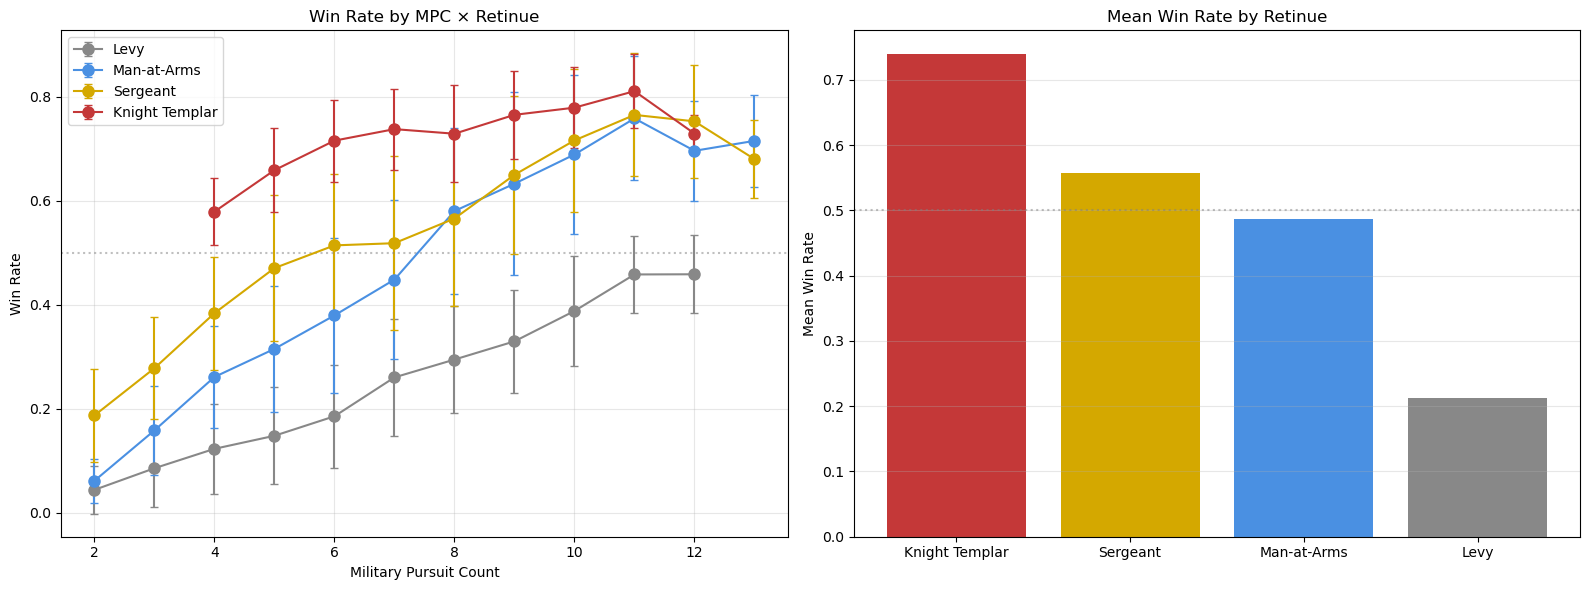

In [27]:
# Win rate by retinue, faceted by MPC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for ret, color in zip(["Levy","Man-at-Arms","Sergeant","Knight Templar"],
                       ["#888","#4a90e2","#d4a800","#c43838"]):
    sub = df_main_summary[df_main_summary["retinue"] == ret]
    binned = sub.groupby("military_pursuit_count")["win_rate"].agg(["mean","std","count"])
    binned = binned[binned["count"] >= 3]
    if len(binned) > 0:
        ax.errorbar(binned.index, binned["mean"], yerr=binned["std"],
                    fmt="o-", color=color, label=ret, capsize=3, markersize=8)
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Military Pursuit Count")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate by MPC × Retinue")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ret_means = ret_summary["win_rate"].sort_values(ascending=False)
colors = {"Levy":"#888","Man-at-Arms":"#4a90e2","Sergeant":"#d4a800","Knight Templar":"#c43838"}
ax.bar(ret_means.index, ret_means.values, color=[colors[r] for r in ret_means.index])
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_ylabel("Mean Win Rate")
ax.set_title("Mean Win Rate by Retinue")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "winrate_by_mpc"), dpi=110, bbox_inches="tight"); plt.show()

In [28]:
import pandas as pd, numpy as np
import renown_data as rd
df = df_main_summary
wr = "win_rate"; CUT = 0.85

# ---- setup (self-contained: define MON, mons, config, wtier here) ----
MON = {"Royal Pavilion":"RoPa", "Ministry of Military Strategy":"Ministry",
       "Preceptory":"Preceptory", "ABF":"ABF", "Outrider Intercept Post":"Outrider"}
DW_WEAPONS = {w for w,d in rd.WEAPONS.items() if "Dual Wield" in d.get("tags",[])}
def is_2h(w):
    t = rd.WEAPONS.get(w,{}).get("tags",[]); return "2H" in t or "Dual Wield" in t
def _tags(r):
    t=r.get("tags",""); return {x.strip() for x in str(t).replace("|",",").split(",")} if isinstance(t,str) and t else set()
def _empty(v): return v in (None,"","nan") or (isinstance(v,float) and pd.isna(v))

def _config(r):
    w,rg,sh,tags = r.get("weapon"),r.get("ranged"),r.get("shield"),_tags(r)
    ty = bool(r.get("tiltyard")) or "Immune Unwieldy" in tags
    if not _empty(rg) and not _empty(w) and w!="Farm Tools": return "Ranged+Melee"
    if not _empty(rg) and (_empty(w) or w=="Farm Tools"):    return "Ranged"
    if "Dual Wield" in tags or (ty and _empty(sh) and _empty(rg) and w and w not in DW_WEAPONS and not is_2h(w)): return "DW"
    if w in DW_WEAPONS: return "DW"
    if is_2h(w): return "2H"
    if not _empty(sh): return "1H+Shield"
    return "Other"

def _mons(r):
    p = set(str(r.get("pursuits","")).split("|"))
    return [s for f,s in MON.items() if f in p]

if "config" not in df.columns: df["config"] = df.apply(_config, axis=1)
if "wtier"  not in df.columns: df["wtier"]  = df["weapon"].map(lambda w: rd.WEAPONS.get(w,{}).get("tier","-"))
if "mons"   not in df.columns: df["mons"]   = df.apply(_mons, axis=1)
# ---- end setup ----

# ── What wins: distribution of the >85% win-rate elite vs the field ──
import pandas as pd, numpy as np
import renown_data as rd
df = df_main_summary
wr = "win_rate"
CUT = 0.85
elite = df[df[wr] > CUT].copy()
print(f"Elite (>{CUT:.0%}): {len(elite)} / {len(df)}  ({len(elite)/len(df):.1%} of pool)\n")

def dist(col, src=elite, base=df):
    """Share within elite, and lift = elite share / pool share (>1 = over-represented)."""
    e = src[col].value_counts(normalize=True)
    p = base[col].value_counts(normalize=True)
    out = pd.DataFrame({"elite_%": (e*100).round(1),
                        "pool_%":  (p.reindex(e.index)*100).round(1)})
    out["lift"] = (e / p.reindex(e.index)).round(2)
    return out.sort_values("elite_%", ascending=False)

for col in ["retinue", "weapon", "armor", "shield", "config", "wtier"]:
    if col in elite.columns:
        print(f"── {col} ──"); print(dist(col).to_string(), "\n")

# Monuments: each build can carry several, so count membership not value_counts.
print("── monuments ──")
rows=[]
for full,short in MON.items():
    e_has = elite["mons"].apply(lambda m: short in m)
    p_has = df["mons"].apply(lambda m: short in m)
    es, ps = e_has.mean(), p_has.mean()
    rows.append((short, round(es*100,1), round(ps*100,1), round(es/ps,2) if ps else np.nan))
mon = pd.DataFrame(rows, columns=["monument","elite_%","pool_%","lift"]).sort_values("elite_%",ascending=False)
print(mon.to_string(index=False), "\n")

# MPC profile of the elite
print("── MPC ──")
print(elite["military_pursuit_count"].describe()[["min","25%","50%","75%","max"]].round(1).to_string())
print(f"\nelite mean MPC {elite['military_pursuit_count'].mean():.1f}  vs pool {df['military_pursuit_count'].mean():.1f}")

# Tag fingerprint — which extra_tags define the elite (lift)
print("\n── tags (lift in elite) ──")
def tagset(r): return {x.strip() for x in str(r.get('tags','')).replace('|',',').split(',') if x.strip()}
all_tags = sorted({t for _,r in df.iterrows() for t in tagset(r)})
trow=[]
for t in all_tags:
    es = df.index.isin(elite.index)
    has = df.apply(lambda r: t in tagset(r), axis=1)
    e = has[df[wr]>CUT].mean(); p = has.mean()
    if p>0 and (has & (df[wr]>CUT)).sum()>=5:
        trow.append((t, round(e*100,1), round(p*100,1), round(e/p,2)))
tg = pd.DataFrame(trow, columns=["tag","elite_%","pool_%","lift"]).sort_values("lift",ascending=False)
print(tg.head(15).to_string(index=False))

Elite (>85%): 212 / 3457  (6.1% of pool)

── retinue ──
                elite_%  pool_%  lift
retinue                              
Sergeant           43.9    30.1  1.46
Man-at-Arms        30.2    27.8  1.08
Knight Templar     25.9    14.1  1.85 

── weapon ──
               elite_%  pool_%  lift
weapon                              
2HBastard         24.1    12.1  1.99
Bastard Sword     11.5     4.4  2.60
War Hammer        10.5    10.5  1.00
Morningstar        7.3     3.1  2.39
Lance              7.3     3.6  2.03
Battle Axe         6.3     7.4  0.84
Halberd            6.3     7.6  0.83
Arming Sword       5.2     3.9  1.35
Pike               4.2     7.7  0.54
Farm Tools         3.7    12.5  0.29
Cavalry Spear      2.6     4.0  0.66
Short Sword        2.6     3.0  0.87
Poleaxe            2.6     0.5  5.11
Daggers            1.6     7.6  0.21
Spears             1.6     2.4  0.65
Flail              1.6     0.9  1.70
Estoc              1.0     0.8  1.28 

── armor ──
              elite_% 

In [29]:
# ── Is Royal Pavilion dominant on its own, or just because it's expensive? ──
import pandas as pd, numpy as np
wr = "win_rate"; CUT = 0.85

band = df[df["military_pursuit_count"].between(10, 20)].copy()
band["has_RoPa"] = band["mons"].apply(lambda m: "RoPa" in m)
band["elite"] = band[wr] > CUT
print(f"MPC 12-14 band: {len(band)} builds "
      f"({band['has_RoPa'].mean():.0%} carry RoPa)\n")

# Win rate: RoPa vs non-RoPa, holding budget fixed
g = band.groupby("has_RoPa")[wr].agg(["mean","median","count"]).round(3)
print("Win rate within MPC 12-14:")
print(g.rename(index={False:"no RoPa", True:"RoPa"}).to_string())
print(f"\nRoPa edge (same budget): "
      f"{g.loc[True,'mean']-g.loc[False,'mean']:+.3f}\n")

# Elite composition within the band: does RoPa still over-concentrate?
e = band[band["elite"]]
es = e["has_RoPa"].mean(); ps = band["has_RoPa"].mean()
print(f"Within MPC 12-14:")
print(f"  RoPa share of band   : {ps:.0%}")
print(f"  RoPa share of elite  : {es:.0%}")
print(f"  lift (elite/band)    : {es/ps:.2f}")
print("\n→ lift ≈ 1: RoPa edge was just budget. lift ≫ 1: RoPa itself is the lever.")

# Cross-check: best non-RoPa build at this budget — what's the ceiling without it?
nb = band[~band["has_RoPa"]]
if len(nb):
    b = nb.loc[nb[wr].idxmax()]
    print(f"\nBest non-RoPa @ MPC12-14: {b[wr]:.3f}  {b['name']}")

MPC 12-14 band: 784 builds (37% carry RoPa)

Win rate within MPC 12-14:
           mean  median  count
has_RoPa                      
no RoPa   0.636   0.680    491
RoPa      0.789   0.809    293

RoPa edge (same budget): +0.153

Within MPC 12-14:
  RoPa share of band   : 37%
  RoPa share of elite  : 82%
  lift (elite/band)    : 2.20

→ lift ≈ 1: RoPa edge was just budget. lift ≫ 1: RoPa itself is the lever.

Best non-RoPa @ MPC12-14: 0.939  Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, EPie, NCun), ImmU, Temp, Serr, Shake+1]


In [30]:
# ── Weapon × Weapon matrix (melee ladder) from df_main_matchups ──
import pandas as pd, numpy as np

FOCUS = ["Cavalry Spear","Bastard Sword","2HBastard","Lance","Morningstar",
         "War Hammer","Poleaxe","Estoc"]

m = df_main_matchups
sub = m[m["a_weapon"].isin(FOCUS) & m["b_weapon"].isin(FOCUS)][
        ["a_weapon","b_weapon","a_win_rate","n_runs","a_wins","b_wins",
         "a_wipe_combat","a_wipe_shake","a_wipe_waver","a_wipe_rout"]].copy()

# symmetrize: each A-vs-B pair also gives B-vs-A (flip the win rate)
ab = sub.rename(columns={"a_weapon":"row","b_weapon":"col","a_win_rate":"wr"})
ab = ab[["row","col","wr","n_runs"]]
ba = sub.copy()
ba["wr"] = 1 - ba["a_win_rate"]
ba = ba.rename(columns={"b_weapon":"row","a_weapon":"col"})[["row","col","wr","n_runs"]]
allp = pd.concat([ab, ba], ignore_index=True)

# n_runs-weighted mean WR of ROW weapon vs COL weapon
def wmean(g): 
    w = g["n_runs"].clip(lower=1)
    return np.average(g["wr"], weights=w)
mat = (allp.groupby(["row","col"]).apply(wmean)
            .unstack().reindex(index=FOCUS, columns=FOCUS).round(3))
cnt = (allp.groupby(["row","col"])["n_runs"].sum()
            .unstack().reindex(index=FOCUS, columns=FOCUS).fillna(0).astype(int))

print("Win rate of ROW weapon vs COL weapon (n_runs-weighted):")
print(mat.to_string())
print("\ntotal runs per cell (trust cells with high n):")
print(cnt.to_string())

# overall ladder rank: each weapon's mean WR across the focus set
print("\nMean WR vs the focus ladder (this IS the power ranking):")
ladder = mat.mean(axis=1).sort_values(ascending=False).round(3)
print(ladder.to_string())

# tier reference for reading the ranking
TIER = {"Cavalry Spear":"Wrought","Bastard Sword":"Forged","2HBastard":"Forged",
        "Lance":"Forged","Morningstar":"Forged","War Hammer":"Forged",
        "Poleaxe":"Crafted","Estoc":"Crafted"}
print("\nladder with tiers:")
for w,v in ladder.items():
    print(f"  {v:.3f}  {w:<14} ({TIER[w]})")

m = df_main_matchups
bast = m[m["a_weapon"]=="2HBastard"].copy()
# does A carry an init-fixer in its tags?
INIT_TECH = ["Drilled","Seize","+1I","MaxInit3","Nimble","Immune Strain"]
bast["has_init_tech"] = bast["a_tags"].fillna("").apply(
    lambda t: any(k in t for k in INIT_TECH))
print("2HBastard win rate by whether it carries init tech (offsets Unwieldy):")
print(bast.groupby("has_init_tech").apply(
    lambda g: np.average(g["a_win_rate"], weights=g["n_runs"].clip(lower=1))).round(3).to_string())
print("\nn_runs each:")
print(bast.groupby("has_init_tech")["n_runs"].sum().to_string())

m = df_main_matchups
FOCUS = ["Cavalry Spear","Bastard Sword","2HBastard","Lance","Morningstar",
         "War Hammer","Poleaxe","Estoc"]

def has_serr(tagstr):
    t = str(tagstr)
    return ("Serrated" in t) or ("Rend" in t)

# ── Weapon × Weapon matrix, CONTROLLED for Serrated ──
# Poleaxe is 100% Serrated (GF prereq); other weapons aren't. Comparing raw
# over-credits Poleaxe. Fix: only count pairs where BOTH sides carry Serrated,
# so everyone's on equal Recover-suppression footing.
import pandas as pd, numpy as np

FOCUS = ["Cavalry Spear","Bastard Sword","2HBastard","Lance","Morningstar",
         "War Hammer","Poleaxe","Estoc"]

def has_serr(tagstr):
    t = str(tagstr)
    return ("Serrated" in t) or ("Rend" in t)

m = df_main_matchups
sub = m[m["a_weapon"].isin(FOCUS) & m["b_weapon"].isin(FOCUS)
        & m["a_tags"].apply(has_serr) & m["b_tags"].apply(has_serr)][
        ["a_weapon","b_weapon","a_win_rate","n_runs"]].copy()

# symmetrize: each A-vs-B pair also gives B-vs-A
ab = sub.rename(columns={"a_weapon":"row","b_weapon":"col","a_win_rate":"wr"})[["row","col","wr","n_runs"]]
ba = sub.copy()
ba["wr"] = 1 - ba["a_win_rate"]
ba = ba.rename(columns={"b_weapon":"row","a_weapon":"col"})[["row","col","wr","n_runs"]]
allp = pd.concat([ab, ba], ignore_index=True)

def wmean(g):
    w = g["n_runs"].clip(lower=1)
    return np.average(g["wr"], weights=w)

mat = (allp.groupby(["row","col"]).apply(wmean)
            .unstack().reindex(index=FOCUS, columns=FOCUS).round(3))
cnt = (allp.groupby(["row","col"])["n_runs"].sum()
            .unstack().reindex(index=FOCUS, columns=FOCUS).fillna(0).astype(int))

print("SERRATED-ONLY: win rate of ROW vs COL (both sides Serrated):")
print(mat.to_string())
print("\nruns per cell:")
print(cnt.to_string())
print("\nMean WR vs focus ladder (Serrated-controlled ranking):")
print(mat.mean(axis=1).sort_values(ascending=False).round(3).to_string())

px = df_main_matchups[df_main_matchups["a_weapon"]=="Poleaxe"]["a_tags"].iloc[0]
print("A Poleaxe build's tags:", px)

Win rate of ROW weapon vs COL weapon (n_runs-weighted):
col            Cavalry Spear  Bastard Sword  2HBastard  Lance  Morningstar  War Hammer  Poleaxe  Estoc
row                                                                                                   
Cavalry Spear          0.500          0.278      0.375  0.376        0.288       0.428    0.073  0.362
Bastard Sword          0.722          0.500      0.677  0.630        0.518       0.590    0.372  0.577
2HBastard              0.625          0.323      0.500  0.511        0.421       0.617    0.204  0.401
Lance                  0.624          0.370      0.489  0.500        0.407       0.546    0.221  0.431
Morningstar            0.712          0.482      0.579  0.593        0.500       0.577    0.265  0.517
War Hammer             0.572          0.410      0.383  0.454        0.423       0.500    0.297  0.553
Poleaxe                0.927          0.628      0.796  0.779        0.735       0.703      NaN    NaN
Estoc            

In [31]:
# does any non-ABF Full Plate build have Planishing/GF?
fp = df_main_matchups[(df_main_matchups["a_armor"]=="Full Plate")]
fp_no_abf = fp[~fp["a_tags"].str.contains("ABF", na=False)]
print("Full Plate builds:", len(fp))
print("Full Plate non-ABF:", len(fp_no_abf))
print("Full Plate non-ABF with Planishing:",
      fp_no_abf["a_tags"].str.contains("Planishing|GF Armor", na=False).sum())
# and: do ANY builds have Planishing at all?
print("any build with Planishing:",
      df_main_matchups["a_tags"].str.contains("Planishing", na=False).any())

Full Plate builds: 1507266
Full Plate non-ABF: 1507266
Full Plate non-ABF with Planishing: 1507266
any build with Planishing: True


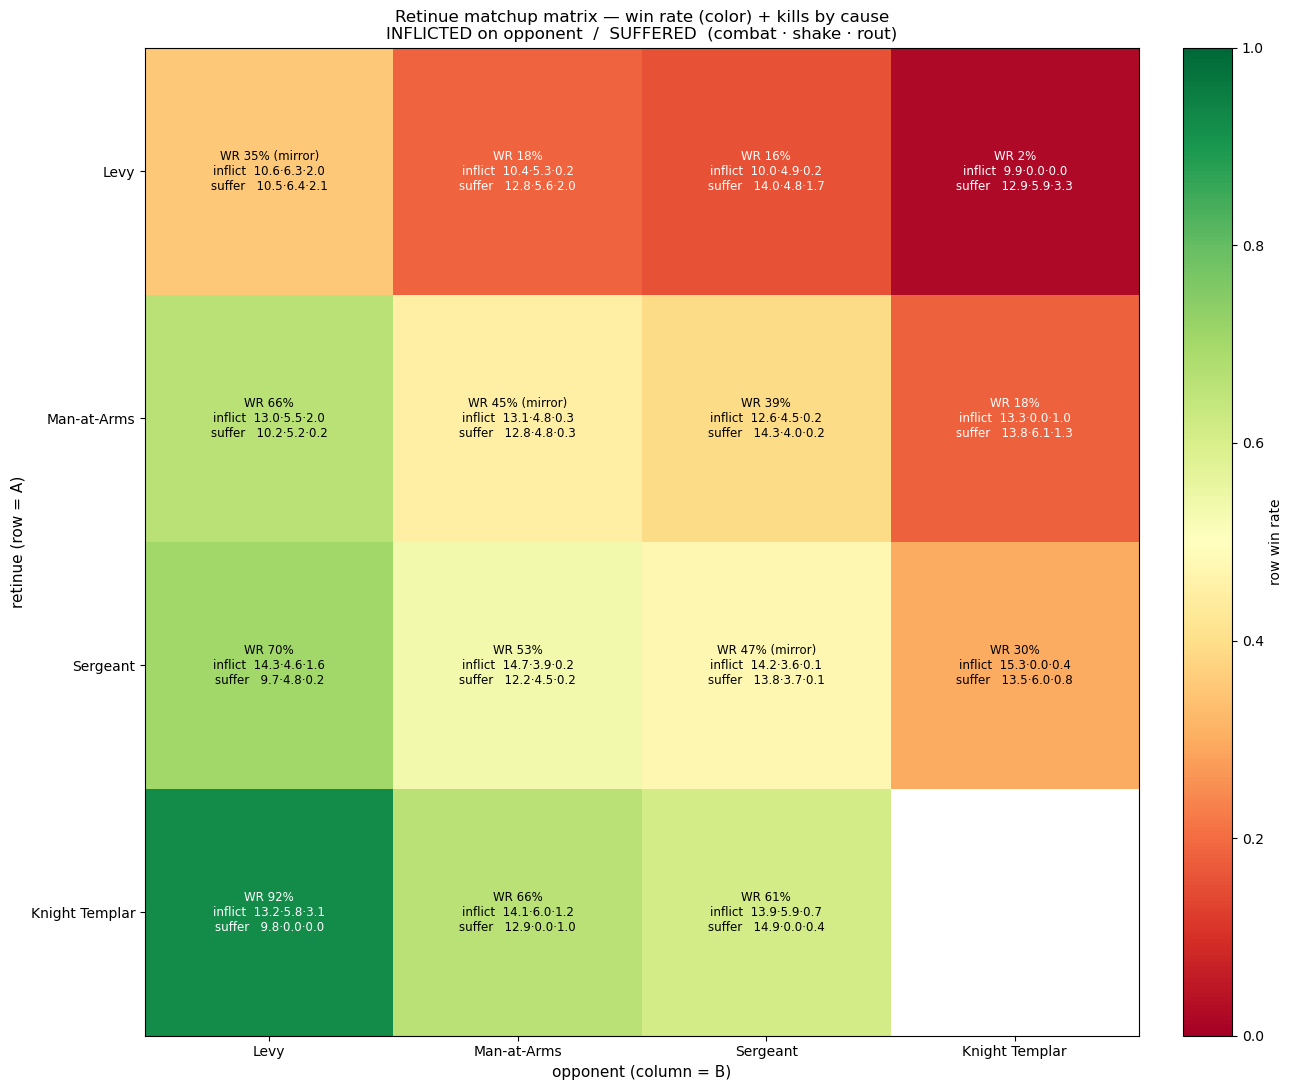

,a_retinue,b_retinue,win%,infl_combat,infl_shake,infl_rout,suff_combat,suff_shake,suff_rout,n
0,Knight Templar,Levy,92.0,13.19,5.79,3.15,9.76,0.00,0.00,359658
1,Knight Templar,Man-at-Arms,66.0,14.14,5.96,1.23,12.93,0.00,1.03,308084
2,Knight Templar,Sergeant,61.0,13.87,5.89,0.75,14.94,0.00,0.45,353251
3,Levy,Knight Templar,2.0,9.93,0.00,0.00,12.92,5.94,3.32,359658
4,Levy,Man-at-Arms,18.0,10.39,5.26,0.19,12.76,5.60,2.04,804165
5,Levy,Sergeant,16.0,9.95,4.89,0.17,14.00,4.78,1.67,903015
6,Man-at-Arms,Knight Templar,18.0,13.28,0.00,1.05,13.78,6.13,1.29,308084
7,Man-at-Arms,Levy,66.0,13.00,5.48,1.95,10.19,5.21,0.19,804165
8,Man-at-Arms,Sergeant,39.0,12.61,4.47,0.20,14.32,4.00,0.19,832563
9,Sergeant,Knight Templar,30.0,15.33,0.00,0.45,13.53,6.02,0.78,353251


In [32]:
# ── 4×4 retinue matrix: win rate + kills by CAUSE (inflicted vs suffered) ──
# Each cell = ROW retinue (as A) vs COLUMN retinue (as B).
#   win_rate  : row's win rate vs column
#   INFLICTED : avg of the COLUMN's soldiers the row kills, split combat / shake / rout
#   SUFFERED  : avg of the ROW's own soldiers lost,        split combat / shake / rout
# Mirror cells (diagonal) shown for reference. Values are mean per-battle casualty COUNTS, not outcomes.
import numpy as np, pandas as pd, matplotlib.pyplot as plt

RETS = ["Levy", "Man-at-Arms", "Sergeant", "Knight Templar"]
df = df_main_matchups   # <-- your loaded tournament

g = (df.groupby(["a_retinue", "b_retinue"])
       .agg(win_rate   =("a_win_rate", "mean"),
            infl_combat=("avg_b_killed_combat", "mean"),
            infl_shake =("avg_b_killed_shake",  "mean"),
            infl_rout  =("avg_b_killed_rout",   "mean"),
            suff_combat=("avg_a_killed_combat", "mean"),
            suff_shake =("avg_a_killed_shake",  "mean"),
            suff_rout  =("avg_a_killed_rout",   "mean"),
            n          =("a_win_rate", "size"))
       .reset_index())
G = g.set_index(["a_retinue", "b_retinue"])

# numeric matrices for the heatmap backdrop (win rate) + net combat performance
win = pd.DataFrame(index=RETS, columns=RETS, dtype=float)
for r in RETS:
    for c in RETS:
        win.loc[r, c] = G.loc[(r, c), "win_rate"] if (r, c) in G.index else np.nan

# ---- visual grid: win-rate heatmap with inflicted/suffered text in each cell ----
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(win.values.astype(float), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(4)); ax.set_xticklabels(RETS, fontsize=10)
ax.set_yticks(range(4)); ax.set_yticklabels(RETS, fontsize=10)
ax.set_xlabel("opponent (column = B)", fontsize=11)
ax.set_ylabel("retinue (row = A)", fontsize=11)
ax.set_title("Retinue matchup matrix — win rate (color) + kills by cause\n"
             "INFLICTED on opponent  /  SUFFERED  (combat · shake · rout)", fontsize=12)
for i, r in enumerate(RETS):
    for j, c in enumerate(RETS):
        if (r, c) not in G.index:
            ax.text(j, i, "—", ha="center", va="center", color="#666"); continue
        row = G.loc[(r, c)]
        wr = row["win_rate"]
        diag = " (mirror)" if r == c else ""
        txt = (f"WR {wr*100:.0f}%{diag}\n"
               f"inflict  {row['infl_combat']:.1f}·{row['infl_shake']:.1f}·{row['infl_rout']:.1f}\n"
               f"suffer   {row['suff_combat']:.1f}·{row['suff_shake']:.1f}·{row['suff_rout']:.1f}")
        ax.text(j, i, txt, ha="center", va="center", fontsize=8.5,
                color="black" if 0.25 < wr < 0.8 else "white")
fig.colorbar(im, ax=ax, label="row win rate", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "retinue_matchup_matrix"), dpi=110, bbox_inches="tight"); plt.show()

# ---- the full table (off-diagonal only, for sorting/inspection) ----
tbl = g[g.a_retinue != g.b_retinue].copy()
tbl["win%"] = (tbl.win_rate*100).round(0)
tbl = tbl[["a_retinue","b_retinue","win%",
           "infl_combat","infl_shake","infl_rout",
           "suff_combat","suff_shake","suff_rout","n"]].round(2)
display(tbl.sort_values(["a_retinue","b_retinue"]).reset_index(drop=True))

In [33]:
# ============================================================================
#  SYNERGY SCAN — tangled-correlation detector
#  Finds feature PAIRS (retinue / weapon / shield / armor / ranged / tag /
#  pursuit) whose combined performance beats the additive expectation of each
#  part measured ALONE — i.e. weak or neutral solo, strong together.
#
#  Method:
#    - Per-build win rate -> MPC-adjusted edge (pp vs same-cost builds), so
#      expensive combos aren't flagged just for being expensive.
#    - For each pair (A,B) with enough builds in all three cells:
#        A_alone = mean edge of builds with A but NOT B
#        B_alone = mean edge of builds with B but NOT A
#        combo   = mean edge of builds with BOTH
#        synergy = combo - (A_alone + B_alone)      [additive baseline]
#    - Pairs that essentially never appear apart (P(A|B) or P(B|A) >= 0.95)
#      are STRUCTURAL (e.g. a weapon and the building that unlocks it, or two
#      tags granted by the same mastery) — unidentifiable, listed separately.
#
#  Requires: df_main_matchups (from analysis.load_tournament).
# ============================================================================
import numpy as np, pandas as pd, re

MIN_N        = 8      # min builds required in EACH cell (A alone, B alone, A+B)
WEAK_ALONE   = 4.0    # |edge| pp under which a feature counts as weak/neutral solo
STRONG_COMBO = 8.0    # combo edge pp above which the pair counts as strong
STRUCT_COOC  = 0.95   # P(A|B) or P(B|A) >= this => structural pair, skipped
TOP_K        = 25

# ---- per-build aggregate, MPC-adjusted edge -------------------------------
df = df_main_matchups.copy()
den = (df["a_wins"] + df["b_wins"] + df["mut_wipe"] + df["indecisive"]).replace(0, np.nan)
df["a_wr"] = df["a_wins"] / den
g = df.groupby("a_name").agg(
    wr=("a_wr", "mean"), mpc=("a_military_pursuit_count", "first"),
    retinue=("a_retinue", "first"), weapon=("a_weapon", "first"),
    shield=("a_shield", "first"), armor=("a_armor", "first"),
    ranged=("a_ranged", "first"), tags=("a_tags", "first"),
    pursuits=("a_pursuits", "first"),
).reset_index()
g["edge"] = (g["wr"] - g.groupby("mpc")["wr"].transform("mean")) * 100.0

def _split(s):
    return [t.strip() for t in re.split(r"[|,]", str(s))
            if t.strip() and t.strip().lower() != "nan"]

# ---- boolean feature matrix ------------------------------------------------
feat = {}
for col, pre in [("retinue", "ret"), ("weapon", "wpn"), ("shield", "shd"),
                 ("armor", "arm"), ("ranged", "rng")]:
    for v in pd.unique(g[col].dropna()):
        if v in ("", "None", None):
            continue
        feat[f"{pre}:{v}"] = (g[col] == v).values
for kind, col in [("tag", "tags"), ("pur", "pursuits")]:
    lists = g[col].map(_split)
    toks = sorted({t for L in lists for t in L})
    for t in toks:
        feat[f"{kind}:{t}"] = lists.map(lambda L, _t=t: _t in L).values

F = pd.DataFrame(feat, index=g.index)
n_builds = len(g)
F = F[[c for c in F.columns if MIN_N <= F[c].sum() <= n_builds - MIN_N]]  # prune no-variance
edge = g["edge"].values
print(f"builds: {n_builds} | features kept: {F.shape[1]} | "
      f"pairs to scan: ~{F.shape[1]*(F.shape[1]-1)//2}")

# ---- pair scan -------------------------------------------------------------
rows, structural = [], []
cols = list(F.columns)
Fv = {c: F[c].values for c in cols}
for i in range(len(cols)):
    A = Fv[cols[i]]
    for j in range(i + 1, len(cols)):
        B = Fv[cols[j]]
        ab = A & B
        nab = int(ab.sum())
        if nab < MIN_N:
            continue
        if nab / A.sum() >= STRUCT_COOC or nab / B.sum() >= STRUCT_COOC:
            structural.append((cols[i], cols[j], nab))
            continue
        a_only, b_only = A & ~B, B & ~A
        na, nb = int(a_only.sum()), int(b_only.sum())
        if na < MIN_N or nb < MIN_N:
            continue
        ea, eb, eab = edge[a_only].mean(), edge[b_only].mean(), edge[ab].mean()
        syn = eab - (ea + eb)
        se = np.sqrt(edge[ab].var(ddof=1) / nab +
                     edge[a_only].var(ddof=1) / na +
                     edge[b_only].var(ddof=1) / nb)
        rows.append(dict(A=cols[i], B=cols[j],
                         A_alone=ea, nA=na, B_alone=eb, nB=nb,
                         combo=eab, nAB=nab, synergy=syn,
                         z=(syn / se) if se > 0 else np.nan))
S = pd.DataFrame(rows)
if S.empty:
    print("No analyzable pairs (pool too small or MIN_N too high).")
else:
    pd.set_option("display.width", 160)
    fmt = lambda d: d.assign(**{c: d[c].round(1) for c in
          ("A_alone", "B_alone", "combo", "synergy", "z")})

    # ---- 1. TANGLED: weak/neutral alone, strong together --------------------
    tangled = S[(S.A_alone.abs() < WEAK_ALONE) & (S.B_alone.abs() < WEAK_ALONE)
                & (S.combo > STRONG_COMBO)].sort_values("synergy", ascending=False)
    print("\n" + "=" * 100)
    print(f"TANGLED COMBOS — each part within ±{WEAK_ALONE}pp alone, combo edge > "
          f"{STRONG_COMBO}pp  (edge = pp vs same-MPC builds)")
    print("=" * 100)
    print(fmt(tangled.head(TOP_K)).to_string(index=False) if len(tangled)
          else "  (none under current thresholds)")

    # ---- 2. Strongest raw synergies (regardless of solo strength) ----------
    print("\n" + "=" * 100)
    print(f"TOP {TOP_K} SYNERGIES overall (combo beats additive expectation; |z|>1 is worth a look)")
    print("=" * 100)
    print(fmt(S.sort_values("synergy", ascending=False).head(TOP_K)).to_string(index=False))

    # ---- 3. Anti-synergies (combos that underperform their parts) ----------
    print("\n" + "=" * 100)
    print(f"TOP {TOP_K} ANTI-SYNERGIES (combo WORSE than the sum of its parts)")
    print("=" * 100)
    print(fmt(S.sort_values("synergy").head(TOP_K)).to_string(index=False))

    # ---- 4. Structural pairs (near-always together — unidentifiable) -------
    print("\n" + "=" * 100)
    print(f"STRUCTURAL PAIRS skipped (co-occurrence >= {STRUCT_COOC:.0%}): {len(structural)}")
    print("=" * 100)
    for a, b, n in structural[:15]:
        print(f"  {a}  +  {b}   (together in {n} builds)")
    if len(structural) > 15:
        print(f"  ... and {len(structural) - 15} more")

    # ---- 5. helper: best partners for one feature --------------------------
    def partners(feature, k=12):
        """Top synergy partners for a given feature, e.g. partners('wpn:Poleaxe')."""
        sub = S[(S.A == feature) | (S.B == feature)].copy()
        sub["partner"] = np.where(sub.A == feature, sub.B, sub.A)
        sub["partner_alone"] = np.where(sub.A == feature, sub.B_alone, sub.A_alone)
        out = sub.sort_values("synergy", ascending=False)[
            ["partner", "partner_alone", "combo", "nAB", "synergy", "z"]].head(k)
        return out.round(1)
    print("\nHelper available:  partners('wpn:Poleaxe')  /  partners('tag:Riposte')  etc.")

builds: 3457 | features kept: 92 | pairs to scan: ~4186

TANGLED COMBOS — each part within ±4.0pp alone, combo edge > 8.0pp  (edge = pp vs same-MPC builds)
                   A                    B  A_alone   nA  B_alone   nB  combo  nAB  synergy    z
    shd:Tower Shield          rng:Longbow     -3.4  132     -2.3  413   16.0   15     21.7  5.7
   wpn:Bastard Sword         rng:Crossbow      2.6  118     -2.7  282   18.7   12     18.8  4.6
           pur:Abbey        pur:Infirmary      3.4 1011     -1.2  774   20.7  153     18.4 14.3
       tag:Recover 4            pur:Abbey     -1.2  774      3.4 1011   20.7  153     18.4 14.3
           pur:Abbey       pur:Apothecary      3.4 1011     -1.2  774   20.7  153     18.4 14.3
     ret:Man-at-Arms       tag:Planishing     -2.3  770     -2.2  494   12.5  192     16.9 11.5
     ret:Man-at-Arms   pur:Gilded Foundry     -2.3  770     -2.2  494   12.5  192     16.9 11.5
     ret:Man-at-Arms    wpn:Bastard Sword     -0.1  913     -1.8   81   13.9

## 3.1 Retinue cost efficiency

Wins per 1000 gold upkeep — does spending more on better troops pay off?

In [34]:
ret_costs = df_main_summary.groupby("retinue").agg(
    army_upkeep=("army_upkeep", "first"),
    wins_per_1k=("wins_per_1000_upkeep", "mean"),
    win_rate=("win_rate", "mean"),
).round(2)
ret_costs["upkeep_25_men"] = ret_costs["army_upkeep"]
print("=== Retinue cost-efficiency ===")
print(ret_costs.to_string())

=== Retinue cost-efficiency ===
                army_upkeep  wins_per_1k  win_rate  upkeep_25_men
retinue                                                          
Knight Templar         3000     29381.10      0.74           3000
Levy                    800     99812.88      0.21            800
Man-at-Arms            2000     49877.30      0.49           2000
Sergeant               2400     36878.84      0.56           2400


# 4. Equipment Analysis

Weapons, shields, armor, and 1H/2H/Bastard tradeoffs.

## 4.1 Weapon performance

=== Melee (tier-adjusted) ===
                 n     wr    sem  vs_tier    dec    keff     tier
weapon                                                           
Poleaxe         15  0.806  0.023    0.183  0.899  11.556  Crafted
Bastard Sword  130  0.631  0.021    0.072  0.747   7.957   Forged
Morningstar     90  0.619  0.023    0.060  0.714   6.066   Forged
Arming Sword   114  0.608  0.021    0.111  0.720   6.212  Wrought
2HBastard      355  0.595  0.012    0.036  0.654   4.267   Forged
Flail           27  0.571  0.045    0.075  0.638   3.162  Wrought
Lance          106  0.525  0.024   -0.035  0.610   3.964   Forged
Short Sword     88  0.520  0.025    0.089  0.598   2.293     Cast
Battle Axe     218  0.519  0.015    0.022  0.585   2.133  Wrought
Estoc           24  0.508  0.054   -0.115  0.634   5.775  Crafted
Halberd        222  0.487  0.017   -0.009  0.550   1.507  Wrought
Spears          71  0.487  0.029    0.055  0.558   1.513     Cast
War Hammer     308  0.482  0.015   -0.077  0.5

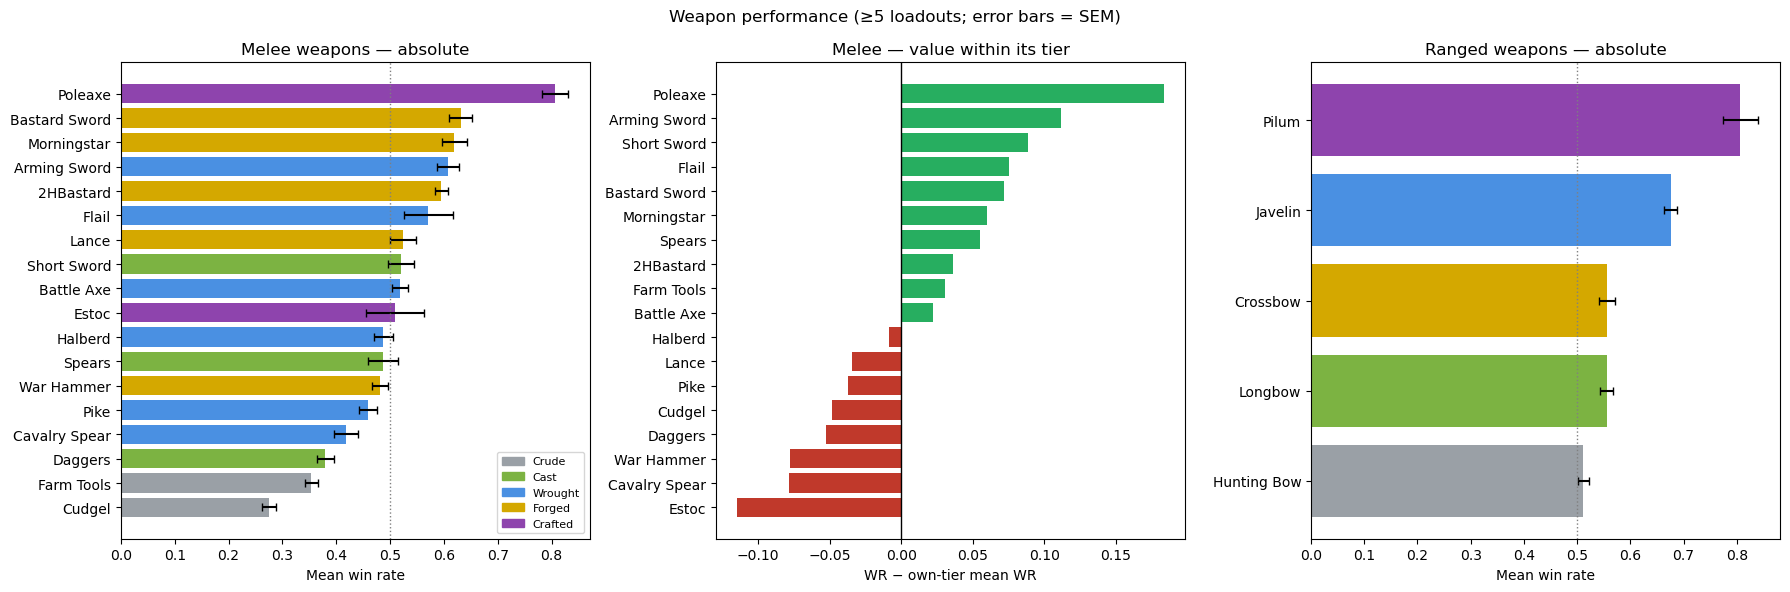


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\weapon_performance.png


In [35]:
# ============ Weapon performance: tier-adjusted, with PNG export ============
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
import renown_combat as rc

df = df_main_summary.copy()
MIN_N = 5

WTIER = {w: v["tier"] for w, v in rc.WEAPONS.items()}
RTIER = {w: v["tier"] for w, v in rc.RANGED.items()}
TIER_ORDER = ["Crude", "Cast", "Wrought", "Forged", "Crafted"]
TIER_COLOR = {"Crude":"#9aa0a6","Cast":"#7cb342","Wrought":"#4a90e2","Forged":"#d4a800","Crafted":"#8e44ad"}

# ── melee ──
mel = df[df["weapon"].notna() & (df["weapon"] != "")].copy()
mel["tier"] = mel["weapon"].map(WTIER)
g = mel.groupby("weapon").agg(
    n=("name","count"), wr=("win_rate","mean"), sd=("win_rate","std"),
    dec=("decisive_win_rate","mean"), keff=("kill_efficiency","mean"),
    tier=("tier","first")).query("n >= @MIN_N")
g["sem"] = g["sd"] / np.sqrt(g["n"])
# tier-adjusted: weapon WR minus the mean WR of its own tier's builds
tier_mean = mel.groupby("tier")["win_rate"].mean()
g["vs_tier"] = g["wr"] - g["tier"].map(tier_mean)
g = g.sort_values("wr", ascending=False)

# ── ranged ──
rng_ = df[df["ranged"].notna() & (df["ranged"] != "")].copy()
rng_["tier"] = rng_["ranged"].map(RTIER)
gr = rng_.groupby("ranged").agg(
    n=("name","count"), wr=("win_rate","mean"), sd=("win_rate","std"),
    tier=("tier","first")).query("n >= @MIN_N")
gr["sem"] = gr["sd"] / np.sqrt(gr["n"])
gr = gr.sort_values("wr", ascending=False)

print("=== Melee (tier-adjusted) ===")
print(g[["n","wr","sem","vs_tier","dec","keff","tier"]].round(3).to_string())
print("\n=== Ranged ===")
print(gr[["n","wr","sem","tier"]].round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: melee absolute WR, colored by tier, SEM bars
ax = axes[0]
colors = [TIER_COLOR[t] for t in g["tier"]]
ax.barh(g.index[::-1], g["wr"][::-1], xerr=g["sem"][::-1], color=colors[::-1], capsize=3)
ax.axvline(0.5, color="gray", ls=":", lw=1)
ax.set_xlabel("Mean win rate"); ax.set_title("Melee weapons — absolute")
handles = [plt.Rectangle((0,0),1,1,color=TIER_COLOR[t]) for t in TIER_ORDER]
ax.legend(handles, TIER_ORDER, fontsize=8, loc="lower right")

# Panel 2: melee WR relative to own tier (isolates the weapon from the tier it rides on)
ax = axes[1]
gv = g.sort_values("vs_tier")
ax.barh(gv.index, gv["vs_tier"], color=["#c0392b" if v < 0 else "#27ae60" for v in gv["vs_tier"]])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("WR − own-tier mean WR"); ax.set_title("Melee — value within its tier")

# Panel 3: ranged absolute
ax = axes[2]
colors = [TIER_COLOR[t] for t in gr["tier"]]
ax.barh(gr.index[::-1], gr["wr"][::-1], xerr=gr["sem"][::-1], color=colors[::-1], capsize=3)
ax.axvline(0.5, color="gray", ls=":", lw=1)
ax.set_xlabel("Mean win rate"); ax.set_title("Ranged weapons — absolute")

plt.suptitle("Weapon performance (≥5 loadouts; error bars = SEM)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "weapon_performance.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'weapon_performance.png')}")

module://matplotlib_inline.backend_inline
BEST LOADOUT PER MONUMENT

monument       n   best WR   build
RoPa         662     0.976   MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]
Ministry     515     0.973   Sgt/2HBastard+HuntBow/Cloth (TY) [RoPaM, MiMiStM, (EInd, SProw, EPie, RCun), ImmU, Improved Parry, Poison, Rec 4, Serr, Shake+1]
Preceptory  1192     0.966   KT/Halberd+Javelin/Cloth (TY) [RoPaM, PrM, (RInd, SProw, SPie, RCun), ImmU, Improved Parry, Poison, Rec 4, Shake+1]
ABF          127     0.955   Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, EPie, NCun), Temp, Rec 4, Serr, Shake+1]
Outrider     764     0.897   MaA/Bastard/FullPlate (DW) [RoPaM, OuInPoM, (EInd, SProw, NPie, SCun), DW, ImmU, Improved Parry, Temp, Poison]

BEST LOADOUT PER WEAPON TIER × CONFIG

── 1H+Shield ──
  Crude    0.741  n=97   KT/FarmTools/Kite/Leather [PrM, (RInd, EProw, SPie, RCun), Improved Parry, Poison, Rec 4, Shake+1]
  Cast   

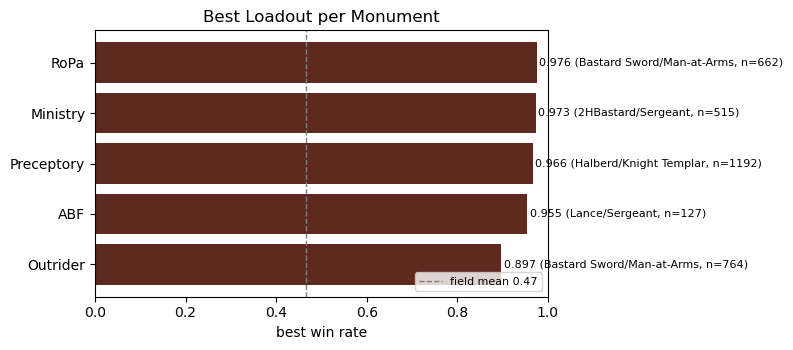

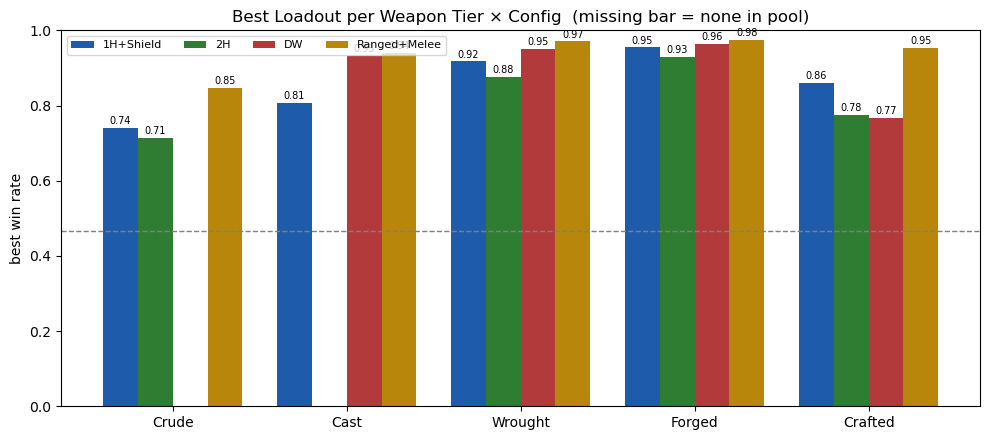


wrote:
  C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\best_by_monument.png
  C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\best_by_tier_config.png


In [36]:
# ── High-level: best loadouts by monument + by weapon-tier × config, with graphs → lab_out ──
%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
import matplotlib.pyplot as plt
print(matplotlib.get_backend())

import pandas as pd, numpy as np, os
import matplotlib
import matplotlib.pyplot as plt
import renown_data as rd

OUT = r"C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out"
os.makedirs(OUT, exist_ok=True)
wr = "win_rate"                    # or "decisive_win_rate"
df = df.copy()

# ---- classification helpers ----
DW_WEAPONS = {w for w,d in rd.WEAPONS.items() if "Dual Wield" in d.get("tags",[])}
def is_2h(w):
    t = rd.WEAPONS.get(w,{}).get("tags",[]); return "2H" in t or "Dual Wield" in t
def tags_of(r):
    t=r.get("tags",""); return {x.strip() for x in str(t).replace("|",",").split(",")} if isinstance(t,str) and t else set()
def _empty(v): return v in (None,"","nan") or (isinstance(v,float) and pd.isna(v))

def config(r):
    w, rg, sh, tags = r.get("weapon"), r.get("ranged"), r.get("shield"), tags_of(r)
    ty = bool(r.get("tiltyard")) or "Immune Unwieldy" in tags
    if not _empty(rg) and not _empty(w) and w!="Farm Tools":  return "Ranged+Melee"
    if not _empty(rg) and (_empty(w) or w=="Farm Tools"):     return "Ranged"
    if "Dual Wield" in tags or (ty and _empty(sh) and _empty(rg)
            and w and w not in DW_WEAPONS and not is_2h(w)):  return "DW"
    if w in DW_WEAPONS:                                       return "DW"
    if is_2h(w):                                              return "2H"
    if not _empty(sh):                                        return "1H+Shield"
    return "Other"

df["config"] = df.apply(config, axis=1)
df["wtier"]  = df["weapon"].map(lambda w: rd.WEAPONS.get(w,{}).get("tier","-"))
TIER_ORD = ["Crude","Cast","Wrought","Forged","Crafted"]

MON = {"Royal Pavilion":"RoPa", "Ministry of Military Strategy":"Ministry",
       "Preceptory":"Preceptory", "ABF":"ABF", "Outrider Intercept Post":"Outrider"}
def monuments_of(r):
    p = set(str(r.get("pursuits","")).split("|"))
    return [short for full,short in MON.items() if full in p]
df["mons"] = df.apply(monuments_of, axis=1)

# ── 1) BEST MONUMENT LOADOUTS ──
print("="*70); print("BEST LOADOUT PER MONUMENT"); print("="*70)
mrows=[]
for full,short in MON.items():
    sub = df[df["mons"].apply(lambda m: short in m)]
    if len(sub)==0:
        print(f"\n{short}: (none)"); continue
    b = sub.loc[sub[wr].idxmax()]
    mrows.append((short, len(sub), b["name"], b[wr], b["weapon"], b["retinue"]))
print(f"\n{'monument':<11}{'n':>5}  {'best WR':>8}   build")
for short,n,name,w,wp,ret in sorted(mrows,key=lambda x:-x[3]):
    print(f"{short:<11}{n:>5}  {w:>8.3f}   {name}")

# ── 2) BEST PER WEAPON-TIER × CONFIG ──
CONFIGS = ["1H+Shield","2H","DW","Ranged+Melee"]
print("\n"+"="*70); print("BEST LOADOUT PER WEAPON TIER × CONFIG"); print("="*70)
M = np.full((len(CONFIGS), len(TIER_ORD)), np.nan)
for i,cfg in enumerate(CONFIGS):
    print(f"\n── {cfg} ──")
    sub = df[df["config"]==cfg]
    if len(sub)==0: print("  (none in pool)"); continue
    for j,tier in enumerate(TIER_ORD):
        t = sub[sub["wtier"]==tier]
        if len(t)==0: print(f"  {tier:<8} —"); continue
        b = t.loc[t[wr].idxmax()]; M[i,j] = b[wr]
        print(f"  {tier:<8} {b[wr]:.3f}  n={len(t):<4} {b['name']}")

# ── 3) GRAPHS → lab_out ──
field = df[wr].mean()

fig, ax = plt.subplots(figsize=(8,3.6))
mrows.sort(key=lambda x:x[3])
bars = ax.barh([r[0] for r in mrows], [r[3] for r in mrows], color="#5C2A1E")
ax.axvline(field, color="grey", ls="--", lw=1, label=f"field mean {field:.2f}")
for bar,r in zip(bars,mrows):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f"{r[3]:.3f} ({r[4]}/{r[5]}, n={r[1]})", va="center", fontsize=8)
ax.set_xlim(0,1.0); ax.set_xlabel("best win rate"); ax.set_title("Best Loadout per Monument")
ax.legend(loc="lower right", fontsize=8); fig.tight_layout()
p1 = os.path.join(OUT,"best_by_monument.png"); fig.savefig(p1,dpi=150)

fig, ax = plt.subplots(figsize=(10,4.5))
x = np.arange(len(TIER_ORD)); w = 0.2
colors = {"1H+Shield":"#1E5BAA","2H":"#2E7D32","DW":"#B23A3A","Ranged+Melee":"#B8860B"}
for i,cfg in enumerate(CONFIGS):
    pos = x + (i-1.5)*w
    ax.bar(pos, np.nan_to_num(M[i]), w, label=cfg, color=colors[cfg])
    for xi,v in zip(pos, M[i]):
        if not np.isnan(v): ax.text(xi, v+0.01, f"{v:.2f}", ha="center", fontsize=7)
ax.axhline(field, color="grey", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(TIER_ORD); ax.set_ylim(0,1.0)
ax.set_ylabel("best win rate")
ax.set_title("Best Loadout per Weapon Tier × Config  (missing bar = none in pool)")
ax.legend(fontsize=8, ncol=4, loc="upper left"); fig.tight_layout()
p2 = os.path.join(OUT,"best_by_tier_config.png"); fig.savefig(p2,dpi=150)
plt.show()

print(f"\nwrote:\n  {p1}\n  {p2}")

In [37]:
import pandas as pd, numpy as np
import renown_data as rd

# df IS the per-build summary (one row per loadout). No join needed.
wr = "win_rate"   # or "decisive_win_rate"

DW_WEAPONS = {w for w,d in rd.WEAPONS.items() if "Dual Wield" in d.get("tags",[])}
def is_2h(w):
    t = rd.WEAPONS.get(w,{}).get("tags",[])
    return "2H" in t or "Dual Wield" in t
def tags_of(r):
    t = r.get("tags","")                              # <-- 'tags', not 'extra_tags'
    if not isinstance(t,str) or not t: return set()
    return {x.strip() for x in t.replace("|",",").split(",")}
def _empty(v): return v in (None,"","nan") or (isinstance(v,float) and pd.isna(v))

def dw_kind(r):
    w = r.get("weapon")
    if w in DW_WEAPONS: return "intrinsic"            # Daggers
    tags = tags_of(r)
    has_ty = bool(r.get("tiltyard")) or "Immune Unwieldy" in tags   # <-- 'tiltyard'
    if "Dual Wield" in tags: return "tiltyard"
    if has_ty and _empty(r.get("ranged")) and _empty(r.get("shield")) \
       and w and w not in DW_WEAPONS and not is_2h(w):
        return "tiltyard"
    return None

df["dw_kind"] = df.apply(dw_kind, axis=1)
df["dw"] = df["dw_kind"].notna()
print(df["dw_kind"].value_counts(dropna=False), "\n")

# field placement
df["pct"] = df[wr].rank(pct=True)
dw, field = df[df["dw"]], df[~df["dw"]]
print(f"DW builds: {len(dw)} / {len(df)}")
print(f"DW mean WR   {dw[wr].mean():.3f}   field {field[wr].mean():.3f}")
print(f"DW median percentile {dw['pct'].median():.0%}")
print(f"top quartile {(dw['pct']>=0.75).mean():.0%} | bottom {(dw['pct']<=0.25).mean():.0%}")

print("\nDW WR by kind:")
print(dw.groupby("dw_kind")[wr].agg(["mean","count"]).round(3))

print("\nDW WR by weapon (vs field mean):")
out = dw.groupby("weapon")[wr].agg(["mean","count"]).round(3)
out["vs_field"] = (out["mean"] - field[wr].mean()).round(3)
print(out.sort_values("mean", ascending=False).to_string())

cols = ["name","weapon","retinue","armor","military_pursuit_count",wr]
print("\nTop DW:");    print(dw.nlargest(10, wr)[cols].to_string(index=False))
print("\nBottom DW:"); print(dw.nsmallest(10, wr)[cols].to_string(index=False))

print(df.groupby(["dw_kind", pd.cut(df["military_pursuit_count"], [0,4,8,11,13])],
                 observed=True)[wr].agg(["mean","count"]).round(3))

dw_kind
None         3009
tiltyard      225
intrinsic     223
Name: count, dtype: int64 

DW builds: 448 / 3457
DW mean WR   0.495   field 0.462
DW median percentile 57%
top quartile 25% | bottom 19%

DW WR by kind:
            mean  count
dw_kind                
intrinsic  0.380    223
tiltyard   0.609    225

DW WR by weapon (vs field mean):
                mean  count  vs_field
weapon                               
Bastard Sword  0.727     41     0.265
Estoc          0.674      4     0.212
Morningstar    0.637     32     0.175
Arming Sword   0.622     40     0.160
Flail          0.571     27     0.109
Spears         0.542     34     0.080
Short Sword    0.539     47     0.077
Daggers        0.380    223    -0.082

Top DW:
                                                                                                                     name        weapon        retinue      armor  military_pursuit_count  win_rate
        MaA/Bastard/Chain (DW) [RoPaM, (EInd, SProw, EPie, RCun), DW,

In [38]:
# ── Tiltyard two-of-same DW: viability vs the field ──
# Groups every build into: TY-DW (two-of-same), TY-other (has tiltyard, not DW),
# non-TY (no tiltyard at all). Compares win rate overall and within MPC bands,
# since MPC is the established confound.
import pandas as pd, numpy as np
import renown_data as rd

wr = "win_rate"          # swap to "decisive_win_rate" if you prefer
df = df.copy()

DW_WEAPONS = {w for w,d in rd.WEAPONS.items() if "Dual Wield" in d.get("tags",[])}
def is_2h(w):
    t = rd.WEAPONS.get(w,{}).get("tags",[]); return "2H" in t or "Dual Wield" in t
def tags_of(r):
    t = r.get("tags",""); 
    return {x.strip() for x in str(t).replace("|",",").split(",")} if isinstance(t,str) and t else set()
def _empty(v): return v in (None,"","nan") or (isinstance(v,float) and pd.isna(v))

def group(r):
    ty = bool(r.get("tiltyard")) or "Immune Unwieldy" in tags_of(r)
    if not ty:
        return "non-TY"
    w, tags = r.get("weapon"), tags_of(r)
    is_dw = ("Dual Wield" in tags) or (
        _empty(r.get("ranged")) and _empty(r.get("shield"))
        and w and w not in DW_WEAPONS and not is_2h(w))
    return "TY-DW" if is_dw else "TY-other"

df["grp"] = df.apply(group, axis=1)
print(df["grp"].value_counts(), "\n")

# 1) Headline: TY-DW vs each comparison set
field_mean = df.loc[df.grp!="TY-DW", wr].mean()
print("Mean win rate by group:")
print(df.groupby("grp")[wr].agg(["mean","median","count"]).round(3), "\n")
print(f"TY-DW vs rest-of-field: {df.loc[df.grp=='TY-DW',wr].mean()-field_mean:+.3f}\n")

# 2) MPC-banded — the real comparison (controls for budget)
band = pd.cut(df["military_pursuit_count"], [0,4,8,11,13,99],
              labels=["≤4","5-8","9-11","12-13","14+"])
tbl = df.groupby(["grp", band], observed=True)[wr].mean().unstack("grp").round(3)
tbl["TYDW_vs_nonTY"]   = (tbl.get("TY-DW") - tbl.get("non-TY")).round(3)
tbl["TYDW_vs_TYother"] = (tbl.get("TY-DW") - tbl.get("TY-other")).round(3)
print("Win rate by MPC band × group (+ TY-DW edge):")
print(tbl.to_string(), "\n")

# 3) Which weapon carries TY-DW, vs same-band field
dw = df[df.grp=="TY-DW"].copy()
dw["band"] = pd.cut(dw["military_pursuit_count"], [0,8,11,13,99], labels=["≤8","9-11","12-13","14+"])
print("TY-DW win rate by weapon:")
print(dw.groupby("weapon")[wr].agg(["mean","count"]).round(3)
        .sort_values("mean",ascending=False).to_string(), "\n")

# 4) Named best/worst TY-DW
cols=["name","weapon","retinue","armor","military_pursuit_count",wr]
print("Top TY-DW:");   print(dw.nlargest(8, wr)[cols].to_string(index=False))
print("\nBottom TY-DW:");print(dw.nsmallest(8, wr)[cols].to_string(index=False))

grp
non-TY      2249
TY-other     983
TY-DW        225
Name: count, dtype: int64 

Mean win rate by group:
           mean  median  count
grp                           
TY-DW     0.609   0.663    225
TY-other  0.636   0.675    983
non-TY    0.378   0.345   2249 

TY-DW vs rest-of-field: +0.153

Win rate by MPC band × group (+ TY-DW edge):
grp                     TY-DW  TY-other  non-TY  TYDW_vs_nonTY  TYDW_vs_TYother
military_pursuit_count                                                         
≤4                        NaN     0.173   0.206            NaN              NaN
5-8                     0.412     0.455   0.436         -0.024           -0.043
9-11                    0.680     0.721   0.525          0.155           -0.041
12-13                   0.730     0.731   0.610          0.120           -0.001
14+                     0.732     0.686     NaN            NaN            0.046 

TY-DW win rate by weapon:
                mean  count
weapon                     
Bastard Sword  

Equal-investment pairs: 1,856,672 of 9,313,192 (20%)

=== Mean WR by tier × investment bracket (equal-investment pairs only) ===
ti_bin      2      4      6      8      10     12     14     16
a_tier                                                         
Crude    0.410  0.490  0.484  0.515  0.520  0.556  0.550  0.509
Cast     0.175  0.302  0.323  0.315  0.405  0.387  0.363  0.362
Wrought    NaN  0.265  0.373  0.357  0.312  0.330  0.375  0.386
Forged     NaN  0.183  0.365  0.415  0.331  0.375  0.368  0.460
Crafted    NaN    NaN    NaN    NaN  0.304  0.291  0.310  0.443

=== Verdict per bracket (equal-investment): Crafted vs best other tier ===
 bracket  crafted_wr best_other  other_wr    gap verdict
      10       0.304      Crude     0.520 -0.216   LOSES
      12       0.291      Crude     0.556 -0.265   LOSES
      14       0.310      Crude     0.550 -0.240   LOSES
      16       0.443      Crude     0.509 -0.066   LOSES

>>> Crafted LOSES 4/4 shared brackets at equal investment -> 

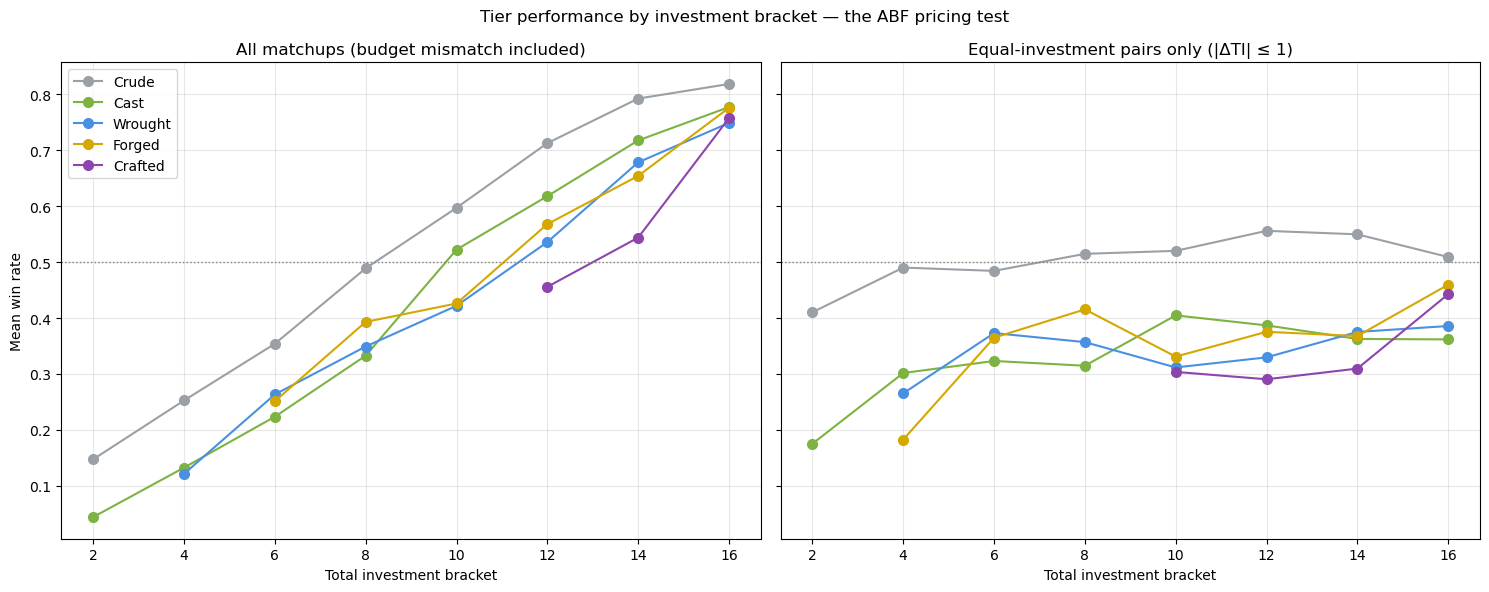


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\tier_bracket_test.png


In [39]:
# ============ Does Crafted lose its bracket at equal investment? ============
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
import renown_combat as rc

TI_BIN = 2          # investment bracket width
EQ_TOL = 1          # "equal investment" = |a_ti - b_ti| <= this
MIN_CELL = 8        # min builds per (tier, bracket) cell

TIER_ORDER = ["Crude", "Cast", "Wrought", "Forged", "Crafted"]
TIER_COLOR = {"Crude":"#9aa0a6","Cast":"#7cb342","Wrought":"#4a90e2","Forged":"#d4a800","Crafted":"#8e44ad"}

# ── build-level frame: tier (from armor, the at-tier slot) + total investment ──
gi = df_main_summary.copy()
gi["tier"] = gi["armor"].map({a: v["tier"] for a, v in rc.ARMORS.items()})
gi["ti"] = gi["pursuits"].fillna("").map(lambda s: len([x for x in s.split("|") if x]) if s else 0)
gi["ti_bin"] = (np.floor(gi["ti"] / TI_BIN) * TI_BIN).astype(int)

# ── Panel A data: mean WR by tier × investment bracket (summary level) ──
pv = gi.pivot_table(index="tier", columns="ti_bin", values="win_rate", aggfunc="mean")
ct = gi.pivot_table(index="tier", columns="ti_bin", values="win_rate", aggfunc="count")
pv = pv.where(ct >= MIN_CELL).reindex(TIER_ORDER)

# ── Panel B data: PAIR-LEVEL, equal-investment matchups only ──
ti_map   = gi.set_index("name")["ti"]
tier_map = gi.set_index("name")["tier"]
mp = df_main_matchups.copy()
mp["a_ti"], mp["b_ti"]     = mp["a_name"].map(ti_map),   mp["b_name"].map(ti_map)
mp["a_tier"], mp["b_tier"] = mp["a_name"].map(tier_map), mp["b_name"].map(tier_map)
eq = mp[(mp["a_ti"] - mp["b_ti"]).abs() <= EQ_TOL].copy()
eq["ti_bin"] = (np.floor(eq["a_ti"] / TI_BIN) * TI_BIN).astype(int)
pv_eq = eq.pivot_table(index="a_tier", columns="ti_bin", values="a_win_rate", aggfunc="mean")
ct_eq = eq.pivot_table(index="a_tier", columns="ti_bin", values="a_win_rate", aggfunc="count")
pv_eq = pv_eq.where(ct_eq >= MIN_CELL * 5).reindex(TIER_ORDER)

print(f"Equal-investment pairs: {len(eq):,} of {len(mp):,} ({len(eq)/len(mp):.0%})")
print("\n=== Mean WR by tier × investment bracket (equal-investment pairs only) ===")
print(pv_eq.round(3).to_string())

# ── THE VERDICT: in every bracket where Crafted and the field coexist, who wins? ──
print("\n=== Verdict per bracket (equal-investment): Crafted vs best other tier ===")
verdict_rows = []
for b in pv_eq.columns:
    col = pv_eq[b].dropna()
    if "Crafted" not in col.index or len(col) < 2:
        continue
    others = col.drop("Crafted")
    best_other = others.idxmax()
    gap = col["Crafted"] - others.max()
    verdict_rows.append({"bracket": b, "crafted_wr": round(col['Crafted'], 3),
                         "best_other": best_other, "other_wr": round(others.max(), 3),
                         "gap": round(gap, 3),
                         "verdict": "WINS" if gap > 0.02 else ("LOSES" if gap < -0.02 else "even")})
vd = pd.DataFrame(verdict_rows)
print(vd.to_string(index=False))
n_lose = (vd["verdict"] == "LOSES").sum()
print(f"\n>>> Crafted LOSES {n_lose}/{len(vd)} shared brackets at equal investment "
      f"{'-> the ABF buff case stands' if n_lose > len(vd)/2 else '-> ABF is fine as priced'}")

# ── Figure ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, data, title in [(axes[0], pv, "All matchups (budget mismatch included)"),
                        (axes[1], pv_eq, f"Equal-investment pairs only (|ΔTI| ≤ {EQ_TOL})")]:
    for tier in TIER_ORDER:
        if tier in data.index and data.loc[tier].notna().any():
            row = data.loc[tier].dropna()
            ax.plot(row.index, row.values, "o-", color=TIER_COLOR[tier], label=tier, markersize=7)
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.set_xlabel("Total investment bracket"); ax.set_title(title); ax.grid(alpha=0.3)
axes[0].set_ylabel("Mean win rate"); axes[0].legend()
plt.suptitle("Tier performance by investment bracket — the ABF pricing test")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tier_bracket_test.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'tier_bracket_test.png')}")

In [40]:
# ============ Is it the weapons or the chassis? Tier × retinue, equal-TI ============
import numpy as np, pandas as pd
import renown_combat as rc

gi = df_main_summary.copy()
gi["tier"] = gi["armor"].map({a: v["tier"] for a, v in rc.ARMORS.items()})
gi["ti"]   = gi["pursuits"].fillna("").map(lambda s: len([x for x in s.split("|") if x]) if s else 0)
ti_map, tier_map, ret_map = (gi.set_index("name")[c] for c in ["ti", "tier", "retinue"])

mp = df_main_matchups.copy()
mp["a_ti"], mp["b_ti"] = mp["a_name"].map(ti_map), mp["b_name"].map(ti_map)
eq = mp[(mp["a_ti"] - mp["b_ti"]).abs() <= 1].copy()
eq["a_tier"], eq["a_ret"] = eq["a_name"].map(tier_map), eq["a_name"].map(ret_map)

pv = eq.pivot_table(index="a_ret", columns="a_tier", values="a_win_rate", aggfunc="mean")
ct = eq.pivot_table(index="a_ret", columns="a_tier", values="a_win_rate", aggfunc="count")
pv = pv.where(ct >= 40)
pv = pv.reindex(index=["Levy","Man-at-Arms","Sergeant","Knight Templar"],
                columns=["Crude","Cast","Wrought","Forged","Crafted"])
print("=== Mean WR (equal-TI pairs): retinue × gear tier ===")
print(pv.round(3).to_string())
print("\nRead ACROSS a row: same chassis, climbing gear.")
print("If rows rise left->right: weapon output works; Crude dominance = chassis pricing.")
print("If rows are flat/falling: output genuinely under-converts (rout clock owns battles).")

=== Mean WR (equal-TI pairs): retinue × gear tier ===
a_tier          Crude   Cast  Wrought  Forged  Crafted
a_ret                                                 
Levy            0.230  0.126    0.141   0.139    0.113
Man-at-Arms     0.495  0.347    0.423   0.508    0.474
Sergeant        0.634  0.488    0.512   0.583    0.647
Knight Templar  0.618  0.494    0.547   0.649    0.609

Read ACROSS a row: same chassis, climbing gear.
If rows rise left->right: weapon output works; Crude dominance = chassis pricing.
If rows are flat/falling: output genuinely under-converts (rout clock owns battles).


In [41]:
sub = eq[(eq["a_ret"]=="Knight Templar") & (eq["a_tier"]=="Crafted")]
print(sub.groupby((np.floor(sub["a_ti"]/2)*2).astype(int))["a_win_rate"].agg(["mean","count"]).round(3))

       mean  count
a_ti              
16    0.609    235


=== Impact sequence: each step = biggest single factor in what's left unexplained ===
 step               factor  r2_of_residual  cumulative_r2                    best_vs_worst
    1               ti_bin           0.516          0.516                16 0.77 vs 2 0.14
    2              retinue           0.576          0.795 Knight Templar 0.74 vs Levy 0.21
    3               weapon           0.222          0.834      Poleaxe 0.81 vs Cudgel 0.27
    4 has Grand Tournament           0.062          0.845              yes 0.54 vs no 0.42
    5        has Carpentry           0.062          0.854              yes 0.52 vs no 0.37
    6       has Preceptory           0.054          0.862              yes 0.59 vs no 0.40
    7                 tier           0.048          0.869         Forged 0.58 vs Cast 0.39
    8       has Apothecary           0.036          0.874              yes 0.58 vs no 0.42


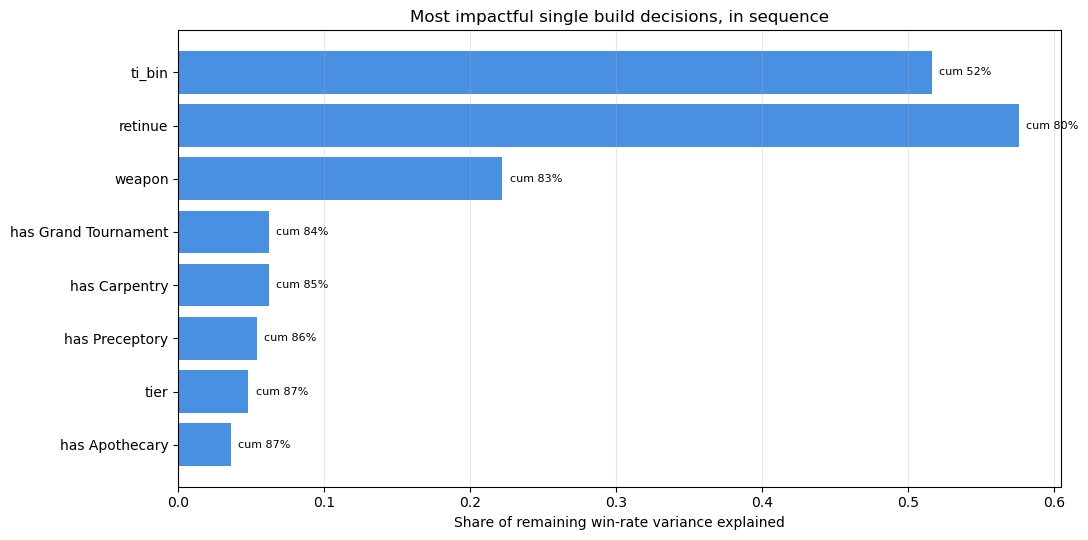


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\impact_sequence.png


In [42]:
# ============ Greedy impact ranking: which single choices explain win rate, in order ============
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
import renown_combat as rc

df = df_main_summary.copy()
N_STEPS   = 8        # how many factors to extract
MIN_GROUP = 15       # min builds per category level to count
P_MIN, P_MAX = 0.05, 0.95   # pursuit flags must be neither rare nor universal

# ── candidate features ──
df["shield"] = df["shield"].replace("", "None").fillna("None")
df["ranged"] = df["ranged"].replace("", "None").fillna("None")
df["tier"]   = df["armor"].map({a: v["tier"] for a, v in rc.ARMORS.items()})
df["ti"]     = df["pursuits"].fillna("").map(lambda s: len([x for x in s.split("|") if x]) if s else 0)
df["ti_bin"] = (np.floor(df["ti"] / 2) * 2).astype(int)

cands = {c: df[c] for c in ["retinue", "tier", "weapon", "shield", "ranged", "ti_bin"]}
# one binary flag per pursuit ("has Hospitaller", ...)
all_pursuits = sorted({p for s in df["pursuits"].fillna("") for p in s.split("|") if p})
for p in all_pursuits:
    flag = df["pursuits"].fillna("").str.contains(p, regex=False)
    if P_MIN <= flag.mean() <= P_MAX:
        cands[f"has {p}"] = flag.map({True: "yes", False: "no"})

def r2_of(resid, series):
    """Variance of resid explained by grouping on series (levels with >= MIN_GROUP)."""
    g = resid.groupby(series)
    sizes = g.size()
    ok = series.isin(sizes[sizes >= MIN_GROUP].index)
    if ok.sum() < len(resid) * 0.5 or series[ok].nunique() < 2:
        return np.nan, None
    r, s = resid[ok], series[ok]
    means = r.groupby(s).transform("mean")
    sst = ((r - r.mean()) ** 2).sum()
    return (1 - ((r - means) ** 2).sum() / sst if sst > 0 else 0.0), means

# ── greedy sequence: pick best factor, residualize, repeat ──
resid = df["win_rate"].astype(float).copy()
total_var = resid.var()
rows, chosen = [], set()
for step in range(1, N_STEPS + 1):
    best = None
    for name, series in cands.items():
        if name in chosen:
            continue
        r2, means = r2_of(resid, series)
        if not np.isnan(r2) and (best is None or r2 > best[1]):
            best = (name, r2, means, series)
    if best is None or best[1] <= 0.002:
        break
    name, r2, means, series = best
    chosen.add(name)
    # cumulative share of the ORIGINAL win-rate variance now explained
    resid = resid - means.reindex(resid.index).fillna(0) + resid.mean() * 0  # center-preserving
    resid = resid - resid.mean()
    cum = 1 - resid.var() / total_var
    lvl = df.loc[series.index].assign(_f=series).groupby("_f")["win_rate"].mean()
    spread = f"{lvl.idxmax()} {lvl.max():.2f} vs {lvl.idxmin()} {lvl.min():.2f}"
    rows.append({"step": step, "factor": name, "r2_of_residual": round(r2, 3),
                 "cumulative_r2": round(cum, 3), "best_vs_worst": spread})

seq = pd.DataFrame(rows)
print("=== Impact sequence: each step = biggest single factor in what's left unexplained ===")
print(seq.to_string(index=False))

# ── figure ──
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(seq["factor"][::-1], seq["r2_of_residual"][::-1], color="#4a90e2")
for y, (r2v, cumv) in enumerate(zip(seq["r2_of_residual"][::-1], seq["cumulative_r2"][::-1])):
    ax.text(r2v + 0.005, y, f"cum {cumv:.0%}", va="center", fontsize=8)
ax.set_xlabel("Share of remaining win-rate variance explained")
ax.set_title("Most impactful single build decisions, in sequence")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "impact_sequence.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'impact_sequence.png')}")


=== Best builds by ARMOR ===

  Chainmail  (n=570, mean WR 0.517)
    0.963  Man-at-Arms  Bastard Sword  None          Chainmail     | Animal Husbandry|Apothecary|Armory|Blacksmith|Carpentry|Coli
    0.949  Man-at-Arms  2HBastard      None          Chainmail     | Animal Husbandry|Apothecary|Armory|Blacksmith|Carpentry|Coli
    0.948  Man-at-Arms  2HBastard      None          Chainmail     | Animal Husbandry|Apothecary|Armory|Blacksmith|Carpentry|Coli

  Cloth  (n=1741, mean WR 0.424)
    0.973  Sergeant     2HBastard      None          Cloth         | Apothecary|Blacksmith|Carpentry|Coliseum|Fletchery|Forge|Gra
    0.966  Knight Templ Halberd        None          Cloth         | Abbey|Apothecary|Blacksmith|Carpentry|Coliseum|Fletchery|Gra
    0.960  Knight Templ Pike           None          Cloth         | Abbey|Apothecary|Blacksmith|Carpentry|Coliseum|Fletchery|Gra

  Full Plate  (n=559, mean WR 0.583)
    0.976  Man-at-Arms  Bastard Sword  Tower Shield  Full Plate    | Animal Husba

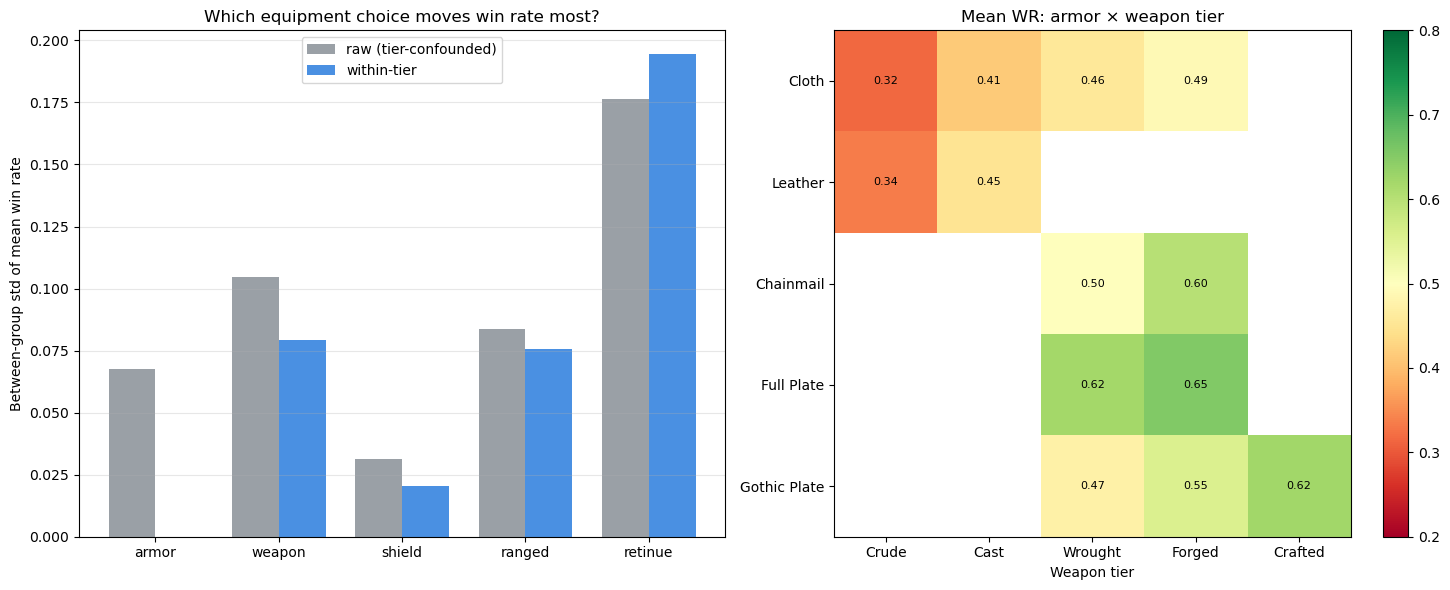


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\equipment_sensitivity.png


In [43]:
# ============ Best loadouts by equipment + sensitivity decomposition ============
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
import renown_combat as rc

df = df_main_summary.copy()
MIN_N_GROUP = 5      # min loadouts for a group to count
TOP_K       = 3      # best builds shown per equipment value

df["shield"]  = df["shield"].replace("", "None").fillna("None")
df["ranged"]  = df["ranged"].replace("", "None").fillna("None")
df["tier"]    = df["armor"].map({a: v["tier"] for a, v in rc.ARMORS.items()})

DIMS = ["armor", "weapon", "shield", "ranged", "retinue"]

# ── 1) Best loadouts per equipment value ──
print("=" * 100)
for dim in DIMS:
    print(f"\n=== Best builds by {dim.upper()} ===")
    for val, sub in df.groupby(dim):
        if len(sub) < MIN_N_GROUP or val == "None":
            continue
        top = sub.nlargest(TOP_K, "win_rate")
        print(f"\n  {val}  (n={len(sub)}, mean WR {sub['win_rate'].mean():.3f})")
        for _, r in top.iterrows():
            gear = f"{r['retinue'][:12]:12} {str(r['weapon'])[:14]:14} {str(r['shield'])[:13]:13} {r['armor'][:12]:12}"
            print(f"    {r['win_rate']:.3f}  {gear}  | {r['pursuits'][:60]}")

# ── 2) Sensitivity: how much does each dimension move win rate? ──
def sensitivity(frame, dim, min_n=MIN_N_GROUP):
    """Weighted between-group std of group-mean WR = how much choosing along
    this dimension matters. Bigger = more sensitive."""
    g = frame.groupby(dim)["win_rate"].agg(["mean", "count"])
    g = g[g["count"] >= min_n]
    if len(g) < 2:
        return np.nan, g
    w = g["count"] / g["count"].sum()
    grand = (g["mean"] * w).sum()
    return np.sqrt((w * (g["mean"] - grand) ** 2).sum()), g

print("\n" + "=" * 100)
print("=== Sensitivity (between-group std of mean WR) ===")
raw_sens, within_sens = {}, {}
for dim in DIMS:
    raw_sens[dim], _ = sensitivity(df, dim)
    # tier-controlled: sensitivity within each tier, weighted by tier size
    parts = []
    for tier, tsub in df.groupby("tier"):
        s, _ = sensitivity(tsub, dim)
        if not np.isnan(s):
            parts.append((s, len(tsub)))
    within_sens[dim] = (np.average([s for s, n in parts], weights=[n for s, n in parts])
                        if parts else np.nan)
    print(f"  {dim:8}  raw {raw_sens[dim]:.3f}   within-tier {within_sens[dim]:.3f}")
print("\n  raw = includes the tier confound; within-tier = the dimension's own effect.")

# ── 3) Figure: sensitivity bars + armor × weapon-tier heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
x = np.arange(len(DIMS)); w = 0.38
ax.bar(x - w/2, [raw_sens[d] for d in DIMS], w, label="raw (tier-confounded)", color="#9aa0a6")
ax.bar(x + w/2, [within_sens[d] for d in DIMS], w, label="within-tier", color="#4a90e2")
ax.set_xticks(x); ax.set_xticklabels(DIMS)
ax.set_ylabel("Between-group std of mean win rate")
ax.set_title("Which equipment choice moves win rate most?")
ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axes[1]
WT = {w_: v["tier"] for w_, v in rc.WEAPONS.items()}
df["wtier"] = df["weapon"].map(WT)
pv = df.pivot_table(index="armor", columns="wtier", values="win_rate", aggfunc="mean")
pv = pv.reindex(index=[a for a in rc.ARMORS if a in pv.index],
                columns=[t for t in ["Crude","Cast","Wrought","Forged","Crafted"] if t in pv.columns])
im = ax.imshow(pv.values, cmap="RdYlGn", vmin=0.2, vmax=0.8, aspect="auto")
ax.set_xticks(range(len(pv.columns))); ax.set_xticklabels(pv.columns)
ax.set_yticks(range(len(pv.index))); ax.set_yticklabels(pv.index)
ax.set_xlabel("Weapon tier"); ax.set_title("Mean WR: armor × weapon tier")
for i in range(len(pv.index)):
    for j in range(len(pv.columns)):
        v = pv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "equipment_sensitivity.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'equipment_sensitivity.png')}")

## 4.2 Shield performance

In [44]:
sh = df_main_summary.copy()
sh["shield"] = sh["shield"].fillna("None")
sh = sh.groupby("shield").agg(
    n=("name","count"),
    win_rate=("win_rate","mean"),
    decisive_win_rate=("decisive_win_rate","mean"),
    kill_eff=("kill_efficiency","mean"),
).sort_values("win_rate", ascending=False)
print("=== Shield performance ===")
print(sh.round(3).to_string())

=== Shield performance ===
                  n  win_rate  decisive_win_rate  kill_eff
shield                                                    
Tower Shield    147     0.553              0.695     7.133
Heater Shield   102     0.515              0.651     6.366
Scutum Shield   117     0.507              0.618     3.782
None           2784     0.466              0.531     0.781
Kite Shield     113     0.440              0.511     0.354
Wooden Shield   194     0.372              0.426    -2.339


## 4.3 Armor performance

In [45]:
arm = df_main_summary.groupby("armor").agg(
    n=("name","count"),
    win_rate=("win_rate","mean"),
    decisive_win_rate=("decisive_win_rate","mean"),
    survivors=("avg_self_survivors","mean"),
).sort_values("win_rate", ascending=False)
print("=== Armor performance ===")
print(arm.round(3).to_string())

=== Armor performance ===
                 n  win_rate  decisive_win_rate  survivors
armor                                                     
Full Plate     559     0.583              0.691      9.091
Gothic Plate   127     0.562              0.692      9.251
Chainmail      570     0.517              0.595      6.986
Cloth         1741     0.424              0.480      5.339
Leather        460     0.393              0.460      5.284


In [46]:
# Diagnose what's actually in df_main_summary
print("ARMORS present:", df_main_summary["armor"].value_counts().to_dict())
print("\nRETINUES present:", df_main_summary["retinue"].value_counts().to_dict())
print("\nMPC range:", df_main_summary["military_pursuit_count"].min(), "-", df_main_summary["military_pursuit_count"].max())
print("Total builds:", len(df_main_summary))
# Cross: which retinues have which armors (shows if tier floors are excluding light armor)
print("\nArmor x Retinue:")
print(df_main_summary.groupby(["retinue","armor"]).size().unstack(fill_value=0))

ARMORS present: {'Cloth': 1741, 'Chainmail': 570, 'Full Plate': 559, 'Leather': 460, 'Gothic Plate': 127}

RETINUES present: {'Sergeant': 1040, 'Levy': 969, 'Man-at-Arms': 962, 'Knight Templar': 486}

MPC range: 2 - 14
Total builds: 3457

Armor x Retinue:
armor           Chainmail  Cloth  Full Plate  Gothic Plate  Leather
retinue                                                            
Knight Templar         58    301          46             1       80
Levy                  193    372         211            62      131
Man-at-Arms           166    490         151            41      114
Sergeant              153    578         151            23      135


## 4.4 Bastard Sword — does the dual-profile actually help?

Compare Bastard 1H+shield builds vs Bastard 2H builds vs other 2H weapons (Poleaxe, Halberd, etc.).

In [47]:
bast = df_main_summary[df_main_summary["weapon"] == "Bastard Sword"].copy()
bast["mode"] = np.where(bast["shield"].fillna("None") == "None", "Bastard 2H", "Bastard 1H+shield")
b_summary = bast.groupby("mode").agg(
    n=("name","count"),
    win_rate=("win_rate","mean"),
    decisive_win_rate=("decisive_win_rate","mean"),
    kill_eff=("kill_efficiency","mean"),
).round(3)
print("=== Bastard Sword variants ===")
print(b_summary.to_string())

# Compare to other heavy weapons
print()
print("=== Other heavy 2H weapons for reference ===")
other = df_main_summary[df_main_summary["weapon"].isin(["Poleaxe","Halberd","War Hammer","Battle Axe","2HBastard"])]
print(other.groupby("weapon").agg(
    n=("name","count"),
    win_rate=("win_rate","mean"),
    decisive_win_rate=("decisive_win_rate","mean"),
).round(3).to_string())

=== Bastard Sword variants ===
                    n  win_rate  decisive_win_rate  kill_eff
mode                                                        
Bastard 1H+shield  89     0.587              0.724     7.866
Bastard 2H         41     0.727              0.794     8.153

=== Other heavy 2H weapons for reference ===
              n  win_rate  decisive_win_rate
weapon                                      
2HBastard   355     0.595              0.654
Battle Axe  218     0.519              0.585
Halberd     222     0.487              0.550
Poleaxe      15     0.806              0.899
War Hammer  308     0.482              0.550


## 4.5 Lance — does Charge synergy pay off?

In [48]:
lance = df_main_summary[df_main_summary["weapon"] == "Lance"]
non_lance = df_main_summary[df_main_summary["weapon"] != "Lance"]
print(f"Lance loadouts:  n={len(lance):3d}  win_rate={lance['win_rate'].mean():.3f}  decisive_wr={lance['decisive_win_rate'].mean():.3f}")
print(f"Non-Lance:       n={len(non_lance):3d}  win_rate={non_lance['win_rate'].mean():.3f}  decisive_wr={non_lance['decisive_win_rate'].mean():.3f}")
# Best lance shields
if len(lance) > 0:
    print("\nLance shield breakdown:")
    print(lance.groupby("shield").agg(n=("name","count"), wr=("win_rate","mean")).round(3).to_string())

Lance loadouts:  n=106  win_rate=0.525  decisive_wr=0.610
Non-Lance:       n=3351  win_rate=0.464  decisive_wr=0.536

Lance shield breakdown:
                n     wr
shield                  
Heater Shield  18  0.594
Scutum Shield  38  0.542
Wooden Shield  50  0.487


## 4.6 Shield deep-dive

A focused analysis of shield builds across all metrics. Shield types map to gear tiers (Wooden=Crude, Kite=Cast, Scutum=Wrought, Tower=Forged, Heater=Crafted) per the loadout rules — so this also doubles as a tier-by-tier comparison of shielded builds.

### 4.6.1 Win rate by shield type

In [49]:
# Filter to shield-bearing matchup rows (A side)
shield_df = df_main_matchups[df_main_matchups['a_shield'].notna() & (df_main_matchups['a_shield'] != '')].copy()
shield_df['n_battles'] = shield_df['a_wins'] + shield_df['b_wins'] + shield_df['mut_wipe'] + shield_df['indecisive']
print(f'Shield-bearing matchup rows: {len(shield_df):,} (of {len(df_main_matchups):,} total)')

# Per-loadout aggregation
shield_winrate = shield_df.groupby(['a_name', 'a_shield', 'a_retinue', 'a_weapon', 'a_armor']).agg(
    n_battles=('n_battles', 'sum'),
    wins=('a_wins', 'sum'),
    losses=('b_wins', 'sum'),
    mutual=('mut_wipe', 'sum'),
).reset_index()
shield_winrate['win_rate'] = shield_winrate['wins'] / shield_winrate['n_battles']
shield_winrate['decisive_win_rate'] = shield_winrate['wins'] / shield_winrate[['wins','losses']].sum(axis=1).clip(lower=1)
shield_winrate = shield_winrate.sort_values('win_rate', ascending=False)

print('\n=== Win rate by shield type (aggregate) ===')
by_type = shield_winrate.groupby('a_shield').agg(
    n_loadouts=('a_name', 'count'),
    avg_win_rate=('win_rate', 'mean'),
    avg_decisive_wr=('decisive_win_rate', 'mean'),
).sort_values('avg_win_rate', ascending=False)
print(by_type.round(3).to_string())

Shield-bearing matchup rows: 1,863,741 (of 9,313,192 total)

=== Win rate by shield type (aggregate) ===
               n_loadouts  avg_win_rate  avg_decisive_wr
a_shield                                                
Tower Shield       255740         0.553              0.0
Heater Shield      255740         0.515              0.0
Scutum Shield      255740         0.507              0.0
Kite Shield        255740         0.440              0.0
Wooden Shield      255740         0.372              0.0
                   255740           NaN              0.0


### 4.6.2 Durability — survival rates by shield

In [50]:
# Use analysis.durability and join shield info back in
dur = analysis.durability(df_main_matchups)
shield_lookup = df_main_matchups.groupby('a_name')['a_shield'].first().to_dict()
dur['shield'] = dur['a_name'].map(shield_lookup).fillna('None')

dur_by_shield = dur.groupby('shield').agg(
    n_loadouts=('a_name', 'count'),
    avg_survival_rate=('avg_survival_rate', 'mean'),
).sort_values('avg_survival_rate', ascending=False)
print('=== Survival rate by shield type ===')
print(dur_by_shield.round(3).to_string())

print('\n=== Top 10 most durable shield builds ===')
top_shield_dur = dur[dur['shield'] != 'None'].nlargest(10, 'avg_survival_rate')[
    ['a_name','shield','avg_survival_rate']]
print(top_shield_dur.round(3).to_string(index=False))

=== Survival rate by shield type ===
               n_loadouts  avg_survival_rate
shield                                      
Tower Shield          147              0.380
Heater Shield         102              0.350
Scutum Shield         117              0.295
                     2784              0.248
Kite Shield           113              0.247
Wooden Shield         194              0.182

=== Top 10 most durable shield builds ===
                                                                                                                        a_name        shield  avg_survival_rate
                               KT/Morningstar/Heater/Gothic [ABFM, PrM, (SInd, EProw, SPie, NCun), Temp, Rec 5, Serr, Shake+1] Heater Shield              0.764
       MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]  Tower Shield              0.745
                                         Sgt/Lance/Heater/Gothic [ABFM, (SInd, E

### 4.6.3 Shield destruction rate

How often does each shield get smashed mid-battle? Wooden + Cast tier shields are most fragile; Heater the toughest.

In [51]:
# Drop mirror matchups
sd_df = shield_df[shield_df['a_name'] != shield_df['b_name']].copy()
destroy_by_type = sd_df.groupby('a_shield').agg(
    n_matchups=('a_shield', 'count'),
    avg_destroy_pct=('a_shield_destroyed_rate', lambda x: x.mean() * 100),
).sort_values('avg_destroy_pct', ascending=False)
print('=== Avg shield destruction rate by type ===')
print(destroy_by_type.round(1).to_string())

# Top 10 most-destroyed shield builds
print('\n=== Top 10 most-destroyed shield builds ===')
top_destroyed = sd_df.groupby(['a_name', 'a_shield']).agg(
    avg_destroy_pct=('a_shield_destroyed_rate', lambda x: x.mean() * 100),
).reset_index().sort_values('avg_destroy_pct', ascending=False).head(10)
print(top_destroyed.round(1).to_string(index=False))

=== Avg shield destruction rate by type ===
               n_matchups  avg_destroy_pct
a_shield                                  
Kite Shield        300092             11.4
Wooden Shield      535750             11.3
Tower Shield       410543             11.0
Scutum Shield      320455             11.0
Heater Shield      296901              0.0
                        0              NaN

=== Top 10 most-destroyed shield builds ===
                                                                                          a_name      a_shield  avg_destroy_pct
                 Lev/FarmTools/Wooden/Cloth [OuInPoM, (RInd, EProw, NPie, SCun), Improved Parry] Wooden Shield             12.4
                                 Sgt/FarmTools/Wooden/Cloth [OuInPoM, (RInd, EProw, NPie, SCun)] Wooden Shield             12.4
         Lev/FarmTools/Kite/Leather [OuInPoM, (RInd, RProw, EPie, SCun), Poison, Rec 4, Shake+1]   Kite Shield             12.4
                        Lev/FarmTools/Wooden/Cloth [OuI

### 4.6.4 What counters shield builds?

For each shield type, which weapons/loadouts beat them most reliably?

In [52]:
def top_counters_for_shield(shield_name, top_n=8):
    rows = df_main_matchups[
        (df_main_matchups['a_shield'] == shield_name) &
        (df_main_matchups['a_name'] != df_main_matchups['b_name'])
    ].copy()
    if len(rows) == 0:
        return None
    rows['n_battles'] = rows['a_wins'] + rows['b_wins'] + rows['mut_wipe'] + rows['indecisive']
    rows['a_winrate'] = rows['a_wins'] / rows['n_battles']
    rows['b_winrate'] = rows['b_wins'] / rows['n_battles']
    counters = rows.groupby(['b_weapon', 'b_retinue', 'b_shield']).agg(
        b_wr=('b_winrate', 'mean'),
        a_wr=('a_winrate', 'mean'),
        n=('a_name', 'count'),
    ).reset_index()
    counters['margin'] = counters['b_wr'] - counters['a_wr']
    counters = counters[counters['n'] >= 5].sort_values('margin', ascending=False).head(top_n)
    return counters

for shield_type in ['Wooden Shield','Kite Shield','Scutum Shield','Tower Shield','Heater Shield']:
    c = top_counters_for_shield(shield_type)
    if c is not None and len(c) > 0:
        print(f'\n=== Top counters for {shield_type} ===')
        print(c.round(3).to_string(index=False))


=== Top counters for Wooden Shield ===
     b_weapon      b_retinue      b_shield  b_wr  a_wr    n  margin
        Lance       Sergeant Heater Shield 0.960 0.013  900   0.947
  Morningstar Knight Templar Heater Shield 0.929 0.011  124   0.918
        Lance Knight Templar Scutum Shield 0.929 0.037  248   0.891
        Estoc       Sergeant Heater Shield 0.919 0.033  353   0.886
Cavalry Spear       Sergeant Heater Shield 0.909 0.029  778   0.879
Bastard Sword Knight Templar  Tower Shield 0.894 0.017  124   0.877
Bastard Sword       Sergeant Heater Shield 0.910 0.039  364   0.870
Bastard Sword       Sergeant  Tower Shield 0.899 0.036 3013   0.863

=== Top counters for Kite Shield ===
     b_weapon      b_retinue      b_shield  b_wr  a_wr   n  margin
        Lance       Sergeant Heater Shield 0.946 0.007 533   0.939
        Lance Knight Templar Scutum Shield 0.931 0.006 146   0.925
        Lance       Sergeant Scutum Shield 0.919 0.024 283   0.894
        Estoc       Sergeant Heater Shield

### 4.6.5 What do shield builds dominate?

Inverse — for each shield type, what loadouts do they beat reliably?

In [53]:
def shield_matchup_grid(shield_name, min_n=5):
    """Full attacker-retinue × defender-retinue favorable-matchup grid for a shield.

    For each (attacker retinue, defender retinue) cell, shows the shield's mean win rate
    and the top favorable weapon matchups within that cell — so you can read e.g.
    'Scutum-KT vs Sergeant-tier opponents' without Levy noise on either side.
    """
    rows = df_main_matchups[
        (df_main_matchups['a_shield'] == shield_name) &
        (df_main_matchups['a_name'] != df_main_matchups['b_name'])
    ].copy()
    if len(rows) == 0:
        print(f"\n(no data for {shield_name})")
        return
    rows['n_battles'] = rows['a_wins'] + rows['b_wins'] + rows['mut_wipe'] + rows['indecisive']
    rows['a_winrate'] = rows['a_wins'] / rows['n_battles']
    rows['b_winrate'] = rows['b_wins'] / rows['n_battles']

    RETS = ['Levy', 'Man-at-Arms', 'Sergeant', 'Knight Templar']

    # ── Summary grid: mean win rate per (attacker ret × defender ret) ──
    grid = rows.groupby(['a_retinue', 'b_retinue']).agg(
        a_wr=('a_winrate', 'mean'), n=('a_name', 'count')
    ).reset_index()
    pivot = grid.pivot(index='a_retinue', columns='b_retinue', values='a_wr')
    pivot = pivot.reindex(index=[r for r in RETS if r in pivot.index],
                          columns=[r for r in RETS if r in pivot.columns])
    print(f"\n{'='*70}\n{shield_name}: mean win rate by attacker retinue (rows) × defender retinue (cols)\n{'='*70}")
    print(pivot.round(3).to_string())

    # ── Detailed: top favorable weapon matchups per attacker×defender cell ──
    for a_ret in RETS:
        for b_ret in RETS:
            sub = rows[(rows['a_retinue'] == a_ret) & (rows['b_retinue'] == b_ret)]
            if len(sub) == 0:
                continue
            targets = sub.groupby(['b_weapon', 'b_shield']).agg(
                a_wr=('a_winrate', 'mean'),
                b_wr=('b_winrate', 'mean'),
                n=('a_name', 'count'),
            ).reset_index()
            targets['margin'] = targets['a_wr'] - targets['b_wr']
            targets = targets[targets['n'] >= min_n].sort_values('margin', ascending=False).head(4)
            if len(targets) == 0:
                continue
            print(f'\n  {shield_name} · {a_ret} vs {b_ret}-tier opponents:')
            print(targets.round(3).to_string(index=False).replace('\n', '\n    '))


for shield_type in ['Wooden Shield', 'Kite Shield', 'Scutum Shield', 'Tower Shield', 'Heater Shield']:
    shield_matchup_grid(shield_type)


Wooden Shield: mean win rate by attacker retinue (rows) × defender retinue (cols)
b_retinue        Levy  Man-at-Arms  Sergeant  Knight Templar
a_retinue                                                   
Levy            0.273        0.112     0.076           0.009
Man-at-Arms     0.568        0.349     0.283           0.114
Sergeant        0.620        0.420     0.347           0.185
Knight Templar  0.916        0.574     0.506             NaN

  Wooden Shield · Levy vs Levy-tier opponents:
  b_weapon      b_shield  a_wr  b_wr    n  margin
    Farm Tools Wooden Shield 0.475 0.188 1014   0.287
       Daggers               0.471 0.238 2243   0.233
        Cudgel               0.417 0.245 2784   0.172
    War Hammer               0.423 0.291 3369   0.132

  Wooden Shield · Levy vs Man-at-Arms-tier opponents:
     b_weapon      b_shield  a_wr  b_wr    n  margin
           Cudgel               0.204 0.570 3386  -0.366
       Farm Tools Wooden Shield 0.201 0.610 1168  -0.409
    Cavalry Spe

### 4.6.6 Best tactics for shield builds

For one representative loadout per shield type, what's the best opening tactic?

In [54]:
# Pick the top-winrate loadout for each shield type from shield_winrate
representatives = []
for shield_type in ['Wooden Shield', 'Kite Shield', 'Scutum Shield', 'Tower Shield', 'Heater Shield']:
    matches = shield_winrate[shield_winrate['a_shield'] == shield_type]
    if len(matches) > 0:
        representatives.append(matches.iloc[0]['a_name'])

# Use the empirical tactic matrix (loaded in Section 1E) as a proxy for tactic guidance.
# For per-loadout tactic profile, see Section 5.
if df_tactic_matrix is not None:
    _tac_pivot = df_tactic_matrix.pivot(index='a_tactic', columns='b_tactic', values='a_win_rate')
    _tac_pivot = _tac_pivot.reindex(index=TACTICS, columns=TACTICS)
    marginal_wr = _tac_pivot.mean(axis=1).sort_values(ascending=False)

    print('Marginal tactic win rates (best openings against a uniform-tactic opponent):')
    for t, wr in marginal_wr.items():
        print(f'  {t:<22} {wr:.3f}')

    print(f'\nRepresentative shield builds (best win-rate loadout per shield type):')
    for name in representatives:
        print(f'  {name}')
else:
    print('Tactic matrix not loaded — skip')

Marginal tactic win rates (best openings against a uniform-tactic opponent):
  Flank                  0.438
  Fighting Formation     0.437
  Charge                 0.436
  Defensive Formation    0.392
  Scout                  0.388
  Ambush                 0.383
  Fall Back              0.169

Representative shield builds (best win-rate loadout per shield type):
  KT/HuntBow/Wooden/Cloth [RoPaM, PrM, (RInd, SProw, SPie, NCun), ImmU, Improved Parry, Rec 4, Shake+1]
  Sgt/ShortSword+Longbow/Kite/Leather (TY) [RoPaM, MiMiStI, (RInd, SProw, EPie, RCun), ImmU, Improved Parry, Poison, Rec 4, Shake+1]
  MaA/Arming+Longbow/Scutum/Chain (TY) [RoPaM, PrI, (RInd, SProw, SPie, RCun), ImmU, Improved Parry, Poison, Rec 4, Shake+1]
  MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]
  Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, EPie, NCun), Temp, Rec 4, Serr, Shake+1]


### 4.6.7 Shield summary

In [55]:
print('=== Shield Findings Summary ===')
print()
print('1. Win rate by shield (mean across loadouts):')
print(by_type[['n_loadouts','avg_win_rate','avg_decisive_wr']].round(3).to_string())
print()
print('2. Durability ranking:')
print(dur_by_shield.round(3).to_string())
print()
print('3. Destruction frequency (lower = tougher shield):')
print(destroy_by_type.round(1).to_string())

=== Shield Findings Summary ===

1. Win rate by shield (mean across loadouts):
               n_loadouts  avg_win_rate  avg_decisive_wr
a_shield                                                
Tower Shield       255740         0.553              0.0
Heater Shield      255740         0.515              0.0
Scutum Shield      255740         0.507              0.0
Kite Shield        255740         0.440              0.0
Wooden Shield      255740         0.372              0.0
                   255740           NaN              0.0

2. Durability ranking:
               n_loadouts  avg_survival_rate
shield                                      
Tower Shield          147              0.380
Heater Shield         102              0.350
Scutum Shield         117              0.295
                     2784              0.248
Kite Shield           113              0.247
Wooden Shield         194              0.182

3. Destruction frequency (lower = tougher shield):
               n_matchups  av

## 4.7 Bastard Sword deep-dive

The dual-profile weapon: 1H mode (with shield) provides Shatter Armor + Steady; 2H mode (no shield, OR shield destroyed) provides Cleave + Unwieldy. Adaptive: a Bastard+shield build automatically switches to 2H mode if the shield breaks. How does this adaptive mechanic perform in practice?

### 4.7.1 Overall comparison — Bastard 1H vs 2H vs other

In [56]:
bastard_df = df_main_matchups[df_main_matchups['a_weapon'] == 'Bastard Sword'].copy()
bastard_df['n_battles'] = bastard_df['a_wins'] + bastard_df['b_wins'] + bastard_df['mut_wipe'] + bastard_df['indecisive']
bastard_df['mode'] = bastard_df['a_shield'].apply(
    lambda s: '2H (no shield)' if (pd.isna(s) or s == '') else f'1H + {s}')
print(f'Bastard Sword matchup rows: {len(bastard_df):,}\n')

mode_winrate = bastard_df.groupby(['a_name', 'mode', 'a_retinue', 'a_armor']).agg(
    n_battles=('n_battles', 'sum'),
    wins=('a_wins', 'sum'),
    losses=('b_wins', 'sum'),
).reset_index()
mode_winrate['win_rate'] = mode_winrate['wins'] / mode_winrate['n_battles']
mode_winrate['decisive_wr'] = mode_winrate['wins'] / mode_winrate[['wins','losses']].sum(axis=1).clip(lower=1)
mode_winrate = mode_winrate.sort_values('win_rate', ascending=False)

print('=== Bastard variants — mean win rate by mode ===')
by_mode = mode_winrate.groupby('mode').agg(
    n_loadouts=('a_name', 'count'),
    avg_win_rate=('win_rate', 'mean'),
    avg_decisive_wr=('decisive_wr', 'mean'),
).sort_values('avg_win_rate', ascending=False)
print(by_mode.round(3).to_string())
print('\n=== Top 10 Bastard builds (any mode) ===')
print(mode_winrate.head(10)[['a_name','mode','a_retinue','win_rate','decisive_wr']].round(3).to_string(index=False))

Bastard Sword matchup rows: 360,751

=== Bastard variants — mean win rate by mode ===
                    n_loadouts  avg_win_rate  avg_decisive_wr
mode                                                         
2H (no shield)            2600         0.727            0.013
1H + Tower Shield         2600         0.610            0.020
1H + Heater Shield        2600         0.499            0.005
1H + Kite Shield          2600           NaN            0.000
1H + Scutum Shield        2600           NaN            0.000
1H + Wooden Shield        2600           NaN            0.000

=== Top 10 Bastard builds (any mode) ===
                                                                                                                        a_name               mode      a_retinue  win_rate  decisive_wr
       MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]  1H + Tower Shield    Man-at-Arms     0.976        0.998
        

### 4.7.2 Adaptive value — does mode-switching pay off?

How often does a Bastard+shield build have its shield destroyed mid-battle, forcing the 2H mode switch? Pair that with win rate to see whether the adaptive mechanic is actually delivering value.

### 4.7.3 Counters for each Bastard mode

In [57]:
def bastard_counters(filter_func, label, n=8):
    rows = df_main_matchups[filter_func(df_main_matchups) &
                            (df_main_matchups['a_name'] != df_main_matchups['b_name'])].copy()
    if len(rows) == 0:
        return
    rows['n_battles'] = rows['a_wins'] + rows['b_wins'] + rows['mut_wipe'] + rows['indecisive']
    rows['a_wr'] = rows['a_wins'] / rows['n_battles']
    rows['b_wr'] = rows['b_wins'] / rows['n_battles']
    counters = rows.groupby(['b_weapon', 'b_retinue', 'b_shield']).agg(
        b_wr=('b_wr', 'mean'),
        a_wr=('a_wr', 'mean'),
        n_pairs=('a_name', 'count'),
    ).reset_index()
    counters['margin'] = counters['b_wr'] - counters['a_wr']
    counters = counters[counters['n_pairs'] >= 5].sort_values('margin', ascending=False).head(n)
    print(f'\n=== Top counters for {label} ===')
    print(counters.round(3).to_string(index=False))

# 1H mode (has shield)
bastard_counters(
    lambda d: (d['a_weapon'] == 'Bastard Sword') & d['a_shield'].notna() & (d['a_shield'] != ''),
    'Bastard 1H+shield')
# 2H mode (no shield)
bastard_counters(
    lambda d: (d['a_weapon'] == 'Bastard Sword') & ((d['a_shield'].isna()) | (d['a_shield'] == '')),
    'Bastard 2H')


=== Top counters for Bastard 1H+shield ===
     b_weapon      b_retinue      b_shield  b_wr  a_wr  n_pairs  margin
                    Sergeant  Tower Shield 0.740 0.034      321   0.706
  Morningstar Knight Templar Heater Shield 0.685 0.032       59   0.654
        Lance Knight Templar Scutum Shield 0.695 0.077      156   0.618
              Knight Templar  Tower Shield 0.610 0.036       78   0.574
  Morningstar       Sergeant Heater Shield 0.644 0.071      186   0.574
                 Man-at-Arms  Tower Shield 0.640 0.069      250   0.571
Bastard Sword Knight Templar  Tower Shield 0.585 0.041       78   0.544
 Arming Sword Knight Templar  Tower Shield 0.572 0.043      234   0.530

=== Top counters for Bastard 2H ===
     b_weapon      b_retinue      b_shield  b_wr  a_wr  n_pairs  margin
        Lance       Sergeant Heater Shield 0.924 0.029      185   0.896
        Estoc       Sergeant Heater Shield 0.838 0.074       72   0.763
  Morningstar Knight Templar Heater Shield 0.785 0.033 

### 4.7.4 Best shield pairing for Bastard 1H

In [58]:
bastard_1h = bastard_df[(bastard_df['a_shield'].notna()) & (bastard_df['a_shield'] != '')].copy()
pairing = bastard_1h.groupby(['a_shield', 'a_retinue', 'a_armor']).agg(
    n_loadouts=('a_name', 'nunique'),
    n_battles=('n_battles', 'sum'),
    wins=('a_wins', 'sum'),
    avg_destroy_pct=('a_shield_destroyed_rate', lambda x: x.mean() * 100),
).reset_index()
pairing['win_rate'] = pairing['wins'] / pairing['n_battles']
pairing = pairing.sort_values('win_rate', ascending=False)
print('=== Bastard 1H × shield × armor combos (top 15 by win rate) ===')
print(pairing.head(15).round(3).to_string(index=False))

=== Bastard 1H × shield × armor combos (top 15 by win rate) ===
     a_shield      a_retinue      a_armor  n_loadouts  n_battles    wins  avg_destroy_pct  win_rate
 Tower Shield Knight Templar   Full Plate           1     113250   95056           11.176     0.839
 Tower Shield       Sergeant   Full Plate          18    2607750 2145246           10.621     0.823
Heater Shield       Sergeant Gothic Plate           2     300650  246598            0.000     0.820
Heater Shield    Man-at-Arms Gothic Plate           6     934300  727849            0.000     0.779
 Tower Shield    Man-at-Arms Gothic Plate           1     166500  121536           10.835     0.730
 Tower Shield    Man-at-Arms   Full Plate          25    3608100 2619271           10.943     0.726
 Tower Shield           Levy   Full Plate          25    3488150 1080234           11.296     0.310
Heater Shield           Levy Gothic Plate          11    1588950  443766            0.000     0.279
              Knight Templar    Chai

### 4.7.5 Bastard vs other top weapons

In [59]:
focus_weapons = ['Bastard Sword', 'Poleaxe', 'Lance', 'Halberd', 'Pike', 'Battle Axe', 'Morningstar', 'War Hammer',"2HBastard"]
focus = df_main_matchups[
    df_main_matchups['a_weapon'].isin(focus_weapons) &
    (df_main_matchups['a_name'] != df_main_matchups['b_name'])
].copy()
focus['n_battles'] = focus['a_wins'] + focus['b_wins'] + focus['mut_wipe'] + focus['indecisive']

def to_mode(row):
    if row['a_weapon'] == 'Bastard Sword':
        return 'Bastard 1H' if pd.notna(row['a_shield']) and row['a_shield'] != '' else 'Bastard 2H'
    return row['a_weapon']
focus['mode'] = focus.apply(to_mode, axis=1)

comparison = focus.groupby(['mode', 'a_retinue']).agg(
    n_loadouts=('a_name', 'nunique'),
    n_battles=('n_battles', 'sum'),
    wins=('a_wins', 'sum'),
    losses=('b_wins', 'sum'),
).reset_index()
comparison['win_rate'] = comparison['wins'] / comparison['n_battles']
comparison['decisive_wr'] = comparison['wins'] / comparison[['wins','losses']].sum(axis=1).clip(lower=1)
comparison = comparison.sort_values(['a_retinue', 'win_rate'], ascending=[True, False])
print('=== Heavy weapons by retinue ===')
print(comparison[['a_retinue','mode','n_loadouts','win_rate','decisive_wr']].round(3).to_string(index=False))

=== Heavy weapons by retinue ===
     a_retinue        mode  n_loadouts  win_rate  decisive_wr
Knight Templar       Lance           5     0.864        0.917
Knight Templar  Bastard 1H           1     0.839        0.965
Knight Templar   2HBastard          53     0.816        0.874
Knight Templar  Bastard 2H           8     0.808        0.859
Knight Templar  Battle Axe          35     0.788        0.865
Knight Templar Morningstar           9     0.771        0.836
Knight Templar     Halberd          37     0.770        0.847
Knight Templar        Pike          36     0.760        0.839
Knight Templar  War Hammer          47     0.713        0.805
Knight Templar     Poleaxe           0       NaN        0.000
          Levy Morningstar          16     0.385        0.551
          Levy       Lance          56     0.337        0.424
          Levy  Bastard 1H          36     0.300        0.438
          Levy   2HBastard          70     0.271        0.312
          Levy  Battle Axe          3

### 4.7.6 Bastard summary

In [60]:
print('=== Bastard Sword findings ===\n')
print('1. Mode comparison:')
print(by_mode.round(3).to_string())
print()

=== Bastard Sword findings ===

1. Mode comparison:
                    n_loadouts  avg_win_rate  avg_decisive_wr
mode                                                         
2H (no shield)            2600         0.727            0.013
1H + Tower Shield         2600         0.610            0.020
1H + Heater Shield        2600         0.499            0.005
1H + Kite Shield          2600           NaN            0.000
1H + Scutum Shield        2600           NaN            0.000
1H + Wooden Shield        2600           NaN            0.000



# 5. Tactics Analysis

Two complementary views:
1. **Empirical matrix** from the main tournament — what *actually happens* when players choose tactics under Random policy
2. **Forced matrix** — head-to-head under deterministic tactic forcing

## 5.1 Empirical tactic matrix (from main tournament)

These are the win rates when A and B chose their first-skirmish tactics organically (per Random policy) and the battle played out. No tactics were forced.

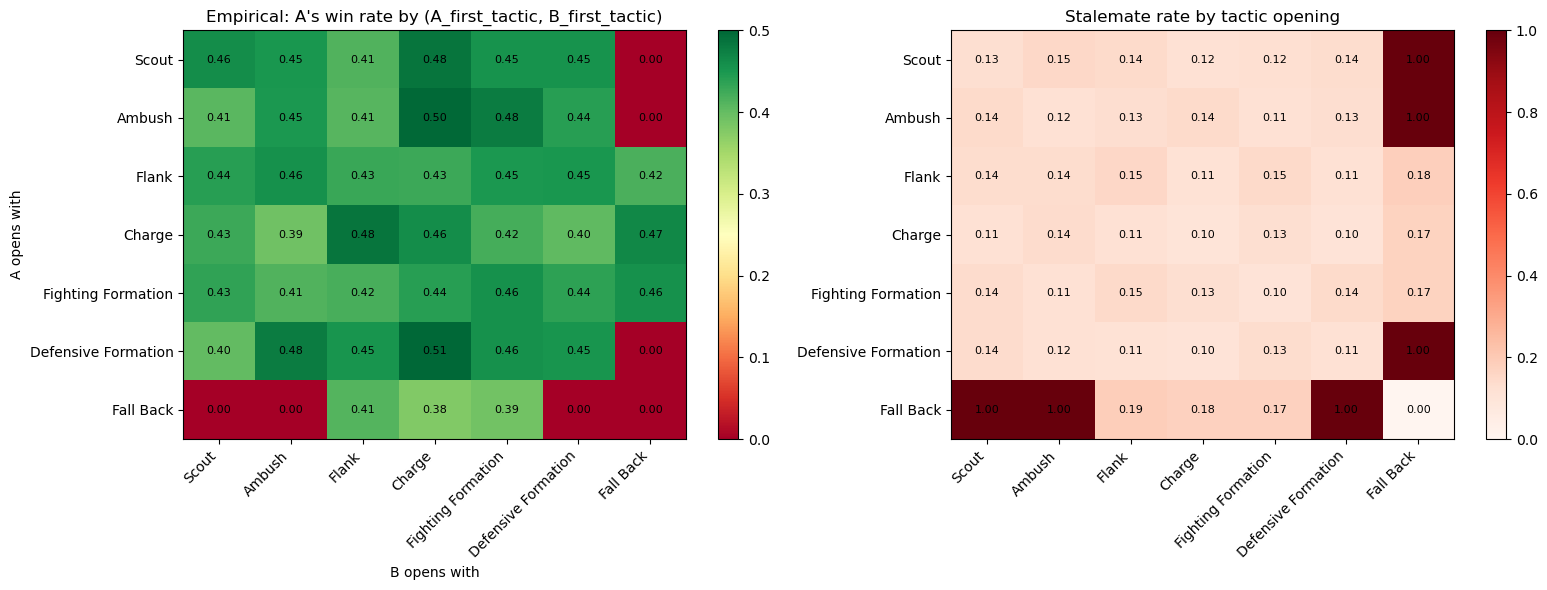

In [61]:
pivot_emp = df_tactic_matrix.pivot(index="a_tactic", columns="b_tactic", values="a_win_rate")
pivot_emp = pivot_emp.reindex(index=TACTICS, columns=TACTICS)
pivot_indec = df_tactic_matrix.pivot(index="a_tactic", columns="b_tactic", values="stalemate_rate")
pivot_indec = pivot_indec.reindex(index=TACTICS, columns=TACTICS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
im = ax.imshow(pivot_emp.values, cmap="RdYlGn", vmin=0, vmax=0.5, aspect="auto")
ax.set_xticks(range(7)); ax.set_xticklabels(TACTICS, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(TACTICS)
ax.set_title("Empirical: A's win rate by (A_first_tactic, B_first_tactic)")
ax.set_xlabel("B opens with"); ax.set_ylabel("A opens with")
plt.colorbar(im, ax=ax)
for i in range(7):
    for j in range(7):
        v = pivot_emp.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)

ax = axes[1]
im = ax.imshow(pivot_indec.values, cmap="Reds", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(7)); ax.set_xticklabels(TACTICS, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(TACTICS)
ax.set_title("Stalemate rate by tactic opening")
plt.colorbar(im, ax=ax)
for i in range(7):
    for j in range(7):
        v = pivot_indec.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 5.2 Marginal value of each tactic

Average win rate when opening with each tactic, vs uniform opponent.

In [62]:
marginal = pivot_emp.mean(axis=1).sort_values(ascending=False)
print("=== Marginal win rate when opening with each tactic ===")
for t, wr in marginal.items():
    print(f"  {t:<22} {wr:.3f}")
print()
print("Read: avg win rate when A opens with this tactic vs a random B opener.")
print("Higher = stronger default opening choice under random play.")

=== Marginal win rate when opening with each tactic ===
  Flank                  0.438
  Fighting Formation     0.437
  Charge                 0.436
  Defensive Formation    0.392
  Scout                  0.388
  Ambush                 0.383
  Fall Back              0.169

Read: avg win rate when A opens with this tactic vs a random B opener.
Higher = stronger default opening choice under random play.


## 5.3 Forced tactics matrix (stratified sample)

For comparison. Every (a, b) tactic pair is forced — pure interaction effect without play-style noise.

In [63]:
if df_forced_tactics is not None:
    pivot_forced = df_forced_tactics.pivot(index="a_tactic", columns="b_tactic", values="win_rate")
    pivot_forced = pivot_forced.reindex(index=TACTICS, columns=TACTICS)

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(pivot_forced.values, cmap="RdYlGn", vmin=0, vmax=0.5, aspect="auto")
    ax.set_xticks(range(7)); ax.set_xticklabels(TACTICS, rotation=45, ha="right")
    ax.set_yticks(range(7)); ax.set_yticklabels(TACTICS)
    ax.set_title("Forced: A's win rate when A plays row vs B plays column (every skirmish)")
    ax.set_xlabel("B forced to"); ax.set_ylabel("A forced to")
    plt.colorbar(im, ax=ax)
    for i in range(7):
        for j in range(7):
            v = pivot_forced.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout(); plt.show()

    print("\nDifference (empirical - forced):")
    print((pivot_emp - pivot_forced).round(2).to_string())
else:
    print("Forced tactics CSV not loaded — skip.")

Forced tactics CSV not loaded — skip.


## 5.4 Counter table — which tactic counters which?

For each opponent tactic, which of YOUR tactics produces the best win rate?

In [64]:
print("=== Best counter for each opponent opening ===")
print(f"{'Opponent plays':<22}  {'Best counter':<22}  {'Win rate':>9}")
for t in TACTICS:
    col = pivot_emp[t].dropna()
    best = col.idxmax(); wr = col.max()
    print(f"  {t:<20}  {best:<22}  {wr:>8.3f}")

=== Best counter for each opponent opening ===
Opponent plays          Best counter             Win rate
  Scout                 Scout                      0.459
  Ambush                Defensive Formation        0.477
  Flank                 Charge                     0.485
  Charge                Defensive Formation        0.506
  Fighting Formation    Ambush                     0.478
  Defensive Formation   Scout                      0.454
  Fall Back             Charge                     0.466


# 6. Playstyle Analysis

Compare the playstyle-aware tournament (each loadout uses its assigned best playstyle) against the main Random tournament. Question: do default playstyles actually help loadouts perform?

In [65]:
if df_ps_summary is None:
    print("Playstyle tournament not loaded — skip.")
else:
    merged = df_main_summary.merge(
        df_ps_summary[["name","win_rate","decisive_win_rate","kill_efficiency","playstyle"]],
        on="name", suffixes=("_random", "_style"))
    merged["wr_delta"] = merged["win_rate_style"] - merged["win_rate_random"]

    print("=== Playstyle vs Random — average delta in win rate ===")
    print(f"  Mean Δ win rate: {merged['wr_delta'].mean():+.4f}")
    print(f"  Median:          {merged['wr_delta'].median():+.4f}")
    print(f"  % helped:        {100*(merged['wr_delta']>0).mean():.1f}%")
    print(f"  % hurt:          {100*(merged['wr_delta']<0).mean():.1f}%")

    print("\n=== By assigned playstyle ===")
    ps_delta = merged.groupby("playstyle_style").agg(
        n=("name","count"),
        mean_delta=("wr_delta","mean"),
        median_delta=("wr_delta","median"),
        pct_helped=("wr_delta", lambda s: (s > 0).mean()),
    ).round(4)
    print(ps_delta.to_string())

Playstyle tournament not loaded — skip.


In [66]:
# Plot
if df_ps_summary is not None:
    fig, ax = plt.subplots(figsize=(11, 6))
    ps_means = merged.groupby("playstyle_style")["wr_delta"].mean().sort_values()
    colors = ["red" if v < 0 else "green" for v in ps_means.values]
    ax.barh(ps_means.index, ps_means.values, color=colors, alpha=0.7)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Δ win rate (Playstyle - Random)")
    ax.set_title("Default playstyle effect on win rate")
    plt.tight_layout(); plt.show()

## 6.1 KT-Twins Experiment — Unshakable vs Natural Playstyle (within KT)

Each KT loadout was duplicated in the playstyle tournament: one entry uses Unshakable, the other uses the equipment-natural playstyle (Defender, Cavalry, Aggressor, etc). Both have the same KT retinue → same rout-immunity stat. The win-rate delta is the **pure playstyle contribution**, isolated from the retinue effect.

In [67]:
# Extract KT-twin pairs and compare directly
if dont:
    pass
else:
    kt_orig = df_ps_summary[
        (df_ps_summary["retinue"] == "Knight Templar") &
        (df_ps_summary["playstyle"] == "Unshakable")
    ].copy()
    
    # Twins are named with " (NaturalPS)" suffix
    kt_twin = df_ps_summary[df_ps_summary["name"].str.contains(r"\(NaturalPS\)", regex=True)].copy()
    print(f"Found {len(kt_orig)} Unshakable KT loadouts and {len(kt_twin)} KT-twins\n")
    
    if len(kt_twin) == 0:
        print("No KT-twins found in summary. Did you re-run the playstyle tournament after adding twins?")
    else:
        # Build a join key from equipment (weapon, shield, armor, ranged, tiltyard, tags)
        def equip_key(row):
            return (row.get('weapon', ''), row.get('shield', ''), row.get('armor', ''),
                    row.get('ranged', ''), row.get('tiltyard', False), row.get('tags', ''))
        kt_orig['equip_key'] = kt_orig.apply(equip_key, axis=1)
        kt_twin['equip_key'] = kt_twin.apply(equip_key, axis=1)
    
        merged = kt_orig.merge(
            kt_twin[['equip_key', 'playstyle', 'win_rate', 'decisive_win_rate']],
            on='equip_key', suffixes=('_unshakable', '_natural')
        )
        merged['delta_wr'] = merged['win_rate_unshakable'] - merged['win_rate_natural']
        merged['delta_dec'] = merged['decisive_win_rate_unshakable'] - merged['decisive_win_rate_natural']
    
        print("=== Pair-level Unshakable vs Natural playstyle (within KT) ===")
        print(merged[['weapon', 'shield', 'armor', 'playstyle_natural',
                      'win_rate_unshakable', 'win_rate_natural', 'delta_wr',
                      'decisive_win_rate_unshakable', 'decisive_win_rate_natural', 'delta_dec']].round(3).to_string(index=False))
        print()
        print(f"=== Summary ===")
        print(f"Mean Δ win rate (Unshakable - Natural): {merged['delta_wr'].mean():+.3f}")
        print(f"Median:                                 {merged['delta_wr'].median():+.3f}")
        print(f"% pairs where Unshakable wins:          {100 * (merged['delta_wr'] > 0).mean():.0f}%")
        print(f"% pairs where Natural wins:             {100 * (merged['delta_wr'] < 0).mean():.0f}%")
        print()
        print(f"Mean Δ decisive win rate:               {merged['delta_dec'].mean():+.3f}")
        print()
        print("INTERPRETATION:")
        print("  Positive delta → Unshakable IS the better playstyle for KT equipment")
        print("  Negative delta → KT does better with the equipment-natural playstyle")
        print("  Near zero      → Playstyle doesn't matter for KT (rout-immunity carries either)")


In [68]:
# ──────────────────────────────────────────────────────────────────────────────
# Similar-gear comparison: same retinue, weapon-tier within ±1, MPC within ±2
# ──────────────────────────────────────────────────────────────────────────────
# Builds a per-loadout "tier index" from its weapon, then groups matchups where
# A and B are the same retinue and gear-similar. Tells you whether one player's
# investment in a specific build configuration outperforms a similarly-equipped
# peer at the same retinue.

from renown_combat import WEAPONS, ARMORS, SHIELDS
from loadouts import TIER_ORDER

TIER_IDX = {t: i for i, t in enumerate(TIER_ORDER)}  # Crude=0 ... Crafted=4

def loadout_tier_idx(weapon, armor):
    """Effective gear tier index. Uses the higher of weapon-tier and armor-tier
    so a Levy with Cloth + Bow is Crude (0), and a Sgt with Halberd + Chainmail is Wrought (2)."""
    w_t = TIER_IDX.get(WEAPONS.get(weapon, {}).get("tier"), 0) if weapon and weapon != "Farm Tools" else 0
    a_t = TIER_IDX.get(ARMORS.get(armor, {}).get("tier"), 0)
    return max(w_t, a_t)

# Build (name → tier_idx, mpc) lookup from summary
tier_lookup = {}
for _, row in df_main_summary.iterrows():
    tier_lookup[row["name"]] = (
        loadout_tier_idx(row.get("weapon"), row.get("armor")),
        row["military_pursuit_count"],
    )

# Annotate matchups with tier/MPC info for A and B
m = df_main_matchups.copy()
m["a_tier"] = m["a_name"].map(lambda n: tier_lookup.get(n, (None, None))[0])
m["b_tier"] = m["b_name"].map(lambda n: tier_lookup.get(n, (None, None))[0])
m["a_mpc"]  = m["a_name"].map(lambda n: tier_lookup.get(n, (None, None))[1])
m["b_mpc"]  = m["b_name"].map(lambda n: tier_lookup.get(n, (None, None))[1])
m = m.dropna(subset=["a_tier","b_tier","a_mpc","b_mpc"])
m["tier_diff"] = (m["a_tier"] - m["b_tier"]).astype(int)
m["mpc_diff"]  = (m["a_mpc"] - m["b_mpc"]).astype(int)
m["n_battles"] = m["a_wins"] + m["b_wins"] + m["mut_wipe"] + m["indecisive"]

# Filter: same retinue, |tier_diff| ≤ 1, |mpc_diff| ≤ 2
similar = m[
    (m["a_retinue"] == m["b_retinue"]) &
    (m["tier_diff"].abs() <= 1) &
    (m["mpc_diff"].abs() <= 2)
].copy()

print(f"Similar-gear matchups: {len(similar):,} (out of {len(m):,} total)")
print(f"Battles in scope:      {similar['n_battles'].sum():,}\n")

# ── A. Headline by retinue ──
print("=== Aggregate win rates within retinue (same retinue, ±1 tier, ±2 MPC) ===")
agg = similar.groupby("a_retinue").agg(
    matchups=("a_name", "count"),
    n_battles=("n_battles", "sum"),
    a_wins=("a_wins", "sum"),
    b_wins=("b_wins", "sum"),
    mut=("mut_wipe", "sum"),
    indec=("indecisive", "sum"),
).reset_index()
agg["a_wr"]        = agg["a_wins"] / agg["n_battles"]
agg["decisive"]    = (agg["a_wins"] + agg["b_wins"]) / agg["n_battles"]
agg["mut_pct"]     = agg["mut"] / agg["n_battles"]
agg["indec_pct"]   = agg["indec"] / agg["n_battles"]
print(agg[["a_retinue","matchups","a_wr","decisive","mut_pct","indec_pct"]].round(3).to_string(index=False))

# ── B. How does MPC advantage matter when gear is comparable? ──
print("\n=== Effect of MPC advantage at similar tier (A.mpc - B.mpc) ===")
mpc_pivot = similar.groupby(["a_retinue","mpc_diff"]).agg(
    n=("n_battles", "sum"),
    a_wins=("a_wins", "sum"),
    b_wins=("b_wins", "sum"),
).reset_index()
mpc_pivot["a_wr"] = mpc_pivot["a_wins"] / mpc_pivot["n"]
mpc_pivot = mpc_pivot.pivot(index="a_retinue", columns="mpc_diff", values="a_wr")
print(mpc_pivot.round(3).to_string())

# ── C. How does tier matter when MPC is comparable? ──
print("\n=== Effect of tier advantage at similar MPC (A.tier - B.tier) ===")
tier_pivot = similar.groupby(["a_retinue","tier_diff"]).agg(
    n=("n_battles", "sum"),
    a_wins=("a_wins", "sum"),
    b_wins=("b_wins", "sum"),
).reset_index()
tier_pivot["a_wr"] = tier_pivot["a_wins"] / tier_pivot["n"]
tier_pivot = tier_pivot.pivot(index="a_retinue", columns="tier_diff", values="a_wr")
print(tier_pivot.round(3).to_string())

# ── D. Top punch-above-weight loadouts: high win rate vs same-retinue-similar-gear ──
per_loadout = similar.groupby(["a_name","a_retinue","a_weapon","a_shield","a_armor"]).agg(
    n=("n_battles","sum"),
    a_wins=("a_wins","sum"),
    b_wins=("b_wins","sum"),
).reset_index()
per_loadout["wr"] = per_loadout["a_wins"] / per_loadout["n"]
per_loadout["decisive_wr"] = per_loadout["a_wins"] / (per_loadout["a_wins"] + per_loadout["b_wins"]).clip(lower=1)
per_loadout = per_loadout[per_loadout["n"] >= 200]  # noise filter

print("\n=== Top 15 loadouts vs their similar-gear peers (each retinue) ===")
for ret in ["Levy","Man-at-Arms","Sergeant","Knight Templar"]:
    sub = per_loadout[per_loadout["a_retinue"] == ret].nlargest(15, "wr")
    if len(sub) == 0: continue
    print(f"\n--- {ret} ---")
    print(sub[["a_name","a_weapon","a_shield","a_armor","wr","decisive_wr","n"]].round(3).to_string(index=False))

Similar-gear matchups: 639,846 (out of 9,313,192 total)
Battles in scope:      31,992,300

=== Aggregate win rates within retinue (same retinue, ±1 tier, ±2 MPC) ===
     a_retinue  matchups  a_wr  decisive  mut_pct  indec_pct
Knight Templar         0   NaN       NaN      NaN        NaN
          Levy    224782 0.326     0.645    0.320      0.035
   Man-at-Arms    225224 0.437     0.850    0.126      0.024
      Sergeant    189840 0.467     0.901    0.082      0.017

=== Effect of MPC advantage at similar tier (A.mpc - B.mpc) ===
mpc_diff           -2     -1      0      1      2
a_retinue                                        
Knight Templar    NaN    NaN    NaN    NaN    NaN
Levy            0.187  0.249  0.327  0.400  0.468
Man-at-Arms     0.265  0.344  0.434  0.528  0.616
Sergeant        0.334  0.394  0.464  0.539  0.603

=== Effect of tier advantage at similar MPC (A.tier - B.tier) ===
tier_diff          -1      0      1
a_retinue                          
Knight Templar    NaN    

In [69]:
# ──────────────────────────────────────────────────────────────────────────────
# Weapon archetype comparison: Ranged-primary / 1H+Shield / 2H melee / Lance
# ──────────────────────────────────────────────────────────────────────────────
# Categorizes every loadout into one of four archetypes and analyzes
# matchup performance across the field, head-to-head between archetypes,
# and within-archetype best performers.

from renown_combat import WEAPONS

def archetype(weapon, shield, ranged):
    """Classify a loadout's combat role."""
    if weapon == "Lance":
        return "Lance"
    if weapon is None or weapon == "Farm Tools":
        return "Ranged primary" if ranged is not None else "1H no shield"
    if "2H" in WEAPONS.get(weapon, {}).get("tags", []):
        return "2H melee"
    return "1H + shield" if shield is not None else "1H no shield"

m = df_main_matchups.copy()

# Normalize blank/NaN -> None once (vectorized), then classify each UNIQUE (weapon,shield,ranged)
# combo a single time and map it back. Avoids per-row apply (800k Python calls -> ~dozens).
def _tag_side(df, w, s, r, out):
    wn = df[w].where(df[w].notna() & (df[w] != ""), None)
    sn = df[s].where(df[s].notna() & (df[s] != ""), None)
    rn = df[r].where(df[r].notna() & (df[r] != ""), None)
    combo = pd.DataFrame({"w": wn, "s": sn, "r": rn})
    uniq = combo.drop_duplicates()
    uniq[out] = [archetype(row.w, row.s, row.r) for row in uniq.itertuples(index=False)]
    return combo.merge(uniq, on=["w", "s", "r"], how="left")[out].values

m["a_arch"] = _tag_side(m, "a_weapon", "a_shield", "a_ranged", "a_arch")
m["b_arch"] = _tag_side(m, "b_weapon", "b_shield", "b_ranged", "b_arch")
m["n_battles"] = m["a_wins"] + m["b_wins"] + m["mut_wipe"] + m["indecisive"]

# ──────────────────────────────────────────────────────────────────────────────
# A. Aggregate performance: how does each archetype fare across the whole field?
# ──────────────────────────────────────────────────────────────────────────────
print("\n=== A. Aggregate win rate by archetype (vs the entire field) ===")
agg = m.groupby("a_arch").agg(
    n_battles=("n_battles","sum"),
    a_wins=("a_wins","sum"),
    b_wins=("b_wins","sum"),
    mut=("mut_wipe","sum"),
    indec=("indecisive","sum"),
).reset_index()
agg["win_rate"]    = agg["a_wins"] / agg["n_battles"]
agg["decisive"]    = (agg["a_wins"] + agg["b_wins"]) / agg["n_battles"]
agg["mut_pct"]     = agg["mut"] / agg["n_battles"]
agg["indec_pct"]   = agg["indec"] / agg["n_battles"]
agg = agg.sort_values("win_rate", ascending=False)
print(agg[["a_arch","n_battles","win_rate","decisive","mut_pct","indec_pct"]].round(3).to_string(index=False))

# ──────────────────────────────────────────────────────────────────────────────
# B. Head-to-head matrix: archetype vs archetype
# ──────────────────────────────────────────────────────────────────────────────
print("\n=== B. Head-to-head win rate matrix (rows=A archetype, cols=B archetype) ===")
hh = m.groupby(["a_arch","b_arch"]).agg(
    n=("n_battles","sum"),
    a_wins=("a_wins","sum"),
    b_wins=("b_wins","sum"),
    mut=("mut_wipe","sum"),
).reset_index()
hh["a_wr"] = hh["a_wins"] / hh["n"]
wr_matrix = hh.pivot(index="a_arch", columns="b_arch", values="a_wr")
print(wr_matrix.round(3).to_string())

print("\n=== Mutual wipe rate matrix ===")
hh["mut_pct"] = hh["mut"] / hh["n"]
mut_matrix = hh.pivot(index="a_arch", columns="b_arch", values="mut_pct")
print(mut_matrix.round(3).to_string())

# ──────────────────────────────────────────────────────────────────────────────
# C. By retinue: how does each archetype perform when controlling for retinue?
# ──────────────────────────────────────────────────────────────────────────────
print("\n=== C. Archetype win rate by retinue ===")
ret_arch = m.groupby(["a_retinue","a_arch"]).agg(
    n=("n_battles","sum"),
    a_wins=("a_wins","sum"),
).reset_index()
ret_arch["wr"] = ret_arch["a_wins"] / ret_arch["n"]
ret_pivot = ret_arch.pivot(index="a_retinue", columns="a_arch", values="wr")
print(ret_pivot.round(3).to_string())

# ──────────────────────────────────────────────────────────────────────────────
# D. Top performer in each archetype
# ──────────────────────────────────────────────────────────────────────────────
# Group by a_name ONLY (the other 6 columns are functions of a_name — grouping on all 7
# string cols is what made this slow). Aggregate wins, then attach descriptors via first().
per_ld = m.groupby("a_name", observed=True).agg(
    a_arch=("a_arch", "first"),
    a_retinue=("a_retinue", "first"),
    a_weapon=("a_weapon", "first"),
    a_shield=("a_shield", "first"),
    a_armor=("a_armor", "first"),
    a_ranged=("a_ranged", "first"),
    n=("n_battles", "sum"),
    a_wins=("a_wins", "sum"),
    b_wins=("b_wins", "sum"),
).reset_index()
per_ld["wr"] = per_ld["a_wins"] / per_ld["n"]
per_ld["decisive_wr"] = per_ld["a_wins"] / (per_ld["a_wins"] + per_ld["b_wins"]).clip(lower=1)
per_ld = per_ld[per_ld["n"] >= 200]  # noise filter

print("\n=== D. Top 5 loadouts in each archetype ===")
for arch in ["Ranged primary","1H + shield","2H melee","Lance"]:
    sub = per_ld[per_ld["a_arch"] == arch].nlargest(5, "wr")
    if len(sub) == 0:
        print(f"\n--- {arch}: no loadouts ---")
        continue
    print(f"\n--- {arch} (top 5 by win rate) ---")
    print(sub[["a_name","a_retinue","a_weapon","a_shield","a_armor","a_ranged","wr","decisive_wr"]]
          .round(3).to_string(index=False))

# ──────────────────────────────────────────────────────────────────────────────
# E. Upkeep efficiency by archetype (wins per gold of army upkeep)
# ──────────────────────────────────────────────────────────────────────────────
print("\n=== E. Upkeep efficiency by archetype ===")
# Use df_main_summary to get per-loadout upkeep
upk = df_main_summary[["name","army_upkeep","wins_per_1000_upkeep","win_rate"]].copy()
upk["arch"] = upk.apply(lambda r: archetype(
    r.get("weapon") if pd.notna(r.get("weapon")) else None,
    r.get("shield") if pd.notna(r.get("shield")) else None,
    r.get("ranged") if pd.notna(r.get("ranged")) else None,
), axis=1) if "weapon" in upk.columns else None

# Summary doesn't have weapon directly — pull from matchups
weapon_map = df_main_matchups.groupby("a_name").agg(
    weapon=("a_weapon","first"), shield=("a_shield","first"), ranged=("a_ranged","first"),
).to_dict("index")
upk["arch"] = upk["name"].map(lambda n: archetype(
    weapon_map.get(n, {}).get("weapon") or None,
    weapon_map.get(n, {}).get("shield") or None,
    weapon_map.get(n, {}).get("ranged") or None,
) if n in weapon_map else "unknown")

eff = upk.groupby("arch").agg(
    n=("name","count"),
    avg_upkeep=("army_upkeep","mean"),
    avg_wr=("win_rate","mean"),
    avg_wins_per_1k=("wins_per_1000_upkeep","mean"),
).sort_values("avg_wins_per_1k", ascending=False)
print(eff.round(2).to_string())

C:\Users\Matt\AppData\Local\Temp\ipykernel_101716\2826484448.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniq[out] = [archetype(row.w, row.s, row.r) for row in uniq.itertuples(index=False)]
C:\Users\Matt\AppData\Local\Temp\ipykernel_101716\2826484448.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniq[out] = [archetype(row.w, row.s, row.r) for row in uniq.itertuples(index=False)]



=== A. Aggregate win rate by archetype (vs the entire field) ===
        a_arch  n_battles  win_rate  decisive  mut_pct  indec_pct
         Lance   15016300     0.505     0.851    0.119      0.031
   1H + shield  161583050     0.464     0.839    0.128      0.033
      2H melee  241066150     0.440     0.879    0.094      0.027
Ranged primary   47994100     0.322     0.857    0.113      0.031

=== B. Head-to-head win rate matrix (rows=A archetype, cols=B archetype) ===
b_arch          1H + shield  2H melee  Lance  Ranged primary
a_arch                                                      
1H + shield           0.411     0.483  0.374           0.574
2H melee              0.389     0.456  0.364           0.552
Lance                 0.466     0.516  0.426           0.600
Ranged primary        0.268     0.342  0.246           0.427

=== Mutual wipe rate matrix ===
b_arch          1H + shield  2H melee  Lance  Ranged primary
a_arch                                                      
1H + 

In [70]:
# ──────────────────────────────────────────────────────────────────────────────
# Within-tier weapon comparison (ceteris paribus)
# ──────────────────────────────────────────────────────────────────────────────
from renown_combat import WEAPONS

RANGED_TIERS = {"Hunting Bow":"Crude","Longbow":"Cast","Javelin":"Wrought","Pilum":"Wrought","Crossbow":"Forged"}

def loadout_weapon_tier(weapon, ranged):
    has_real_melee = weapon and weapon != "Farm Tools"
    if not has_real_melee and ranged:
        return RANGED_TIERS.get(ranged, "Crude")
    return WEAPONS.get(weapon, {}).get("tier", "Crude")

def loadout_weapon_label(weapon, ranged):
    has_real_melee = weapon and weapon != "Farm Tools"
    if not has_real_melee and ranged:
        return ranged
    return weapon or "Farm Tools"

m = df_main_matchups.copy()

# Vectorized tagging: classify each UNIQUE (weapon, ranged) combo once, map back.
# Avoids 4× per-row apply (1.6M Python calls -> a few dozen).
def _tag(df, w, r, tier_out, label_out):
    wn = df[w].where(df[w].notna() & (df[w] != ""), None)
    rn = df[r].where(df[r].notna() & (df[r] != ""), None)
    combo = pd.DataFrame({"w": wn, "r": rn})
    uniq = combo.drop_duplicates().copy()
    uniq[tier_out]  = [loadout_weapon_tier(x.w, x.r)  for x in uniq.itertuples(index=False)]
    uniq[label_out] = [loadout_weapon_label(x.w, x.r) for x in uniq.itertuples(index=False)]
    merged = combo.merge(uniq, on=["w","r"], how="left")
    return merged[tier_out].values, merged[label_out].values

m["a_wtier"], m["a_wlabel"] = _tag(m, "a_weapon", "a_ranged", "a_wtier", "a_wlabel")
m["b_wtier"], m["b_wlabel"] = _tag(m, "b_weapon", "b_ranged", "b_wtier", "b_wlabel")
m["n_battles"] = m["a_wins"] + m["b_wins"] + m["mut_wipe"] + m["indecisive"]
m["a_shield_filled"] = m["a_shield"].astype("object").fillna("None").replace("", "None")
m["b_shield_filled"] = m["b_shield"].astype("object").fillna("None").replace("", "None")

TIER_WEAPONS = {
    "Crude":   ["Farm Tools", "Cudgel", "Hunting Bow"],
    "Cast":    ["Daggers", "Short Sword", "Spears", "Longbow"],
    "Wrought": ["Arming Sword", "Pike", "Flail", "Halberd", "Battle Axe", "Javelin", "Pilum"],
    "Forged":  ["Bastard Sword", "Lance", "Morningstar", "War Hammer", "Crossbow"],
}

for tier, weapons_in_tier in TIER_WEAPONS.items():
    print(f"\n{'='*78}\n=== {tier.upper()} TIER WEAPON COMPARISON ===\n{'='*78}")
    print(f"Weapons in tier: {weapons_in_tier}")
    sub = m[(m["a_wtier"] == tier) & (m["b_wtier"] == tier) &
            (m["a_retinue"] == m["b_retinue"]) & (m["a_armor"] == m["b_armor"]) &
            (m["a_shield_filled"] == m["b_shield_filled"])].copy()
    if len(sub) == 0:
        print(f"  No ceteris-paribus matchups found in {tier} tier (filter too strict)."); continue
    print(f"  Same-tier, same-retinue/armor/shield matchups: {len(sub):,} ({sub['n_battles'].sum():,} battles)")

    print(f"\n  --- Each weapon's win rate vs other {tier} weapons (controlled) ---")
    by_weapon = sub.groupby("a_wlabel", observed=True).agg(
        n_matchups=("a_name","count"), n_battles=("n_battles","sum"),
        wins=("a_wins","sum"), losses=("b_wins","sum"),
        mut=("mut_wipe","sum"), indec=("indecisive","sum")).reset_index()
    by_weapon["wr"]          = by_weapon["wins"] / by_weapon["n_battles"]
    by_weapon["decisive_wr"] = by_weapon["wins"] / (by_weapon["wins"] + by_weapon["losses"]).clip(lower=1)
    by_weapon["mut_pct"]     = by_weapon["mut"] / by_weapon["n_battles"]
    by_weapon["indec_pct"]   = by_weapon["indec"] / by_weapon["n_battles"]
    by_weapon = by_weapon.sort_values("wr", ascending=False)
    print(by_weapon[["a_wlabel","n_matchups","n_battles","wr","decisive_wr","mut_pct","indec_pct"]].round(3).to_string(index=False))

    print(f"\n  --- Head-to-head matrix (rows=A weapon, cols=B weapon) ---")
    hh = sub.groupby(["a_wlabel","b_wlabel"], observed=True).agg(
        n=("n_battles","sum"), wins=("a_wins","sum")).reset_index()
    hh["wr"] = hh["wins"] / hh["n"]
    print(hh.pivot(index="a_wlabel", columns="b_wlabel", values="wr").round(3).to_string())

    print(f"\n  --- Win rate by weapon × retinue (controlled within tier) ---")
    by_ret = sub.groupby(["a_retinue","a_wlabel"], observed=True).agg(
        n=("n_battles","sum"), wins=("a_wins","sum")).reset_index()
    by_ret["wr"] = by_ret["wins"] / by_ret["n"]
    print(by_ret.pivot(index="a_retinue", columns="a_wlabel", values="wr").round(3).to_string())

print(f"\n{'='*78}\nNotes:")
print("  - Tier mapping: Hunting Bow=Crude, Longbow=Cast, Javelin/Pilum=Wrought, Crossbow=Forged, Lance=Forged.")
print("  - 'Ceteris paribus' = same retinue + armor + shield (ranged config not pinned).")
print("  - Dual-equip loadouts categorized by melee weapon.")
print("  - High mut_pct in low tiers = weapon choice didn't decide it; rout did. Higher tiers = cleaner.")


=== CRUDE TIER WEAPON COMPARISON ===
Weapons in tier: ['Farm Tools', 'Cudgel', 'Hunting Bow']
  Same-tier, same-retinue/armor/shield matchups: 66,282 (3,314,100 battles)

  --- Each weapon's win rate vs other Crude weapons (controlled) ---
   a_wlabel  n_matchups  n_battles    wr  decisive_wr  mut_pct  indec_pct
Hunting Bow        2806     140300 0.676        0.742    0.063      0.025
     Cudgel       16902     845100 0.283        0.348    0.157      0.030

  --- Head-to-head matrix (rows=A weapon, cols=B weapon) ---
b_wlabel     Cudgel  Hunting Bow
a_wlabel                        
Cudgel        0.391        0.106
Hunting Bow   0.814        0.416

  --- Win rate by weapon × retinue (controlled within tier) ---
a_wlabel     Cudgel  Hunting Bow
a_retinue                       
Levy          0.241          NaN
Man-at-Arms   0.328         0.65
Sergeant      0.280         0.70

=== CAST TIER WEAPON COMPARISON ===
Weapons in tier: ['Daggers', 'Short Sword', 'Spears', 'Longbow']
  Same-tier

In [71]:
# ──────────────────────────────────────────────────────────────────────────────
# Within-tier weapon comparison: 1H+shield vs 2H vs Ranged
# ──────────────────────────────────────────────────────────────────────────────
from renown_combat import WEAPONS

RANGED_TIER = {"Hunting Bow":"Crude","Longbow":"Cast","Javelin":"Wrought","Pilum":"Wrought","Crossbow":"Forged"}

def weapon_handedness(weapon, ranged):
    has_real_melee = weapon and weapon != "Farm Tools"
    if not has_real_melee:
        return "Ranged" if ranged else "Other"
    return "2H melee" if "2H" in WEAPONS.get(weapon, {}).get("tags", []) else "1H+shield"

def loadout_tier(weapon, ranged):
    has_real_melee = weapon and weapon != "Farm Tools"
    if not has_real_melee and ranged:
        return RANGED_TIER.get(ranged, "Crude")
    return WEAPONS.get(weapon, {}).get("tier", "Crude")

def loadout_label(weapon, ranged):
    has_real_melee = weapon and weapon != "Farm Tools"
    if not has_real_melee and ranged:
        return ranged
    return weapon or "Farm Tools"

m = df_main_matchups.copy()

# Vectorized tagging: classify each UNIQUE (weapon, ranged) combo once, map back.
# Replaces 6× per-row apply (~2.4M Python calls) with a few dozen.
def _tag(df, w, r):
    wn = df[w].where(df[w].notna() & (df[w] != ""), None)
    rn = df[r].where(df[r].notna() & (df[r] != ""), None)
    combo = pd.DataFrame({"w": wn, "r": rn})
    uniq = combo.drop_duplicates().copy()
    uniq["hand"]  = [weapon_handedness(x.w, x.r) for x in uniq.itertuples(index=False)]
    uniq["tier"]  = [loadout_tier(x.w, x.r)      for x in uniq.itertuples(index=False)]
    uniq["label"] = [loadout_label(x.w, x.r)     for x in uniq.itertuples(index=False)]
    mg = combo.merge(uniq, on=["w","r"], how="left")
    return mg["hand"].values, mg["tier"].values, mg["label"].values

m["a_hand"], m["a_wtier"], m["a_wlabel"] = _tag(m, "a_weapon", "a_ranged")
m["b_hand"], m["b_wtier"], m["b_wlabel"] = _tag(m, "b_weapon", "b_ranged")
m["n_battles"] = m["a_wins"] + m["b_wins"] + m["mut_wipe"] + m["indecisive"]

# ──────────────────────────────────────────────────────────────────────────────
# Per-tier analysis loop
# ──────────────────────────────────────────────────────────────────────────────
for tier in ["Crude", "Cast", "Wrought", "Forged"]:
    print(f"\n{'='*82}")
    print(f"=== {tier.upper()} TIER WEAPON COMPARISON (controlled: same retinue) ===")
    print(f"{'='*82}")

    valid_hands = ("1H+shield", "2H melee", "Ranged")
    sub = m[
        (m["a_wtier"] == tier) & (m["b_wtier"] == tier) &
        (m["a_retinue"] == m["b_retinue"]) &
        (m["a_hand"].isin(valid_hands)) & (m["b_hand"].isin(valid_hands))
    ].copy()
    if len(sub) == 0:
        print(f"  No matchups in {tier} tier."); continue
    print(f"  Same-tier, same-retinue matchups: {len(sub):,} ({sub['n_battles'].sum():,} battles)")

    # ── A. Aggregate win rate by handedness ──
    print(f"\n  --- A. Aggregate win rate by handedness (vs other same-tier same-retinue) ---")
    hand_agg = sub.groupby("a_hand", observed=True).agg(
        n_battles=("n_battles","sum"), wins=("a_wins","sum"), losses=("b_wins","sum"),
        mut=("mut_wipe","sum"), indec=("indecisive","sum")).reset_index()
    hand_agg["wr"]          = hand_agg["wins"] / hand_agg["n_battles"]
    hand_agg["decisive_wr"] = hand_agg["wins"] / (hand_agg["wins"] + hand_agg["losses"]).clip(lower=1)
    hand_agg["mut_pct"]     = hand_agg["mut"] / hand_agg["n_battles"]
    hand_agg["indec_pct"]   = hand_agg["indec"] / hand_agg["n_battles"]
    hand_agg = hand_agg.sort_values("wr", ascending=False)
    print(hand_agg[["a_hand","n_battles","wr","decisive_wr","mut_pct","indec_pct"]].round(3).to_string(index=False))

    # ── B. Handedness vs handedness matrix ──
    print(f"\n  --- B. Handedness head-to-head matrix (A on row) ---")
    hh = sub.groupby(["a_hand","b_hand"], observed=True).agg(
        n=("n_battles","sum"), wins=("a_wins","sum")).reset_index()
    hh["wr"] = hh["wins"] / hh["n"]
    print(hh.pivot(index="a_hand", columns="b_hand", values="wr").round(3).to_string())

    # ── C. Per-weapon win rate within tier ──
    print(f"\n  --- C. Per-weapon win rate within tier ---")
    by_weapon = sub.groupby(["a_hand","a_wlabel"], observed=True).agg(
        n_battles=("n_battles","sum"), wins=("a_wins","sum"), losses=("b_wins","sum"),
        mut=("mut_wipe","sum"), indec=("indecisive","sum")).reset_index()
    by_weapon["wr"]          = by_weapon["wins"] / by_weapon["n_battles"]
    by_weapon["decisive_wr"] = by_weapon["wins"] / (by_weapon["wins"] + by_weapon["losses"]).clip(lower=1)
    by_weapon["mut_pct"]     = by_weapon["mut"] / by_weapon["n_battles"]
    by_weapon = by_weapon.sort_values(["a_hand","wr"], ascending=[True, False])
    print(by_weapon[["a_hand","a_wlabel","n_battles","wr","decisive_wr","mut_pct"]].round(3).to_string(index=False))

    # ── D. Weapon × weapon matrix within tier ──
    print(f"\n  --- D. Full within-tier head-to-head (A's win rate; rows=A, cols=B) ---")
    weapon_grid = sub.groupby(["a_wlabel","b_wlabel"], observed=True).agg(
        n=("n_battles","sum"), wins=("a_wins","sum")).reset_index()
    weapon_grid["wr"] = weapon_grid["wins"] / weapon_grid["n"]
    print(weapon_grid.pivot(index="a_wlabel", columns="b_wlabel", values="wr").round(3).to_string())

    # ── E. Per-retinue handedness performance ──
    print(f"\n  --- E. Handedness win rate by retinue (within tier) ---")
    by_ret = sub.groupby(["a_retinue","a_hand"], observed=True).agg(
        n=("n_battles","sum"), wins=("a_wins","sum")).reset_index()
    by_ret["wr"] = by_ret["wins"] / by_ret["n"]
    print(by_ret.pivot(index="a_retinue", columns="a_hand", values="wr").round(3).to_string())

print(f"\n{'='*82}")
print("Notes:")
print("  - Tier mapping: Hunting Bow=Crude, Longbow=Cast, Javelin/Pilum=Wrought, Crossbow=Forged, Lance=Forged.")
print("  - Dual-equip loadouts categorized by melee weapon; pure-ranged as 'Ranged' by ranged-tier.")
print("  - 1H+shield includes Lance. 'Same retinue' is the only control; armor varies between matchups.")
print("  - High mut_pct in low tiers means weapon doesn't decide outcomes; fatigue does.")


=== CRUDE TIER WEAPON COMPARISON (controlled: same retinue) ===
  Same-tier, same-retinue matchups: 254,180 (12,709,000 battles)

  --- A. Aggregate win rate by handedness (vs other same-tier same-retinue) ---
   a_hand  n_battles    wr  decisive_wr  mut_pct  indec_pct
1H+shield    6774150 0.472        0.628    0.209      0.040
   Ranged    3554300 0.329        0.413    0.169      0.033
 2H melee    2380550 0.239        0.302    0.177      0.032

  --- B. Handedness head-to-head matrix (A on row) ---
b_hand     1H+shield  2H melee  Ranged
a_hand                                
1H+shield      0.355     0.680   0.615
2H melee       0.129     0.389   0.303
Ranged         0.183     0.516   0.414

  --- C. Per-weapon win rate within tier ---
  a_hand    a_wlabel  n_battles    wr  decisive_wr  mut_pct
2H melee      Cudgel    2380550 0.239        0.302    0.177
  Ranged Hunting Bow     496250 0.626        0.688    0.063

  --- D. Full within-tier head-to-head (A's win rate; rows=A, cols=B) -

In [72]:
# ──────────────────────────────────────────────────────────────────────────────
# Within-tier weapon comparison: 1H+shield vs 2H vs Ranged
# ──────────────────────────────────────────────────────────────────────────────
from renown_combat import WEAPONS

RANGED_TIER = {"Hunting Bow":"Crude","Longbow":"Cast","Javelin":"Wrought","Pilum":"Wrought","Crossbow":"Forged"}

def weapon_handedness(weapon, ranged):
    has_real_melee = weapon and weapon != "Farm Tools"
    if not has_real_melee:
        return "Ranged" if ranged else "Other"
    return "2H melee" if "2H" in WEAPONS.get(weapon, {}).get("tags", []) else "1H+shield"

def loadout_tier(weapon, ranged):
    has_real_melee = weapon and weapon != "Farm Tools"
    if not has_real_melee and ranged:
        return RANGED_TIER.get(ranged, "Crude")
    return WEAPONS.get(weapon, {}).get("tier", "Crude")

def loadout_label(weapon, ranged):
    has_real_melee = weapon and weapon != "Farm Tools"
    if not has_real_melee and ranged:
        return ranged
    return weapon or "Farm Tools"

m = df_main_matchups.copy()

# Vectorized tagging: classify each UNIQUE (weapon, ranged) combo once, map back.
# Replaces 6× per-row apply (~2.4M Python calls) with a few dozen.
def _tag(df, w, r):
    wn = df[w].where(df[w].notna() & (df[w] != ""), None)
    rn = df[r].where(df[r].notna() & (df[r] != ""), None)
    combo = pd.DataFrame({"w": wn, "r": rn})
    uniq = combo.drop_duplicates().copy()
    uniq["hand"]  = [weapon_handedness(x.w, x.r) for x in uniq.itertuples(index=False)]
    uniq["tier"]  = [loadout_tier(x.w, x.r)      for x in uniq.itertuples(index=False)]
    uniq["label"] = [loadout_label(x.w, x.r)     for x in uniq.itertuples(index=False)]
    mg = combo.merge(uniq, on=["w","r"], how="left")
    return mg["hand"].values, mg["tier"].values, mg["label"].values

m["a_hand"], m["a_wtier"], m["a_wlabel"] = _tag(m, "a_weapon", "a_ranged")
m["b_hand"], m["b_wtier"], m["b_wlabel"] = _tag(m, "b_weapon", "b_ranged")
m["n_battles"] = m["a_wins"] + m["b_wins"] + m["mut_wipe"] + m["indecisive"]

# ──────────────────────────────────────────────────────────────────────────────
# Per-tier analysis loop
# ──────────────────────────────────────────────────────────────────────────────
for tier in ["Crude", "Cast", "Wrought", "Forged"]:
    print(f"\n{'='*82}")
    print(f"=== {tier.upper()} TIER WEAPON COMPARISON (controlled: same retinue) ===")
    print(f"{'='*82}")

    valid_hands = ("1H+shield", "2H melee", "Ranged")
    sub = m[
        (m["a_wtier"] == tier) & (m["b_wtier"] == tier) &
        (m["a_retinue"] == m["b_retinue"]) &
        (m["a_hand"].isin(valid_hands)) & (m["b_hand"].isin(valid_hands))
    ].copy()
    if len(sub) == 0:
        print(f"  No matchups in {tier} tier."); continue
    print(f"  Same-tier, same-retinue matchups: {len(sub):,} ({sub['n_battles'].sum():,} battles)")

    # ── A. Aggregate win rate by handedness ──
    print(f"\n  --- A. Aggregate win rate by handedness (vs other same-tier same-retinue) ---")
    hand_agg = sub.groupby("a_hand", observed=True).agg(
        n_battles=("n_battles","sum"), wins=("a_wins","sum"), losses=("b_wins","sum"),
        mut=("mut_wipe","sum"), indec=("indecisive","sum")).reset_index()
    hand_agg["wr"]          = hand_agg["wins"] / hand_agg["n_battles"]
    hand_agg["decisive_wr"] = hand_agg["wins"] / (hand_agg["wins"] + hand_agg["losses"]).clip(lower=1)
    hand_agg["mut_pct"]     = hand_agg["mut"] / hand_agg["n_battles"]
    hand_agg["indec_pct"]   = hand_agg["indec"] / hand_agg["n_battles"]
    hand_agg = hand_agg.sort_values("wr", ascending=False)
    print(hand_agg[["a_hand","n_battles","wr","decisive_wr","mut_pct","indec_pct"]].round(3).to_string(index=False))

    # ── B. Handedness vs handedness matrix ──
    print(f"\n  --- B. Handedness head-to-head matrix (A on row) ---")
    hh = sub.groupby(["a_hand","b_hand"], observed=True).agg(
        n=("n_battles","sum"), wins=("a_wins","sum")).reset_index()
    hh["wr"] = hh["wins"] / hh["n"]
    print(hh.pivot(index="a_hand", columns="b_hand", values="wr").round(3).to_string())

    # ── C. Per-weapon win rate within tier ──
    print(f"\n  --- C. Per-weapon win rate within tier ---")
    by_weapon = sub.groupby(["a_hand","a_wlabel"], observed=True).agg(
        n_battles=("n_battles","sum"), wins=("a_wins","sum"), losses=("b_wins","sum"),
        mut=("mut_wipe","sum"), indec=("indecisive","sum")).reset_index()
    by_weapon["wr"]          = by_weapon["wins"] / by_weapon["n_battles"]
    by_weapon["decisive_wr"] = by_weapon["wins"] / (by_weapon["wins"] + by_weapon["losses"]).clip(lower=1)
    by_weapon["mut_pct"]     = by_weapon["mut"] / by_weapon["n_battles"]
    by_weapon = by_weapon.sort_values(["a_hand","wr"], ascending=[True, False])
    print(by_weapon[["a_hand","a_wlabel","n_battles","wr","decisive_wr","mut_pct"]].round(3).to_string(index=False))

    # ── D. Weapon × weapon matrix within tier ──
    print(f"\n  --- D. Full within-tier head-to-head (A's win rate; rows=A, cols=B) ---")
    weapon_grid = sub.groupby(["a_wlabel","b_wlabel"], observed=True).agg(
        n=("n_battles","sum"), wins=("a_wins","sum")).reset_index()
    weapon_grid["wr"] = weapon_grid["wins"] / weapon_grid["n"]
    print(weapon_grid.pivot(index="a_wlabel", columns="b_wlabel", values="wr").round(3).to_string())

    # ── E. Per-retinue handedness performance ──
    print(f"\n  --- E. Handedness win rate by retinue (within tier) ---")
    by_ret = sub.groupby(["a_retinue","a_hand"], observed=True).agg(
        n=("n_battles","sum"), wins=("a_wins","sum")).reset_index()
    by_ret["wr"] = by_ret["wins"] / by_ret["n"]
    print(by_ret.pivot(index="a_retinue", columns="a_hand", values="wr").round(3).to_string())

print(f"\n{'='*82}")
print("Notes:")
print("  - Tier mapping: Hunting Bow=Crude, Longbow=Cast, Javelin/Pilum=Wrought, Crossbow=Forged, Lance=Forged.")
print("  - Dual-equip loadouts categorized by melee weapon; pure-ranged as 'Ranged' by ranged-tier.")
print("  - 1H+shield includes Lance. 'Same retinue' is the only control; armor varies between matchups.")
print("  - High mut_pct in low tiers means weapon doesn't decide outcomes; fatigue does.")


=== CRUDE TIER WEAPON COMPARISON (controlled: same retinue) ===
  Same-tier, same-retinue matchups: 254,180 (12,709,000 battles)

  --- A. Aggregate win rate by handedness (vs other same-tier same-retinue) ---
   a_hand  n_battles    wr  decisive_wr  mut_pct  indec_pct
1H+shield    6774150 0.472        0.628    0.209      0.040
   Ranged    3554300 0.329        0.413    0.169      0.033
 2H melee    2380550 0.239        0.302    0.177      0.032

  --- B. Handedness head-to-head matrix (A on row) ---
b_hand     1H+shield  2H melee  Ranged
a_hand                                
1H+shield      0.355     0.680   0.615
2H melee       0.129     0.389   0.303
Ranged         0.183     0.516   0.414

  --- C. Per-weapon win rate within tier ---
  a_hand    a_wlabel  n_battles    wr  decisive_wr  mut_pct
2H melee      Cudgel    2380550 0.239        0.302    0.177
  Ranged Hunting Bow     496250 0.626        0.688    0.063

  --- D. Full within-tier head-to-head (A's win rate; rows=A, cols=B) -

# 7. Horde Mode — multi-battle survival

Loadouts fight `HORDE_BATTLES` consecutive battles with carry-over fatigue. Tests sustained performance, not single-battle peak.

In [73]:
if df_horde is None:
    print("Horde data not loaded — skip.")
else:
    print("=== Survival by retinue ===")
    print(df_horde.groupby("retinue").agg(
        n=("name","count"),
        mean_battles=("battles_survived_mean","mean"),
        median_battles=("battles_survived_median","median"),
        size_remaining=("size_remaining_mean","mean"),
    ).round(2).to_string())

    print("\n=== Survival by MPC ===")
    print(df_horde.groupby("mpc").agg(
        n=("name","count"),
        mean_battles=("battles_survived_mean","mean"),
    ).round(2).to_string())

=== Survival by retinue ===
                n  mean_battles  median_battles  size_remaining
retinue                                                        
Knight Templar  3          2.00             2.0             0.0
Levy            1          1.36             1.0             0.0
Man-at-Arms     2          1.48             1.5             0.0
Sergeant        4          1.54             1.5             0.0

=== Survival by MPC ===
     n  mean_battles
mpc                 
3    1          1.95
6    1          1.61
7    1          1.12
9    1          1.36
10   2          2.00
11   1          1.36
12   3          1.69


# 8. Loadout-Level Rollups

The detailed per-loadout views: durability, kill power, efficiency, robustness, crush rate, stalemate rate, casualty sources, cause of wipe, shaking, pursuit-presence effects, counters lookup.

## 8.1 Durability — % of battles the loadout's army survives intact

In [74]:
dur = analysis.durability(df_main_matchups)
print("=== Top 15 most durable ===")
print(dur.head(15).round(3).to_string())

=== Top 15 most durable ===
                                                                                                                                a_name  avg_survival_rate  avg_self_survivors  a_size       a_retinue       a_armor       a_weapon
368                                    KT/Morningstar/Heater/Gothic [ABFM, PrM, (SInd, EProw, SPie, NCun), Temp, Rec 5, Serr, Shake+1]              0.764           19.104000      25  Knight Templar  Gothic Plate    Morningstar
1630           MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]              0.745           18.634001      25     Man-at-Arms    Full Plate  Bastard Sword
3146                                             Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, EPie, NCun), Temp, Rec 4, Serr, Shake+1]              0.727           18.170000      25        Sergeant  Gothic Plate          Lance
1590       MaA/Arming+Longbow/Tower/FullPlate (TY) [RoPaM, PrI, 

## 8.2 Kill power — average opponents killed per battle

In [75]:
kp = analysis.kill_power(df_main_matchups)
print("=== Top 15 by kill power ===")
print(kp.head(15).round(3).to_string())

=== Top 15 by kill power ===
                                                                                                                                a_name  avg_kills  avg_kill_rate    a_retinue       a_weapon
3146                                             Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, EPie, NCun), Temp, Rec 4, Serr, Shake+1]  24.763000          0.991     Sergeant          Lance
2452  Sgt/2HBastard+HuntBow/Cloth (TY) [RoPaM, MiMiStM, (EInd, SProw, EPie, RCun), ImmU, Improved Parry, Poison, Rec 4, Serr, Shake+1]  24.714001          0.989     Sergeant      2HBastard
1643                 MaA/Bastard/Chain (DW) [RoPaM, (EInd, SProw, EPie, RCun), DW, ImmU, Improved Parry, Poison, Rec 4, Serr, Shake+1]  24.694000          0.988  Man-at-Arms  Bastard Sword
1630           MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]  24.693001          0.988  Man-at-Arms  Bastard Sword
1475              MaA/2HBa

## 8.3 Battle efficiency — wins per 1000 upkeep

In [76]:
eff = analysis.battle_efficiency(df_main_matchups)
print("=== Top 15 most efficient (wins per 1000 upkeep) ===")
print(eff.head(15).round(3).to_string())

=== Top 15 most efficient (wins per 1000 upkeep) ===
                                                                                                                                a_name  avg_kill_diff  avg_kills  avg_losses       a_retinue  a_upkeep  a_upkeep_base  kill_diff_per_1k_upkeep
368                                    KT/Morningstar/Heater/Gothic [ABFM, PrM, (SInd, EProw, SPie, NCun), Temp, Rec 5, Serr, Shake+1]      18.419001  24.315001       5.896  Knight Templar      1900           3000                    9.694
1630           MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]      18.327000  24.693001       6.366     Man-at-Arms       800           2000                   22.909
3146                                             Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, EPie, NCun), Temp, Rec 4, Serr, Shake+1]      17.933001  24.763000       6.830        Sergeant      1300           2500                 

## 8.4 Crush rate — how often this loadout achieves a decisive victory

In [77]:
cr = analysis.crush_rate(df_main_matchups)
print("=== Top 15 by crush rate ===")
print(cr.head(15).round(3).to_string())

=== Top 15 by crush rate ===
                                                                                                                       a_name  total_wins  a_size  weighted_avg_rem_in_wins  crush_score
70                   KT/Arming/Tower/FullPlate [PrM, (EInd, EProw, SPie, RCun), Improved Parry, Temp, Poison, Rec 5, Shake+1]       91871      25                    20.433        0.817
69                           KT/Arming/Tower/FullPlate [PrM, (EInd, EProw, SPie, NCun), Improved Parry, Temp, Rec 5, Shake+1]       88645      25                    20.311        0.812
368                           KT/Morningstar/Heater/Gothic [ABFM, PrM, (SInd, EProw, SPie, NCun), Temp, Rec 5, Serr, Shake+1]       94371      25                    20.182        0.807
79                                  KT/Bastard/Tower/FullPlate [PrM, (EInd, EProw, SPie, RCun), Temp, Poison, Rec 5, Shake+1]       95056      25                    20.125        0.805
55                        KT/Arming+Longbow/To

## 8.5 Stalemate rate — how often this loadout's matches go indecisive

In [78]:
sr = analysis.stalemate_rate(df_main_matchups)
print("=== Top 15 most stalemate-prone ===")
print(sr.head(15).round(3).to_string())

=== Top 15 most stalemate-prone ===
                                                                                                       a_name  indec   total       a_retinue     a_armor      a_weapon  stalemate_rate
942   Lev/FarmTools/Kite/Leather [OuInPoM, (RInd, EProw, EPie, SCun), Improved Parry, Poison, Rec 4, Shake+1]  11733  134650            Levy     Leather    Farm Tools           0.087
568             Lev/Arming/Tower/FullPlate [OuInPoM, (EInd, NProw, EPie, SCun), Temp, Poison, Rec 4, Shake+1]  11699  134650            Levy  Full Plate  Arming Sword           0.087
1381             Lev/Spears/Kite/Leather [OuInPoM, (RInd, EProw, EPie, SCun), Improved Parry, Rec 4, Shake+1]  11665  134650            Levy     Leather        Spears           0.087
786                   Lev/Crossbow/Tower/FullPlate [OuInPoM, (EInd, NProw, EPie, SCun), Temp, Rec 4, Shake+1]  11608  134650            Levy  Full Plate                         0.086
157                 KT/Cudgel/Cloth [PrM, OuInPoM

## 8.6 Robustness — consistency of performance across opponents

In [79]:
rb = analysis.robustness(df_main_matchups)
print("=== Top 15 most robust (consistent across opponents) ===")
print(rb.head(15).round(3).to_string())

=== Top 15 most robust (consistent across opponents) ===
                                                                                                                                a_name  mean_win_rate  std_win_rate  min_win_rate  max_win_rate  n_opps  robustness_score
1630           MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]          0.976         0.049          0.48           1.0    2795             0.927
2452  Sgt/2HBastard+HuntBow/Cloth (TY) [RoPaM, MiMiStM, (EInd, SProw, EPie, RCun), ImmU, Improved Parry, Poison, Rec 4, Serr, Shake+1]          0.973         0.062          0.26           1.0    2382             0.912
1588    MaA/Arming+Longbow/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, RCun), ImmU, Improved Parry, Temp, Poison, Rec 4, Shake+1]          0.971         0.061          0.36           1.0    2795             0.910
270                KT/Halberd+Javelin/Cloth (TY) [RoPaM, PrM, (RInd, SP

## 8.7 Punch above weight — performance vs more expensive opponents

In [80]:
pa = analysis.punch_above_weight(df_main_matchups)
print("=== Top 15 punch-above-weight ===")
print(pa.head(15).round(3).to_string())

=== Top 15 punch-above-weight ===
                                                                                                                                a_name  punch_wins  punch_losses  punch_indecisive  punch_battles  n_richer_opps  avg_cost_ratio  a_upkeep  punch_win_rate
990   Sgt/2HBastard+HuntBow/Cloth (TY) [RoPaM, MiMiStM, (EInd, SProw, EPie, RCun), ImmU, Improved Parry, Poison, Rec 4, Serr, Shake+1]     18480.0          85.0             134.0        18850.0          377.0           1.390    1400.0           0.980
175            MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]     71221.0         189.0             926.0        72850.0         1457.0           1.860     800.0           0.978
133     MaA/Arming+Longbow/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, RCun), ImmU, Improved Parry, Temp, Poison, Rec 4, Shake+1]     70752.0         318.0             957.0        72850.0         1457.0     

## 8.8 Counters lookup — for a specific loadout, what beats it?

Customize the loadout name to query.

In [81]:
# Top-winrate loadout by default — change `target` to any name in df_main_summary
target = df_main_summary.nlargest(1, "win_rate")["name"].iloc[0]
print(f"Loadout: {target}\n")
ctr = analysis.counters_for(df_main_matchups, target, top_n=10)
print(f"=== Top 10 counters for {target} ===")
print(ctr.round(3).to_string())

Loadout: MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]

=== Top 10 counters for MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1] ===
                                                                                                                            a_name  a_wins  b_wins  indecisive  a_win_rate  avg_skirm  avg_a_rem  avg_b_rem
7230237                                        Sgt/WarHammer/Chain [PrI, MiMiStM, (EInd, SProw, SPie, NCun), Rec 4, Serr, Shake+1]      19      23           0        0.38       5.20       2.30       2.22
8863413     Sgt/WarHammer+Crossbow/FullPlate (TY) [MiMiStI, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]      13      29           0        0.26       6.14       1.32       3.92
8819106             Sgt/Morningstar+Pilum/Heater/Gothic (TY) [ABFM, MiMiStI, (SInd, SProw, EPie, NCun), ImmU, 

## 8.9 Casualty sources & cause of wipe

What kills armies? Combat strikes, shake tests, or rout?

In [82]:
# Aggregate across all matchups
_has_waver = "avg_a_killed_waver" in df_main_matchups.columns
agg = {"avg_a_killed_combat": "mean", "avg_a_killed_shake": "mean", "avg_a_killed_rout": "mean"}
if _has_waver: agg["avg_a_killed_waver"] = "mean"
cas = df_main_matchups.agg(agg)

print("=== Average casualties per battle (A's side) ===")
total = cas.sum()
# fixed order so Waver sits next to Shake
order = ["avg_a_killed_combat", "avg_a_killed_shake", "avg_a_killed_waver", "avg_a_killed_rout"]
for src in order:
    if src in cas:
        n = cas[src]
        print(f"  {src.replace('avg_a_killed_','').capitalize():<10} {n:.1f}  ({100*n/total:.1f}%)")

# Cause of wipe
wipe_combat = df_main_matchups["a_wipe_combat"].sum()
wipe_shake  = df_main_matchups["a_wipe_shake"].sum()
wipe_waver  = df_main_matchups["a_wipe_waver"].sum() if "a_wipe_waver" in df_main_matchups.columns else 0
wipe_rout   = df_main_matchups["a_wipe_rout"].sum()
total_wipes = wipe_combat + wipe_shake + wipe_waver + wipe_rout
if total_wipes > 0:
    print("\n=== Cause of A's wipe (when wiped) ===")
    print(f"  Combat: {wipe_combat:>8}  ({100*wipe_combat/total_wipes:.1f}%)")
    print(f"  Shake:  {wipe_shake:>8}  ({100*wipe_shake/total_wipes:.1f}%)")
    print(f"  Waver:  {wipe_waver:>8}  ({100*wipe_waver/total_wipes:.1f}%)")
    print(f"  Rout:   {wipe_rout:>8}  ({100*wipe_rout/total_wipes:.1f}%)")

=== Average casualties per battle (A's side) ===
  Combat     12.4  (64.8%)
  Shake      4.5  (23.3%)
  Waver      1.4  (7.3%)
  Rout       0.9  (4.5%)

=== Cause of A's wipe (when wiped) ===
  Combat: 129440503  (52.2%)
  Shake:  48191942  (19.4%)
  Waver:  16870147  (6.8%)
  Rout:   53370924  (21.5%)


## 8.10 Shaking analysis — which loadouts cause / resist shakes?

In [83]:
# Loadouts whose attacks cause most shake casualties
print("=== Loadouts that inflict the most shake casualties (top 10) ===")
sh = df_main_matchups.groupby("a_name").agg(
    shake_dealt=("avg_b_killed_shake","sum"),
    n_matchups=("a_name","count"),
).reset_index()
sh["shake_per_matchup"] = sh["shake_dealt"] / sh["n_matchups"]
print(sh.nlargest(10, "shake_per_matchup")[["a_name","shake_per_matchup"]].round(2).to_string(index=False))

=== Loadouts that inflict the most shake casualties (top 10) ===
                                                                                                   a_name  shake_per_matchup
               KT/FarmTools/Wooden/Cloth [PrM, (RInd, EProw, SPie, NCun), Improved Parry, Rec 4, Shake+1]               8.93
                               KT/FarmTools/Wooden/Cloth [PrM, (RInd, EProw, SPie, NCun), Rec 4, Shake+1]               8.73
               KT/FarmTools/Wooden/Cloth [PrM, (RInd, EProw, SPie, NCun), Improved Parry, Rec 5, Shake+1]               8.68
        KT/FarmTools/Wooden/Cloth [RoPaI, PrM, (RInd, SProw, SPie, NCun), Improved Parry, Rec 5, Shake+1]               8.55
                         KT/Cudgel/Cloth [PrM, (NInd, EProw, SPie, NCun), Improved Parry, Rec 4, Shake+1]               8.50
      Lev/Crossbow/Tower/FullPlate [PrI, (EInd, EProw, SPie, NCun), Improved Parry, Temp, Rec 4, Shake+1]               8.43
                      Lev/Crossbow/Tower/FullPlate [PrI, (EI

## 8.11 Pursuit-presence impact

For each pursuit, how much does owning it raise win rate (controlling for MPC)?

In [84]:
controlled_rows = []
g_p = analysis._pursuit_summary_from_df(df_main_matchups)
# pursuits may be a categorical column (lean loader) — convert to object so fillna/str ops work.
g_p["pursuits"] = g_p["pursuits"].astype("object")

# First loop: collect the set of distinct pursuits.
all_pursuits = set()
for s in g_p["pursuits"].fillna(""):
    if s:
        all_pursuits.update(s.split("|"))

# Second loop: for each pursuit, compute the MPC-controlled win-rate delta.
for p in sorted(all_pursuits):
    mask = g_p["pursuits"].fillna("").str.contains(rf"(?:^|\|){p}(?:\||$)", regex=True)
    deltas = []
    weights = []
    for mpc in sorted(g_p["military_pursuit_count"].unique()):
        bucket = g_p[g_p["military_pursuit_count"] == mpc]
        with_p = bucket[mask.loc[bucket.index]]
        without_p = bucket[~mask.loc[bucket.index]]
        if len(with_p) >= 3 and len(without_p) >= 3:
            deltas.append(with_p["win_rate"].mean() - without_p["win_rate"].mean())
            weights.append(min(len(with_p), len(without_p)))
    if deltas:
        w = np.array(weights); d = np.array(deltas)
        controlled_rows.append({
            "pursuit": p, "n_buckets": len(deltas),
            "mean_delta_wr": (d * w).sum() / w.sum(),
        })

df_pursuit_effect = pd.DataFrame(controlled_rows).sort_values("mean_delta_wr", ascending=False)
print("=== Pursuit effect on win rate (MPC-controlled) ===")
print(df_pursuit_effect.round(4).to_string(index=False))

=== Pursuit effect on win rate (MPC-controlled) ===
                      pursuit  n_buckets  mean_delta_wr
                Preceptory KT          9         0.2475
              Pilgrimage Site          9         0.2475
                    Monastery          9         0.2475
                   Preceptory         12         0.1621
               Royal Pavilion         10         0.1321
                  Hospitaller         11         0.1265
                  War College         12         0.1074
                   University         10         0.1068
                        Abbey         11         0.0910
Ministry of Military Strategy         11         0.0848
             Grand Tournament         12         0.0802
                     Coliseum         11         0.0686
                     Tiltyard          9         0.0635
                   Blacksmith         12         0.0475
                    Infirmary         11         0.0348
                   Apothecary         11         0.0

## 8.12 Composite dashboard

In [85]:
print("=== Composite dashboard — top 20 by overall score ===")
dash = analysis.composite_dashboard(df_main_matchups, top_n=20)
print(dash.round(3).to_string())

=== Composite dashboard — top 20 by overall score ===
                                                                                                                                  mean_win_rate  std_win_rate  spoils_per_upkeep  a_upkeep  a_upkeep_base  avg_survival_rate  avg_kills  avg_kill_diff  kill_diff_per_1k_upkeep  stalemate_rate  punch_score
a_name                                                                                                                                                                                                                                                                                                      
MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]                   0.976         0.049              1.105       800           2000              0.745  24.693001      18.327000                   22.909           0.018       10.780
Sgt/2HBastard+HuntBow/Cloth (TY) [RoPaM, Mi

## 8.13 Cost Analysis — punch-per-upkeep and cheap effective units

The new upkeep-reducing buildings (Levy Hall, Tannery, Armory, Joinery, Master Workshop, Gilded Foundry, ABF, Fletchery, Smokehouse, Butchery) let players field substantially cheaper armies. Which loadouts maximize *effective punch per gold of upkeep*? And which cheap-upkeep units perform well enough to be the backbone of a replenishable army?

In [86]:
# Build a cost-efficiency dataframe
ce = df_main_summary.copy()
ce['army_size'] = 25  # all loadouts are 50-man

# We measure 3 cost-related metrics:
#   wins_per_1000_upkeep — already in summary
#   wins_per_gold        — same idea, finer granularity
#   replenishment_cost   — gold to replace average casualties = (25 - avg_survivors) * upkeep_per_retinue
ce['wins_per_gold'] = ce['wins'] / ce['army_upkeep'].clip(lower=1)
ce['expected_losses_per_battle'] = (ce['army_size'] - ce['avg_self_survivors']).clip(lower=0)
ce['replenishment_cost_per_battle'] = ce['expected_losses_per_battle'] * ce['upkeep_per_retinue']

# Tag value: gold-efficient with non-trivial win rate
ce['is_cheap_effective'] = (ce['army_upkeep'] <= ce['army_upkeep'].median()) & (ce['win_rate'] >= 0.40)
print(f"Cheap (≤ median upkeep {ce['army_upkeep'].median():.0f}) AND effective (≥40% wr): {ce['is_cheap_effective'].sum()} loadouts")

Cheap (≤ median upkeep 1800) AND effective (≥40% wr): 858 loadouts


In [87]:
# 1) Most efficient gold-per-win loadouts
print("=== Top 20 wins per 1000 upkeep ===")
top_eff = ce.nlargest(20, 'wins_per_1000_upkeep')[
    ['name','retinue','weapon','shield','armor','win_rate','decisive_win_rate',
     'upkeep_per_retinue','army_upkeep','wins_per_1000_upkeep']
]
print(top_eff.round(3).to_string(index=False))

=== Top 20 wins per 1000 upkeep ===
                                                                                                               name retinue      weapon        shield        armor  win_rate  decisive_win_rate  upkeep_per_retinue  army_upkeep  wins_per_1000_upkeep
                   Lev/2HBastard/FullPlate [OuInPoM, (EInd, NProw, EPie, SCun), Temp, Poison, Rec 4, Serr, Shake+1]    Levy   2HBastard           NaN   Full Plate     0.640              0.791                 200          200              431110.0
                   Lev/2HBastard/FullPlate [OuInPoM, (EInd, RProw, EPie, SCun), Temp, Poison, Rec 4, Serr, Shake+1]    Levy   2HBastard           NaN   Full Plate     0.639              0.790                 200          200              430145.0
                    Lev/Crossbow/FullPlate [OuInPoM, (EInd, NProw, EPie, SCun), Temp, Poison, Rec 4, Serr, Shake+1]    Levy         NaN           NaN   Full Plate     0.606              0.754                 200          20

In [88]:
# 2) Cheap and effective — low upkeep with respectable win rates
print("=== Top 15 'cheap and effective' (low upkeep, decent win rate) ===")
cheap = ce[ce['is_cheap_effective']].copy()
cheap = cheap.nlargest(15, 'win_rate')[
    ['name','retinue','weapon','shield','armor','win_rate','decisive_win_rate',
     'upkeep_per_retinue','army_upkeep','wins_per_1000_upkeep']
]
print(cheap.round(3).to_string(index=False))

=== Top 15 'cheap and effective' (low upkeep, decent win rate) ===
                                                                                                                          name     retinue        weapon        shield        armor  win_rate  decisive_win_rate  upkeep_per_retinue  army_upkeep  wins_per_1000_upkeep
       MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1] Man-at-Arms Bastard Sword  Tower Shield   Full Plate     0.976              0.998                1100         1100             123933.64
MaA/Arming+Longbow/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, RCun), ImmU, Improved Parry, Temp, Poison, Rec 4, Shake+1] Man-at-Arms  Arming Sword  Tower Shield   Full Plate     0.971              0.997                1000         1000             135663.00
          MaA/2HBastard+Crossbow/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1] Man-at-Arms   

In [89]:
# 3) Lowest replenishment cost — units that don't take heavy losses
print("=== Top 15 lowest replenishment cost per battle (cheap to keep alive) ===")
low_replen = ce[ce['win_rate'] >= 0.35].nsmallest(15, 'replenishment_cost_per_battle')[
    ['name','retinue','weapon','shield','armor','win_rate',
     'avg_self_survivors','upkeep_per_retinue','replenishment_cost_per_battle']
]
print(low_replen.round(2).to_string(index=False))

=== Top 15 lowest replenishment cost per battle (cheap to keep alive) ===
                                                                                                 name retinue      weapon        shield        armor  win_rate  avg_self_survivors  upkeep_per_retinue  replenishment_cost_per_battle
       Lev/Lance/Heater/Gothic [ABFM, OuInPoM, (SInd, NProw, EPie, SCun), Temp, Rec 4, Serr, Shake+1]    Levy       Lance Heater Shield Gothic Plate      0.59               11.21                 200                         2758.0
      Lev/Lance/Heater/Gothic [ABFM, OuInPoM, (SInd, NProw, EPie, SCun), Temp, Poison, Serr, Shake+1]    Levy       Lance Heater Shield Gothic Plate      0.60               10.65                 200                         2870.0
              Lev/Lance/Heater/Gothic [ABFM, OuInPoM, (SInd, NProw, EPie, SCun), Temp, Serr, Shake+1]    Levy       Lance Heater Shield Gothic Plate      0.57               10.30                 200                         2940.0
 Lev/M

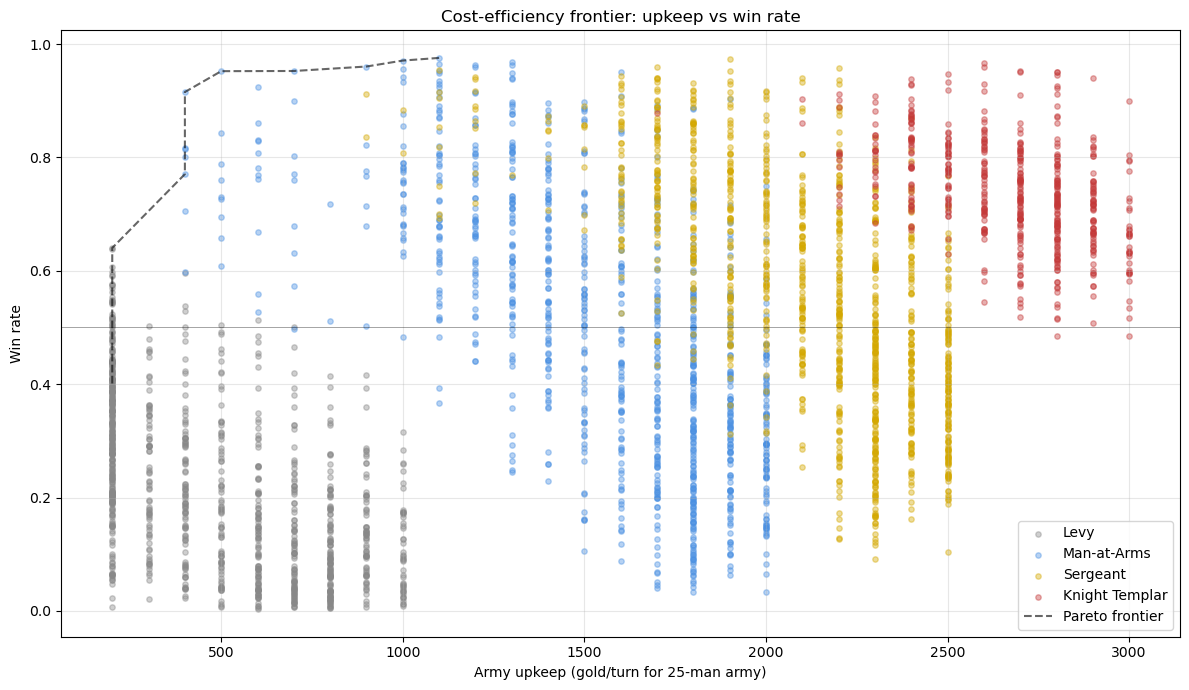


Pareto frontier has 17 loadouts. Top of frontier (highest win rate):
  upkeep=500  wr=0.952  MaA/Morningstar+HuntBow/Heater/Gothic (TY) [RoPaM, ABFM, (SInd, SProw,
  upkeep=700  wr=0.952  MaA/Poleaxe+Crossbow/Gothic (TY) [RoPaM, ABFM, (SInd, SProw, EPie, NCu
  upkeep=900  wr=0.960  MaA/Bastard+HuntBow/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, R
  upkeep=1000  wr=0.971  MaA/Arming+Longbow/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, RC
  upkeep=1100  wr=0.976  MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, N


In [90]:
# 4) Cost frontier — scatter of upkeep vs win rate, with the Pareto frontier highlighted
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

# Color by retinue
ret_colors = {'Levy':'#888','Man-at-Arms':'#4a90e2','Sergeant':'#d4a800','Knight Templar':'#c43838'}
for ret, color in ret_colors.items():
    sub = ce[ce['retinue'] == ret]
    ax.scatter(sub['army_upkeep'], sub['win_rate'], c=color, alpha=0.4, s=15, label=ret)

# Pareto frontier: for each upkeep bucket, the best win_rate
ce_sorted = ce.sort_values('army_upkeep')
frontier = []
best_wr = -1
for _, row in ce_sorted.iterrows():
    if row['win_rate'] > best_wr:
        best_wr = row['win_rate']
        frontier.append((row['army_upkeep'], row['win_rate'], row['name']))
fx = [f[0] for f in frontier]
fy = [f[1] for f in frontier]
ax.plot(fx, fy, 'k--', linewidth=1.5, alpha=0.6, label='Pareto frontier')

ax.set_xlabel('Army upkeep (gold/turn for 25-man army)')
ax.set_ylabel('Win rate')
ax.set_title('Cost-efficiency frontier: upkeep vs win rate')
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(0.5, color='black', linewidth=0.5, alpha=0.5)
plt.tight_layout(); plt.show()

print(f"\nPareto frontier has {len(frontier)} loadouts. Top of frontier (highest win rate):")
for x, y, name in frontier[-5:]:
    print(f"  upkeep={x:.0f}  wr={y:.3f}  {name[:70]}")

In [91]:
# 5) Effect of specific upkeep-reducing pursuits on cost efficiency
upkeep_pursuits = ['Levy Hall', 'Tannery', 'Armory', 'Joinery', 'Master Workshop',
                   'Gilded Foundry', 'ABF', 'Fletchery', 'Smokehouse', 'Butchery']

rows = []
for p in upkeep_pursuits:
    mask = ce['pursuits'].fillna('').str.contains(rf"(?:^|\|){p}(?:\||$)", regex=True)
    with_p = ce[mask]
    without_p = ce[~mask]
    if len(with_p) >= 5 and len(without_p) >= 5:
        rows.append({
            'pursuit': p,
            'n_with': len(with_p),
            'n_without': len(without_p),
            'avg_upkeep_with': with_p['army_upkeep'].mean(),
            'avg_upkeep_without': without_p['army_upkeep'].mean(),
            'avg_wr_with': with_p['win_rate'].mean(),
            'avg_wr_without': without_p['win_rate'].mean(),
            'avg_wins_per_1k_with': with_p['wins_per_1000_upkeep'].mean(),
            'avg_wins_per_1k_without': without_p['wins_per_1000_upkeep'].mean(),
        })
df_pursuit_cost = pd.DataFrame(rows)
df_pursuit_cost['Δ_wr'] = df_pursuit_cost['avg_wr_with'] - df_pursuit_cost['avg_wr_without']
df_pursuit_cost['Δ_efficiency'] = df_pursuit_cost['avg_wins_per_1k_with'] - df_pursuit_cost['avg_wins_per_1k_without']
print("=== Impact of upkeep-reducing pursuits ===")
print(df_pursuit_cost.round(3).to_string(index=False))
print()
print("Δ_wr near zero means: the pursuit doesn't change which loadouts win, just makes them cheaper.")
print("Δ_efficiency positive means: the pursuit makes loadouts more cost-efficient (more wins per gold).")

=== Impact of upkeep-reducing pursuits ===
        pursuit  n_with  n_without  avg_upkeep_with  avg_upkeep_without  avg_wr_with  avg_wr_without  avg_wins_per_1k_with  avg_wins_per_1k_without   Δ_wr  Δ_efficiency
      Levy Hall     313       3144          530.990            1689.822        0.202           0.492            115488.896                51267.757 -0.290     64221.139
        Tannery    1716       1741         1248.135            1916.829        0.509           0.424             85536.839                29036.552  0.084     56500.287
         Armory    1256       2201         1106.688            1857.792        0.551           0.418            105243.526                29599.266  0.133     75644.259
        Joinery     697       2760         1104.878            1706.123        0.453           0.470             96861.591                47036.712 -0.017     49824.879
Master Workshop     777       2680         1092.793            1727.575        0.523           0.450            

In [92]:
# 6) Replenishment scenarios — given a fixed reserve, how many battles can each loadout fight?
RESERVE_GOLD = 5000   # adjust to test different reserve budgets

ce['battles_per_reserve'] = RESERVE_GOLD / ce['replenishment_cost_per_battle'].clip(lower=1)
ce['effective_wins_per_reserve'] = ce['battles_per_reserve'] * ce['win_rate']

print(f"=== Given a {RESERVE_GOLD} gold reserve, expected wins before reinforcement gold runs out ===")
top_reserve = ce[ce['win_rate'] >= 0.30].nlargest(15, 'effective_wins_per_reserve')[
    ['name','retinue','weapon','win_rate','replenishment_cost_per_battle',
     'battles_per_reserve','effective_wins_per_reserve']
]
print(top_reserve.round(2).to_string(index=False))

=== Given a 5000 gold reserve, expected wins before reinforcement gold runs out ===
                                                                                                                          name     retinue        weapon  win_rate  replenishment_cost_per_battle  battles_per_reserve  effective_wins_per_reserve
     MaA/Bastard+Javelin/Heater/Gothic (TY) [RoPaM, ABFM, (SInd, SProw, NPie, RCun), ImmU, Improved Parry, Temp, Poison, Serr] Man-at-Arms Bastard Sword      0.92                         3328.0                 1.50                        1.38
MaA/Morningstar+HuntBow/Heater/Gothic (TY) [RoPaM, ABFM, (SInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Serr, Shake+1] Man-at-Arms   Morningstar      0.95                         4080.0                 1.23                        1.17
                              Lev/2HBastard/FullPlate [OuInPoM, (EInd, NProw, EPie, SCun), Temp, Poison, Rec 4, Serr, Shake+1]        Levy     2HBastard      0.64                         

# 9. Headline Findings — Design Targets

The key design target was: **win rate tightly correlates with Military Pursuit Count.** Restate and evaluate.

In [93]:
print("=" * 60)
print("DESIGN TARGET CHECK")
print("=" * 60)
print()
print(f"1. MPC ↔ Win Rate correlation:")
print(f"   Pearson r  = {pearson_r:+.3f}  (target: > +0.7 for strong correlation)")
print(f"   Spearman r = {spearman_r:+.3f}")
print()
print(f"2. Higher MPC beats lower MPC?")
print(f"   Average win rate vs lower-MPC opponents: {df_vs['vs_lower_mean'].mean():.3f}")
print(f"   Average win rate vs higher-MPC opponents: {df_vs['vs_higher_mean'].mean():.3f}")
print(f"   Difference: {df_vs['vs_lower_mean'].mean() - df_vs['vs_higher_mean'].mean():+.3f}")
print()
print(f"3. Domain Count independent effect:")
print(f"   Pearson r (raw)  = {pearson_d:+.3f}")
print(f"   Residual r (after MPC removed) = {res_pearson:+.3f}")
print()
print(f"4. Retinue win-rate spread:")
print(f"   Best retinue:  {ret_summary['win_rate'].idxmax():<15} {ret_summary['win_rate'].max():.3f}")
print(f"   Worst retinue: {ret_summary['win_rate'].idxmin():<15} {ret_summary['win_rate'].min():.3f}")
print(f"   Spread:        {ret_summary['win_rate'].max() - ret_summary['win_rate'].min():.3f}")
print()
print(f"5. Decisive vs stalemate balance:")
print(f"   Avg decisive_rate: {df_main_summary['decisive_rate'].mean():.3f}")
print(f"   (target: > 0.7 for meaningful battles)")

DESIGN TARGET CHECK

1. MPC ↔ Win Rate correlation:
   Pearson r  = +0.682  (target: > +0.7 for strong correlation)
   Spearman r = +0.681

2. Higher MPC beats lower MPC?
   Average win rate vs lower-MPC opponents: 0.689
   Average win rate vs higher-MPC opponents: 0.264
   Difference: +0.425

3. Domain Count independent effect:
   Pearson r (raw)  = +0.651
   Residual r (after MPC removed) = +0.263

4. Retinue win-rate spread:
   Best retinue:  Knight Templar  0.739
   Worst retinue: Levy            0.212
   Spread:        0.527

5. Decisive vs stalemate balance:
   Avg decisive_rate: 0.969
   (target: > 0.7 for meaningful battles)


Loadouts analyzed: 3457

=== (A) RAW SPLIT: win rate with vs without keyword ===
(raw_diff includes MPC confound — see avg_mpc columns)
       keyword  n_with  wr_with  wr_without  raw_diff  avg_mpc_with  avg_mpc_without
      One Shot     192    0.680       0.454     0.226         9.286            6.976
        Cleave     690    0.573       0.439     0.134         7.381            7.035
        Steady     825    0.557       0.438     0.119         8.712            6.600
   Unstoppable    1023    0.540       0.435     0.105         7.798            6.813
Destroy Shield     402    0.516       0.460     0.056         7.803            7.012
      Unwieldy    1895    0.478       0.452     0.026         7.188            7.002
            2H    2323    0.471       0.456     0.016         6.902            7.519

=== (B) CONTROLLED EFFECT: marginal win-rate impact (holding MPC/retinue/tier constant) ===
Model R² = 0.812  |  'significant' = 95% bootstrap CI excludes 0
       feature   coef  ci_

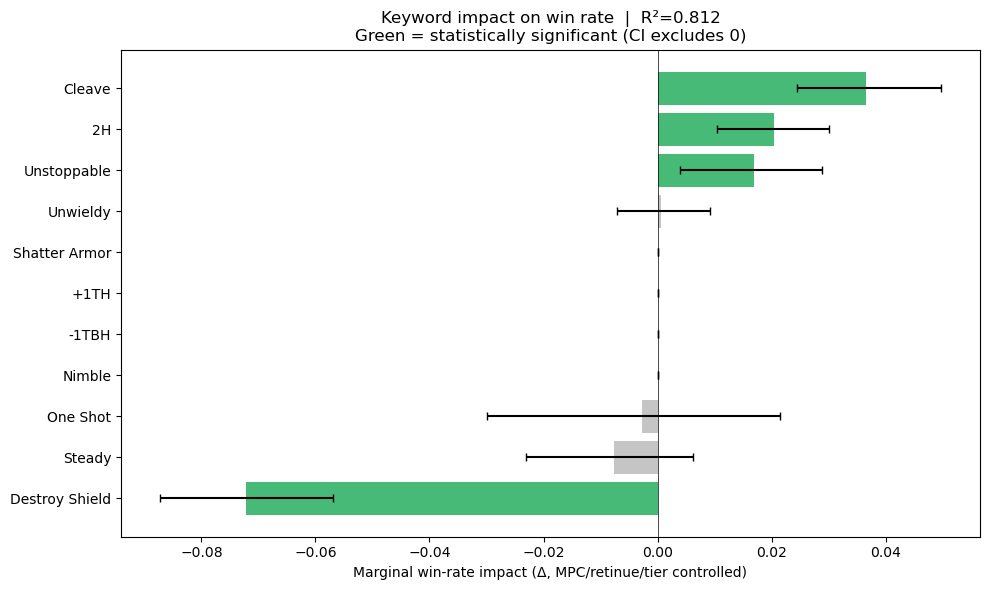


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\keyword_impact.png


In [94]:
# ──────────────────────────────────────────────────────────────────────────────
# Keyword impact on win rate
# ──────────────────────────────────────────────────────────────────────────────
# For each equipment keyword, measures:
#   (A) Raw split: mean win rate of loadouts that HAVE the keyword vs those that don't.
#   (B) MPC-controlled coefficient: the keyword's marginal effect on win rate after
#       removing MPC, retinue, and tier — so we don't credit a keyword for just
#       co-occurring with high-investment builds.
# A keyword "active" on a loadout = the keyword appears on its weapon, ranged weapon,
# or shield profile.

import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression
from renown_combat import WEAPONS, RANGED, SHIELDS, ARMORS

# All equipment keywords to test
KEYWORDS = ["Shatter Armor","Destroy Shield","Cleave","Unstoppable","Nimble",
            "Steady","Unwieldy","2H","-1TBH","One Shot","+1TH"]

# Tier helpers
RANGED_TIER = {"Hunting Bow":"Crude","Longbow":"Cast","Javelin":"Wrought","Pilum":"Wrought","Crossbow":"Forged"}
TIER_ORDER  = ["Crude","Cast","Wrought","Forged","Crafted"]
TIER_IDX    = {t:i for i,t in enumerate(TIER_ORDER)}

def loadout_keywords(weapon, ranged, shield):
    """Union of keywords from the loadout's weapon, ranged weapon, and shield."""
    kws = set()
    if pd.notna(weapon) and weapon:
        kws |= set(WEAPONS.get(weapon, {}).get("tags", []))
    if pd.notna(ranged) and ranged:
        kws |= set(RANGED.get(ranged, {}).get("tags", []))
    if pd.notna(shield) and shield:
        kws |= set(SHIELDS.get(shield, {}).get("tags", []))
    return kws

def weapon_tier(weapon, ranged):
    has_melee = pd.notna(weapon) and weapon and weapon != "Farm Tools"
    if not has_melee and pd.notna(ranged) and ranged:
        return RANGED_TIER.get(ranged, "Crude")
    return WEAPONS.get(weapon, {}).get("tier", "Crude")

# Build per-loadout attribute table from matchups (a_* side) + summary win_rate
attrs = df_main_matchups.groupby("a_name").agg(
    retinue=("a_retinue","first"), weapon=("a_weapon","first"),
    shield=("a_shield","first"), armor=("a_armor","first"),
    ranged=("a_ranged","first"), mpc=("a_military_pursuit_count","first"),
).reset_index().rename(columns={"a_name":"name"})
attrs = attrs.merge(df_main_summary[["name","win_rate"]], on="name", how="inner")

# Tag each loadout with its keyword set + tier indices
attrs["kw"]        = attrs.apply(lambda r: loadout_keywords(r["weapon"], r["ranged"], r["shield"]), axis=1)
attrs["wtier_idx"] = attrs.apply(lambda r: TIER_IDX[weapon_tier(r["weapon"], r["ranged"])], axis=1)
attrs["atier_idx"] = attrs["armor"].map(lambda a: TIER_IDX[ARMORS[a]["tier"]] if pd.notna(a) else 0)
for kw in KEYWORDS:
    attrs[f"has_{kw}"] = attrs["kw"].apply(lambda s: kw in s).astype(int)

print(f"Loadouts analyzed: {len(attrs)}\n")

# ── (A) Raw split ──
rows = []
for kw in KEYWORDS:
    has  = attrs[attrs[f"has_{kw}"]==1]
    hasnt= attrs[attrs[f"has_{kw}"]==0]
    if len(has)==0 or len(hasnt)==0:
        continue
    rows.append({
        "keyword": kw, "n_with": len(has),
        "wr_with": has["win_rate"].mean(),
        "wr_without": hasnt["win_rate"].mean(),
        "raw_diff": has["win_rate"].mean() - hasnt["win_rate"].mean(),
        "avg_mpc_with": has["mpc"].mean(),
        "avg_mpc_without": hasnt["mpc"].mean(),
    })
raw = pd.DataFrame(rows).sort_values("raw_diff", ascending=False)

# ── (B) MPC/retinue/tier-controlled coefficients ──
# Single regression: win_rate ~ all keyword dummies + mpc + retinue + weapon_tier + armor_tier.
# Each keyword coefficient = its marginal win-rate effect holding the rest constant.
X_kw   = attrs[[f"has_{kw}" for kw in KEYWORDS]].astype(float)
X_kw.columns = KEYWORDS
X_ret  = pd.get_dummies(attrs["retinue"], prefix="ret", drop_first=True).astype(float)
X_ctrl = pd.concat([attrs[["mpc","wtier_idx","atier_idx"]].astype(float), X_ret], axis=1)
X = pd.concat([X_kw, X_ctrl], axis=1)
y = attrs["win_rate"].values
reg = LinearRegression().fit(X, y)

# Bootstrap CIs for the keyword coefficients
rng = np.random.default_rng(2026); n=len(X); nboot=400
Xa = X.values; boot = np.zeros((nboot, X.shape[1]))
for b in range(nboot):
    idx = rng.integers(0,n,n)
    boot[b] = LinearRegression().fit(Xa[idx], y[idx]).coef_
coef = pd.DataFrame({"feature": X.columns, "coef": reg.coef_,
                     "ci_lo": np.percentile(boot,2.5,axis=0),
                     "ci_hi": np.percentile(boot,97.5,axis=0)})
kw_coef = coef[coef["feature"].isin(KEYWORDS)].copy()
kw_coef["significant"] = (kw_coef["ci_lo"]>0) | (kw_coef["ci_hi"]<0)
kw_coef = kw_coef.sort_values("coef", ascending=False)

# ── Print ──
print("=== (A) RAW SPLIT: win rate with vs without keyword ===")
print("(raw_diff includes MPC confound — see avg_mpc columns)")
print(raw[["keyword","n_with","wr_with","wr_without","raw_diff","avg_mpc_with","avg_mpc_without"]].round(3).to_string(index=False))

print(f"\n=== (B) CONTROLLED EFFECT: marginal win-rate impact (holding MPC/retinue/tier constant) ===")
print(f"Model R² = {reg.score(X,y):.3f}  |  'significant' = 95% bootstrap CI excludes 0")
print(kw_coef[["feature","coef","ci_lo","ci_hi","significant"]].round(3).to_string(index=False))

# ── Plot (B) ──
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))
kc = kw_coef.sort_values("coef")
colors = ["#27ae60" if s else "#bbbbbb" for s in kc["significant"]]
yp = np.arange(len(kc))
ax.barh(yp, kc["coef"], xerr=[kc["coef"]-kc["ci_lo"], kc["ci_hi"]-kc["coef"]],
        color=colors, alpha=0.85, capsize=3, ecolor="black")
ax.set_yticks(yp); ax.set_yticklabels(kc["feature"])
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Marginal win-rate impact (Δ, MPC/retinue/tier controlled)")
ax.set_title(f"Keyword impact on win rate  |  R²={reg.score(X,y):.3f}\nGreen = statistically significant (CI excludes 0)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "keyword_impact.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'keyword_impact.png')}")

Reference field: 48 opponents

  Poison               Δ=+0.032  (n=12, range [+0.004, +0.069])
  Immune Unwieldy      Δ=+0.011  (n=12, range [+0.000, +0.052])
  Drilled              Δ=+0.179  (n=12, range [+0.114, +0.318])
  Parry                Δ=+0.025  (n=12, range [+0.000, +0.081])
  Seize: first         Δ=+0.007  (n=12, range [-0.003, +0.018])
  Outrider: every      Δ=+0.075  (n=12, range [+0.022, +0.209])

=== Keyword isolated win-rate impact (toggle on vs off, same loadout, vs fixed field) ===
        keyword  n_carriers  n_tested  mean_delta  median_delta  min_delta  max_delta
        Drilled        4265        12       0.179         0.157      0.114      0.318
Outrider: every        7623        12       0.075         0.074      0.022      0.209
         Poison       16179        12       0.032         0.035      0.004      0.069
          Parry       33258        12       0.025         0.000      0.000      0.081
Immune Unwieldy       22903        12       0.011         0.009 

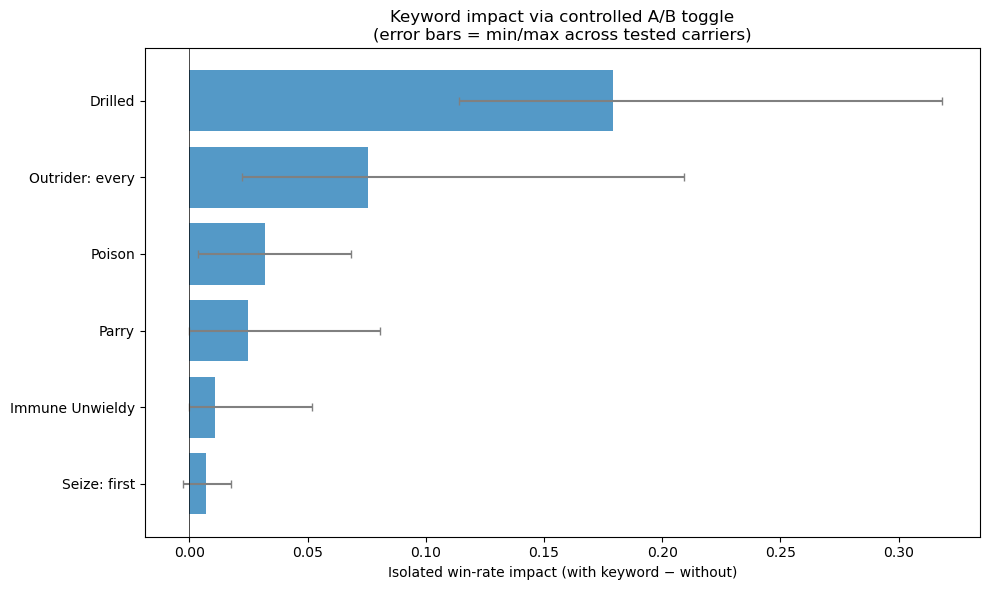


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\keyword_ab_impact.png


In [95]:
# ──────────────────────────────────────────────────────────────────────────────
# Keyword impact via controlled A/B matchups (toggle on/off, same loadout)
# ──────────────────────────────────────────────────────────────────────────────
# For each keyword, find loadouts that legitimately carry it, clone each with the
# keyword REMOVED, and run both versions against a fixed reference field. The
# win-rate delta (with − without) is the keyword's isolated effect — no regression,
# no collinearity. Works for both equipment tags and pursuit/MPC extra_tags.
#
# Requires: loadouts, renown_combat, vectorized_combat, playstyles already imported
# in the lab (Section 0). Uses the live pool, not the CSV.

import importlib, numpy as np, pandas as pd
import loadouts, renown_combat, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(vectorized_combat)
vectorized_combat.invalidate_tactic_tables()
from renown_combat import WEAPONS, RANGED, SHIELDS

pool = MAIN_POOL   # reuse the main tournament pool (no regeneration)

# Keywords that live in extra_tags (pursuit/MPC-granted) — these we can toggle directly.
EXTRA_TAG_KEYWORDS = [
    "Poison", "Apothecary Heal",
    "Regenerate", "Regenerate 5", "Regenerate 4", "Regenerate Reroll",
    "Immune Unwieldy",                          # only grantable immunity (Tiltyard mastery)
    "GF Armor", "MW Weapons", "Rend", "Steadfast", "Drilled", "Nimble", "Cond Field", "Parry",
    "Seize: first", "Seize: first_two", "Seize: every",
    "Outrider: once", "Outrider: first", "Outrider: first_two", "Outrider: every",
    "Riposte"
]

# Build a fixed reference field: a stratified spread of opponents across retinue/tier.
# We hold this constant so every A/B comparison faces the same gauntlet.
rng = np.random.default_rng(2026)
import random; random.seed(2026)
from collections import defaultdict
buckets = defaultdict(list)
for ld in pool:
    buckets[(ld.retinue, ld.military_pursuit_count)].append(ld)
ref_field = []
for key, lds in buckets.items():
    ref_field.extend(random.sample(lds, min(len(lds), 1)))
if len(ref_field) > 60:
    ref_field = random.sample(ref_field, 60)
ref_field = [r._replace(playstyle=playstyles.assign_default_playstyle(r)) for r in ref_field]
print(f"Reference field: {len(ref_field)} opponents\n")

def field_winrate(ld, field, n_runs=120):
    """Average win rate of `ld` across the whole reference field."""
    ld = ld._replace(playstyle=playstyles.assign_default_playstyle(ld))
    wins = total = 0
    for i, opp in enumerate(field):
        if opp.name == ld.name:
            continue
        r = vectorized_combat.run_matchup_vec(ld, opp, n_runs=n_runs, seed=4242+i, max_skirmishes=20)
        wins += r['a_wins']; total += (r['a_wins']+r['b_wins']+r['mut_wipe']+r['indecisive'])
    return wins/total if total else float('nan')

rows = []
for kw in EXTRA_TAG_KEYWORDS:
    carriers = [ld for ld in pool if kw in ld.extra_tags]
    if not carriers:
        continue
    # Sample up to N carriers spanning retinues for a representative delta
    sample = random.sample(carriers, min(len(carriers), 12))
    deltas = []
    for ld in sample:
        with_kw    = ld
        without_kw = ld._replace(extra_tags=[t for t in ld.extra_tags if t != kw])
        wr_with    = field_winrate(with_kw,    ref_field)
        wr_without = field_winrate(without_kw, ref_field)
        deltas.append(wr_with - wr_without)
    deltas = np.array(deltas)
    rows.append({
        "keyword": kw, "n_carriers": len(carriers), "n_tested": len(sample),
        "mean_delta": deltas.mean(), "median_delta": np.median(deltas),
        "min_delta": deltas.min(), "max_delta": deltas.max(),
        "std": deltas.std(),
    })
    print(f"  {kw:<20} Δ={deltas.mean():+.3f}  (n={len(sample)}, range [{deltas.min():+.3f}, {deltas.max():+.3f}])")

res = pd.DataFrame(rows).sort_values("mean_delta", ascending=False)
print("\n=== Keyword isolated win-rate impact (toggle on vs off, same loadout, vs fixed field) ===")
print(res[["keyword","n_carriers","n_tested","mean_delta","median_delta","min_delta","max_delta"]].round(3).to_string(index=False))

# Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
rs = res.sort_values("mean_delta")
ax.barh(range(len(rs)), rs["mean_delta"],
        xerr=[rs["mean_delta"]-rs["min_delta"], rs["max_delta"]-rs["mean_delta"]],
        color="#2980b9", alpha=0.8, capsize=3, ecolor="gray")
ax.set_yticks(range(len(rs))); ax.set_yticklabels(rs["keyword"])
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Isolated win-rate impact (with keyword − without)")
ax.set_title("Keyword impact via controlled A/B toggle\n(error bars = min/max across tested carriers)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "keyword_ab_impact.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'keyword_ab_impact.png')}")

=== A. Role aggregate (whole-field win rate by ranged role) ===
     a_role  n_battles  win_rate  decisive_wr  mut_pct  indec_pct
 dual-equip  417665500     0.451        0.523    0.108      0.029
pure-ranged   47994100     0.322        0.376    0.113      0.031

=== B. Per-ranged-weapon win rate (loadouts carrying each ranged weapon) ===
   a_ranged  n_loadouts  n_battles  win_rate  decisive_wr  mut_pct
      Pilum           6     879450     0.808        0.919    0.095
    Javelin         186   24088300     0.661        0.739    0.080
   Crossbow         294   39988700     0.530        0.618    0.111
    Longbow         428   55893950     0.528        0.605    0.098
Hunting Bow         548   71497450     0.484        0.558    0.102

=== C. Ranged carrier win rate vs defender armor tier ===
             Crude/Cloth  Cast/Leather  Wrought/Chain  Forged/Full  Crafted/Gothic
a_ranged                                                                          
Crossbow           0.569         

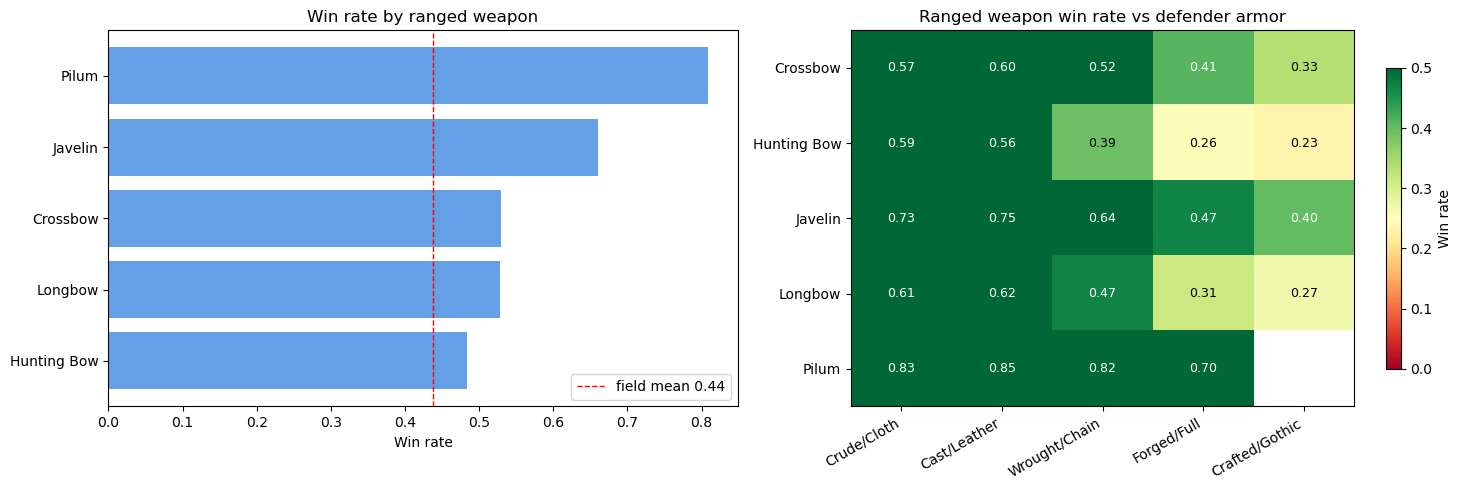


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\ranged_analysis.png


In [96]:
# ──────────────────────────────────────────────────────────────────────────────
# Ranged weapons performance analysis
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from renown_combat import WEAPONS, RANGED, ARMORS

def ranged_role(weapon, ranged):
    has_melee  = weapon is not None and weapon != "" and weapon != "Farm Tools"
    has_ranged = ranged is not None and ranged != ""
    if has_ranged and not has_melee: return "pure-ranged"
    if has_ranged and has_melee:     return "dual-equip"
    return "melee-only"

m = df_main_matchups.copy()

# Vectorized role tagging: classify each UNIQUE (weapon, ranged) combo once, map back.
def _role_col(df, w, r):
    wn = df[w].where(df[w].notna() & (df[w] != ""), None)
    rn = df[r].where(df[r].notna() & (df[r] != ""), None)
    combo = pd.DataFrame({"w": wn, "r": rn})
    uniq = combo.drop_duplicates().copy()
    uniq["role"] = [ranged_role(x.w, x.r) for x in uniq.itertuples(index=False)]
    return combo.merge(uniq, on=["w","r"], how="left")["role"].values

m["a_role"] = _role_col(m, "a_weapon", "a_ranged")
m["b_role"] = _role_col(m, "b_weapon", "b_ranged")
m["n"]      = m["a_wins"] + m["b_wins"] + m["mut_wipe"] + m["indecisive"]

# Armor tier via unique-value map (a_armor is categorical now — .astype(object) first).
TIER_IDX = {"Crude":0,"Cast":1,"Wrought":2,"Forged":3,"Crafted":4}
def _atier(col):
    s = m[col].astype("object")
    return s.map(lambda a: TIER_IDX.get(ARMORS.get(a, {}).get("tier", "Crude"), 0) if pd.notna(a) else 0)
m["a_atier"] = _atier("a_armor")
m["b_atier"] = _atier("b_armor")

# ── A. Role aggregate ──
print("=== A. Role aggregate (whole-field win rate by ranged role) ===")
agg = m.groupby("a_role", observed=True).agg(
    n_battles=("n","sum"), wins=("a_wins","sum"), losses=("b_wins","sum"),
    mut=("mut_wipe","sum"), indec=("indecisive","sum")).reset_index()
agg["win_rate"]    = agg["wins"]/agg["n_battles"]
agg["decisive_wr"] = agg["wins"]/(agg["wins"]+agg["losses"]).clip(lower=1)
agg["mut_pct"]     = agg["mut"]/agg["n_battles"]
agg["indec_pct"]   = agg["indec"]/agg["n_battles"]
print(agg.sort_values("win_rate", ascending=False)[["a_role","n_battles","win_rate","decisive_wr","mut_pct","indec_pct"]].round(3).to_string(index=False))

# ── B. Per-ranged-weapon performance ──
print("\n=== B. Per-ranged-weapon win rate (loadouts carrying each ranged weapon) ===")
ranged_only = m[m["a_ranged"].notna() & (m["a_ranged"] != "")].copy()
per_rw = ranged_only.groupby("a_ranged", observed=True).agg(
    n_loadouts=("a_name","nunique"), n_battles=("n","sum"),
    wins=("a_wins","sum"), losses=("b_wins","sum"),
    mut=("mut_wipe","sum"), indec=("indecisive","sum")).reset_index()
per_rw["win_rate"]    = per_rw["wins"]/per_rw["n_battles"]
per_rw["decisive_wr"] = per_rw["wins"]/(per_rw["wins"]+per_rw["losses"]).clip(lower=1)
per_rw["mut_pct"]     = per_rw["mut"]/per_rw["n_battles"]
per_rw = per_rw[per_rw["n_battles"] > 0]
print(per_rw.sort_values("win_rate", ascending=False)[
    ["a_ranged","n_loadouts","n_battles","win_rate","decisive_wr","mut_pct"]].round(3).to_string(index=False))

# ── C. Ranged vs defender armor tier ──
print("\n=== C. Ranged carrier win rate vs defender armor tier ===")
TIER_NAME = {0:"Crude/Cloth", 1:"Cast/Leather", 2:"Wrought/Chain", 3:"Forged/Full", 4:"Crafted/Gothic"}
vs_armor = ranged_only.groupby(["a_ranged","b_atier"], observed=True).agg(
    n=("n","sum"), wins=("a_wins","sum")).reset_index()
vs_armor["wr"] = vs_armor["wins"]/vs_armor["n"]
vs_armor_pivot = vs_armor.pivot(index="a_ranged", columns="b_atier", values="wr").dropna(how="all")
vs_armor_pivot.columns = [TIER_NAME.get(c, c) for c in vs_armor_pivot.columns]
print(vs_armor_pivot.round(3).to_string())

# ── D. By retinue × role ──
print("\n=== D. Ranged role win rate by retinue ===")
ret_role = m.groupby(["a_retinue","a_role"], observed=True).agg(
    n=("n","sum"), wins=("a_wins","sum")).reset_index()
ret_role["wr"] = ret_role["wins"]/ret_role["n"]
print(ret_role.pivot(index="a_retinue", columns="a_role", values="wr").round(3).to_string())

# ── E. Tiltyard dual-equip ROI ──
print("\n=== E. Tiltyard dual-equip ROI: dual-equip vs melee-only at same MPC ===")
role_mpc = m.groupby(["a_role","a_military_pursuit_count"], observed=True).agg(
    n=("n","sum"), wins=("a_wins","sum")).reset_index()
role_mpc["wr"] = role_mpc["wins"]/role_mpc["n"]
roi_pivot = role_mpc.pivot(index="a_military_pursuit_count", columns="a_role", values="wr")
roi_pivot["dual_minus_melee"] = roi_pivot.get("dual-equip", 0) - roi_pivot.get("melee-only", 0)
print(roi_pivot.round(3).to_string())

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
field_mean = m["a_wins"].sum()/m["n"].sum()
sub = per_rw.sort_values("win_rate")
axes[0].barh(range(len(sub)), sub["win_rate"], color="#4a90e2", alpha=0.85)
axes[0].set_yticks(range(len(sub))); axes[0].set_yticklabels(sub["a_ranged"])
axes[0].axvline(field_mean, color="red", ls="--", lw=1, label=f"field mean {field_mean:.2f}")
axes[0].set_xlabel("Win rate"); axes[0].set_title("Win rate by ranged weapon"); axes[0].legend()

hm = vs_armor_pivot.values
im = axes[1].imshow(hm, cmap="RdYlGn", vmin=0, vmax=0.5, aspect="auto")
axes[1].set_xticks(range(hm.shape[1])); axes[1].set_xticklabels(vs_armor_pivot.columns, rotation=30, ha="right")
axes[1].set_yticks(range(hm.shape[0])); axes[1].set_yticklabels(vs_armor_pivot.index)
axes[1].set_title("Ranged weapon win rate vs defender armor")
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        if not np.isnan(hm[i,j]):
            axes[1].text(j, i, f"{hm[i,j]:.2f}", ha="center", va="center", fontsize=9,
                         color="white" if (hm[i,j]<0.2 or hm[i,j]>0.4) else "black")
plt.colorbar(im, ax=axes[1], label="Win rate", shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ranged_analysis.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'ranged_analysis.png')}")

60 loadouts, 1500 matchups × 100 runs, logging first 3 skirmishes...

=== Per-skirmish casualties (per side, first 3 skirmishes) ===
 skirmish  n_obs  mean_cas  median_cas  pct_over_5  pct_over_10  p90  max
        1 300000      3.88         3.0       24.36         3.43  9.0   15
        2 298088      3.33         3.0       18.83         2.51  8.0   15
        3 295306      4.30         4.0       27.91         4.39  8.0   19

=== First-striker vs second-striker casualties taken ===
 skirmish  mean_if_first  mean_if_second  pct>5_first  pct>5_second
        1           3.56            4.08        21.45         26.23
        2           2.80            3.68        14.35         21.77
        3           3.85            4.61        21.65         32.05

=== Casualties by CAUSE per skirmish (mean per side) ===
 skirmish  combat_mean  shake_mean  waver_mean  pct_any_shake  pct_any_waver
        1         3.40        0.00        0.48           0.00          18.92
        2         2.96       

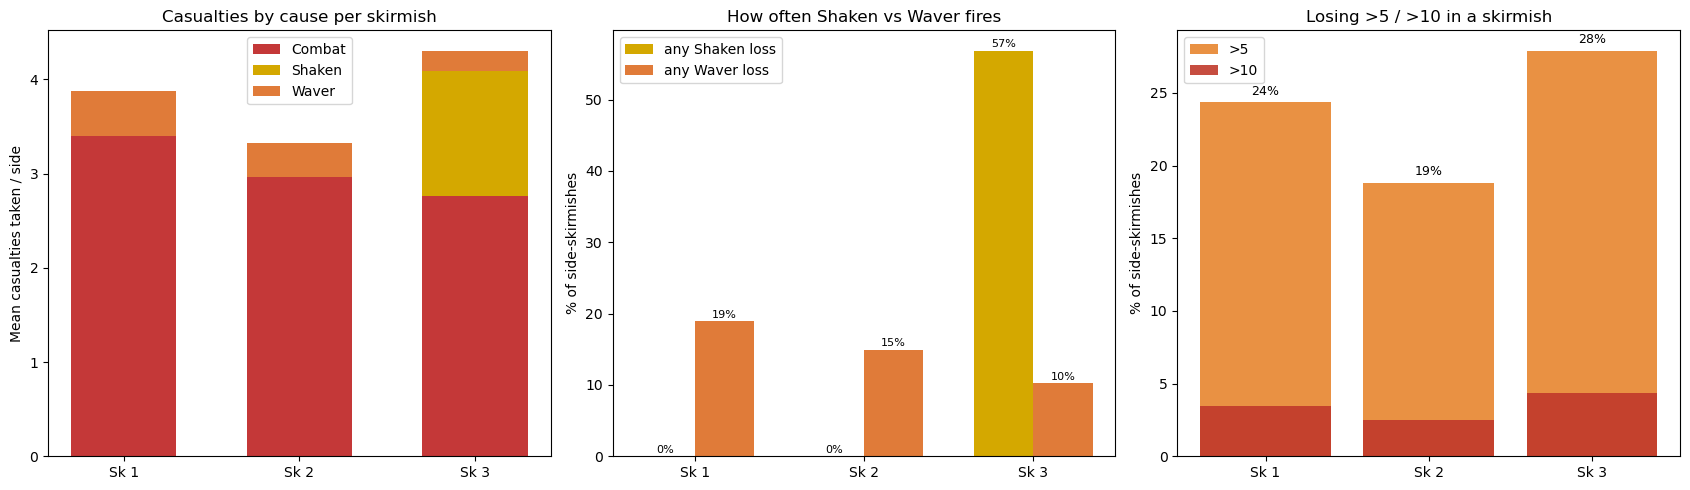


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\per_skirmish_casualties.png


In [97]:
# ──────────────────────────────────────────────────────────────────────────────
# Per-skirmish casualty analysis — first 3 skirmishes (with shake & waver split)
# ──────────────────────────────────────────────────────────────────────────────
# Total casualties + first/second-striker split (as before), PLUS per-cause breakdown:
# combat vs shake (exhaustion) vs waver (>5 heavy-loss morale break), per skirmish.
# REQUIRES vectorized_combat.py with per-cause skirmish_log (a_combat/a_shake/a_waver).
import numpy as np, pandas as pd, random
import importlib, loadouts, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(vectorized_combat)
vectorized_combat.invalidate_tactic_tables()
pool = MAIN_POOL
random.seed(2026)
from collections import defaultdict
by_ret = defaultdict(list)
for ld in pool: by_ret[ld.retinue].append(ld)
sample = []
for ret, lds in by_ret.items():
    sample.extend(random.sample(lds, min(len(lds), 15)))
sample = [ld._replace(playstyle=playstyles.assign_default_playstyle(ld)) for ld in sample]
pairs = [(i,j) for i in range(len(sample)) for j in range(len(sample)) if i!=j]
random.shuffle(pairs); pairs = pairs[:1500]
N_RUNS = 100
print(f"{len(sample)} loadouts, {len(pairs)} matchups × {N_RUNS} runs, logging first 3 skirmishes...\n")

# total-casualty records (back-compat) + per-cause records
records = {1: {"cas": [], "first": []}, 2: {"cas": [], "first": []}, 3: {"cas": [], "first": []}}
cause   = {sk: {"combat": [], "shake": [], "waver": []} for sk in (1,2,3)}
for (i,j) in pairs:
    a, b = sample[i], sample[j]
    r = vectorized_combat.run_matchup_vec(a, b, n_runs=N_RUNS, max_skirmishes=20,
                                          seed=1000+i*97+j, log_skirmishes=3)
    for e in r["skirmish_log"]:
        sk = e["skirmish"]; act = e["active"]
        a_first = (e["first_striker"][act] == 1); b_first = (e["first_striker"][act] == -1)
        records[sk]["cas"].append(e["a_casualties"][act]); records[sk]["first"].append(a_first)
        records[sk]["cas"].append(e["b_casualties"][act]); records[sk]["first"].append(b_first)
        for side in ("a","b"):
            cause[sk]["combat"].append(e[f"{side}_combat"][act])
            cause[sk]["shake"].append(e[f"{side}_shake"][act])
            cause[sk]["waver"].append(e[f"{side}_waver"][act])

rows = []
for sk in (1,2,3):
    cas   = np.concatenate(records[sk]["cas"]); first = np.concatenate(records[sk]["first"])
    cas_f = cas[first]; cas_s = cas[~first]
    rows.append({
        "skirmish": sk, "n_obs": len(cas),
        "mean_cas": cas.mean(), "median_cas": np.median(cas),
        "pct_over_5": 100*(cas>5).mean(), "pct_over_10": 100*(cas>10).mean(),
        "p90": np.percentile(cas,90), "max": cas.max(),
        "mean_if_first": cas_f.mean() if len(cas_f) else np.nan,
        "mean_if_second": cas_s.mean() if len(cas_s) else np.nan,
        "pct>5_first": 100*(cas_f>5).mean() if len(cas_f) else np.nan,
        "pct>5_second": 100*(cas_s>5).mean() if len(cas_s) else np.nan,
    })
res = pd.DataFrame(rows)

# per-cause summary
cz = []
for sk in (1,2,3):
    c = np.concatenate(cause[sk]["combat"]); s = np.concatenate(cause[sk]["shake"]); w = np.concatenate(cause[sk]["waver"])
    cz.append({"skirmish": sk,
               "combat_mean": c.mean(), "shake_mean": s.mean(), "waver_mean": w.mean(),
               "pct_any_shake": 100*(s>0).mean(), "pct_any_waver": 100*(w>0).mean()})
czdf = pd.DataFrame(cz)

print("=== Per-skirmish casualties (per side, first 3 skirmishes) ===")
print(res[["skirmish","n_obs","mean_cas","median_cas","pct_over_5","pct_over_10","p90","max"]].round(2).to_string(index=False))
print("\n=== First-striker vs second-striker casualties taken ===")
print(res[["skirmish","mean_if_first","mean_if_second","pct>5_first","pct>5_second"]].round(2).to_string(index=False))
print("\n=== Casualties by CAUSE per skirmish (mean per side) ===")
print(czdf.round(2).to_string(index=False))

print("\n=== Casualty-count distribution per skirmish (% of side-observations) ===")
dist_rows = []
for sk in (1,2,3):
    cas = np.concatenate(records[sk]["cas"])
    dist_rows.append({"skirmish": sk,
        "0":   round(100*(cas==0).mean(),1), "1-2": round(100*((cas>=1)&(cas<=2)).mean(),1),
        "3-5": round(100*((cas>=3)&(cas<=5)).mean(),1), "6-10":round(100*((cas>=6)&(cas<=10)).mean(),1),
        ">10": round(100*(cas>10).mean(),1)})
print(pd.DataFrame(dist_rows).to_string(index=False))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(17,5))

# panel 1: stacked mean casualties by cause (combat / shake / waver)
x = np.arange(3)
ax = axes[0]
ax.bar(x, czdf["combat_mean"], 0.6, label="Combat", color="#c43838")
ax.bar(x, czdf["shake_mean"], 0.6, bottom=czdf["combat_mean"], label="Shaken", color="#d4a800")
ax.bar(x, czdf["waver_mean"], 0.6, bottom=czdf["combat_mean"]+czdf["shake_mean"], label="Waver", color="#e07b39")
ax.set_xticks(x); ax.set_xticklabels([f"Sk {s}" for s in (1,2,3)])
ax.set_ylabel("Mean casualties taken / side"); ax.set_title("Casualties by cause per skirmish"); ax.legend()

# panel 2: how often shake vs waver fires per skirmish
ax = axes[1]; w = 0.35
ax.bar(x-w/2, czdf["pct_any_shake"], w, label="any Shaken loss", color="#d4a800")
ax.bar(x+w/2, czdf["pct_any_waver"], w, label="any Waver loss", color="#e07b39")
ax.set_xticks(x); ax.set_xticklabels([f"Sk {s}" for s in (1,2,3)])
ax.set_ylabel("% of side-skirmishes"); ax.set_title("How often Shaken vs Waver fires"); ax.legend()
for idx in range(3):
    ax.text(idx-w/2, czdf["pct_any_shake"][idx]+0.5, f"{czdf['pct_any_shake'][idx]:.0f}%", ha="center", fontsize=8)
    ax.text(idx+w/2, czdf["pct_any_waver"][idx]+0.5, f"{czdf['pct_any_waver'][idx]:.0f}%", ha="center", fontsize=8)

# panel 3: losing >5 / >10 (total), as before
ax = axes[2]
ax.bar([f"Sk {r['skirmish']}" for r in rows], [r["pct_over_5"] for r in rows], color="#e67e22", alpha=.85, label=">5")
ax.bar([f"Sk {r['skirmish']}" for r in rows], [r["pct_over_10"] for r in rows], color="#c0392b", alpha=.9, label=">10")
ax.set_ylabel("% of side-skirmishes"); ax.set_title("Losing >5 / >10 in a skirmish"); ax.legend()
for idx,r in enumerate(rows):
    ax.text(idx, r["pct_over_5"]+0.5, f"{r['pct_over_5']:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "per_skirmish_casualties.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'per_skirmish_casualties.png')}")

In [98]:
# ──────────────────────────────────────────────────────────────────────────────
# Rend value — controlled A/B comparison
# ──────────────────────────────────────────────────────────────────────────────
# NOTE: the -1 AP "MW Weapons" mechanic is retired. Master Workshop MASTERY now grants Rend
# directly (and ABF grants it too). So this tests Rend vs NO-Rend on the same builds.
# Rend raises the defender's regen save threshold, so it should matter most vs the
# regen-carrying opponents. Reports overall delta AND a regen-only breakout.

import numpy as np, pandas as pd, random
import importlib, loadouts, renown_combat, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(renown_combat); importlib.reload(vectorized_combat); importlib.reload(playstyles)
vectorized_combat.invalidate_tactic_tables()

pool = MAIN_POOL   # reuse the main tournament pool (no regeneration)
random.seed(2026)

from collections import defaultdict
by_ret = defaultdict(list)
for ld in pool: by_ret[ld.retinue].append(ld)
field = []
for ret, lds in by_ret.items():
    field.extend(random.sample(lds, min(len(lds), 14)))
field = [f._replace(playstyle=playstyles.assign_default_playstyle(f)) for f in field]
regen_field = [f for f in field if any('Regenerate' in t for t in f.extra_tags)]
print(f"Field: {len(field)} opponents ({len(regen_field)} carry Regenerate — Rend's targets)\n")

def field_wr(ld, opponents, n=100):
    ld = ld._replace(playstyle=playstyles.assign_default_playstyle(ld))
    w = t = 0
    for i, opp in enumerate(opponents):
        if opp.name == ld.name: continue
        r = vectorized_combat.run_matchup_vec(ld, opp, n_runs=n, seed=900+i)
        w += r['a_wins']; t += r['a_wins']+r['b_wins']+r['mut_wipe']+r['indecisive']
    return w/t if t else float('nan')

def strip_rend(ld):
    """Clone a Rend build with Rend removed — the baseline to measure Rend's value."""
    p = set(ld.pursuits); p.discard('MWRend')
    tags = [t for t in ld.extra_tags if t != 'Rend']
    return ld._replace(pursuits=frozenset(p), extra_tags=tags, name=ld.name + '/noRend')

# Builds that carry Rend via MWRend (exclude ABF — its Rend is bundled with other effects)
rend_builds = [ld for ld in pool if 'MWRend' in ld.pursuits and 'ABF' not in ld.pursuits]
print(f"MWRend (non-ABF) builds: {len(rend_builds)}")
if not rend_builds:
    print("No MWRend builds found — nothing to test."); 
else:
    sample = random.sample(rend_builds, min(30, len(rend_builds)))
    rows = []
    for ld in sample:
        wr_rend = field_wr(ld, field)
        wr_base = field_wr(strip_rend(ld), field)
        rows.append({"weapon": ld.weapon or ld.ranged, "retinue": ld.retinue, "mpc": ld.military_pursuit_count,
                     "wr_noRend": wr_base, "wr_Rend": wr_rend, "delta": wr_rend - wr_base})
    df = pd.DataFrame(rows)

    print("\n=== Rend vs no-Rend — same builds, full field ===")
    print(df.sort_values("delta", ascending=False).round(3).to_string(index=False))
    print(f"\nMean: noRend={df['wr_noRend'].mean():.3f}  Rend={df['wr_Rend'].mean():.3f}  Δ={df['delta'].mean():+.4f}")
    print(f"Builds where Rend helps: {(df['delta']>0).sum()}/{len(df)}")

    if regen_field:
        print(f"\n=== Targeted: same builds vs ONLY the {len(regen_field)} regen opponents ===")
        r2 = []
        for ld in random.sample(rend_builds, min(15, len(rend_builds))):
            r2.append({"weapon": ld.weapon or ld.ranged,
                       "wr_noRend": field_wr(strip_rend(ld), regen_field, n=150),
                       "wr_Rend": field_wr(ld, regen_field, n=150)})
        d2 = pd.DataFrame(r2); d2['delta'] = d2['wr_Rend'] - d2['wr_noRend']
        print(d2.sort_values("delta", ascending=False).round(3).to_string(index=False))
        print(f"vs regen opponents: noRend={d2['wr_noRend'].mean():.3f}  Rend={d2['wr_Rend'].mean():.3f}  Δ={d2['delta'].mean():+.4f}")

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ds = df.sort_values("delta")
    colors = ["#27ae60" if d > 0 else "#c0392b" for d in ds["delta"]]
    axes[0].barh(range(len(ds)), ds["delta"], color=colors, alpha=0.85)
    axes[0].set_yticks(range(len(ds))); axes[0].set_yticklabels([f"{w} ({r[:3]})" for w,r in zip(ds["weapon"],ds["retinue"])], fontsize=8)
    axes[0].axvline(0, color="black", lw=0.5)
    axes[0].set_xlabel("Δ win rate (Rend − noRend)"); axes[0].set_title("Per-build: Rend value (full field)\ngreen = Rend better")
    axes[1].scatter(df["wr_noRend"], df["wr_Rend"], c=df["mpc"], cmap="viridis", s=60, alpha=0.8)
    lims = [min(df["wr_noRend"].min(), df["wr_Rend"].min()), max(df["wr_noRend"].max(), df["wr_Rend"].max())]
    axes[1].plot(lims, lims, "k--", lw=0.5, label="equal")
    axes[1].set_xlabel("no-Rend win rate"); axes[1].set_ylabel("Rend win rate")
    axes[1].set_title("Rend vs noRend (points above line = Rend better)"); axes[1].legend()
    plt.colorbar(axes[1].collections[0], ax=axes[1], label="MPC")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "rend_value.png"), dpi=110, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {os.path.join(OUT_DIR,'rend_value.png')}")

Field: 56 opponents (0 carry Regenerate — Rend's targets)

MWRend (non-ABF) builds: 0
No MWRend builds found — nothing to test.


=== A. Win rate by base-initiative advantage ===
 init_advantage   n  win_rate
             -3  61     0.315
             -2 109     0.528
             -1 357     0.295
              0 637     0.401
              1 392     0.478
              2 149     0.280
              3  65     0.304

=== B. Equipment init slope (Arming Sword swept -2..+2, vs fixed Halberd) ===
 weapon_init  base_init_w_shield  win_rate  mut_pct
          -2                  -3     0.002    0.078
          -1                  -2     0.012    0.105
           0                  -1     0.558    0.095
           1                   0     0.598    0.088
           2                   1     0.672    0.065

=== C. Tactic-driven init: playstyle vs fixed defender ===
 playstyle  win_rate  mut_pct
 Aggressor     0.365    0.202
  Cautious     0.365    0.202
  Defender     0.365    0.202
 Berserker     0.365    0.202
Skirmisher     0.365    0.202

=== D. Nimble impact (+1 init first skirmish) ===
Empty DataFrame
Columns: []
I

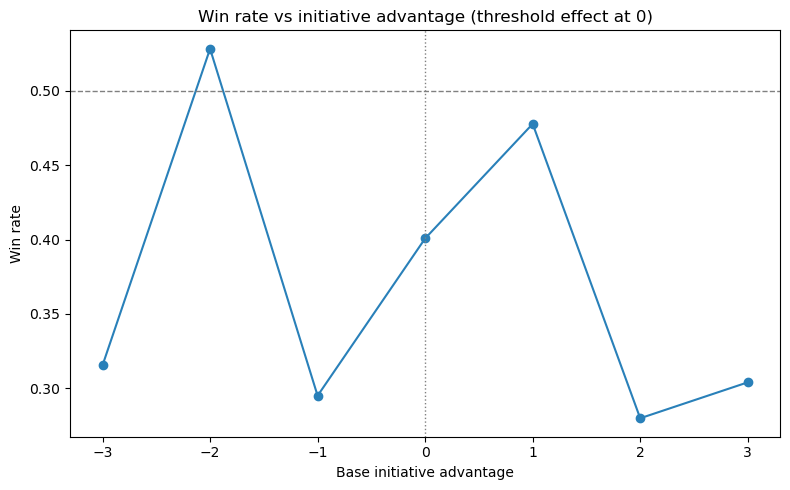


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\initiative_analysis.png


In [99]:
# ──────────────────────────────────────────────────────────────────────────────
# Initiative impact analysis
# ──────────────────────────────────────────────────────────────────────────────
#   A. Raw: win rate by base-initiative advantage (head-to-head pool sample)
#   B. Equipment init: sweep a weapon's init, measure win-rate slope
#   C. Tactics: Charge-priority vs neutral playstyle
#   D. Nimble: toggle Nimble on/off (first-skirmish +1 init)
#   E. Seize: toggle the Ministry "Seize: first" tag (innate), measure first-move edge

import numpy as np, pandas as pd, random
import importlib, loadouts, renown_combat, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(renown_combat); importlib.reload(vectorized_combat); importlib.reload(playstyles)
vectorized_combat.invalidate_tactic_tables()
from loadouts import Loadout, is_2h

pool = MAIN_POOL   # reuse the main tournament pool (no regeneration)
random.seed(2026)

def winrate(a, b, n=300, seed=7):
    a = a._replace(playstyle=playstyles.assign_default_playstyle(a)) if a.playstyle is None else a
    b = b._replace(playstyle=playstyles.assign_default_playstyle(b)) if b.playstyle is None else b
    r = vectorized_combat.run_matchup_vec(a, b, n_runs=n, seed=seed, max_skirmishes=20)
    tot = r['a_wins']+r['b_wins']+r['mut_wipe']+r['indecisive']
    return (r['a_wins']/tot if tot else float('nan')), (r['mut_wipe']/tot if tot else float('nan'))

SIZE=25
def chassis(weapon, shield, armor='Chainmail', ranged=None, extra=None, playstyle=None):
    return Loadout(name=f"{weapon or ranged}/{shield}", retinue='Man-at-Arms', weapon=weapon,
                   shield=shield, armor=armor, ranged=ranged, has_tiltyard=False, size=SIZE,
                   extra_tags=extra or ['Cond Field'], upkeep_per_retinue=30, playstyle=playstyle,
                   tiltyard_mastery=False, pursuits=frozenset(['Coliseum']),
                   military_pursuit_count=5, domain_count=0)

# ── A. Does higher base initiative win? ──
def base_init(ld):
    if ld.weapon and ld.weapon!='Farm Tools': wi=renown_combat.WEAPONS[ld.weapon]['init']
    elif ld.ranged: wi=renown_combat.RANGED[ld.ranged]['init']
    else: wi=0
    si=renown_combat.SHIELDS[ld.shield]['init'] if ld.shield else 0
    return wi+si

sample = [s._replace(playstyle=playstyles.assign_default_playstyle(s)) for s in random.sample(pool, 60)]
init_diff_wr = {}
for i in range(len(sample)):
    for j in range(i+1, len(sample)):
        a,b = sample[i], sample[j]
        di = base_init(a)-base_init(b)
        wr,_ = winrate(a,b,n=120,seed=100+i*60+j)
        init_diff_wr.setdefault(di, []).append(wr)
print("=== A. Win rate by base-initiative advantage ===")
print(pd.DataFrame([{"init_advantage":d,"n":len(v),"win_rate":np.mean(v)} for d,v in sorted(init_diff_wr.items())]).round(3).to_string(index=False))

# ── B. Equipment init slope ──
print("\n=== B. Equipment init slope (Arming Sword swept -2..+2, vs fixed Halberd) ===")
opp = chassis('Halberd', None)
orig = renown_combat.WEAPONS['Arming Sword']['init']
brows=[]
for test_init in [-2,-1,0,1,2]:
    renown_combat.WEAPONS['Arming Sword']['init']=test_init
    vectorized_combat.invalidate_tactic_tables()
    wr,mut = winrate(chassis('Arming Sword','Scutum Shield'),opp,n=400,seed=55)
    brows.append({"weapon_init":test_init,"base_init_w_shield":test_init-1,"win_rate":wr,"mut_pct":mut})
renown_combat.WEAPONS['Arming Sword']['init']=orig
vectorized_combat.invalidate_tactic_tables()
print(pd.DataFrame(brows).round(3).to_string(index=False))

# ── C. Tactic-driven init ──
print("\n=== C. Tactic-driven init: playstyle vs fixed defender ===")
opp = chassis('Arming Sword','Scutum Shield')
crows=[]
for ps in ['Aggressor','Cautious','Defender','Berserker','Skirmisher']:
    wr,mut = winrate(chassis('Arming Sword','Scutum Shield', playstyle=ps),opp,n=400,seed=88)
    crows.append({"playstyle":ps,"win_rate":wr,"mut_pct":mut})
print(pd.DataFrame(crows).sort_values("win_rate",ascending=False).round(3).to_string(index=False))

# ── D. Nimble toggle ──
print("\n=== D. Nimble impact (+1 init first skirmish) ===")
drows=[]
for wpn in ['Daggers','Short Sword']:
    if 'Nimble' not in renown_combat.WEAPONS[wpn]['tags']: continue
    opp = chassis('Arming Sword','Scutum Shield')
    sh = None if is_2h(wpn) else 'Scutum Shield'
    atk = chassis(wpn, sh, armor='Leather')
    wr_on,_ = winrate(atk,opp,n=400,seed=33)
    orig_tags = renown_combat.WEAPONS[wpn]['tags'][:]
    renown_combat.WEAPONS[wpn]['tags']=[t for t in orig_tags if t!='Nimble']
    vectorized_combat.invalidate_tactic_tables()
    wr_off,_ = winrate(atk,opp,n=400,seed=33)
    renown_combat.WEAPONS[wpn]['tags']=orig_tags; vectorized_combat.invalidate_tactic_tables()
    drows.append({"weapon":wpn,"wr_with_nimble":wr_on,"wr_without":wr_off,"nimble_delta":wr_on-wr_off})
print(pd.DataFrame(drows).round(3).to_string(index=False))

# ── E. Seize the Initiative (toggle the actual Seize tags) ──
# FIXED: old version used attacker_mode="attacker"/"defender" (invalid → both fell to the
# balanced split → identical matchups). Seize is driven by "Seize: first"/"Seize: every".
print("\n=== E. Seize the Initiative (toggle Ministry Seize tags) ===")
opp  = chassis('Arming Sword','Scutum Shield')
base = chassis('War Hammer', None, playstyle='Aggressor')   # init -1: benefits most
wr_none,_  = winrate(base, opp, n=600, seed=11)
wr_first,_ = winrate(base._replace(extra_tags=base.extra_tags+['Seize: first']), opp, n=600, seed=11)
wr_every,_ = winrate(base._replace(extra_tags=base.extra_tags+['Seize: first_two']), opp, n=600, seed=11)
both,_     = winrate(base._replace(extra_tags=base.extra_tags+['Seize: first']),
                     opp._replace(extra_tags=opp.extra_tags+['Seize: first']), n=600, seed=11)
print(f"  War Hammer (init -1) vs Arming Sword:")
print(f"    No Seize:      {wr_none:.3f}")
print(f"    Seize: first   {wr_first:.3f}  (Δ {wr_first-wr_none:+.3f})")
print(f"    Seize: fist two  {wr_every:.3f}  (Δ {wr_every-wr_none:+.3f})")
print(f"    Both have it:  {both:.3f}  (≈ No-Seize {wr_none:.3f}: mutual cancel)")
fast = chassis('Lance','Scutum Shield', playstyle='Cavalry')   # init +1: benefits least
fn,_ = winrate(fast, opp, n=600, seed=11)
fe,_ = winrate(fast._replace(extra_tags=fast.extra_tags+['Seize: every']), opp, n=600, seed=11)
print(f"  Lance (init +1): No Seize {fn:.3f} → Seize:every {fe:.3f}  (Δ {fe-fn:+.3f}, expect small)")

# ── Plot: A (headline) ──
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,5))
dfA = pd.DataFrame([{"init_advantage":d,"win_rate":np.mean(v)} for d,v in sorted(init_diff_wr.items()) if len(v)>=5])
ax.plot(dfA["init_advantage"], dfA["win_rate"], marker="o", color="#2980b9")
ax.axhline(0.5, color="gray", ls="--", lw=1); ax.axvline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("Base initiative advantage"); ax.set_ylabel("Win rate")
ax.set_title("Win rate vs initiative advantage (threshold effect at 0)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"initiative_analysis.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'initiative_analysis.png')}")

A win rate by (A init rows x B init cols) - same AP/weapon both sides:
       B=-3   B=-2   B=-1    B=0    B=1    B=2    B=3
A=-3  0.098  0.090  0.000  0.000  0.000  0.000  0.000
A=-2  0.728  0.625  0.048  0.010  0.035  0.025  0.025
A=-1  1.000  0.975  0.558  0.280  0.192  0.142  0.138
A=0   1.000  1.000  0.780  0.542  0.245  0.175  0.155
A=1   1.000  0.992  0.812  0.765  0.570  0.260  0.260
A=2   1.000  0.992  0.790  0.800  0.772  0.465  0.465
A=3   1.000  0.988  0.808  0.815  0.780  0.458  0.455

Init gap (A-B) -> mean A win rate (safe region, both >= -1):
  gap -4: 0.138
  gap -3: 0.149
  gap -2: 0.209
  gap -1: 0.312
  gap +0: 0.518
  gap +1: 0.694
  gap +2: 0.797
  gap +3: 0.802
  gap +4: 0.807


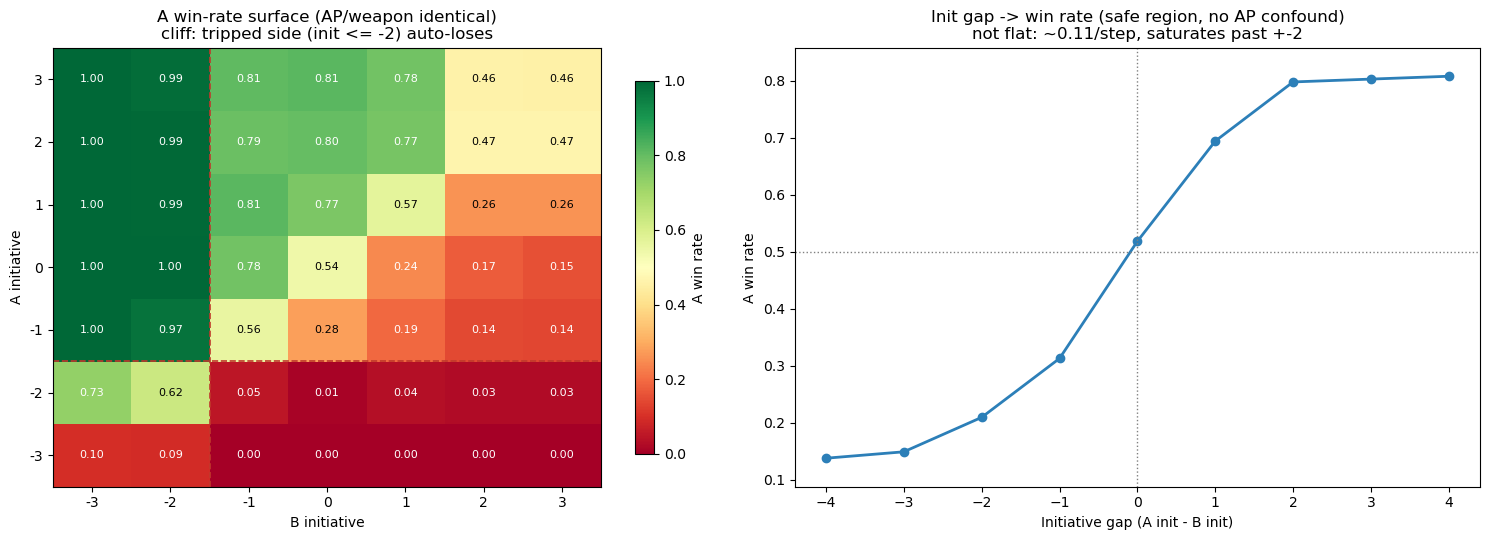


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\initiative_grid.png


In [100]:
# Initiative i1 x i2 surface — AP/weapon identical on both sides (pure init isolation).
import importlib, renown_combat, loadouts, vectorized_combat, playstyles
import numpy as np, pandas as pd, matplotlib.pyplot as plt
for _m in [renown_combat, loadouts, vectorized_combat, playstyles]: importlib.reload(_m)

# Two clone weapons: identical AP/tags (based on Arming Sword: AP -2, Steady, +1TH); only
# init is set per cell. A uses _initA, B uses _initB, so each side's init is independent.
_BASE_TAGS = ["Steady", "+1TH"]; _BASE_AP = -2
renown_combat.WEAPONS["_initA"] = {"ap": _BASE_AP, "init": 0, "tags": list(_BASE_TAGS), "tier": "Wrought"}
renown_combat.WEAPONS["_initB"] = {"ap": _BASE_AP, "init": 0, "tags": list(_BASE_TAGS), "tier": "Wrought"}

def _mk(name, weap):
    return loadouts.Loadout(name=name, retinue="Man-at-Arms", weapon=weap, shield=None,
        armor="Chainmail", ranged=None, has_tiltyard=False, size=25, extra_tags=["Cond Field"],
        upkeep_per_retinue=30, playstyle="Defender", tiltyard_mastery=False,
        pursuits=frozenset(["Conditioning Field"]), military_pursuit_count=5, domain_count=0)

INITS = [-3, -2, -1, 0, 1, 2, 3]
_A, _B = _mk("A", "_initA"), _mk("B", "_initB")
grid = np.full((len(INITS), len(INITS)), np.nan)
for ia, va in enumerate(INITS):
    for ib, vb in enumerate(INITS):
        renown_combat.WEAPONS["_initA"]["init"] = va
        renown_combat.WEAPONS["_initB"]["init"] = vb
        vectorized_combat.invalidate_tactic_tables()
        r = vectorized_combat.run_matchup_vec(_A, _B, n_runs=400, seed=100+ia*7+ib,
                a_playstyle="Defender", b_playstyle="Defender", alternate_attacker=False)
        t = r["a_wins"]+r["b_wins"]+r["mut_wipe"]+r["indecisive"]
        grid[ia, ib] = r["a_wins"]/t if t else np.nan
del renown_combat.WEAPONS["_initA"], renown_combat.WEAPONS["_initB"]
vectorized_combat.invalidate_tactic_tables()

df_grid = pd.DataFrame(grid, index=[f"A={i}" for i in INITS], columns=[f"B={i}" for i in INITS])
print("A win rate by (A init rows x B init cols) - same AP/weapon both sides:")
print(df_grid.round(3).to_string())

# Gap collapse over the SAFE region (neither side tripped: both >= -1).
gaps = {}
for ia, va in enumerate(INITS):
    for ib, vb in enumerate(INITS):
        if va >= -1 and vb >= -1:
            gaps.setdefault(va - vb, []).append(grid[ia, ib])
gap_x = sorted(gaps)
gap_y = [np.mean(gaps[g]) for g in gap_x]
print("\nInit gap (A-B) -> mean A win rate (safe region, both >= -1):")
for g, y in zip(gap_x, gap_y):
    print(f"  gap {g:+d}: {y:.3f}")

# ── Two-panel plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel 1: heatmap
im = ax1.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto", origin="lower")
ax1.set_xticks(range(len(INITS))); ax1.set_xticklabels(INITS)
ax1.set_yticks(range(len(INITS))); ax1.set_yticklabels(INITS)
ax1.set_xlabel("B initiative"); ax1.set_ylabel("A initiative")
ax1.set_title("A win-rate surface (AP/weapon identical)\ncliff: tripped side (init <= -2) auto-loses")
for ia in range(len(INITS)):
    for ib in range(len(INITS)):
        v = grid[ia, ib]
        ax1.text(ib, ia, f"{v:.2f}", ha="center", va="center", fontsize=8,
                 color="white" if (v < 0.25 or v > 0.7) else "black")
ax1.axhline(INITS.index(-2)+0.5, color="#c0392b", lw=1.2, ls="--")
ax1.axvline(INITS.index(-2)+0.5, color="#c0392b", lw=1.2, ls="--")
plt.colorbar(im, ax=ax1, label="A win rate", shrink=0.85)

# Panel 2: gap curve (the corrected "init advantage" chart)
ax2.plot(gap_x, gap_y, marker="o", color="#2c7fb8", lw=2)
ax2.axhline(0.5, color="gray", ls=":", lw=1)
ax2.axvline(0, color="gray", ls=":", lw=1)
_ylo = max(0.0, min(gap_y) - 0.05); _yhi = max(gap_y) + 0.05
ax2.set_ylim(_ylo, _yhi)
ax2.set_xlabel("Initiative gap (A init - B init)")
ax2.set_ylabel("A win rate")
ax2.set_title("Init gap -> win rate (safe region, no AP confound)\nnot flat: ~0.11/step, saturates past +-2")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "initiative_grid.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR, 'initiative_grid.png')}")

=== Bastard Sword (A, rows) vs Poleaxe (B, cols) — A win rate by tactic pair ===
                       B:Scout  B:Ambush  B:Flank  B:Charge  B:Fighting Formation  B:Defensive Formation  B:Fall Back
A:Scout                   0.88      0.76     0.94      0.92                  0.49                   0.76         0.00
A:Ambush                  0.94      0.83     0.41      1.00                  0.99                   0.44         0.00
A:Flank                   0.74      1.00     0.00      0.86                  0.99                   0.74         0.58
A:Charge                  0.87      0.27     0.92      0.90                  0.42                   0.14         0.98
A:Fighting Formation      1.00      0.44     0.59      1.00                  0.93                   0.90         0.98
A:Defensive Formation     0.92      0.99     0.94      1.00                  0.88                   0.82         0.00
A:Fall Back               0.00      0.00     1.00      0.55                  0.70            

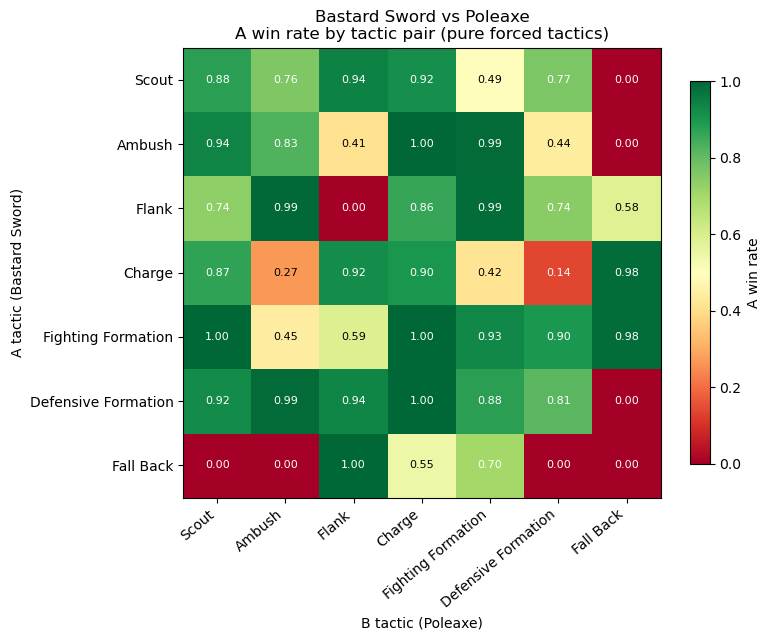


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\tactic_matrix_weaponpair.png


In [101]:
# Tactic x Tactic matrix for a fixed WEAPON pairing.
# "Player A has weapon_a + tactic_x, Player B has weapon_b + tactic_y" for all tactic pairs.
# Tactics are FORCED pure (one-hot) so each cell is a clean single-tactic-vs-single-tactic read.
import importlib, renown_combat, loadouts, vectorized_combat, playstyles
import numpy as np, pandas as pd, matplotlib.pyplot as plt
for _m in [renown_combat, loadouts, vectorized_combat, playstyles]: importlib.reload(_m)
from renown_combat import TACTICS

# ── CONFIGURE ──
WEAPON_A = "Bastard Sword"      # Player A's weapon
WEAPON_B = "Poleaxe"    # Player B's weapon
ARMOR_A, ARMOR_B = "Gothic Plate", "Gothic Plate"
SHIELD_A, SHIELD_B = "Heater Shield", None
N_RUNS = 400

# Register pure forced-tactic playstyles (one-hot, bypassing the FB-reshaping in resolve()).
def _make_forced(idx):
    _oh = np.zeros(7); _oh[idx] = 1.0
    def f(state, n_runs, _oh=_oh): return np.tile(_oh, (n_runs, 1))
    return f
_forced_names = []
for _idx, _name in enumerate(TACTICS):
    _pname = f"_force_{_name}"
    playstyles.ADAPTIVE_PLAYSTYLES[_pname] = {"func": _make_forced(_idx), "description": "forced", "good_for": "", "initiate_rate": 0.5}
    playstyles.FB_INTENTIONAL_PLAYSTYLES.add(_pname)   # return weights as-is (pure one-hot)
    _forced_names.append(_pname)
playstyles.ALL_PLAYSTYLES = list(playstyles.STATIC_PLAYSTYLES.keys()) + list(playstyles.ADAPTIVE_PLAYSTYLES.keys())
vectorized_combat.invalidate_tactic_tables()

def _mk(name, weap, arm, shield):
    return loadouts.Loadout(name=name, retinue="Man-at-Arms", weapon=weap, shield=shield,
        armor=arm, ranged=None, has_tiltyard=False, size=25, extra_tags=["Cond Field"],
        upkeep_per_retinue=30, playstyle="Aggressor", tiltyard_mastery=False,
        pursuits=frozenset(["Conditioning Field"]), military_pursuit_count=5, domain_count=0)

_A = _mk("A", WEAPON_A, ARMOR_A, SHIELD_A)
_B = _mk("B", WEAPON_B, ARMOR_B, SHIELD_B)
M = np.full((7, 7), np.nan)
for i, ta in enumerate(TACTICS):
    for j, tb in enumerate(TACTICS):
        r = vectorized_combat.run_matchup_vec(_A, _B, n_runs=N_RUNS, seed=25+i*7+j,
                a_playstyle=f"_force_{ta}", b_playstyle=f"_force_{tb}", alternate_attacker=False)
        t = r["a_wins"]+r["b_wins"]+r["mut_wipe"]+r["indecisive"]
        M[i, j] = r["a_wins"]/t if t else np.nan

# cleanup the temporary forced playstyles
for _pname in _forced_names:
    playstyles.ADAPTIVE_PLAYSTYLES.pop(_pname, None)
    playstyles.FB_INTENTIONAL_PLAYSTYLES.discard(_pname)
playstyles.ALL_PLAYSTYLES = list(playstyles.STATIC_PLAYSTYLES.keys()) + list(playstyles.ADAPTIVE_PLAYSTYLES.keys())
vectorized_combat.invalidate_tactic_tables()

df_tac = pd.DataFrame(M, index=[f"A:{t}" for t in TACTICS], columns=[f"B:{t}" for t in TACTICS])
print(f"=== {WEAPON_A} (A, rows) vs {WEAPON_B} (B, cols) — A win rate by tactic pair ===")
print(df_tac.round(2).to_string())
# A's best tactic vs each B tactic, and the row/col averages
print("\nA's best response to each B tactic:")
for j, tb in enumerate(TACTICS):
    bi = np.nanargmax(M[:, j]); print(f"  vs B:{tb:18} → A plays {TACTICS[bi]:18} ({M[bi,j]:.2f})")
print(f"\nA tactic avg (over B's tactics): " + ", ".join(f"{TACTICS[i][:4]} {np.nanmean(M[i]):.2f}" for i in range(7)))

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto", origin="upper")
ax.set_xticks(range(7)); ax.set_xticklabels(TACTICS, rotation=40, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(TACTICS)
ax.set_xlabel(f"B tactic ({WEAPON_B})"); ax.set_ylabel(f"A tactic ({WEAPON_A})")
ax.set_title(f"{WEAPON_A} vs {WEAPON_B}\nA win rate by tactic pair (pure forced tactics)")
for i in range(7):
    for j in range(7):
        v = M[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if (v < 0.25 or v > 0.7) else "black")
plt.colorbar(im, ax=ax, label="A win rate", shrink=0.85)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tactic_matrix_weaponpair.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR, 'tactic_matrix_weaponpair.png')}")

=== War Hammer: tactic sensitivity vs field of 10 opponents ===
             tactic  mean_wr
Defensive Formation    0.631
              Scout    0.451
             Ambush    0.432
              Flank    0.165
             Charge    0.155
 Fighting Formation    0.078
          Fall Back    0.006

Tactic choice swing: 0.006 (worst) → 0.631 (best) = +0.625 spread
  → tactic choice matters a lot for War Hammer


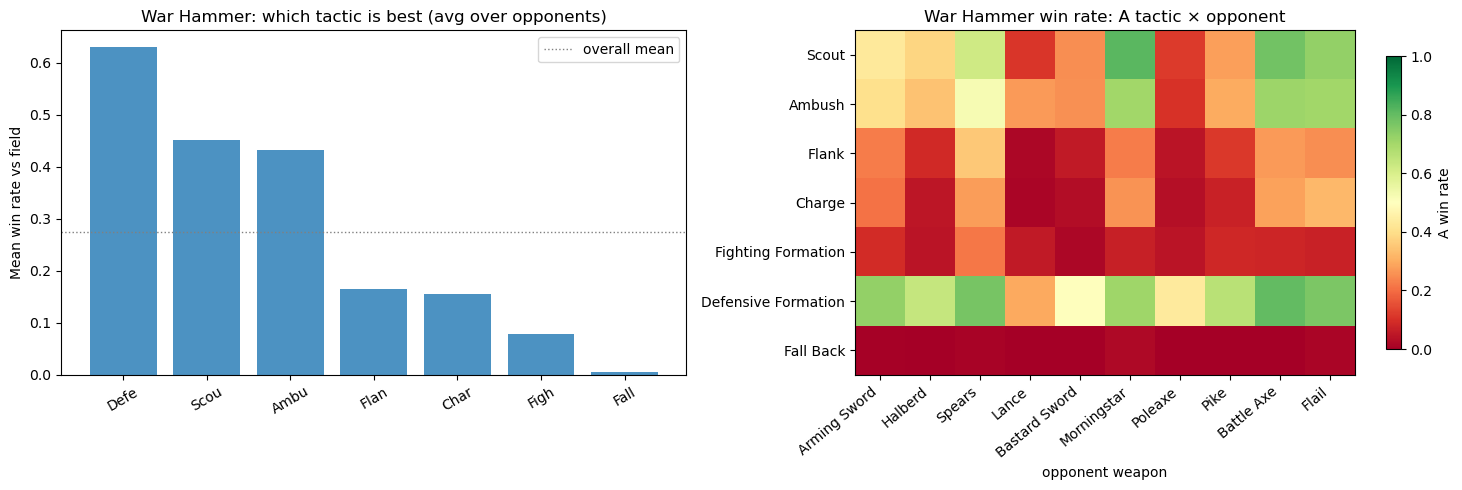


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\tactic_sensitivity.png


In [102]:
# Tactic SENSITIVITY for one weapon: how much does A's tactic choice matter, averaged over a
# field of opponent weapons (each opponent plays its own assigned playstyle, i.e. realistic).
import importlib, renown_combat, loadouts, vectorized_combat, playstyles
import numpy as np, pandas as pd, matplotlib.pyplot as plt
for _m in [renown_combat, loadouts, vectorized_combat, playstyles]: importlib.reload(_m)
from renown_combat import TACTICS

# ── CONFIGURE ──
WEAPON_A = "War Hammer"      # the weapon whose tactic sensitivity we measure
ARMOR_A = "Chainmail"; SHIELD_A = None
N_RUNS = 300
# Opponent field: a representative set of enemy weapons (each on Chainmail, its own playstyle).
OPP_WEAPONS = ["Arming Sword", "Halberd", "Spears", "Lance", "Bastard Sword",
               "Morningstar", "Poleaxe", "Pike", "Battle Axe", "Flail"]

# Register pure forced-tactic playstyles for A.
def _make_forced(idx):
    _oh = np.zeros(7); _oh[idx] = 1.0
    def f(state, n_runs, _oh=_oh): return np.tile(_oh, (n_runs, 1))
    return f
_forced_names = []
for _idx, _name in enumerate(TACTICS):
    _pname = f"_force_{_name}"
    playstyles.ADAPTIVE_PLAYSTYLES[_pname] = {"func": _make_forced(_idx), "description": "forced", "good_for": "", "initiate_rate": 0.5}
    playstyles.FB_INTENTIONAL_PLAYSTYLES.add(_pname)
    _forced_names.append(_pname)
vectorized_combat.invalidate_tactic_tables()

def _mk(name, weap, arm="Chainmail", shield=None):
    return loadouts.Loadout(name=name, retinue="Man-at-Arms", weapon=weap, shield=shield,
        armor=arm, ranged=None, has_tiltyard=False, size=25, extra_tags=["Cond Field"],
        upkeep_per_retinue=30, playstyle="Aggressor", tiltyard_mastery=False,
        pursuits=frozenset(["Conditioning Field"]), military_pursuit_count=5, domain_count=0)

_A = _mk("A", WEAPON_A, ARMOR_A, SHIELD_A)
_field = []
for w in OPP_WEAPONS:
    o = _mk(f"opp_{w}", w)
    _field.append(o._replace(playstyle=playstyles.assign_default_playstyle(o)))

# For each A tactic, average A's win rate across the field (opponents play their own playstyle).
rows = []
per_tactic_vs_opp = np.full((7, len(_field)), np.nan)
for i, ta in enumerate(TACTICS):
    wins = tot = 0
    for k, opp in enumerate(_field):
        r = vectorized_combat.run_matchup_vec(_A, opp, n_runs=N_RUNS, seed=70+i*13+k,
                a_playstyle=f"_force_{ta}", b_playstyle=opp.playstyle, alternate_attacker=False)
        t = r["a_wins"]+r["b_wins"]+r["mut_wipe"]+r["indecisive"]
        wr = r["a_wins"]/t if t else np.nan
        per_tactic_vs_opp[i, k] = wr
        wins += r["a_wins"]; tot += t
    rows.append({"tactic": ta, "mean_wr": wins/tot if tot else np.nan})
df_sens = pd.DataFrame(rows).sort_values("mean_wr", ascending=False)

for _pname in _forced_names:
    playstyles.ADAPTIVE_PLAYSTYLES.pop(_pname, None)
    playstyles.FB_INTENTIONAL_PLAYSTYLES.discard(_pname)
vectorized_combat.invalidate_tactic_tables()

print(f"=== {WEAPON_A}: tactic sensitivity vs field of {len(_field)} opponents ===")
print(df_sens.round(3).to_string(index=False))
_best, _worst = df_sens["mean_wr"].max(), df_sens["mean_wr"].min()
print(f"\nTactic choice swing: {_worst:.3f} (worst) → {_best:.3f} (best) = {_best-_worst:+.3f} spread")
print(f"  → {'tactic choice matters a lot' if _best-_worst>0.15 else 'tactic choice is minor' if _best-_worst<0.05 else 'tactic choice is moderate'} for {WEAPON_A}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Panel 1: mean win rate per tactic
order = df_sens["tactic"].tolist()
ax1.bar(range(7), df_sens["mean_wr"], color="#2c7fb8", alpha=0.85)
ax1.set_xticks(range(7)); ax1.set_xticklabels([t[:4] for t in order], rotation=30)
ax1.set_ylabel("Mean win rate vs field"); ax1.set_title(f"{WEAPON_A}: which tactic is best (avg over opponents)")
ax1.axhline(df_sens["mean_wr"].mean(), color="gray", ls=":", lw=1, label="overall mean")
ax1.legend()
# Panel 2: heatmap tactic x opponent (where each tactic shines)
im = ax2.imshow(per_tactic_vs_opp, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax2.set_yticks(range(7)); ax2.set_yticklabels(TACTICS)
ax2.set_xticks(range(len(_field))); ax2.set_xticklabels(OPP_WEAPONS, rotation=40, ha="right")
ax2.set_xlabel("opponent weapon"); ax2.set_title(f"{WEAPON_A} win rate: A tactic × opponent")
plt.colorbar(im, ax=ax2, label="A win rate", shrink=0.85)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tactic_sensitivity.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR, 'tactic_sensitivity.png')}")

=== Weapon x Weapon at optimal tactic play (MODE=exploit) — A win rate (rows=A, cols=B) ===
               Cudgel  Daggers  Short Sword  Spears  Arming Sword  Pike  Flail  Halberd  Battle Axe  Bastard Sword  Lance  Morningstar  War Hammer  Poleaxe
Cudgel           0.27     0.15         0.14    0.20          0.15  0.12   0.25     0.06        0.23           0.09   0.08         0.17        0.19     0.04
Daggers          0.85     0.46         0.67    0.68          0.45  0.39   0.76     0.43        0.72           0.34   0.31         0.63        0.65     0.31
Short Sword      0.31     0.19         0.19    0.20          0.19  0.14   0.32     0.09        0.27           0.12   0.14         0.23        0.24     0.11
Spears           0.32     0.20         0.20    0.25          0.21  0.14   0.30     0.11        0.30           0.12   0.13         0.26        0.19     0.10
Arming Sword     0.78     0.56         0.72    0.71          0.45  0.46   0.73     0.43        0.73           0.35   0.38       

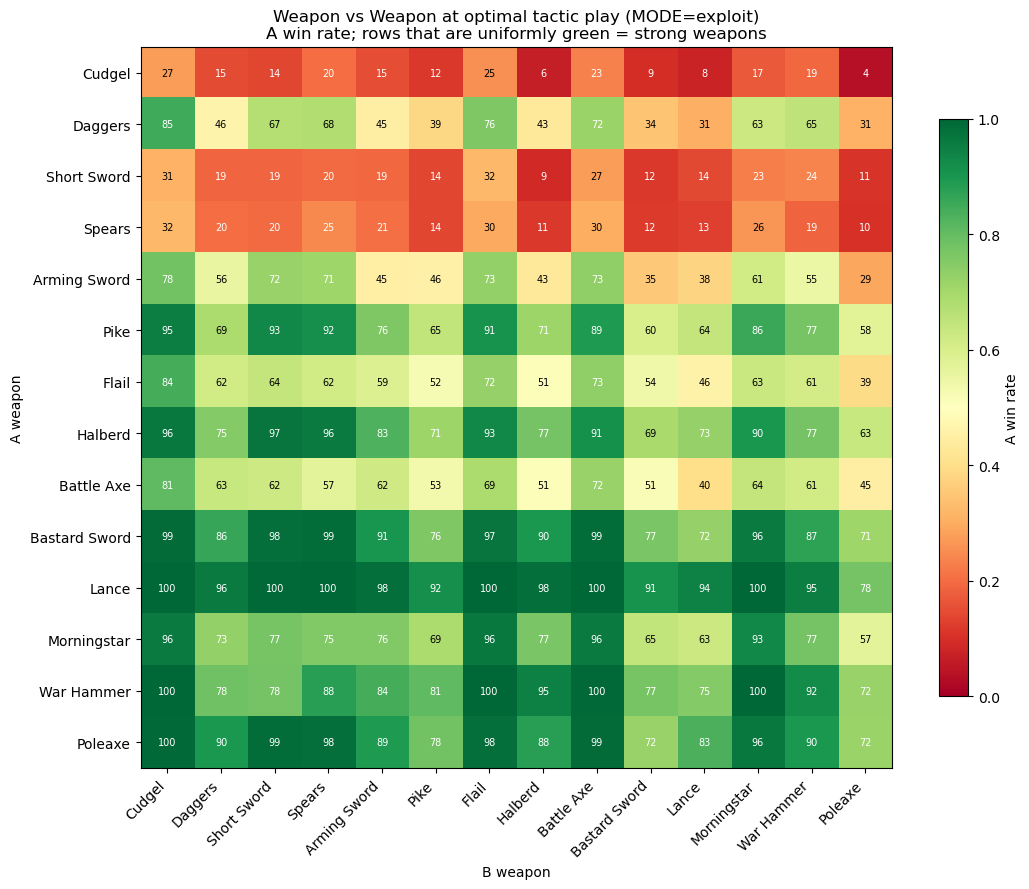


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\weapon_matrix_optimal_exploit.png


In [103]:
# #3 — Weapon x Weapon matrix at OPTIMAL TACTIC PLAY (tactic dimension solved out).
# For each weapon pairing, find a best tactic and report the win rate. Two MODEs:
#   "exploit" — A plays its BEST tactic vs B on its assigned playstyle. Discriminates weapons
#               well; ASYMMETRIC (measures how well A exploits B's fixed doctrine).
#   "fair"    — both sides best-respond (A_best vs B_best). Symmetric, but tends toward
#               defensive stalemate (low sums) since safe mutual play is non-committal.
# NOTE: in a game with strong defensive/non-engagement tactics, full game-theoretic "optimal"
# play drifts to mutual caution. "exploit" is usually the more informative weapon comparison.
import importlib, renown_combat, loadouts, vectorized_combat, playstyles
import numpy as np, pandas as pd, matplotlib.pyplot as plt
for _m in [renown_combat, loadouts, vectorized_combat, playstyles]: importlib.reload(_m)
from renown_combat import TACTICS

# ── CONFIGURE ──
MODE = "exploit"        # "exploit" or "fair"
ARMOR = "Gothic Plate"     # chassis held constant to isolate the weapon x tactic interaction
N_RUNS = 250
WEAPONS = ["Cudgel","Daggers","Short Sword","Spears","Arming Sword","Pike","Flail","Halberd",
           "Battle Axe","Bastard Sword","Lance","Morningstar","War Hammer","Poleaxe"]
# (drop/add weapons to taste; full 16 incl. Daggers/2HBastard/Farm Tools runs ~60-90s)

# Register pure forced-tactic playstyles (one-hot, bypassing FB reshaping).
def _make_forced(idx):
    _oh = np.zeros(7); _oh[idx] = 1.0
    def f(state, n_runs, _oh=_oh): return np.tile(_oh, (n_runs, 1))
    return f
_forced = []
for _idx, _name in enumerate(TACTICS):
    _p = f"_force_{_name}"
    playstyles.ADAPTIVE_PLAYSTYLES[_p] = {"func": _make_forced(_idx), "description": "forced", "good_for": "", "initiate_rate": 0.5}
    playstyles.FB_INTENTIONAL_PLAYSTYLES.add(_p); _forced.append(_p)
vectorized_combat.invalidate_tactic_tables()

def _mk(weap, arm=ARMOR):
    b = loadouts.Loadout(name=weap, retinue="Man-at-Arms", weapon=weap, shield=None, armor=arm,
        ranged=None, has_tiltyard=False, size=25, extra_tags=["Cond Field"], upkeep_per_retinue=30,
        playstyle="Aggressor", tiltyard_mastery=False, pursuits=frozenset(["Conditioning Field"]),
        military_pursuit_count=5, domain_count=0)
    return b._replace(playstyle=playstyles.assign_default_playstyle(b))

def _best_tactic(att, defn, defn_playstyle, seed0):
    best, bt = -1.0, TACTICS[0]
    for i, ta in enumerate(TACTICS):
        r = vectorized_combat.run_matchup_vec(att, defn, n_runs=N_RUNS, seed=seed0+i,
                a_playstyle=f"_force_{ta}", b_playstyle=defn_playstyle, alternate_attacker=False)
        t = r["a_wins"]+r["b_wins"]+r["mut_wipe"]+r["indecisive"]
        wr = r["a_wins"]/t if t else 0.0
        if wr > best: best, bt = wr, ta
    return bt

n = len(WEAPONS)
val = np.full((n, n), np.nan)
a_choice = np.empty((n, n), dtype=object)
b_choice = np.empty((n, n), dtype=object)
for wi, wa in enumerate(WEAPONS):
    for wj, wb in enumerate(WEAPONS):
        A, B = _mk(wa), _mk(wb)
        a_best = _best_tactic(A, B, B.playstyle, seed0=wi*991+wj*89)
        if MODE == "fair":
            b_best = _best_tactic(B, A, A.playstyle, seed0=wj*991+wi*89+7)
            bp = f"_force_{b_best}"
        else:
            b_best = B.playstyle; bp = B.playstyle
        r = vectorized_combat.run_matchup_vec(A, B, n_runs=N_RUNS*2, seed=wi*131+wj*61,
                a_playstyle=f"_force_{a_best}", b_playstyle=bp, alternate_attacker=False)
        t = r["a_wins"]+r["b_wins"]+r["mut_wipe"]+r["indecisive"]
        val[wi, wj] = r["a_wins"]/t if t else np.nan
        a_choice[wi, wj] = a_best; b_choice[wi, wj] = b_best

for _p in _forced:
    playstyles.ADAPTIVE_PLAYSTYLES.pop(_p, None); playstyles.FB_INTENTIONAL_PLAYSTYLES.discard(_p)
vectorized_combat.invalidate_tactic_tables()

df_w = pd.DataFrame(val, index=WEAPONS, columns=WEAPONS)
print(f"=== Weapon x Weapon at optimal tactic play (MODE={MODE}) — A win rate (rows=A, cols=B) ===")
print(df_w.round(2).to_string())
# Overall weapon strength = mean win rate across all opponents (excl. self-mirror)
strength = {w: np.nanmean([val[i, j] for j in range(n) if j != i]) for i, w in enumerate(WEAPONS)}
print("\nWeapon strength ranking (mean win rate vs field, excl. mirror):")
for w, s in sorted(strength.items(), key=lambda x: -x[1]):
    print(f"  {w:14} {s:.3f}")

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(val, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(n)); ax.set_xticklabels(WEAPONS, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(WEAPONS)
ax.set_xlabel("B weapon"); ax.set_ylabel("A weapon")
ax.set_title(f"Weapon vs Weapon at optimal tactic play (MODE={MODE})\nA win rate; rows that are uniformly green = strong weapons")
for i in range(n):
    for j in range(n):
        v = val[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}"[:-1], ha="center", va="center", fontsize=7,
                    color="white" if (v < 0.25 or v > 0.7) else "black")
plt.colorbar(im, ax=ax, label="A win rate", shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"weapon_matrix_optimal_{MODE}.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR, f'weapon_matrix_optimal_{MODE}.png')}")

Defender durability (effective save target, lower = tougher):
  Cloth                  save 6+
  Cloth+Wooden           save 5+
  Leather+Kite           save 4+
  Chainmail              save 4+
  Chainmail+Scutum       save 3+
  Full Plate             save 3+
  Full Plate+Kite        save 2+
  Full Plate+Scutum      save 2+
  Full Plate+Heater      save 2+
  Gothic Plate           save 2+
  Full Plate+Tower       save 1+
  Gothic Plate+Scutum    save 1+
  Gothic Plate+Heater    save 1+
  Gothic Plate+Tower     save 0+

=== AP win rate vs armor+shield defenders ===
 weapon_AP  Cloth  Cloth+Wooden  Leather+Kite  Chainmail  Chainmail+Scutum  Full Plate  Full Plate+Kite  Full Plate+Scutum  Full Plate+Heater  Gothic Plate  Full Plate+Tower  Gothic Plate+Scutum  Gothic Plate+Heater  Gothic Plate+Tower
         0  0.963         0.932         0.777      0.777             0.340       0.562            0.205              0.145              0.117         0.205             0.028                0.02

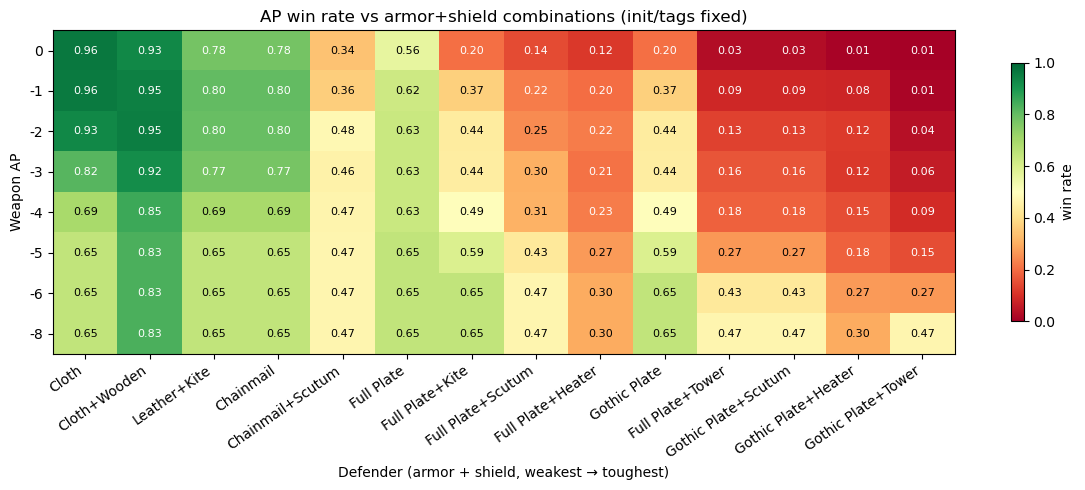


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\ap_vs_armor_shield.png


In [104]:
# ──────────────────────────────────────────────────────────────────────────────
# Armor Penetration (AP) — ISOLATED, vs realistic armor+shield combinations
# ──────────────────────────────────────────────────────────────────────────────
# AP lowers the defender's save target; shields ALSO lower it (better save), so a
# defender's real durability = armor + shield together. We sweep one weapon's AP with
# init/tags fixed, and measure it against representative armor+shield defenders (the
# pairings that actually occur in the pool, by tier).

import numpy as np, pandas as pd, random
import importlib, loadouts, renown_combat, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(renown_combat); importlib.reload(vectorized_combat); importlib.reload(playstyles)
vectorized_combat.invalidate_tactic_tables()
from loadouts import Loadout

SIZE = 25
def mk(weapon, shield, armor='Chainmail', extra=None, playstyle='Aggressor'):
    return Loadout(name=f"{weapon}/{shield}/{armor}", retinue='Man-at-Arms', weapon=weapon, shield=shield,
                   armor=armor, ranged=None, has_tiltyard=False, size=SIZE,
                   extra_tags=extra or ['Cond Field'], upkeep_per_retinue=30, playstyle=playstyle,
                   tiltyard_mastery=False, pursuits=frozenset(['Conditioning Field']),
                   military_pursuit_count=5, domain_count=0)

def winrate(a, b, n=400, seed=11):
    a = a._replace(playstyle=playstyles.assign_default_playstyle(a)) if a.playstyle is None else a
    b = b._replace(playstyle=playstyles.assign_default_playstyle(b)) if b.playstyle is None else b
    r = vectorized_combat.run_matchup_vec(a, b, n_runs=n, seed=seed, max_skirmishes=20)
    t = r['a_wins']+r['b_wins']+r['mut_wipe']+r['indecisive']
    return (r['a_wins']/t if t else np.nan)

# Effective save target a defender presents (lower = tougher): armor_save - shield_bonus.
def eff_save(armor, shield):
    s = renown_combat.ARMORS[armor]['save']
    sb = renown_combat.SHIELDS[shield]['save_bonus'] if shield else 0
    return s - sb

# Representative defender profiles: armor paired with the shield that tier realistically uses.
# (None = the no-shield / 2H-defender case for that tier.)
DEFENDERS = [
    ("Cloth",        None),
    ("Cloth",        "Wooden Shield"),
    ("Leather",      "Kite Shield"),
    ("Chainmail",    None),
    ("Chainmail",    "Scutum Shield"),
    ("Full Plate",   None),
    ("Full Plate",   "Kite Shield"),
    ("Full Plate",   "Scutum Shield"),
    ("Full Plate",   "Tower Shield"),
    ("Full Plate",   "Heater Shield"),
    ("Gothic Plate", None),
    ("Gothic Plate", "Scutum Shield"),
    ("Gothic Plate", "Heater Shield"),
    ("Gothic Plate", "Tower Shield")
]
# Sort by effective save (toughest last) for readable axes
DEFENDERS = sorted(DEFENDERS, key=lambda ad: -eff_save(ad[0], ad[1]))  # weakest (high target) first
def_labels = [f"{a}+{s.split()[0]}" if s else f"{a}" for a, s in DEFENDERS]

print("Defender durability (effective save target, lower = tougher):")
for (a, s), lab in zip(DEFENDERS, def_labels):
    print(f"  {lab:22} save {eff_save(a,s)}+")

# ── AP sweep × defender (armor+shield) ──
print("\n=== AP win rate vs armor+shield defenders ===")
orig_ap = renown_combat.WEAPONS['Arming Sword']['ap']
attacker_armor = 'Chainmail'   # attacker fixed
grid = []
for test_ap in [0,-1, -2, -3, -4, -5, -6, -8]:
    renown_combat.WEAPONS['Arming Sword']['ap'] = test_ap
    vectorized_combat.invalidate_tactic_tables()
    row = {"weapon_AP": test_ap}
    for (arm, sh), lab in zip(DEFENDERS, def_labels):
        atk = mk('Arming Sword', 'Scutum Shield', armor=attacker_armor)   # attacker fixed
        # defender uses a Steady weapon so a shield is legal; Arming Sword is 1H, shield ok
        defn = mk('Arming Sword', sh, armor=arm)
        row[lab] = round(winrate(atk, defn, n=400, seed=77), 3)
    grid.append(row)
renown_combat.WEAPONS['Arming Sword']['ap'] = orig_ap
vectorized_combat.invalidate_tactic_tables()
df = pd.DataFrame(grid)
print(df.to_string(index=False))
print("\nRead down a column: how much extra AP helps against THAT armor+shield wall.")
print("Read across a row: how a fixed AP level decays as the enemy stacks armor+shield.")

# ── Saturation point per defender: lowest AP where win rate stops improving ──
print("\n=== AP saturation point per defender (where extra AP stops mattering) ===")
sat = []
for lab in def_labels:
    col = df[lab].values
    aps = df["weapon_AP"].values
    # find first AP (scanning most→least negative... here ascending order 0..-8) where
    # further AP gives <0.01 improvement
    best = col.max()
    sat_ap = aps[0]
    for k in range(1, len(col)):
        if col[k] - col[k-1] < 0.01 and col[k] >= best - 0.01:
            sat_ap = aps[k-1]; break
        sat_ap = aps[k]
    sat.append({"defender": lab, "save": eff_save(*DEFENDERS[def_labels.index(lab)]),
                "best_wr": round(best,3), "AP_saturates_at": sat_ap})
print(pd.DataFrame(sat).to_string(index=False))

# ── Plot heatmap ──
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
hm = df[def_labels].values
im = ax.imshow(hm, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(def_labels))); ax.set_xticklabels(def_labels, rotation=35, ha="right")
ax.set_yticks(range(len(df))); ax.set_yticklabels(df["weapon_AP"])
ax.set_ylabel("Weapon AP"); ax.set_xlabel("Defender (armor + shield, weakest → toughest)")
ax.set_title("AP win rate vs armor+shield combinations (init/tags fixed)")
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax.text(j, i, f"{hm[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if (hm[i,j]<0.25 or hm[i,j]>0.7) else "black")
plt.colorbar(im, ax=ax, label="win rate", shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ap_vs_armor_shield.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'ap_vs_armor_shield.png')}")

Defender durability (effective save, lower = tougher):
  Cloth                  save 6+
  Cloth+Wooden           save 5+
  Leather+Kite           save 4+
  Chainmail              save 4+
  Chainmail+Scutum       save 3+
  Full Plate             save 3+
  Gothic Plate           save 2+
  Full Plate+Tower       save 1+
  Gothic Plate+Heater    save 1+

=== AP win rate vs defenders, plus Unstoppable-vs-shield comparison ===
 weapon_AP  Cloth  Cloth+Wooden  Leather+Kite  Chainmail  Chainmail+Scutum  Full Plate  Gothic Plate  Full Plate+Tower  Gothic Plate+Heater  UNSTOP→Scutum  UNSTOP→Tower  UNSTOP→Heater
         0  0.963         0.932         0.777      0.777             0.340       0.562         0.205             0.028                0.010          0.573         0.037          0.010
        -2  0.932         0.953         0.795      0.795             0.480       0.630         0.438             0.130                0.120          0.760         0.250          0.120
        -3  0.818      

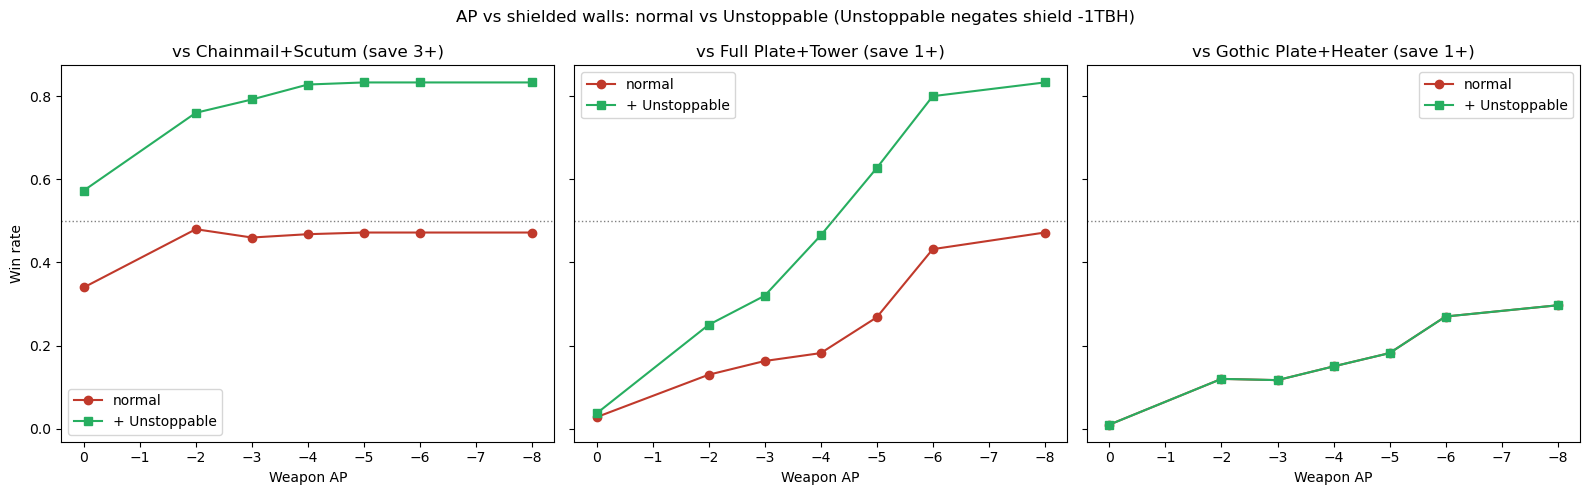


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\ap_unstoppable_vs_shields.png


In [105]:
# ──────────────────────────────────────────────────────────────────────────────
# Armor Penetration (AP) — vs armor+shield, WITH an Unstoppable comparison
# ──────────────────────────────────────────────────────────────────────────────
# AP and shields both shift the save target. Shields ALSO impose -1TBH (attacker must
# roll +1 higher to hit). Unstoppable zeroes that shield -1TBH — so it should help ONLY
# against shielded defenders. We add three extra columns: vs Scutum / Tower / Heater
# defenders with the attacker carrying Unstoppable, to see how much it cracks shields.

import numpy as np, pandas as pd, random
import importlib, loadouts, renown_combat, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(renown_combat); importlib.reload(vectorized_combat); importlib.reload(playstyles)
vectorized_combat.invalidate_tactic_tables()
from loadouts import Loadout

SIZE = 25
def mk(weapon, shield, armor='Chainmail', extra=None, playstyle='Aggressor'):
    return Loadout(name=f"{weapon}/{shield}/{armor}", retinue='Man-at-Arms', weapon=weapon, shield=shield,
                   armor=armor, ranged=None, has_tiltyard=False, size=SIZE,
                   extra_tags=extra or ['Cond Field'], upkeep_per_retinue=30, playstyle=playstyle,
                   tiltyard_mastery=False, pursuits=frozenset(['Conditioning Field']),
                   military_pursuit_count=5, domain_count=0)

def winrate(a, b, n=400, seed=11):
    a = a._replace(playstyle=playstyles.assign_default_playstyle(a)) if a.playstyle is None else a
    b = b._replace(playstyle=playstyles.assign_default_playstyle(b)) if b.playstyle is None else b
    r = vectorized_combat.run_matchup_vec(a, b, n_runs=n, seed=seed, max_skirmishes=20)
    t = r['a_wins']+r['b_wins']+r['mut_wipe']+r['indecisive']
    return (r['a_wins']/t if t else np.nan)

def eff_save(armor, shield):
    s = renown_combat.ARMORS[armor]['save']
    sb = renown_combat.SHIELDS[shield]['save_bonus'] if shield else 0
    return s - sb

# Base defenders (armor + shield), sorted weakest → toughest by effective save.
DEFENDERS = [
    ("Cloth", None), ("Cloth", "Wooden Shield"), ("Leather", "Kite Shield"),
    ("Chainmail", None), ("Chainmail", "Scutum Shield"), ("Full Plate", None),
    ("Full Plate", "Tower Shield"), ("Gothic Plate", None), ("Gothic Plate", "Heater Shield"),
]
DEFENDERS = sorted(DEFENDERS, key=lambda ad: -eff_save(ad[0], ad[1]))
def_labels = [f"{a}+{s.split()[0]}" if s else a for a, s in DEFENDERS]

# The three shielded walls we want an Unstoppable comparison for.
UNSTOPPABLE_TARGETS = [
    ("Chainmail",    "Scutum Shield"),
    ("Full Plate",   "Tower Shield"),
    ("Gothic Plate", "Heater Shield"),
]

print("Defender durability (effective save, lower = tougher):")
for (a, s), lab in zip(DEFENDERS, def_labels):
    print(f"  {lab:22} save {eff_save(a,s)}+")

orig_ap = renown_combat.WEAPONS['Arming Sword']['ap']
ATTACKER_ARMOR = 'Chainmail'

print("\n=== AP win rate vs defenders, plus Unstoppable-vs-shield comparison ===")
grid = []
for test_ap in [0, -2, -3, -4, -5, -6, -8]:
    renown_combat.WEAPONS['Arming Sword']['ap'] = test_ap
    vectorized_combat.invalidate_tactic_tables()
    row = {"weapon_AP": test_ap}
    # Standard columns: normal attacker vs every defender
    for (arm, sh), lab in zip(DEFENDERS, def_labels):
        atk = mk('Arming Sword', 'Scutum Shield', armor=ATTACKER_ARMOR)
        defn = mk('Arming Sword', sh, armor=arm)
        row[lab] = round(winrate(atk, defn, n=400, seed=77), 3)
    # Three extra columns: attacker WITH Unstoppable vs the shielded walls
    for (arm, sh) in UNSTOPPABLE_TARGETS:
        atk_u = mk('Arming Sword', 'Scutum Shield', armor=ATTACKER_ARMOR,
                   extra=['Cond Field', 'Unstoppable'])
        defn = mk('Arming Sword', sh, armor=arm)
        col = f"UNSTOP→{sh.split()[0]}"
        row[col] = round(winrate(atk_u, defn, n=400, seed=77), 3)
    grid.append(row)
renown_combat.WEAPONS['Arming Sword']['ap'] = orig_ap
vectorized_combat.invalidate_tactic_tables()

df = pd.DataFrame(grid)
print(df.to_string(index=False))

# ── Delta table: how much Unstoppable adds vs each shield wall ──
print("\n=== Unstoppable delta (Unstoppable − normal) vs each shielded wall ===")
delta_rows = []
for (arm, sh) in UNSTOPPABLE_TARGETS:
    base_lab = f"{arm}+{sh.split()[0]}"
    unstop_lab = f"UNSTOP→{sh.split()[0]}"
    for ap, base_v, u_v in zip(df["weapon_AP"], df[base_lab], df[unstop_lab]):
        delta_rows.append({"AP": ap, "wall": base_lab, "normal": base_v,
                           "unstoppable": u_v, "delta": round(u_v - base_v, 3)})
dd = pd.DataFrame(delta_rows)
print(dd.to_string(index=False))
print("\nUnstoppable zeroes the shield's -1TBH, so the delta = the shield's to-hit value.")
print("Expect positive deltas (shields hurt the attacker; Unstoppable removes that).")

# ── Plot: the three walls, normal vs Unstoppable, across AP ──
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (arm, sh) in zip(axes, UNSTOPPABLE_TARGETS):
    base_lab = f"{arm}+{sh.split()[0]}"; unstop_lab = f"UNSTOP→{sh.split()[0]}"
    ax.plot(df["weapon_AP"], df[base_lab], marker="o", color="#c0392b", label="normal")
    ax.plot(df["weapon_AP"], df[unstop_lab], marker="s", color="#27ae60", label="+ Unstoppable")
    ax.set_title(f"vs {base_lab} (save {eff_save(arm,sh)}+)")
    ax.set_xlabel("Weapon AP"); ax.invert_xaxis(); ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.legend()
axes[0].set_ylabel("Win rate")
plt.suptitle("AP vs shielded walls: normal vs Unstoppable (Unstoppable negates shield -1TBH)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ap_unstoppable_vs_shields.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'ap_unstoppable_vs_shields.png')}")

Walls under test (effective save):
  Chainmail+Scutum (3+)
  Full Plate+Tower (1+)
  Gothic Plate+Heater (1+)
  Gothic Plate+Tower (0+)

=== Arming Sword @ AP -4 (fixed): baseline vs Poison vs Destroy Shield vs both ===
                    wall  baseline  +Poison  +Destroy Shield  +both
   Chainmail+Scutum (3+)     0.466    0.502            0.546  0.558
   Full Plate+Tower (1+)     0.200    0.330            0.436  0.508
Gothic Plate+Heater (1+)     0.152    0.222            0.152  0.222
 Gothic Plate+Tower (0+)     0.098    0.200            0.280  0.436

+Poison: bypasses save on 6s (works even vs save-0+ auto-pass).
+Destroy Shield: collapses the shield, dropping the wall to bare armor.


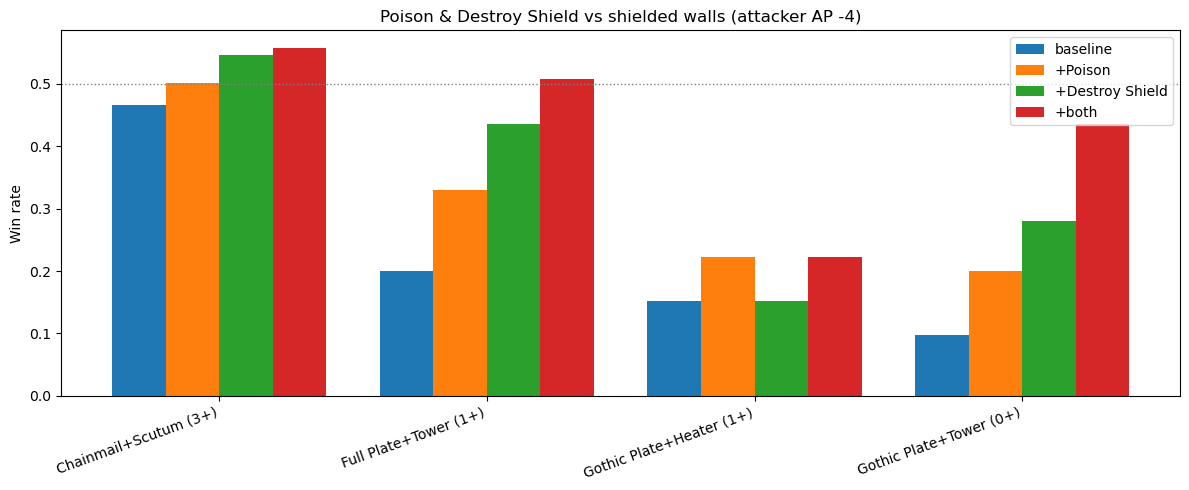


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\poison_destroyshield_vs_walls.png


In [106]:
# ──────────────────────────────────────────────────────────────────────────────
# Poison & Destroy Shield vs armor+shield walls (incl. the save-0+ Gothic+Tower wall)
# ──────────────────────────────────────────────────────────────────────────────
# Raw AP saturates and can't crack the heaviest shielded walls (save <2 = auto-pass).
# Two keywords bypass that:
#   - Poison: fails the defender's save on a natural 6 — works even vs auto-pass (save <2).
#   - Destroy Shield: removes the shield mid-fight, collapsing the wall to bare armor.
# We measure a baseline attacker vs each wall, then the same attacker with Poison, with
# Destroy Shield, and with both.

import numpy as np, pandas as pd, random
import importlib, loadouts, renown_combat, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(renown_combat); importlib.reload(vectorized_combat); importlib.reload(playstyles)
vectorized_combat.invalidate_tactic_tables()
from loadouts import Loadout

SIZE = 25
def mk(weapon, shield, armor='Chainmail', extra=None, playstyle='Aggressor'):
    return Loadout(name=f"{weapon}/{shield}/{armor}", retinue='Man-at-Arms', weapon=weapon, shield=shield,
                   armor=armor, ranged=None, has_tiltyard=False, size=SIZE,
                   extra_tags=extra or ['Cond Field'], upkeep_per_retinue=30, playstyle=playstyle,
                   tiltyard_mastery=False, pursuits=frozenset(['Conditioning Field']),
                   military_pursuit_count=5, domain_count=0)

def winrate(a, b, n=400, seed=11):
    a = a._replace(playstyle=playstyles.assign_default_playstyle(a)) if a.playstyle is None else a
    b = b._replace(playstyle=playstyles.assign_default_playstyle(b)) if b.playstyle is None else b
    r = vectorized_combat.run_matchup_vec(a, b, n_runs=n, seed=seed, max_skirmishes=20)
    t = r['a_wins']+r['b_wins']+r['mut_wipe']+r['indecisive']
    return (r['a_wins']/t if t else np.nan)

def eff_save(armor, shield):
    s = renown_combat.ARMORS[armor]['save']
    sb = renown_combat.SHIELDS[shield]['save_bonus'] if shield else 0
    return s - sb

# Shielded walls, weakest → toughest, INCLUDING Gothic+Tower (save 0+).
WALLS = [
    ("Chainmail",    "Scutum Shield"),
    ("Full Plate",   "Tower Shield"),
    ("Gothic Plate", "Heater Shield"),
    ("Gothic Plate", "Tower Shield"),   # save 0+ — the AP-proof wall
]
wall_labels = [f"{a}+{s.split()[0]} ({eff_save(a,s)}+)" for a, s in WALLS]

print("Walls under test (effective save):")
for (a, s), lab in zip(WALLS, wall_labels):
    print(f"  {lab}")

# Attacker: Arming Sword at a fixed strong AP (-4) so we isolate the keyword effect, not AP.
renown_combat.WEAPONS['Arming Sword']['ap'] = -4  # temp, restored at end
ATK_AP_NOTE = "Arming Sword @ AP -4 (fixed)"
orig_ap = -2  # actual original

print(f"\n=== {ATK_AP_NOTE}: baseline vs Poison vs Destroy Shield vs both ===")
variants = {
    "baseline":        ['Cond Field'],
    "+Poison":         ['Cond Field', 'Poison'],
    "+Destroy Shield": ['Cond Field', 'Destroy Shield'],
    "+both":           ['Cond Field', 'Poison', 'Destroy Shield'],
}
rows = []
for (arm, sh), lab in zip(WALLS, wall_labels):
    row = {"wall": lab}
    for vname, tags in variants.items():
        atk = mk('Arming Sword', 'Scutum Shield', armor='Chainmail', extra=tags)
        defn = mk('Arming Sword', sh, armor=arm)
        row[vname] = round(winrate(atk, defn, n=500, seed=77), 3)
    rows.append(row)
renown_combat.WEAPONS['Arming Sword']['ap'] = orig_ap
df = pd.DataFrame(rows)
print(df.to_string(index=False))
print("\n+Poison: bypasses save on 6s (works even vs save-0+ auto-pass).")
print("+Destroy Shield: collapses the shield, dropping the wall to bare armor.")

# Plot grouped bars
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(WALLS)); w = 0.2
for i, vname in enumerate(variants):
    ax.bar(x + (i-1.5)*w, df[vname], w, label=vname)
ax.set_xticks(x); ax.set_xticklabels(wall_labels, rotation=20, ha="right")
ax.set_ylabel("Win rate"); ax.set_title("Poison & Destroy Shield vs shielded walls (attacker AP -4)")
ax.axhline(0.5, color="gray", ls=":", lw=1); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "poison_destroyshield_vs_walls.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'poison_destroyshield_vs_walls.png')}")

Base loadouts under test: 48

=== MW (AP-1)  vs  MWRend (Rend)  (same loadouts, same field) ===
       weapon        retinue        armor  wr_MW (AP-1)  wr_MWRend (Rend)  delta_B_minus_A
         Pike       Sergeant   Full Plate         0.613             0.665            0.051
      Longbow       Sergeant        Cloth         0.544             0.592            0.048
       Spears    Man-at-Arms        Cloth         0.353             0.401            0.048
Bastard Sword    Man-at-Arms    Chainmail         0.720             0.764            0.044
  Morningstar       Sergeant    Chainmail         0.444             0.487            0.043
    2HBastard Knight Templar    Chainmail         0.472             0.513            0.042
         Pike Knight Templar        Cloth         0.516             0.558            0.041
      Longbow    Man-at-Arms        Cloth         0.507             0.547            0.040
 Arming Sword       Sergeant   Full Plate         0.658             0.695            

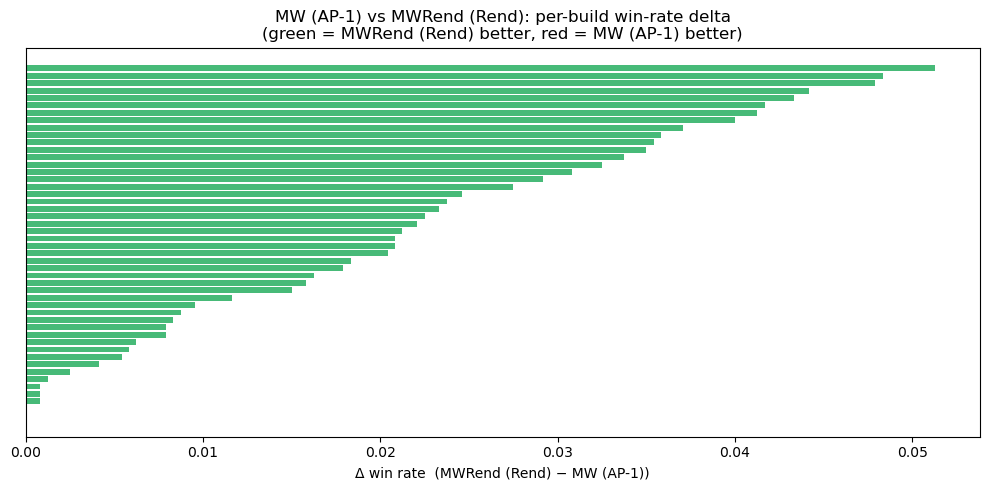


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\pursuit_ab_test.png


In [107]:
# ──────────────────────────────────────────────────────────────────────────────
# Pursuit A/B testing — compare two specific pursuits head-to-head
# ──────────────────────────────────────────────────────────────────────────────
# For a set of base loadouts, builds two variants: one with pursuit A's tag(s), one with
# pursuit B's tag(s), holding everything else fixed. Runs both vs a shared field and reports
# the win-rate delta. Use to answer "Rend vs no-Rend?", "Preceptory (Steadfast) vs Royal
# Pavilion (Drilled+Nimble)?", "Cond Field vs none?", etc. NOTE: -1 AP is retired; Master
# Workshop / ABF grant Rend. Ministry innate = Seize: first; mastery = MaxInit3 + MinInit+1.

import numpy as np, pandas as pd, random
import importlib, loadouts, renown_combat, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(renown_combat); importlib.reload(vectorized_combat); importlib.reload(playstyles)
vectorized_combat.invalidate_tactic_tables()

pool = MAIN_POOL   # reuse the main tournament pool (no regeneration)
random.seed(2026)

# ── CONFIGURE THE A/B HERE ──
# Each side is (label, set_of_tags_to_ADD, set_of_tags_to_REMOVE). The harness clones a base
# loadout, strips the REMOVE tags, adds the ADD tags, reassigns playstyle, and runs it.
# Examples below — uncomment/edit the pair you want to test.

AB_PAIRS = {
    # "Master Workshop (AP-1)" vs "MWRend (Rend)"
    "MW (AP-1)":  {"add": {"MW Weapons"}, "remove": {"Rend"}},
    "MWRend (Rend)": {"add": {"Rend"},      "remove": {"MW Weapons"}},
}
# Other ready-to-use pairs (swap into AB_PAIRS):
#   Preceptory vs Royal Pavilion:
#     "Preceptory (Steadfast)": {"add": {"Steadfast"}, "remove": {"Drilled","Nimble","Immune Strain"}},
#     "Royal Pavilion (D/N/IS)": {"add": {"Drilled","Nimble","Immune Strain"}, "remove": {"Steadfast"}},
#   Ministry seize-first vs seize-every:
#     "Seize: first": {"add": {"Seize: first"}, "remove": {"Seize: every"}},
#     "Seize: every": {"add": {"Seize: every"}, "remove": {"Seize: first"}},
#   GF Armor on vs off:
#     "with GF Armor": {"add": {"GF Armor"}, "remove": set()},
#     "no GF Armor":   {"add": set(),        "remove": {"GF Armor"}},

# Restrict base loadouts to ones where the comparison is meaningful (e.g. only builds that
# could plausibly carry either pursuit). Default: a stratified sample of the whole pool.
def base_candidates():
    # exclude loadouts that already hard-commit to one side's tags in a way that makes the
    # swap incoherent; here we just take a broad sample across retinues.
    from collections import defaultdict
    by_ret = defaultdict(list)
    for ld in pool: by_ret[ld.retinue].append(ld)
    out = []
    for ret, lds in by_ret.items():
        out.extend(random.sample(lds, min(len(lds), 12)))
    return out

bases = base_candidates()
print(f"Base loadouts under test: {len(bases)}")

# Fixed reference field
field = [ld._replace(playstyle=playstyles.assign_default_playstyle(ld))
         for ld in random.sample(pool, 40)]

def make_variant(ld, add_tags, remove_tags):
    tags = [t for t in ld.extra_tags if t not in remove_tags]
    for t in add_tags:
        if t not in tags: tags.append(t)
    v = ld._replace(extra_tags=tags)
    return v._replace(playstyle=playstyles.assign_default_playstyle(v))

def field_wr(ld, n=60):
    w = t = 0
    for i, opp in enumerate(field):
        if opp.name == ld.name: continue
        r = vectorized_combat.run_matchup_vec(ld, opp, n_runs=n, seed=400+i,
                                              a_playstyle=ld.playstyle, b_playstyle=opp.playstyle)
        w += r['a_wins']; t += r['a_wins']+r['b_wins']+r['mut_wipe']+r['indecisive']
    return w/t if t else np.nan

labels = list(AB_PAIRS.keys())
assert len(labels) == 2, "AB_PAIRS must have exactly two entries"
A, B = labels

rows = []
for ld in bases:
    va = make_variant(ld, AB_PAIRS[A]["add"], AB_PAIRS[A]["remove"])
    vb = make_variant(ld, AB_PAIRS[B]["add"], AB_PAIRS[B]["remove"])
    wr_a = field_wr(va); wr_b = field_wr(vb)
    rows.append({"weapon": ld.weapon or ld.ranged, "retinue": ld.retinue,
                 "armor": ld.armor, f"wr_{A}": wr_a, f"wr_{B}": wr_b,
                 "delta_B_minus_A": wr_b - wr_a})
df = pd.DataFrame(rows)

print(f"\n=== {A}  vs  {B}  (same loadouts, same field) ===")
print(df.sort_values("delta_B_minus_A", ascending=False).round(3).to_string(index=False))
print(f"\nMean:  {A}={df[f'wr_{A}'].mean():.3f}   {B}={df[f'wr_{B}'].mean():.3f}   Δ(B−A)={df['delta_B_minus_A'].mean():+.4f}")
print(f"{B} better in {(df['delta_B_minus_A']>0.005).sum()}/{len(df)} builds; "
      f"{A} better in {(df['delta_B_minus_A']<-0.005).sum()}/{len(df)}")

# Per-retinue and per-weapon breakdown (where does each pursuit win?)
print(f"\n=== Δ(B−A) by retinue ===")
print(df.groupby("retinue")["delta_B_minus_A"].agg(["mean","count"]).round(4).to_string())
print(f"\n=== Δ(B−A) by weapon (top/bottom 5) ===")
byw = df.groupby("weapon")["delta_B_minus_A"].mean().sort_values()
print(pd.concat([byw.head(5), byw.tail(5)]).round(4).to_string())

# Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ds = df.sort_values("delta_B_minus_A")
colors = ["#27ae60" if d > 0 else "#c0392b" for d in ds["delta_B_minus_A"]]
ax.barh(range(len(ds)), ds["delta_B_minus_A"], color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=0.5)
ax.set_yticks([]); ax.set_xlabel(f"Δ win rate  ({B} − {A})")
ax.set_title(f"{A} vs {B}: per-build win-rate delta\n(green = {B} better, red = {A} better)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pursuit_ab_test.png"), dpi=110, bbox_inches="tight"); plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'pursuit_ab_test.png')}")

=== Monument delta WR (Forged+Full Plate baseline, size 25) ===
Monument                                               Sgt ΔWR   MaA ΔWR
  ABF monument (Crafted equipment) +0.2149 +0.1410
  Royal Pavilion (Drilled/Nimble/ImmStrain) +0.1418 +0.1279
  Ministry mastery (Seize: every) +0.0919 +0.0613
  Preceptory mastery (KT)   +0.0839 +0.1217
  Outrider mastery (first_two) +0.0596 +0.0532
  Preceptory innate (Unshakable) +0.0545 +0.0487
  Ministry innate (Seize: first) +0.0123 +0.0061


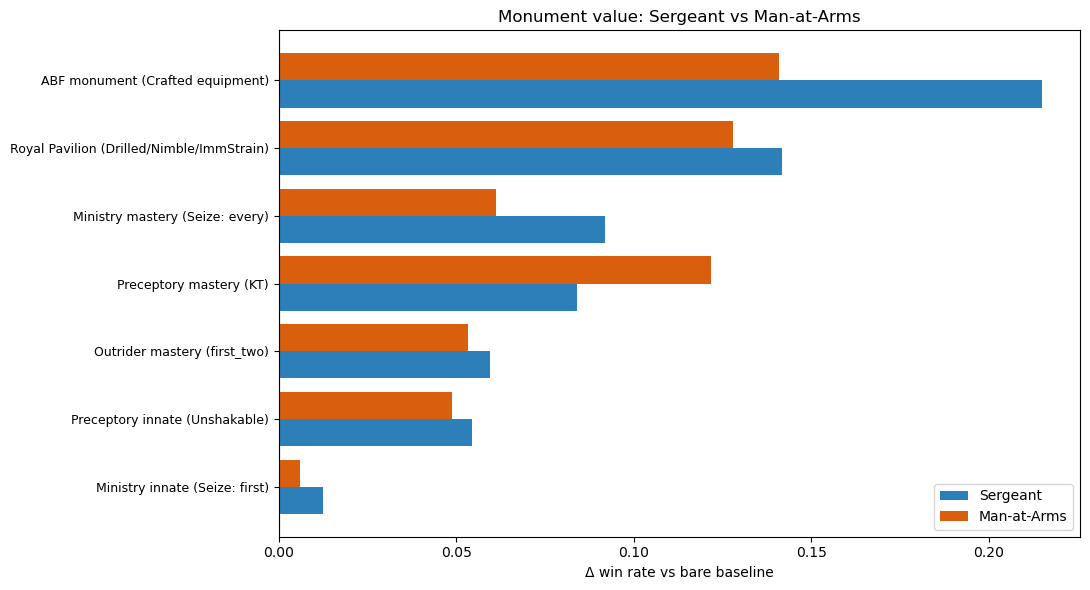

In [108]:
# === Monument comparison: Sergeant vs Man-at-Arms delta win rate ===
# Each monument's effect added to a controlled baseline (Forged weapon / Full Plate / size 25),
# measured as Δ win rate vs that same retinue's bare baseline, across a fixed opponent field.
# Two columns: how much the monument is worth on a Sergeant vs on a Man-at-Arms.
import importlib, renown_combat, loadouts, playstyles, vectorized_combat
import numpy as np, random, matplotlib.pyplot as plt
for _m in [renown_combat, loadouts, playstyles, vectorized_combat]: importlib.reload(_m)
vectorized_combat.invalidate_tactic_tables()
from loadouts import Loadout

N_RUNS = 100
pool = MAIN_POOL   # reuse the main tournament pool (no regeneration)
random.seed(7)
field = [ld._replace(playstyle=playstyles.assign_default_playstyle(ld)) for ld in random.sample(pool, 40)]

def fwr(ld, n=N_RUNS):
    w = t = 0
    for i, opp in enumerate(field):
        if opp.name == ld.name: continue
        r = vectorized_combat.run_matchup_vec(ld, opp, n_runs=n, seed=300+i,
                a_playstyle=ld.playstyle, b_playstyle=opp.playstyle)
        w += r["a_wins"]; t += r["a_wins"]+r["b_wins"]+r["mut_wipe"]+r["indecisive"]
    return w/t if t else float("nan")

def mk(weap, sh, ret, tags=None, arm="Full Plate"):
    b = Loadout(name=f"{ret}/{weap}", retinue=ret, weapon=weap, shield=sh, armor=arm,
        ranged=None, has_tiltyard=False, size=25, extra_tags=(tags or [])+["Cond Field"],
        upkeep_per_retinue=30, playstyle="Aggressor", tiltyard_mastery=False,
        pursuits=frozenset(["Coliseum"]), military_pursuit_count=5, domain_count=0)
    return b._replace(playstyle=playstyles.assign_default_playstyle(b))

FORGED = [("Halberd",None),("Bastard Sword","Tower Shield"),("Lance","Scutum Shield"),("War Hammer",None),
          ("Battle Axe",None),("Flail","Tower Shield"),("Morningstar","Tower Shield"),("2HBastard",None)]

# Monument effects. "KT" = retinue swap to Knight Templar (Preceptory mastery: unlocks KT +
# grants Steadfast on top of the innate Unshakable). Royal Pavilion's Immune Strain auto-grants
# +1 endurance in the engine, so no manual endurance override is needed here.
EFFECTS = {
    "Preceptory innate (Unshakable)":                    ["Unshakable"],
    "Preceptory mastery (KT)":             "KT",
    "Royal Pavilion (Drilled/Nimble/ImmStrain)":   ["Drilled","Nimble","Immune Strain"],
    "Outrider mastery (first_two)":                      ["Outrider: first_two"],
    "Ministry innate (Seize: first)":                    ["Seize: first"],
    "Ministry mastery (Seize: every)":                   ["Seize: every"],
}
# ABF: tier-unlock value = best Crafted build vs Forged+Full Plate baseline (same retinue).
ABF_PAIRS = [
    (("War Hammer","Full Plate",None),     ("Poleaxe","Gothic Plate",None)),
    (("Bastard Sword","Full Plate","Tower Shield"),  ("Bastard Sword","Gothic Plate","Heater Shield")),
    (("2HBastard","Full Plate",None),        ("Poleaxe","Gothic Plate",None)),
    (("Lance","Full Plate","Scutum Shield"),          ("Bastard Sword","Gothic Plate","Heater Shield")),
]

def col(ret):
    out = {}
    for weap, sh in FORGED:
        bw = fwr(mk(weap, sh, ret))
        for name, spec in EFFECTS.items():
            if spec == "KT":
                v = fwr(mk(weap, sh, "Knight Templar", tags=["Steadfast"])) - bw
            else:
                v = fwr(mk(weap, sh, ret, tags=spec)) - bw
            out.setdefault(name, []).append(v)
    abf = []
    for (fw, fa, fs), (cw, ca, cs) in ABF_PAIRS:
        abf.append(fwr(mk(cw, cs, ret, arm=ca)) - fwr(mk(fw, fs, ret, arm=fa)))
    out["ABF monument (Crafted equipment)"] = abf
    return {k: np.mean(v) for k, v in out.items()}

sgt = col("Sergeant")
maa = col("Man-at-Arms")
order = sorted(sgt, key=lambda k: -sgt[k])

print("=== Monument delta WR (Forged+Full Plate baseline, size 25) ===")
print(f"{'Monument':52} {'Sgt ΔWR':>9} {'MaA ΔWR':>9}")
for k in order:
    print(f"  {k:25} {sgt[k]:+.4f} {maa[k]:+.4f}")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(order)); h = 0.4
ax.barh(y+h/2, [sgt[k] for k in order], h, label="Sergeant", color="#2c7fb8")
ax.barh(y-h/2, [maa[k] for k in order], h, label="Man-at-Arms", color="#d95f0e")
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=9)
ax.invert_yaxis(); ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("Δ win rate vs bare baseline"); ax.legend()
ax.set_title("Monument value: Sergeant vs Man-at-Arms")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "monument_sgt_vs_maa.png"), dpi=110, bbox_inches="tight"); plt.show()

# 10. Retinue-vs-Retinue Matrices

A x B retinue matrices (A = attacker/initiator slot) for kills, shakes, skirmish length,
rout kills, win rate, and mutual-wipe rate. Reads `df_main_matchups`.


=== A win rate (A=row retinue vs B=col retinue) ===
b_retinue        Levy  Man-at-Arms  Sergeant  Knight Templar
a_retinue                                                   
Levy            0.354        0.185     0.157           0.023
Man-at-Arms     0.661        0.450     0.394           0.183
Sergeant        0.703        0.534     0.474           0.297
Knight Templar  0.923        0.663     0.611             NaN

=== Mutual-wipe rate ===
b_retinue        Levy  Man-at-Arms  Sergeant  Knight Templar
a_retinue                                                   
Levy            0.257        0.129     0.121           0.017
Man-at-Arms     0.125        0.092     0.073           0.145
Sergeant        0.116        0.072     0.060           0.093
Knight Templar  0.016        0.140     0.090             NaN

=== Indecisive rate ===
b_retinue        Levy  Man-at-Arms  Sergeant  Knight Templar
a_retinue                                                   
Levy            0.042        0.036     0.0

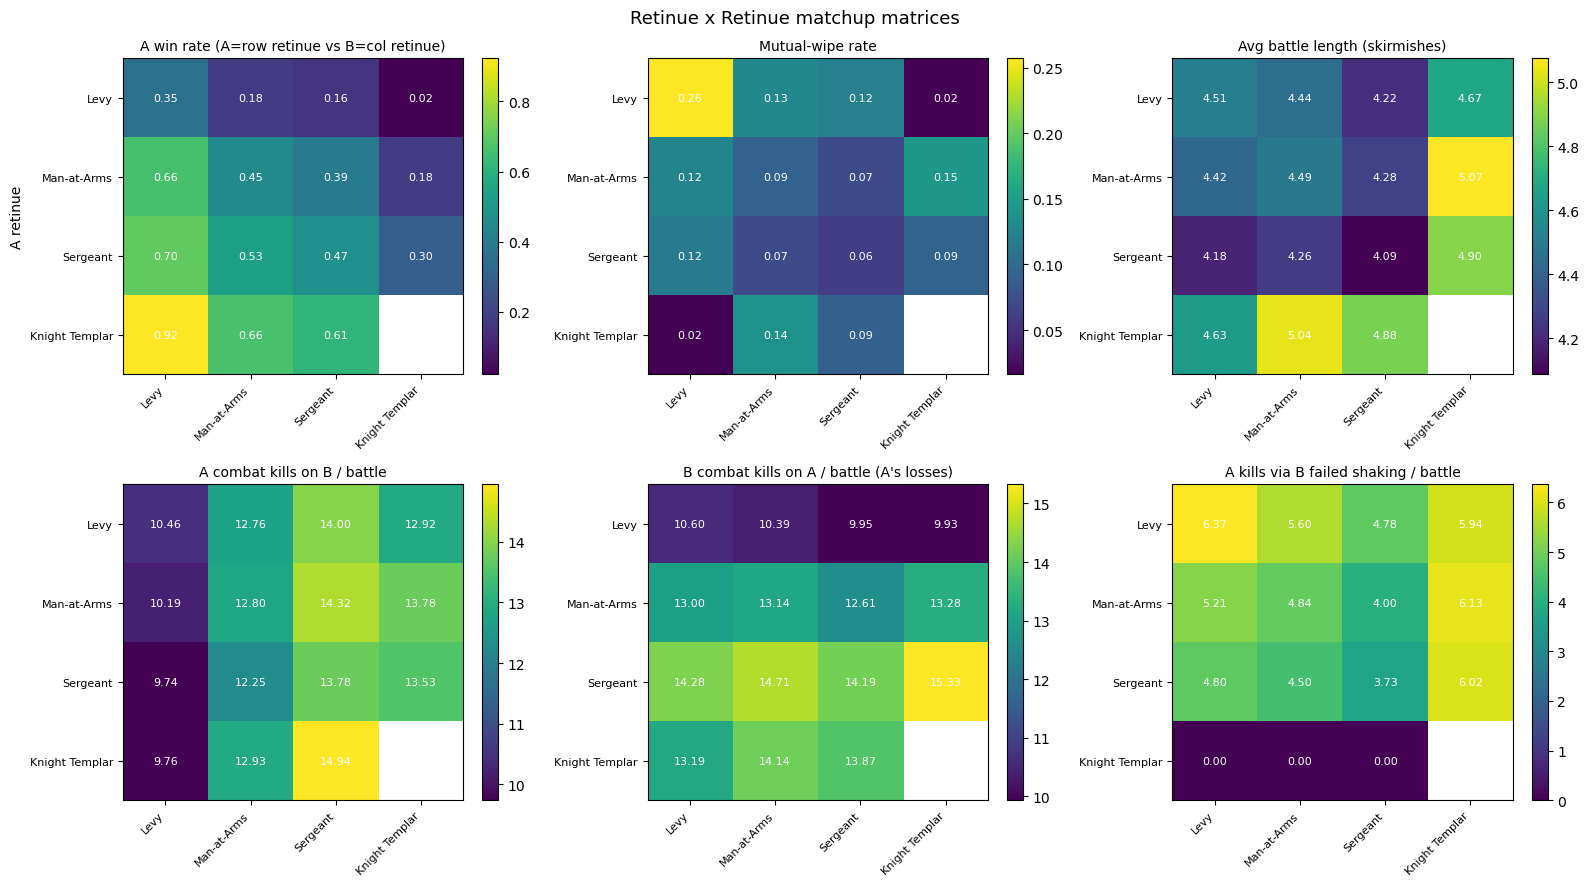

In [109]:
# Retinue matchup matrices — kills / shakes / skirmish length / rout / win rate
mats = analysis.retinue_matchup_matrices(df_main_matchups)

_titles = {
    "a_win_rate":       "A win rate (A=row retinue vs B=col retinue)",
    "mut_wipe_rate":    "Mutual-wipe rate",
    "indecisive_rate":  "Indecisive rate",
    "avg_skirm":        "Avg battle length (skirmishes)",
    "a_kills_combat":   "A combat kills on B / battle",
    "b_kills_combat":   "B combat kills on A / battle (A's losses)",
    "a_kills_shake":    "A kills via B failed shaking / battle",
    "a_rout_kills":     "A kills when B routs / battle",
    "b_rout_kills":     "B kills when A routs / battle",
    "a_shield_destroyed": "A shield-destroyed rate",
    "n_battles":        "N battles (sample weight)",
}
for key, title in _titles.items():
    print(f"\n=== {title} ===")
    print(mats[key].round(3).to_string())

# Heatmap grid of the headline matrices
import matplotlib.pyplot as plt
_show = ["a_win_rate","mut_wipe_rate","avg_skirm","a_kills_combat","b_kills_combat","a_kills_shake"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, key in zip(axes.flat, _show):
    M = mats[key]
    im = ax.imshow(M.values.astype(float), cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(M.columns))); ax.set_xticklabels(M.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(M.index))); ax.set_yticklabels(M.index, fontsize=8)
    ax.set_title(_titles[key], fontsize=10)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            if v == v:  # not NaN
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="w", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
axes.flat[0].set_ylabel("A retinue"); 
plt.suptitle("Retinue x Retinue matchup matrices", fontsize=13)
plt.tight_layout(); plt.show()

# 11. Strongest Performers by MPC

Top builds within each Military Pursuit Count bucket, plus a per-MPC rollup. Reads
`df_main_summary` (one row per build).

=== Per-MPC rollup ===
 military_pursuit_count  n_builds  mean_wr  median_wr  max_wr                                                                                                                       best_build   best_retinue
                      2        66    0.063      0.039   0.366                                                                                  Sgt/2HBastard/Cloth [(EInd, EProw, NPie, NCun)]       Sergeant
                      3       314    0.164      0.137   0.648                                                                        Sgt/2HBastard/FullPlate [(EInd, EProw, NPie, NCun), Temp]       Sergeant
                      4       341    0.273      0.270   0.724                                                              KT/2HBastard/Cloth [PrM, (EInd, EProw, SPie, NCun), Rec 5, Shake+1] Knight Templar
                      5       370    0.349      0.327   0.814                                                    KT/BattleAxe/FullPlate [PrM, (EInd, EPro

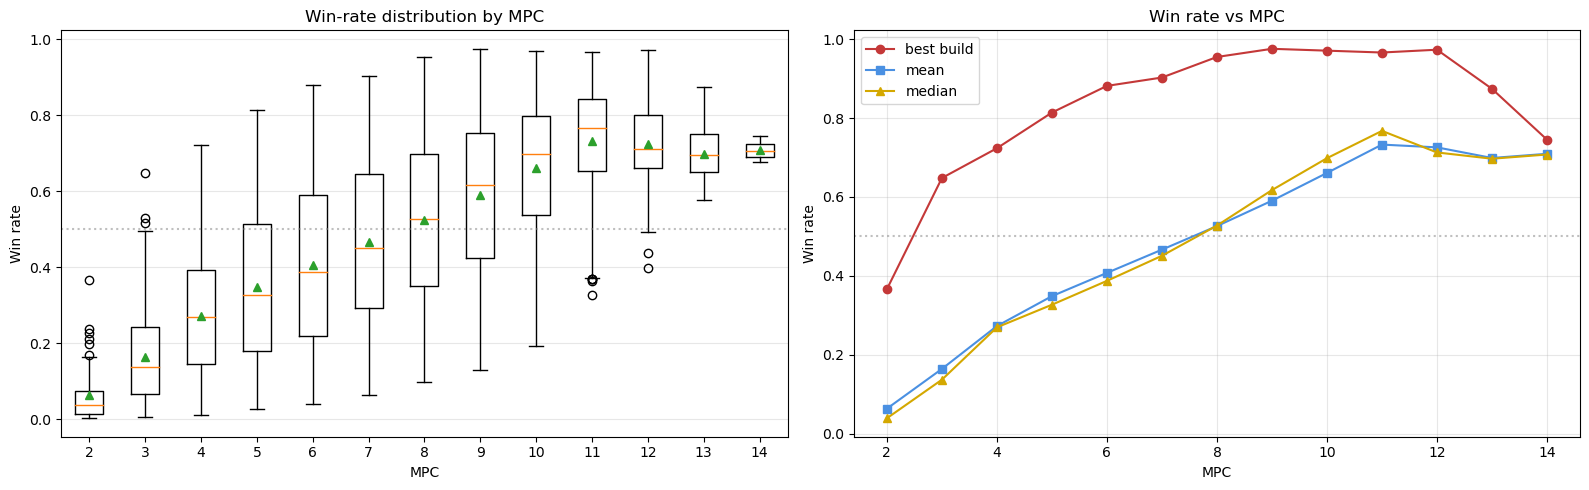

In [110]:
# Top performers within each MPC bucket
TOP_N_PER_MPC = 8
top_mpc = analysis.top_performers_by_mpc(df_main_summary, top_n=TOP_N_PER_MPC, metric="win_rate")

print("=== Per-MPC rollup ===")
mpc_tbl = analysis.mpc_summary_table(df_main_summary)
print(mpc_tbl.round(3).to_string(index=False))

print(f"\n=== Top {TOP_N_PER_MPC} builds per MPC ===")
for mpc, g in top_mpc.groupby("military_pursuit_count"):
    print(f"\n--- MPC {mpc} ---")
    print(g[["mpc_rank","name","retinue","win_rate","decisive_win_rate"]].to_string(index=False)
          if "decisive_win_rate" in g.columns
          else g[["mpc_rank","name","retinue","win_rate"]].to_string(index=False))

# Plot: win-rate distribution per MPC (box) + best build trend
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
mpcs = sorted(df_main_summary["military_pursuit_count"].unique())
data = [df_main_summary[df_main_summary["military_pursuit_count"]==m]["win_rate"].values for m in mpcs]
try:
    ax.boxplot(data, tick_labels=mpcs, showmeans=True)   # matplotlib >= 3.9
except TypeError:
    ax.boxplot(data, labels=mpcs, showmeans=True)         # older matplotlib
ax.axhline(0.5, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("MPC"); ax.set_ylabel("Win rate"); ax.set_title("Win-rate distribution by MPC")
ax.grid(alpha=0.3, axis="y")
ax = axes[1]
ax.plot(mpc_tbl["military_pursuit_count"], mpc_tbl["max_wr"], "o-", label="best build", color="#c43838")
ax.plot(mpc_tbl["military_pursuit_count"], mpc_tbl["mean_wr"], "s-", label="mean", color="#4a90e2")
ax.plot(mpc_tbl["military_pursuit_count"], mpc_tbl["median_wr"], "^-", label="median", color="#d4a800")
ax.axhline(0.5, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("MPC"); ax.set_ylabel("Win rate"); ax.set_title("Win rate vs MPC")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 12. Confound-Reduced Views

`analysis.filter_confounds` controls for the main confounds: mutual-wipe inflation,
identical-gear mirror matchups, and unequal MPC. Compare raw vs filtered retinue win rates.

In [111]:
# Confound filtering: compare raw vs controlled retinue win rates
# 1) Decisive-only + mirror-gear excluded: removes mutual-wipe washout (the Sgt-vs-MaA case)
df_decisive = analysis.filter_confounds(df_main_matchups, decisive_only=True, exclude_mirror_gear=True)

def _retinue_wr(d, col):
    g = d.groupby("a_retinue").apply(
        lambda x: (x[col] * x["n_runs"].clip(lower=1)).sum() / x["n_runs"].clip(lower=1).sum())
    return g.reindex(analysis.RETINUE_ORDER)

raw   = _retinue_wr(df_main_matchups, "a_win_rate")
dec   = _retinue_wr(df_decisive, "a_win_rate_decisive")
cmp = pd.DataFrame({"raw_win_rate": raw, "decisive_only_win_rate": dec})
cmp["delta"] = cmp["decisive_only_win_rate"] - cmp["raw_win_rate"]
print("=== Retinue win rate: raw vs decisive-only (mirror gear excluded) ===")
print(cmp.round(3).to_string())

# 2) Same-MPC only: control for military investment
df_sameMPC = analysis.filter_confounds(df_main_matchups, same_mpc=True, mpc_tolerance=0)
print(f"\nSame-MPC filter: {len(df_main_matchups)} -> {len(df_sameMPC)} rows (|a_mpc - b_mpc| == 0)")
if len(df_sameMPC):
    same = _retinue_wr(df_sameMPC, "a_win_rate")
    print("Retinue win rate, same-MPC matchups only:")
    print(same.round(3).to_string())

# 3) High-decisiveness only: drop stalematey matchups
df_decisiveOnly = analysis.filter_confounds(df_main_matchups, min_decisive_rate=0.5)
print(f"\nDecisive-rate >= 0.5 filter: {len(df_main_matchups)} -> {len(df_decisiveOnly)} rows")

=== Retinue win rate: raw vs decisive-only (mirror gear excluded) ===
                raw_win_rate  decisive_only_win_rate  delta
a_retinue                                                  
Levy                   0.201                   0.282  0.081
Man-at-Arms            0.465                   0.535  0.070
Sergeant               0.544                   0.601  0.057
Knight Templar         0.737                   0.799  0.062

Same-MPC filter: 9313192 -> 914666 rows (|a_mpc - b_mpc| == 0)
Retinue win rate, same-MPC matchups only:
a_retinue
Levy              0.195
Man-at-Arms       0.440
Sergeant          0.551
Knight Templar    0.696

Decisive-rate >= 0.5 filter: 9313192 -> 8921323 rows


# 13. The Story of a Battle — High-Level View

Battle-as-the-unit overview: win / loss / mutual / indecisive rates, survivor counts, the kill mix (combat vs failed-morale vs rout), and how the underlying combat stats (to-hit, initiative, save, endurance) correlate with winning. Reads `df_main_matchups`, `df_main_summary`, `MAIN_POOL`.

  THE STORY OF A BATTLE  —  465,659,600 battles

A typical engagement runs about 4.4 skirmishes. When the dust settles,
86% of battles have a clear winner; the attacker takes
44% and the defender 42% — close to
even, so the initiator slot is not a strong edge. 11% of battles end
in MUTUAL annihilation, and only 3.0% peter out indecisively.

The two sides leave roughly 6 and 6
survivors on average. Of every casualty inflicted, 65% fall in direct
combat, 23% break from exhaustion (shaken), 7% break
under heavy losses (waver), and 5% are cut down in the rout. Shields are destroyed in
1.9% of battles.

WHAT WINS BATTLES (correlation of each combat stat with win rate):
   shaking     -0.62  ##################             (lower is better)
   to_hit      -0.50  ###############                (lower is better)
   eff_save    -0.22  ######                         (lower is better)
   weapon_ap   -0.16  ####                           (lower is better)
   init        -0.04  #                    

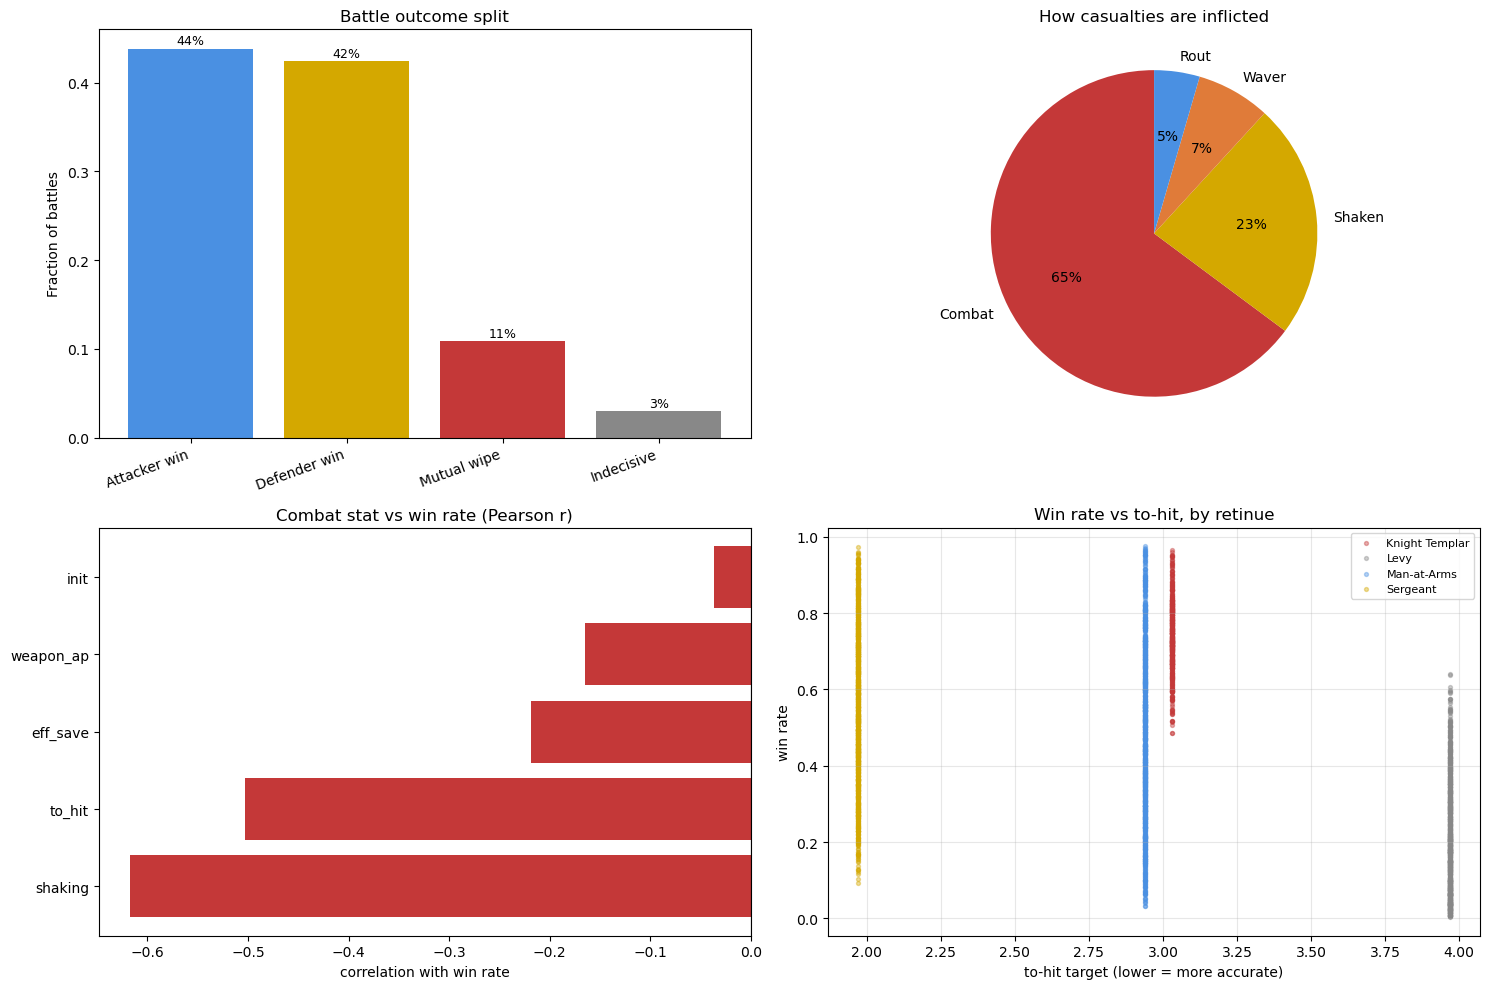

In [112]:
# ── Battle overview + combat-stat correlations + narrative ──
import matplotlib.pyplot as plt
import analysis
import loadouts as L, playstyles, analysis

# reload the EXACT pool the tournament ran on, from its saved CSV companion
MAIN_POOL = L.archetype_pool(csv_path=LOADOUT_CSV)  # match your run's tag
# if the tournament assigned playstyles, re-apply the same default so names/state match:
MAIN_POOL = [p._replace(playstyle=playstyles.assign_default_playstyle(p)) for p in MAIN_POOL]
ov   = analysis.battle_overview(df_main_matchups)
st   = analysis.build_stat_table(MAIN_POOL)
m, corr = analysis.stat_winrate_correlation(df_main_summary, st)

pop = {"avg_to_hit": st["to_hit"].mean(), "avg_init": st["init"].mean(),
       "avg_eff_save": st["eff_save"].mean(), "avg_endurance": st["endurance"].mean()}

print("=" * 68)
print("  THE STORY OF A BATTLE  —  {:,} battles".format(ov["total_battles"]))
print("=" * 68)
print(f"""
A typical engagement runs about {ov['avg_skirmishes']:.1f} skirmishes. When the dust settles,
{ov['decisive_rate']*100:.0f}% of battles have a clear winner; the attacker takes
{ov['attacker_win_rate']*100:.0f}% and the defender {ov['defender_win_rate']*100:.0f}% — close to
even, so the initiator slot is not a strong edge. {ov['mutual_wipe_rate']*100:.0f}% of battles end
in MUTUAL annihilation, and only {ov['indecisive_rate']*100:.1f}% peter out indecisively.

The two sides leave roughly {ov['avg_attacker_survivors']:.0f} and {ov['avg_defender_survivors']:.0f}
survivors on average. Of every casualty inflicted, {ov['kill_mix_combat_pct']*100:.0f}% fall in direct
combat, {ov['kill_mix_shake_pct']*100:.0f}% break from exhaustion (shaken), {ov['kill_mix_waver_pct']*100:.0f}% break
under heavy losses (waver), and {ov['kill_mix_rout_pct']*100:.0f}% are cut down in the rout. Shields are destroyed in
{ov['avg_shield_destroyed_rate']*100:.1f}% of battles.

WHAT WINS BATTLES (correlation of each combat stat with win rate):""")
for _, r in corr.iterrows():
    s = r["stat"]; c = r["corr_with_win_rate"]
    better = "lower is better" if s in ("to_hit","eff_save","shaking","weapon_ap") else "higher is better"
    print(f"   {s:11s} {c:+.2f}  {'#'*int(abs(c)*30):30s} ({better})")
print(f"""
Innate ACCURACY (to-hit) and MORALE (shaking) dominate — they outweigh weapon AP and initiative.
Endurance is the strongest positive driver. Population averages: to-hit {pop['avg_to_hit']:.1f},
initiative {pop['avg_init']:+.1f}, effective save {pop['avg_eff_save']:.1f}, endurance {pop['avg_endurance']:.1f}.
""")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax = axes[0,0]
labels = ["Attacker win","Defender win","Mutual wipe","Indecisive"]
vals = [ov["attacker_win_rate"], ov["defender_win_rate"], ov["mutual_wipe_rate"], ov["indecisive_rate"]]
ax.bar(labels, vals, color=["#4a90e2","#d4a800","#c43838","#888"])
ax.set_title("Battle outcome split"); ax.set_ylabel("Fraction of battles")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=20, ha="right")
for i,v in enumerate(vals): ax.text(i, v+0.005, f"{v*100:.0f}%", ha="center", fontsize=9)
ax = axes[0,1]
mix = [ov["kill_mix_combat_pct"], ov["kill_mix_shake_pct"], ov.get("kill_mix_waver_pct",0.0), ov["kill_mix_rout_pct"]]
ax.pie(mix, labels=["Combat","Shaken","Waver","Rout"], autopct="%1.0f%%",
       colors=["#c43838","#d4a800","#e07b39","#4a90e2"], startangle=90)
ax.set_title("How casualties are inflicted")
ax = axes[1,0]
cc = corr.sort_values("corr_with_win_rate")
ax.barh(cc["stat"], cc["corr_with_win_rate"], color=["#c43838" if v<0 else "#4a90e2" for v in cc["corr_with_win_rate"]])
ax.axvline(0, color="k", lw=0.8); ax.set_title("Combat stat vs win rate (Pearson r)")
ax.set_xlabel("correlation with win rate")
ax = axes[1,1]
ret_colors={"Levy":"#888","Man-at-Arms":"#4a90e2","Sergeant":"#d4a800","Knight Templar":"#c43838"}
for ret,grp in m.groupby("retinue"):
    ax.scatter(grp["to_hit"]+(hash(ret)%5-2)*0.03, grp["win_rate"], s=8, alpha=0.4, label=ret, color=ret_colors.get(ret,"#555"))
ax.set_xlabel("to-hit target (lower = more accurate)"); ax.set_ylabel("win rate")
ax.set_title("Win rate vs to-hit, by retinue"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [113]:
sn = set(df_main_summary["name"]); pn = {l.name for l in MAIN_POOL}
print(len(sn), len(pn), len(sn & pn))
print(list(sn - pn)[:3])   # summary names with no pool match
print(list(pn - sn)[:3])   # pool names with no summary match

3457 35712 3457
[]
['MaA/Morningstar+Crossbow/Cloth (TY) [OuInPoM, (EInd, EProw, NPie, SCun), ImmU]', 'Sgt/Flail/Chain (DW) [MiMiStM, (RInd, SProw, NPie, RCun), DW, ImmU, Poison]', 'MaA/Bastard/Tower/FullPlate [(EInd, EProw, EPie, NCun), Improved Parry, Temp, Serr, Shake+1]']


In [114]:
# ── Top decisive-win-rate loadouts by monument count ──────────────────────────
# Monuments are PURSUITS (not tags), so they don't appear in the build name — they
# live in the a_pursuits column. This ranks builds by win rate within 1- and 2-monument tiers.
import numpy as np, pandas as pd

MONUMENTS = {"ABF", "Royal Pavilion", "Preceptory",
             "Ministry of Military Strategy", "Outrider Intercept Post"}
TOP_N = 12   # how many to list per tier

df = df_main_matchups.copy()
den = (df["a_wins"] + df["b_wins"] + df["mut_wipe"] + df["indecisive"]).replace(0, np.nan)
df["a_wr"] = df["a_wins"] / den
# "win among decisive" alternative (excludes mutual wipes / indecisive from denominator)
dec_den = (df["a_wins"] + df["b_wins"]).replace(0, np.nan)
df["a_wr_decisive"] = df["a_wins"] / dec_den

g = df.groupby("a_name").agg(
    win_rate=("a_wr", "mean"),
    win_among_decisive=("a_wr_decisive", "mean"),
    mutual=("mut_wipe", "mean"),
    mpc=("a_military_pursuit_count", "first"),
    retinue=("a_retinue", "first"),
    pursuits=("a_pursuits", "first"),
).reset_index()

def monuments_of(pstr):
    return sorted(set((pstr or "").split("|")) & MONUMENTS)
g["monuments"]  = g["pursuits"].map(monuments_of)
g["n_monuments"] = g["monuments"].map(len)

print("Build counts by monument count:", g["n_monuments"].value_counts().sort_index().to_dict())

for k in (1, 2):
    sub = g[g.n_monuments == k].nlargest(TOP_N, "win_rate")
    print(f"\n{'='*90}\n  TOP {len(sub)} DECISIVE WIN-RATE LOADOUTS — {k} MONUMENT{'S' if k>1 else ''}\n{'='*90}")
    if sub.empty:
        print("  (none in pool)"); continue
    print(f"  {'win%':>6} {'dec%':>6} {'mut%':>6} {'MPC':>4} {'retinue':<14} monuments / build")
    for _, r in sub.iterrows():
        mons = ", ".join(r["monuments"])
        print(f"  {r['win_rate']*100:6.1f} {r['win_among_decisive']*100:6.1f} {r['mutual']*100:6.1f} "
              f"{r['mpc']:>4} {r['retinue']:<14} [{mons}]")
        print(f"         {r['a_name']}")

Build counts by monument count: {0: 923, 1: 1808, 2: 726}

  TOP 12 DECISIVE WIN-RATE LOADOUTS — 1 MONUMENT
    win%   dec%   mut%  MPC retinue        monuments / build
    97.6   99.8   23.3    9 Man-at-Arms    [Royal Pavilion]
         MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]
    97.1   99.7   37.0   10 Man-at-Arms    [Royal Pavilion]
         MaA/Arming+Longbow/Tower/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, RCun), ImmU, Improved Parry, Temp, Poison, Rec 4, Shake+1]
    96.8   99.4   49.1    9 Man-at-Arms    [Royal Pavilion]
         MaA/2HBastard+Crossbow/FullPlate (TY) [RoPaM, (EInd, SProw, EPie, NCun), ImmU, Improved Parry, Temp, Rec 4, Shake+1]
    96.3   98.9   58.0   11 Man-at-Arms    [Royal Pavilion]
         MaA/Bastard/Chain (DW) [RoPaM, (EInd, SProw, EPie, RCun), DW, ImmU, Improved Parry, Poison, Rec 4, Serr, Shake+1]
    96.0   99.0   70.8   11 Sergeant       [Royal Pavilion]
         Sgt/Batt

# 14. Controlled Initiative Sweep

Population-level initiative correlation is near-zero, but that averages over a confound (high-init weapons tend to be low-AP and vice versa). This cell isolates initiative: it holds the CHASSIS fixed (retinue + weapon + shield + armor) and varies ONLY initiative via a synthetic `TestInit±N` modifier, against a fixed opponent field.

Note the engine clamps base initiative to [-2, max_init] (default max_init=2; Ministry MaxInit3 raises it to 3, but that only matters for breaking init-2 ties), and init <= -2 is a "trip cliff". So the meaningful band is -1..+2.

chassis                                          -3I -2I -1I +0I +1I +2I +3I   spread (viable band -1..+2)
Sergeant/Arming Sword/Heater Shield              0.023 0.075 0.197 0.287 0.295 0.302 0.306   0.105
Man-at-Arms/Bastard Sword/Kite Shield            0.015 0.035 0.086 0.146 0.145 0.149 0.149   0.063
Sergeant/Poleaxe/None                            0.016 0.069 0.207 0.323 0.354 0.381 0.390   0.174
Knight Templar/Bastard Sword/Heater Shield       0.037 0.090 0.243 0.342 0.316 0.318 0.320   0.099


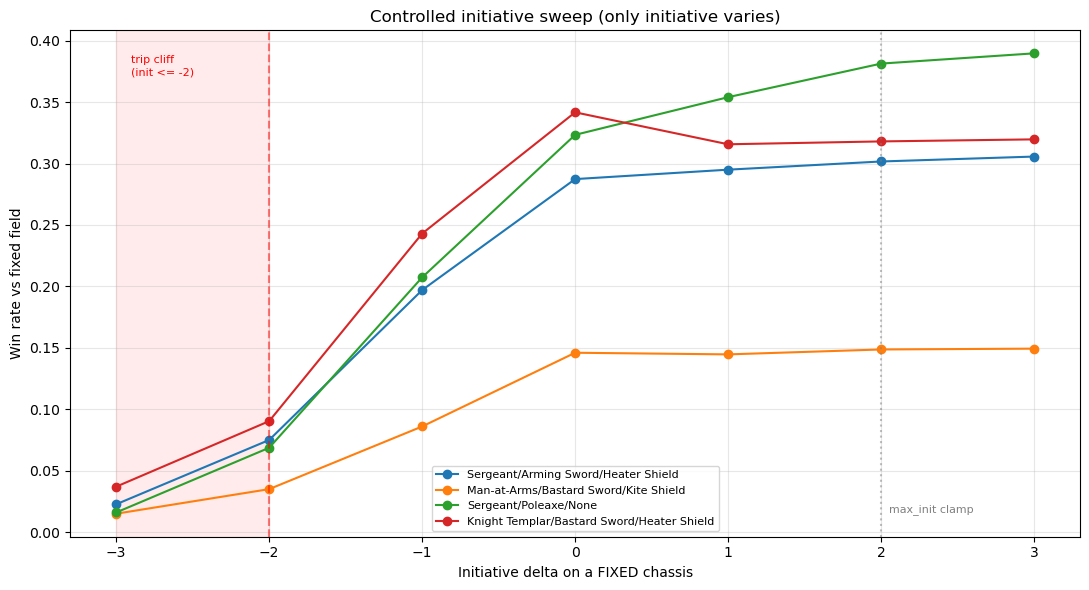


Reading: a flat line = initiative-agnostic balance. A rising line = initiative helps on
that chassis. The drop below -2 is the trip cliff; the plateau at +2 is the max_init clamp.


In [115]:
# Controlled initiative sweep — fixed chassis, vary only initiative
import matplotlib.pyplot as plt
LD = loadouts.Loadout
def _mk(name, ret, wep, shield, armor, tags=frozenset()):
    return LD(name=name, retinue=ret, weapon=wep, shield=shield, armor=armor, ranged=None,
              has_tiltyard=False, size=25, extra_tags=tags, upkeep_per_retinue=0,
              playstyle=None, tiltyard_mastery=False, pursuits=frozenset())

# Chassis to sweep (edit freely). (retinue, weapon, shield, armor)
SWEEP_CHASSIS = [
    ("Sergeant",    "Arming Sword", "Heater Shield", "Chainmail"),
    ("Man-at-Arms", "Bastard Sword","Kite Shield",   "Chainmail"),
    ("Sergeant",    "Poleaxe",      None,            "Full Plate"),
    ("Knight Templar","Bastard Sword","Heater Shield","Full Plate"),
]
INIT_DELTAS = [-3, -2, -1, 0, 1, 2, 3]
SWEEP_NR = 60

import random as _random
_random.seed(7)
_field = _random.sample(MAIN_POOL, min(50, len(MAIN_POOL)))

results = {}
for ret, wep, sh, ar in SWEEP_CHASSIS:
    wrs = []
    for d in INIT_DELTAS:
        tag = frozenset({f"TestInit{d:+d}"}) if d != 0 else frozenset()
        actor = _mk(f"{ret}/{wep}", ret, wep, sh, ar, tag)
        pairs = [(actor, b) for b in _field if b.name != actor.name]
        r = batch_engine.run_batch_random(pairs, n_runs=SWEEP_NR, seed=2026, mode="random")
        tot = r["a_wins"] + r["b_wins"] + r["mut_wipe"] + r["indecisive"]
        wrs.append(r["a_wins"].sum() / tot.sum())
    label = f"{ret}/{wep}/{sh or 'None'}"
    results[label] = wrs

print(f"{'chassis':48s} " + " ".join(f"{d:+d}I" for d in INIT_DELTAS) + "   spread (viable band -1..+2)")
for label, wrs in results.items():
    band = [w for d, w in zip(INIT_DELTAS, wrs) if -1 <= d <= 2]
    print(f"{label:48s} " + " ".join(f"{w:.3f}" for w in wrs) + f"   {max(band)-min(band):.3f}")

fig, ax = plt.subplots(figsize=(11, 6))
for label, wrs in results.items():
    ax.plot(INIT_DELTAS, wrs, "o-", label=label)
ax.axvspan(-3, -2, color="red", alpha=0.08)
ax.axvline(-2, color="red", ls="--", alpha=0.5)
ax.text(-2.9, ax.get_ylim()[1]*0.95, "trip cliff\n(init <= -2)", color="red", fontsize=8, va="top")
ax.axvline(2, color="gray", ls=":", alpha=0.5)
ax.text(2.05, ax.get_ylim()[0]+0.02, "max_init clamp", color="gray", fontsize=8)
ax.set_xlabel("Initiative delta on a FIXED chassis")
ax.set_ylabel("Win rate vs fixed field")
ax.set_title("Controlled initiative sweep (only initiative varies)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nReading: a flat line = initiative-agnostic balance. A rising line = initiative helps on")
print("that chassis. The drop below -2 is the trip cliff; the plateau at +2 is the max_init clamp.")

In [116]:
fb = analysis.feature_bucket_matrix(df_main_matchups, min_support=20)
# raw vs controlled for the key metrics
cols = ["feature","n_has","n_not",
        "win_rate_raw","win_rate_ctrl",
        "death_combat_raw","death_combat_ctrl",
        "death_shake_raw","death_shake_ctrl",
        "death_rout_raw","death_rout_ctrl"]
print(fb[cols].round(3).to_string(index=False))
fb.to_csv(os.path.join(OUT_DIR, "feature_bucket_matrix.csv"), index=False)  # full matrix, all metrics

                               feature  n_has  n_not  win_rate_raw  win_rate_ctrl  death_combat_raw  death_combat_ctrl  death_shake_raw  death_shake_ctrl  death_rout_raw  death_rout_ctrl
                          tags:Drilled    189   3268         0.393          0.201             0.022              0.081            0.020            -0.055          -0.042           -0.025
                    pursuits:Monastery    486   2971         0.317            NaN             0.298                NaN           -0.290               NaN          -0.008              NaN
              pursuits:Pilgrimage Site    486   2971         0.317            NaN             0.298                NaN           -0.290               NaN          -0.008              NaN
                pursuits:Preceptory KT    486   2971         0.317            NaN             0.298                NaN           -0.290               NaN          -0.008              NaN
                            tags:Parry   2725    732         0.31

Frontier: 28 efficient builds | Dominated: 3429 traps


,name,retinue,mpc,win_rate,dominated_by,dom_mpc,dom_win_rate,win_rate_gap,mpc_saved
0,"Lev/Cavalry Spear/Wooden/Cloth [OuInPoM, (EInd...",Levy,8,0.097,"Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, E...",8,0.955,0.857,0
1,"Lev/HuntBow/Cloth [OuInPoM, (EInd, RProw, NPie...",Levy,9,0.131,MaA/Bastard+Javelin/Tower/FullPlate (TY) [RoPa...,9,0.976,0.844,0
2,"Lev/FarmTools/Kite/Leather [OuInPoM, (RInd, RP...",Levy,6,0.041,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",6,0.882,0.841,0
3,"Lev/Crossbow/Tower/FullPlate [(EInd, EProw, NP...",Levy,7,0.064,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",7,0.903,0.838,0
4,"Lev/HuntBow/Cloth [(EInd, RProw, EPie, RCun), ...",Levy,7,0.067,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",7,0.903,0.836,0
5,"Lev/Longbow/Chain [(EInd, RProw, EPie, RCun), ...",Levy,8,0.126,"Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, E...",8,0.955,0.829,0
6,"Lev/FarmTools/Wooden/Cloth [OuInPoM, (RInd, EP...",Levy,6,0.053,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",6,0.882,0.829,0
7,"Lev/FarmTools/Kite/Leather [OuInPoM, (RInd, RP...",Levy,7,0.075,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",7,0.903,0.828,0
8,"Lev/Crossbow/Tower/FullPlate [(EInd, RProw, NP...",Levy,6,0.055,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",6,0.882,0.826,0
9,"Lev/Spears/Kite/Leather [OuInPoM, (RInd, EProw...",Levy,8,0.130,"Sgt/Lance/Heater/Gothic [ABFM, (SInd, EProw, E...",8,0.955,0.825,0


,name,retinue,mpc,win_rate
0,"Sgt/2HBastard/Cloth [(EInd, EProw, NPie, NCun)]",Sergeant,2,0.366
1,"Sgt/2HBastard/FullPlate [(EInd, EProw, NPie, N...",Sergeant,3,0.648
2,"KT/2HBastard/Cloth [PrM, (EInd, EProw, SPie, N...",Knight Templar,4,0.724
3,"Sgt/2HBastard/Cloth [(EInd, EProw, EPie, NCun)...",Sergeant,4,0.721
4,"KT/BattleAxe/FullPlate [PrM, (EInd, EProw, SPi...",Knight Templar,5,0.814
5,"KT/2HBastard/Cloth [PrM, (EInd, EProw, SPie, N...",Knight Templar,5,0.802
6,"KT/Halberd/FullPlate [PrM, (EInd, EProw, SPie,...",Knight Templar,5,0.794
7,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",Knight Templar,6,0.882
8,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",Knight Templar,6,0.873
9,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",Knight Templar,7,0.903


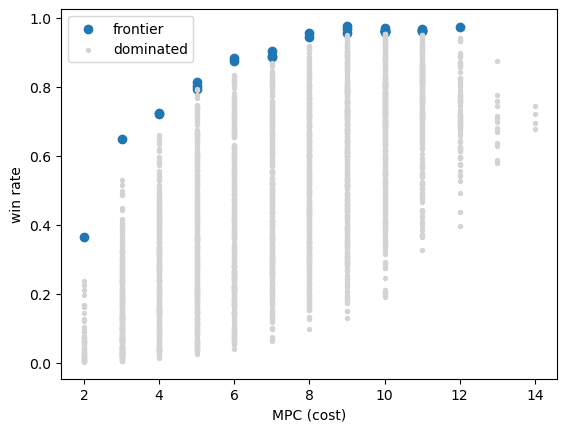

Uncounterable builds: 7


,target,target_mpc,target_win_rate,best_counter,counter_mpc,counter_win_pct,counter_mpc_premium,n_counters
0,"Sgt/2HBastard/FullPlate [(EInd, EProw, NPie, N...",3,0.648,"Sgt/WarHammer/Cloth [PrI, MiMiStM, (EInd, SPro...",4.0,0.74,1.0,655
1,"KT/Halberd/FullPlate [PrM, (EInd, EProw, SPie,...",6,0.808,"Sgt/WarHammer/Cloth [MiMiStI, OuInPoM, (EInd, ...",7.0,0.72,1.0,95
2,"KT/2HBastard/Cloth [PrM, (EInd, EProw, SPie, N...",5,0.802,"Sgt/BattleAxe/Cloth [OuInPoM, (RInd, EProw, NP...",6.0,0.56,1.0,177
3,"Sgt/2HBastard/Cloth [(EInd, EProw, EPie, NCun)...",4,0.721,"Sgt/BattleAxe/FullPlate [(EInd, EProw, EPie, N...",5.0,0.64,1.0,464
4,"KT/Arming/Tower/FullPlate [PrM, (EInd, EProw, ...",7,0.783,"MaA/WarHammer+HuntBow/Cloth (TY) [RoPaM, (EInd...",8.0,0.70,1.0,70
5,"MaA/WarHammer+Crossbow/FullPlate (TY) [RoPaM, ...",10,0.953,None,NaN,NaN,NaN,0
6,"KT/Pike/FullPlate [PrM, (EInd, EProw, SPie, NC...",7,0.822,"MaA/HuntBow/Leather [RoPaM, (NInd, SProw, EPie...",8.0,0.62,1.0,65
7,"KT/Pike/FullPlate [PrM, (EInd, EProw, SPie, RC...",7,0.833,"Sgt/Crossbow/Cloth [MiMiStM, (EInd, SProw, NPi...",8.0,0.70,1.0,75
8,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",6,0.882,"Sgt/Crossbow/Cloth [(EInd, EProw, EPie, NCun),...",7.0,0.66,1.0,38
9,"KT/2HBastard/FullPlate [PrM, (EInd, EProw, SPi...",6,0.873,"Sgt/WarHammer/Cloth [MiMiStI, OuInPoM, (EInd, ...",7.0,0.58,1.0,53


,tag_a,tag_b,n_both,wr_both,expected,synergy
0,Drilled,Immune Strain,189,0.838,1.043,-0.205
1,ABF,Recover 5,36,0.536,0.717,-0.181
2,Drilled,Dual Wield,35,0.810,0.980,-0.170
3,Dual Wield,Immune Unwieldy,225,0.609,0.774,-0.165
4,Drilled,Immune Unwieldy,189,0.838,1.003,-0.165
5,Recover 4,Recover 5,927,0.582,0.736,-0.154
6,ABF,Recover 4,35,0.526,0.678,-0.152
7,+1I,Crit 5,215,0.616,0.766,-0.150
8,+1I,MaxInit3,215,0.616,0.766,-0.150
9,Crit 5,MaxInit3,215,0.616,0.766,-0.150


{'n_builds': 400, 'n_edges': 53036, 'n_3cycles': 10662, 'n_triads_3edge': 3308061, 'intransitivity_ratio': 0.0032, 'interpretation': 'near-solved power ladder — little counterplay'}


In [117]:
import analysis, importlib; importlib.reload(analysis)
df = df_main_matchups   # your loaded tournament

# 1. DOMINANCE — which builds are trap picks (cheaper build wins more)
front, dom = analysis.dominance_frontier(df)
print(f"Frontier: {len(front)} efficient builds | Dominated: {len(dom)} traps")
display(dom.head(20))                    # worst traps first — these need buffs or cost cuts
display(front.head(15))

# plot the frontier:
import matplotlib.pyplot as plt
plt.scatter(front.mpc, front.win_rate, c='tab:blue', label='frontier')
if len(dom): plt.scatter(dom.mpc, dom.win_rate, c='lightgray', s=8, label='dominated')
plt.xlabel('MPC (cost)'); plt.ylabel('win rate'); plt.legend(); plt.show()

# 2. CHEAPEST COUNTER — over-tuned builds you can't answer on-budget
cc = analysis.cheapest_counter(df, win_threshold=0.55)
print("Uncounterable builds:", (cc.n_counters==0).sum())
display(cc.head(20))                      # top = uncounterable / must-overpay-to-beat

# 3. TAG SYNERGY — combos that exceed the sum of their parts
syn = analysis.tag_synergy_matrix(df, min_support=30)
display(syn.head(20))                      # watch Parry+Riposte, Unstoppable+Shatter, etc.

# 4. INTRANSITIVITY — is the meta deep RPS or a solved ladder?
print(analysis.intransitivity(df, win_margin=0.55))

Build counts by archetype: {'Aggressive': 4754812, 'Midrange': 3958209, 'Defensive': 600171}

Row-archetype win rate vs Column-archetype:
            Aggressive  Defensive  Anti-armor  Midrange
Aggressive        0.45       0.24         NaN      0.52
Defensive         0.53       0.31         NaN      0.52
Anti-armor         NaN        NaN         NaN       NaN
Midrange          0.37       0.27         NaN      0.44

Overall win rate as attacker:
  Aggressive  n=4754812  mean WR=0.466
  Defensive   n=600171  mean WR=0.512
  Midrange    n=3958209  mean WR=0.394


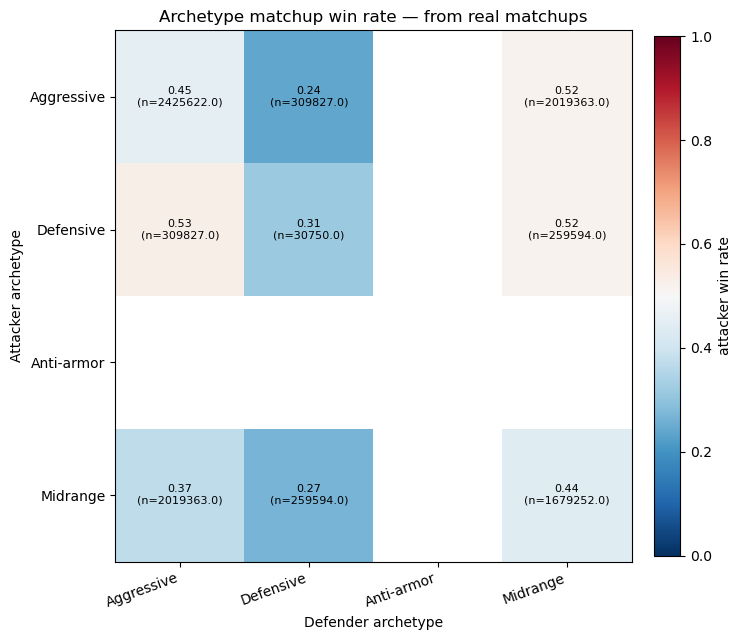

In [118]:
# ── Archetype RPS from real matchups — Aggressive / Anti-armor / Defensive / Midrange ──
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import renown_combat as rc

df = df_main_matchups.copy()

def _wt(w):  return set(rc.WEAPONS.get(w, {}).get("tags", [])) if w else set()
def _rt(r):  return set(rc.RANGED.get(r, {}).get("tags", [])) if (r and r in rc.RANGED) else set()
def _wap(w): return rc.WEAPONS.get(w, {}).get("ap", 0) if w else 0
def _rap(r): return rc.RANGED.get(r, {}).get("ap", 0) if (r and r in rc.RANGED) else 0
def _wi(w):  return rc.WEAPONS.get(w, {}).get("init", 0) if w else 0
def _ri(r):  return rc.RANGED.get(r, {}).get("init", 0) if (r and r in rc.RANGED) else 0
def _si(sh): return rc.SHIELDS.get(sh, {}).get("init", 0) if (sh and sh in rc.SHIELDS) else 0

def classify(weapon, ranged, shield, armor, tags):
    eff = rc.ARMORS.get(armor, {}).get("save", 6) - (
          rc.SHIELDS.get(shield, {}).get("save_bonus", 0) if (shield and shield in rc.SHIELDS) else 0)
    alltags   = _wt(weapon) | _rt(ranged)
    best_ap   = min(_wap(weapon), _rap(ranged))          # most armor-pen available
    base_init = max(_wi(weapon), _ri(ranged)) + _si(shield)
    has_cleave = "Cleave" in alltags
    # 1) Anti-armor: Shatter Armor AND best AP <= -4
    if "Shatter Armor" in alltags and best_ap <= -4:
        return "Anti-armor"
    # 2) Aggressive: (base init >= 1 AND AP >= -3) OR (Cleave AND AP >= -3)
    if (base_init >= 1 and best_ap >= -3) or (has_cleave and best_ap >= -3):
        return "Aggressive"
    # 3) Defensive: effective save <= 2 (after aggressive filled)
    if eff <= 2:
        return "Defensive"
    # 4) Midrange: everything else
    return "Midrange"

for s in ("a", "b"):
    rng = df[f"{s}_ranged"] if f"{s}_ranged" in df.columns else pd.Series([None] * len(df))
    df[f"{s}_arch"] = [classify(w, r, sh, ar, t) for w, r, sh, ar, t in
                       zip(df[f"{s}_weapon"], rng, df[f"{s}_shield"], df[f"{s}_armor"], df[f"{s}_tags"])]

den = (df["a_wins"] + df["b_wins"] + df["mut_wipe"] + df["indecisive"]).replace(0, np.nan)
df["a_wr"] = df["a_wins"] / den

ARCH = ["Aggressive", "Defensive", "Anti-armor", "Midrange"]
mat = pd.DataFrame(index=ARCH, columns=ARCH, dtype=float)
n   = pd.DataFrame(index=ARCH, columns=ARCH, dtype=int)
for ai in ARCH:
    for bj in ARCH:
        sub = df[(df.a_arch == ai) & (df.b_arch == bj)]
        mat.loc[ai, bj] = sub["a_wr"].mean() if len(sub) else np.nan
        n.loc[ai, bj]   = len(sub)

print("Build counts by archetype:", df.a_arch.value_counts().to_dict())
print("\nRow-archetype win rate vs Column-archetype:")
print(mat.round(2).to_string())
print("\nOverall win rate as attacker:")
for a in ARCH:
    sub = df[df.a_arch == a]
    if len(sub): print(f"  {a:11s} n={len(sub):6d}  mean WR={sub['a_wr'].mean():.3f}")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
M = mat.values.astype(float)
im = ax.imshow(M, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(ARCH))); ax.set_xticklabels(ARCH, rotation=20, ha="right")
ax.set_yticks(range(len(ARCH))); ax.set_yticklabels(ARCH)
for i in range(len(ARCH)):
    for j in range(len(ARCH)):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i,j]:.2f}\n(n={n.values[i,j]})", ha="center", va="center",
                    fontsize=8, color="white" if abs(M[i, j] - 0.5) > 0.28 else "black")
ax.set_xlabel("Defender archetype"); ax.set_ylabel("Attacker archetype")
ax.set_title("Archetype matchup win rate — from real matchups")
fig.colorbar(im, ax=ax, label="attacker win rate", fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

In [119]:
import analysis
st = analysis.build_stat_table(MAIN_POOL)
pool_names = set(st["name"]); summ_names = set(df_main_summary["name"])
print("MAIN_POOL builds:", len(st), "| summary rows:", len(df_main_summary))
print("names in BOTH:", len(pool_names & summ_names))
print("only in MAIN_POOL:", len(pool_names - summ_names))
print("only in summary:", len(summ_names - pool_names))
print("sample pool name:   ", next(iter(pool_names)))
print("sample summary name:", next(iter(summ_names)))

MAIN_POOL builds: 35712 | summary rows: 3457
names in BOTH: 3457
only in MAIN_POOL: 32255
only in summary: 0
sample pool name:    MaA/Morningstar+Crossbow/Cloth (TY) [OuInPoM, (EInd, EProw, NPie, SCun), ImmU]
sample summary name: MaA/Pike/Cloth [(RInd, RProw, NPie, RCun), Poison]


In [120]:
print("MPC range in pool:", min(p.military_pursuit_count for p in MAIN_POOL),
                            max(p.military_pursuit_count for p in MAIN_POOL))
print("Riposte builds in pool:", sum(1 for p in MAIN_POOL if "Riposte" in p.extra_tags))
print("Grand Tournament in pool:", sum(1 for p in MAIN_POOL if "Grand Tournament" in p.pursuits))

MPC range in pool: 2 14
Riposte builds in pool: 0
Grand Tournament in pool: 17820


Reference field: 48 opponents

Base loadouts for injection: 24 ({'Sergeant': 6, 'Man-at-Arms': 6, 'Levy': 6, 'Knight Templar': 6})

  Shatter Armor          Δ=+0.016  (n=12, range [+0.000, +0.044])
  Cleave                 Δ=+0.057  (n=12, range [+0.014, +0.102])
  Destroy Shield         Δ=+0.006  (n=12, range [-0.003, +0.017])
  Rend                   Δ=+0.040  (n=12, range [+0.002, +0.069])
  Poison                 Δ=+0.018  (n=12, range [+0.004, +0.035])
  Unstoppable            Δ=+0.035  (n=12, range [+0.000, +0.095])
  Steady                 Δ=+0.048  (n=12, range [-0.005, +0.137])
  Nimble                 Δ=+0.001  (n=12, range [-0.005, +0.007])
  Unwieldy               Δ=+0.000  (n=12, range [+0.000, +0.000])
  Regenerate             Δ=+0.040  (n=12, range [+0.000, +0.093])
  Regenerate 5           Δ=+0.057  (n=12, range [+0.000, +0.143])
  Regenerate 4           Δ=+0.086  (n=12, range [+0.000, +0.225])
  Apothecary Heal        Δ=+0.039  (n=12, range [+0.003, +0.095])
  Unshakab

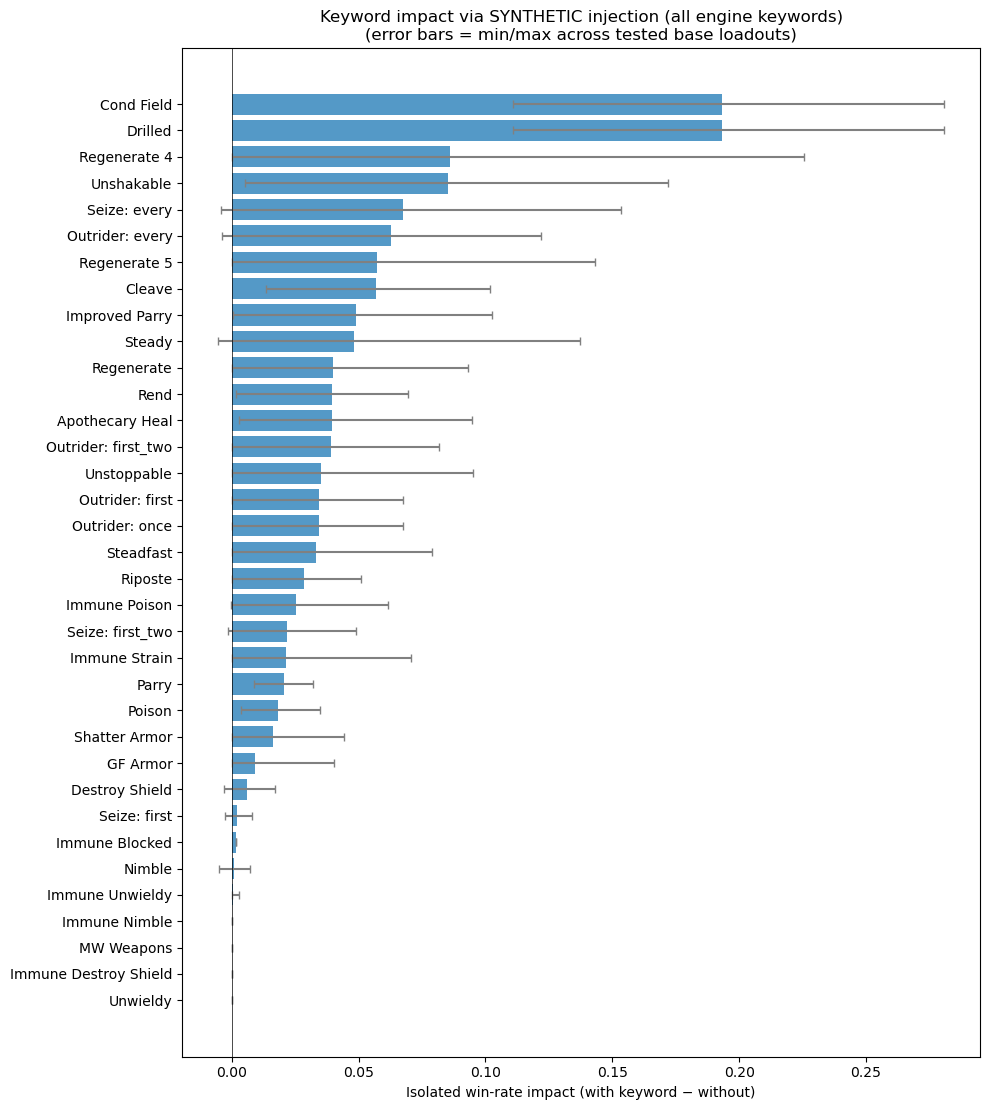


Saved: C:\Users\Matt\OneDrive\Desktop\Game\Combatv3\lab_out\keyword_ab_all.png


In [121]:
# ──────────────────────────────────────────────────────────────────────────────
# Keyword impact via SYNTHETIC injection — ALL keywords, not just pursuit-granted
# ──────────────────────────────────────────────────────────────────────────────
# Instead of finding existing carriers, we take a fixed set of base loadouts and
# ADD each keyword to extra_tags (toggle ON), then compare to the same base (OFF)
# against a fixed reference field. This tests every keyword the engine reads,
# including innate-only ones no pursuit grants.
#
# NOTE: this is a "what if this keyword were added" experiment. Some keywords here
# are normally innate (weapon/retinue) or unobtainable via pursuits — injecting
# them measures their raw mechanical value, not their in-game availability.

import importlib, numpy as np, pandas as pd, random
import loadouts, renown_combat, vectorized_combat, playstyles
importlib.reload(loadouts); importlib.reload(vectorized_combat)
vectorized_combat.invalidate_tactic_tables()
from collections import defaultdict

pool = MAIN_POOL

# EVERY keyword the engine reads (build-relevant). Grouped for readability.
ALL_KEYWORDS = [
    # offensive / weapon effects
    "Shatter Armor", "Cleave", "Destroy Shield", "Rend", "Poison", "Unstoppable",
    "Steady", "Nimble", "Unwieldy",
    # defensive / regen / heal
    "Regenerate", "Regenerate 5", "Regenerate 4", "Apothecary Heal",
    # morale / discipline
   "Unshakable", "Drilled", "Cond Field", "Steadfast",
    # immunities
    "Immune Poison", "Immune Strain", "Immune Unwieldy",
    "Immune Blocked", "Immune Destroy Shield", "Immune Nimble",
    # spec gear effects
    "GF Armor", "MW Weapons", "Parry", "Improved Parry",
    # initiative tempo (Seize / Outrider)
    "Seize: first", "Seize: first_two", "Seize: every",
    "Outrider: once", "Outrider: first", "Outrider: first_two", "Outrider: every",
    "Riposte"
]

# Fixed reference field (same gauntlet for every comparison).
random.seed(2026)
buckets = defaultdict(list)
for ld in pool:
    buckets[(ld.retinue, ld.military_pursuit_count)].append(ld)
ref_field = []
for key, lds in buckets.items():
    ref_field.extend(random.sample(lds, min(len(lds), 1)))
if len(ref_field) > 60:
    ref_field = random.sample(ref_field, 60)
ref_field = [r._replace(playstyle=playstyles.assign_default_playstyle(r)) for r in ref_field]
print(f"Reference field: {len(ref_field)} opponents\n")

# Fixed set of base loadouts to inject keywords onto. Spread across retinues so the
# delta isn't dominated by one chassis. We pick builds that DON'T already carry the kw.
random.seed(99)
base_candidates = []
seen = defaultdict(int)
for ld in random.sample(pool, len(pool)):           # shuffled
    if seen[ld.retinue] < 6:                         # up to 6 per retinue
        base_candidates.append(ld); seen[ld.retinue] += 1
print(f"Base loadouts for injection: {len(base_candidates)} ({dict(seen)})\n")

def field_winrate(ld, field, n_runs=100):
    ld = ld._replace(playstyle=playstyles.assign_default_playstyle(ld))
    wins = total = 0
    for i, opp in enumerate(field):
        if opp.name == ld.name:
            continue
        r = vectorized_combat.run_matchup_vec(ld, opp, n_runs=n_runs, seed=4242+i, max_skirmishes=20)
        wins += r['a_wins']; total += (r['a_wins'] + r['b_wins'] + r['mut_wipe'] + r['indecisive'])
    return wins / total if total else float('nan')

rows = []
for kw in ALL_KEYWORDS:
    # Use base loadouts that don't already have the keyword
    bases = [ld for ld in base_candidates if kw not in ld.extra_tags][:12]
    if not bases:
        print(f"  {kw:<22} (no eligible base loadouts — skipped)")
        continue
    deltas = []
    for ld in bases:
        without_kw = ld._replace(extra_tags=[t for t in ld.extra_tags if t != kw])
        with_kw    = ld._replace(extra_tags=list(ld.extra_tags) + [kw])
        wr_off = field_winrate(without_kw, ref_field)
        wr_on  = field_winrate(with_kw,    ref_field)
        deltas.append(wr_on - wr_off)
    deltas = np.array(deltas)
    rows.append({
        "keyword": kw, "n_tested": len(bases),
        "mean_delta": deltas.mean(), "median_delta": np.median(deltas),
        "min_delta": deltas.min(), "max_delta": deltas.max(), "std": deltas.std(),
    })
    print(f"  {kw:<22} Δ={deltas.mean():+.3f}  (n={len(bases)}, range [{deltas.min():+.3f}, {deltas.max():+.3f}])")

res = pd.DataFrame(rows).sort_values("mean_delta", ascending=False)
print("\n=== Keyword isolated win-rate impact (SYNTHETIC inject on vs off, vs fixed field) ===")
print(res[["keyword","n_tested","mean_delta","median_delta","min_delta","max_delta"]].round(3).to_string(index=False))

# Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, max(6, 0.32*len(res))))
rs = res.sort_values("mean_delta")
ax.barh(range(len(rs)), rs["mean_delta"],
        xerr=[rs["mean_delta"]-rs["min_delta"], rs["max_delta"]-rs["mean_delta"]],
        color="#2980b9", alpha=0.8, capsize=3, ecolor="gray")
ax.set_yticks(range(len(rs))); ax.set_yticklabels(rs["keyword"])
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Isolated win-rate impact (with keyword − without)")
ax.set_title("Keyword impact via SYNTHETIC injection (all engine keywords)\n(error bars = min/max across tested base loadouts)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "keyword_ab_all.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"\nSaved: {os.path.join(OUT_DIR,'keyword_ab_all.png')}")